In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re 
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
import time
import random
import math

%matplotlib inline

In [2]:
# Use the current animal's paths in batch mode; retain the original paths when run individually.
if '_batch_paths' in globals():
    path_signal_neuron, path_behavior, path_save = _batch_paths
else:
    # path_signal_neuron = r'E:\rq\M2\信号数据\第二批\pre\LHQ30\TST'
    path_signal_neuron = r'F:\M2\信号数据\第二批\pre\LHQ30\TST'
    path_save = r'F:\M2\临时图像5 敏感性分析\LHQ30 pre'
    path_behavior = r'F:\M2\有设备小鼠 行为数据\spare\第二批\pre\LHQ30'

if not os.path.exists(path_save):
    os.makedirs(path_save)

# Read the data.
df_signal_neuron = pd.read_csv(path_signal_neuron+'\C.csv')
df_raw_neuron = pd.read_csv(path_signal_neuron+'\YrA.csv')
try:
    df_drop_id_neuron = pd.read_excel(path_signal_neuron+'\pic\drop.xlsx',header=None) 
except:
    print('drop id not found')
    df_drop_id_neuron = None

# Standardize column names.
df_signal_neuron = df_signal_neuron.rename(columns={"unit_id":"unit_id","frame":"t","C":"value"})
df_raw_neuron = df_raw_neuron.rename(columns={"unit_id":"unit_id","frame":"t","YrA":"value"})

# Step 2: Identify valid IDs using C as the reference.
if df_drop_id_neuron is not None:
    valid_ids_neuron = set(df_signal_neuron['unit_id'].unique()) - set(df_drop_id_neuron[0].values.tolist())
else:
    valid_ids_neuron = set(df_signal_neuron['unit_id'].unique())

# Step 3: Retain valid IDs in YrA and C.
df_raw_neuron = df_raw_neuron[df_raw_neuron['unit_id'].isin(valid_ids_neuron)].copy()
df_signal_neuron = df_signal_neuron[df_signal_neuron['unit_id'].isin(valid_ids_neuron)].copy()

def downsample_data(df):
    # Ensure sorting by unit_id and t.
    df_sorted = df.sort_values(['unit_id', 't']).copy()
        # Create grouping keys for groups of 3 frames.
    df_sorted['group'] = df_sorted.groupby('unit_id')['t'].transform(lambda x: (x - x.min()) // 3)
        # Group by unit_id and group; average value and use the first t in each group.
    df_downsampled = df_sorted.groupby(['unit_id', 'group']).agg({'t': 'first', 'value': 'mean'}).reset_index(level='unit_id').reset_index(drop=True)
    return df_downsampled

# Apply the downsampling function.
df_raw_neuron = downsample_data(df_raw_neuron)
# Save the data before downsampling for comparison.
df_signal_neuron_before = df_signal_neuron.copy()
df_signal_neuron = downsample_data(df_signal_neuron)

# 5. Standardize C within each id.
df_neuron = pd.merge(df_raw_neuron, df_signal_neuron, on=['unit_id', 't'], suffixes=('_YrA', '_C'))

df_neuron['residual'] = df_neuron['value_YrA'] - df_neuron['value_C']
df_neuron['value_z'] = df_neuron['value_C'] / df_neuron.groupby('unit_id')['residual'].transform('std')

# Reshape rows and columns.
resized_df_signal_neuron_raw = df_neuron.pivot(index='t', columns='unit_id', values='value_z').reset_index(drop=True)  # Rows = time; columns = id.

# Apply z-score standardization to each column of neuron1 and neuron2.
resized_df_signal_neuron = resized_df_signal_neuron_raw.apply(zscore, axis=0)

In [3]:
# Each column represents a neuron; each row represents a time frame.

# Set parameters.
fps = 10  # Assume a frame rate of 10 frames/second; adjust to match the data.
min_duration = 0.5  # Minimum duration of a valid activity event in seconds.
min_duration_frames = int(min_duration * fps)  # Convert to frames.
start_threshold = 2  # Activity onset threshold.
end_threshold = 1  # Activity offset threshold.

# Create a dictionary to store valid activity events for each neuron.
neuron_events = {}

# Iterate over neurons (columns).
for neuron_id in resized_df_signal_neuron.columns:
    # Get this neuron's signal.
    signal = resized_df_signal_neuron[neuron_id].values
    
    # Store this neuron's valid activity events.
    valid_events = []
    
    # Initialize the activity state and start frame.
    in_activity = False
    activity_start = None
    peak_value = -np.inf
    
    # Iterate over time frames.
    for frame_idx in range(len(signal)):
        current_value = signal[frame_idx]
        
        # Detect activity onset.
        if not in_activity and current_value >= start_threshold:
            in_activity = True
            activity_start = frame_idx
            peak_value = current_value
        # Update the peak while activity is ongoing.
        elif in_activity:
            if current_value > peak_value:
                peak_value = current_value
            # Detect activity offset when the signal falls from its peak to the end threshold.
            elif current_value <= end_threshold:
                in_activity = False
                activity_end = frame_idx
                # Check the activity duration.
                duration_frames = activity_end - activity_start
                if duration_frames >= min_duration_frames:
                    # Record valid activity events.
                    valid_events.append({
                        'start_frame': activity_start,
                        'end_frame': activity_end,
                        'duration_frames': duration_frames,
                        'duration_seconds': duration_frames / fps,
                        'peak_value': peak_value
                    })
        
    # Store all valid activity events for this neuron.
    neuron_events[neuron_id] = valid_events

# Convert the results to a format suitable for analysis.
all_events = []
for neuron_id, events in neuron_events.items():
    for event in events:
        event_data = {
            'neuron_id': neuron_id,
            **event
        }
        all_events.append(event_data)

# Create the results DataFrame.
events_df = pd.DataFrame(all_events)

# Print summary statistics.
print(f"Total valid activity events detected: {len(events_df)}")
print(f"Mean valid activity events per neuron: {len(events_df) / len(resized_df_signal_neuron.columns):.2f}")

# Optionally save the results to a file.
# events_df.to_csv('neuron_activity_events.csv', index=False)

Total valid activity events detected: 753
Mean valid activity events per neuron: 9.53


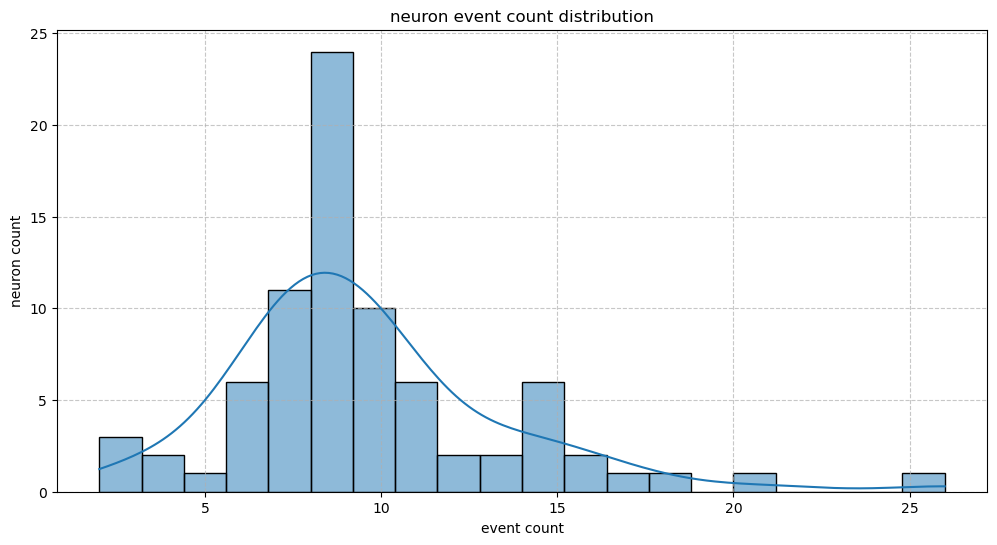

In [4]:
# 1. Summarize the distribution of event counts across neuron_id values.
neuron_event_counts = events_df.groupby('neuron_id').size().reset_index(name='event_count')

# Visualize the distribution of neuronal event counts.
plt.figure(figsize=(12, 6))
sns.histplot(neuron_event_counts['event_count'], bins=20, kde=True)
plt.title('neuron event count distribution')
plt.xlabel('event count')
plt.ylabel('neuron count')
plt.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()
plt.savefig(path_save + r'\neuron event distribution.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\neuron event distribution.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

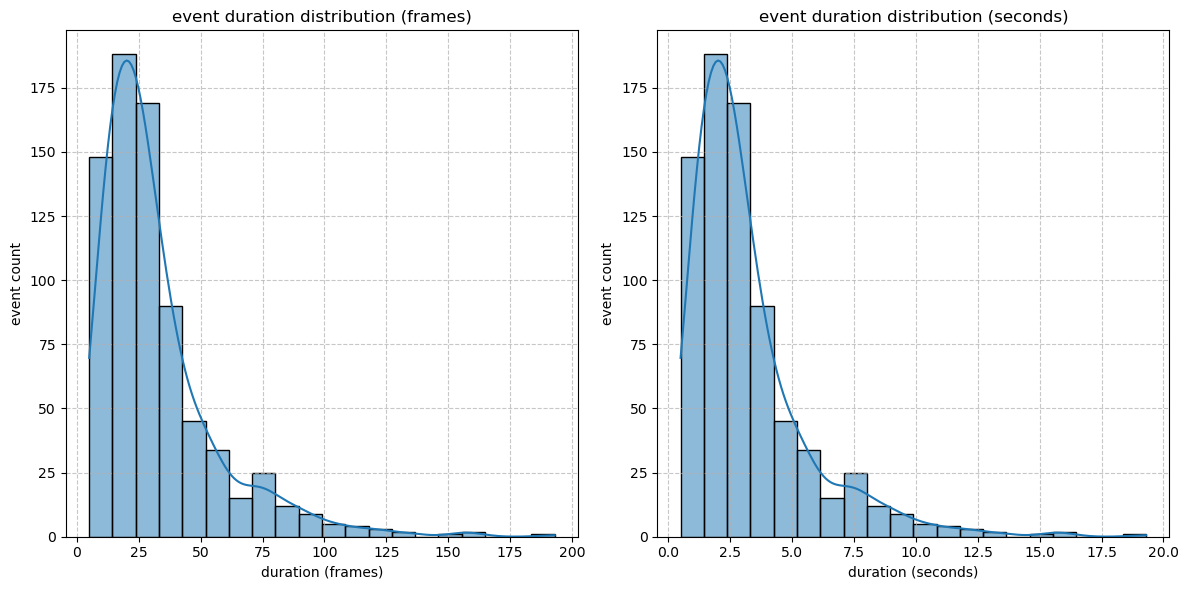

In [5]:
# 2. Summarize the distribution of event durations.
# Summarize durations in frames or seconds.
plt.figure(figsize=(12, 6))

# Distribution of durations in frames.
plt.subplot(1, 2, 1)
sns.histplot(events_df['duration_frames'], bins=20, kde=True)
plt.title('event duration distribution (frames)')
plt.xlabel('duration (frames)')
plt.ylabel('event count')
plt.grid(True, linestyle='--', alpha=0.7)

# Distribution of durations in seconds.
plt.subplot(1, 2, 2)
sns.histplot(events_df['duration_seconds'], bins=20, kde=True)
plt.title('event duration distribution (seconds)')
plt.xlabel('duration (seconds)')
plt.ylabel('event count')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

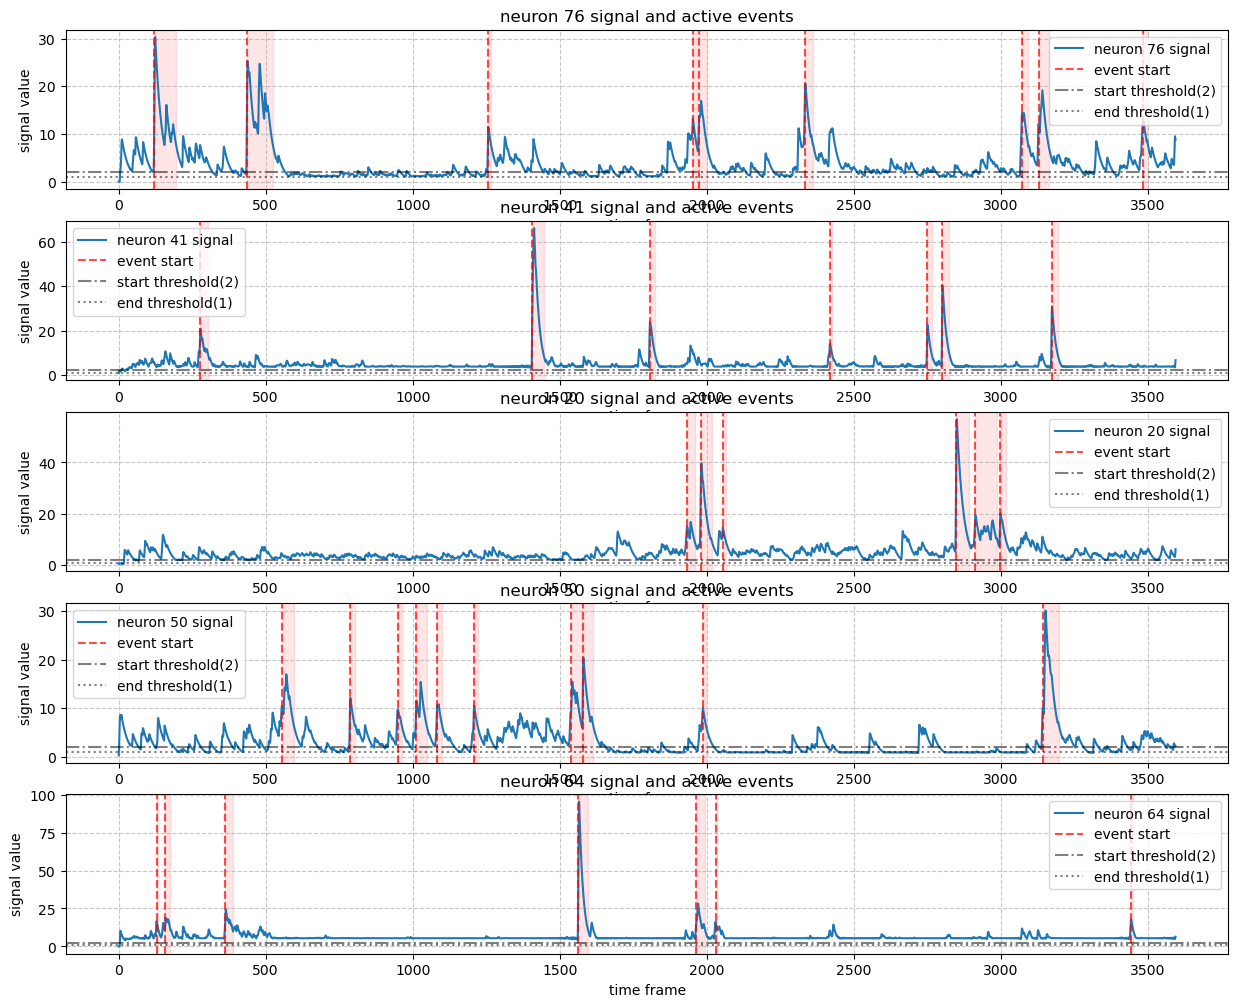

In [6]:
# 3. Randomly select five neurons and plot their signals and event onsets.
# Ensure that the columns of resized_df_signal_neuron_raw match neuron_id in events_df.
valid_neuron_ids = list(set(events_df['neuron_id'].unique()) & set(resized_df_signal_neuron_raw.columns))

# Randomly select 5 neuron IDs.
if len(valid_neuron_ids) >= 5:
    selected_neuron_ids = random.sample(valid_neuron_ids, 5)
else:
    selected_neuron_ids = valid_neuron_ids  # Use all available neurons if fewer than 5 are available.

# Plot the selected neurons' signals and event onsets.
plt.figure(figsize=(15, 12))

for i, neuron_id in enumerate(selected_neuron_ids, 1):
    # Get this neuron's signal data.
    neuron_signal = resized_df_signal_neuron_raw[neuron_id].values
    # Get all events for this neuron.
    neuron_events = events_df[events_df['neuron_id'] == neuron_id]
    
    # Create a subplot.
    plt.subplot(len(selected_neuron_ids), 1, i)
    # Plot the signal trace.
    plt.plot(neuron_signal, label=f'neuron {neuron_id} signal')
    # Mark event onsets.
    for _, event in neuron_events.iterrows():
        # Draw vertical lines at event onsets.
        plt.axvline(x=event['start_frame'], color='r', linestyle='--', alpha=0.7, label='event start' if _ == neuron_events.index[0] else "")
        # Optionally mark event offsets.
        # plt.axvline(x=event['end_frame'], color='g', linestyle='--', alpha=0.7, label='Event offset' if _ == neuron_events.index[0] else "")
        # Mark the event duration intervals.
        plt.axvspan(event['start_frame'], event['end_frame'], color='r', alpha=0.1)
    
    # Add threshold lines.
    plt.axhline(y=2, color='k', linestyle='-.', alpha=0.5, label='start threshold(2)')
    plt.axhline(y=1, color='k', linestyle=':', alpha=0.5, label='end threshold(1)')
    
    # Set plot properties.
    plt.title(f'neuron {neuron_id} signal and active events')
    plt.xlabel('time frame')
    plt.ylabel('signal value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
plt.savefig(path_save + r'\neuron signal and active.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\neuron signal and active.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

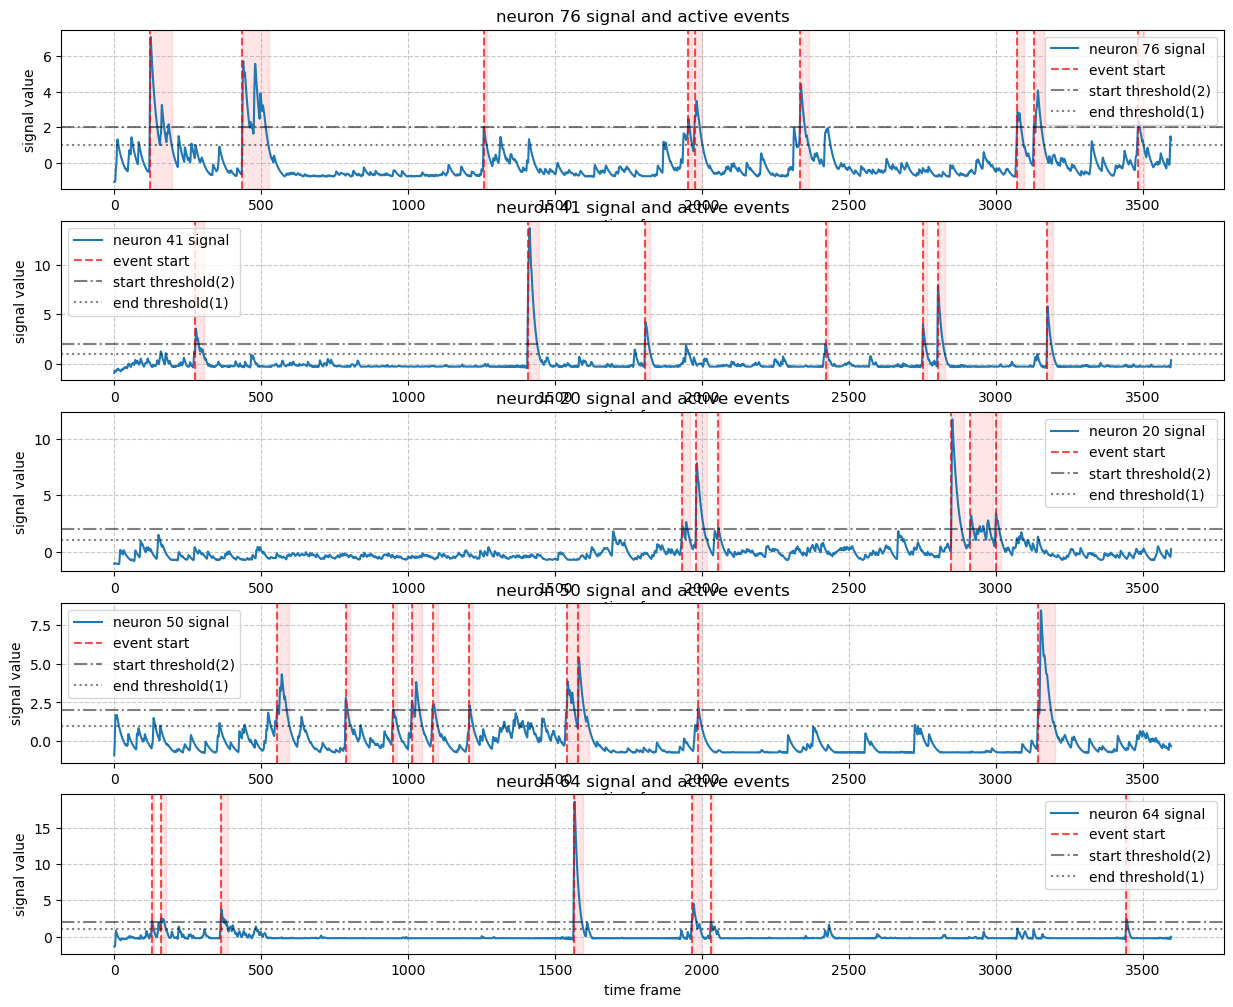

In [7]:
# 3. Randomly select five neurons and plot their signals and event onsets.
# # Ensure that the columns of resized_df_signal_neuron_raw match neuron_id in events_df.
# valid_neuron_ids = list(set(events_df['neuron_id'].unique()) & set(resized_df_signal_neuron_raw.columns))

# # Randomly select 5 neuron IDs.
# if len(valid_neuron_ids) >= 5:
#     selected_neuron_ids = random.sample(valid_neuron_ids, 5)
# else:
#     selected_neuron_ids = valid_neuron_ids  # Use all available neurons if fewer than 5 are available.

# Plot the selected neurons' signals and event onsets.
plt.figure(figsize=(15, 12))

for i, neuron_id in enumerate(selected_neuron_ids, 1):
    # Get this neuron's signal data.
    neuron_signal = resized_df_signal_neuron[neuron_id].values
    # Get all events for this neuron.
    neuron_events = events_df[events_df['neuron_id'] == neuron_id]
    
    # Create a subplot.
    plt.subplot(len(selected_neuron_ids), 1, i)
    # Plot the signal trace.
    plt.plot(neuron_signal, label=f'neuron {neuron_id} signal')
    # Mark event onsets.
    for _, event in neuron_events.iterrows():
        # Draw vertical lines at event onsets.
        plt.axvline(x=event['start_frame'], color='r', linestyle='--', alpha=0.7, label='event start' if _ == neuron_events.index[0] else "")
        # Optionally mark event offsets.
        # plt.axvline(x=event['end_frame'], color='g', linestyle='--', alpha=0.7, label='Event offset' if _ == neuron_events.index[0] else "")
        # Mark the event duration intervals.
        plt.axvspan(event['start_frame'], event['end_frame'], color='r', alpha=0.1)
    
    # Add threshold lines.
    plt.axhline(y=2, color='k', linestyle='-.', alpha=0.5, label='start threshold(2)')
    plt.axhline(y=1, color='k', linestyle=':', alpha=0.5, label='end threshold(1)')
    
    # Set plot properties.
    plt.title(f'neuron {neuron_id} signal and active events')
    plt.xlabel('time frame')
    plt.ylabel('signal value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
plt.savefig(path_save + r'\normed neuron signal and active.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\normed neuron signal and active.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# 4. Print summary statistics.
print("Neuronal event statistics:")
print(f"Total neurons: {len(neuron_event_counts)}")
print(f"Total events: {len(events_df)}")
print(f"Mean events per neuron: {neuron_event_counts['event_count'].mean():.2f} ± {neuron_event_counts['event_count'].std():.2f}")
print(f"Event duration statistics (seconds):")
print(f"  Mean: {events_df['duration_seconds'].mean():.2f} ± {events_df['duration_seconds'].std():.2f}")
print(f"  Median: {events_df['duration_seconds'].median():.2f}")
print(f"  Minimum: {events_df['duration_seconds'].min():.2f}")
print(f"  Maximum: {events_df['duration_seconds'].max():.2f}")

# Optionally save the results.
# events_df.to_csv('neuron_activity_events.csv', index=False)
# neuron_event_counts.to_csv('neuron_event_counts.csv', index=False)

Neuronal event statistics:
Total neurons: 79
Total events: 753
Mean events per neuron: 9.53 ± 3.93
Event duration statistics (seconds):
  Mean: 3.22 ± 2.41
  Median: 2.60
  Minimum: 0.50
  Maximum: 19.30


In [ ]:
fps = 10
window_size_frames = 3 * fps  # Number of frames in a 3-second window.

def calculate_coverage_for_neuron(neuron_id, events_df, total_frames, window_size_frames, fps):
    """
    Compute the duration of activity coverage for one neuron in each window.
    
    Parameters:
    neuron_id: neuron ID.
    events_df: DataFrame of valid activity events.
    total_frames: total number of frames.
    window_size_frames: window size in frames.
    fps: frame rate.
    
    Returns:
    DataFrame containing window indices, neuron IDs, and activity coverage durations.
    """
    # Select events for the current neuron.
    neuron_events = events_df[events_df['neuron_id'] == neuron_id].copy()
    
    # Compute the number of windows.
    num_windows = int(np.ceil(total_frames / window_size_frames))
    
    results = []
    
    for window_idx in range(num_windows):
        # Compute the start and end frames of the window.
        window_start = window_idx * window_size_frames
        window_end = min((window_idx + 1) * window_size_frames, total_frames)
        window_duration_seconds = (window_end - window_start) / fps
        
        # Initialize activity coverage duration to 0.
        active_time = 0
        
        # Check whether each event intersects the current window.
        for _, event in neuron_events.iterrows():
            event_start = event['start_frame']
            event_end = event['end_frame']
            
            # Compute the intersection of the event and window.
            overlap_start = max(window_start, event_start)
            overlap_end = min(window_end, event_end)
            
            # If they intersect, compute the duration of the intersection.
            if overlap_start < overlap_end:
                overlap_duration = (overlap_end - overlap_start) / fps
                active_time += overlap_duration
        
        # Compute the fraction of time covered by activity.
        if window_duration_seconds > 0:
            coverage_ratio = active_time / window_duration_seconds
        else:
            coverage_ratio = 0

        
        results.append({
            'window_idx': window_idx,
            'neuron_id': neuron_id,
            'window_start_frame': window_start,
            'window_end_frame': window_end,
            'window_duration_seconds': window_duration_seconds,
            'active_time_seconds': active_time,
            'coverage_ratio': coverage_ratio
        })
    
    return pd.DataFrame(results)

# Compute activity coverage duration for all neurons.
def calculate_coverage_all_neurons(resized_df_signal_neuron, events_df, fps=10):
    """
    Compute activity coverage duration for all neurons.
    """
    total_frames = resized_df_signal_neuron.shape[0]
    neuron_ids = resized_df_signal_neuron.columns.tolist()
    
    all_results = []
    
    for neuron_id in neuron_ids:
        neuron_results = calculate_coverage_for_neuron(
            neuron_id=neuron_id,
            events_df=events_df,
            total_frames=total_frames,
            window_size_frames=window_size_frames,
            fps=fps
        )
        all_results.append(neuron_results)
    
    # Combine results from all neurons.
    coverage_df = pd.concat(all_results, ignore_index=True)
    # Classify using quantiles of nonzero coverage ratios across all neurons, truncated to one decimal place.
    non_zero_coverage = coverage_df.loc[coverage_df['coverage_ratio'] > 0, 'coverage_ratio']
    if non_zero_coverage.empty:
        coverage_df['coverage_type'] = 'No coverage'
    else:
        # lower_threshold = np.floor(non_zero_coverage.quantile(0.1) * 10) / 10
        # upper_quantile = non_zero_coverage.quantile(0.8)
        # upper_threshold = 0.99 if upper_quantile == 1 else np.floor(upper_quantile * 10) / 10
        lower_threshold = np.floor(np.round(non_zero_coverage.quantile(0.1) * 10, 12)) / 10
        upper_quantile = non_zero_coverage.quantile(0.8)
        upper_threshold = 0.99 if upper_quantile == 1 else np.floor(np.round(upper_quantile * 10, 12)) / 10
        coverage_df['coverage_type'] = np.select(
            [coverage_df['coverage_ratio'] < lower_threshold,
             coverage_df['coverage_ratio'] < upper_threshold],
            ['No coverage', 'Partial coverage'], default='Full coverage'
        )
    return coverage_df

# Run the calculation.
coverage_df = calculate_coverage_all_neurons(resized_df_signal_neuron, events_df, fps=fps)

# Display summary statistics.
print("Counts by coverage type:")
coverage_type_counts = coverage_df['coverage_type'].value_counts()
for coverage_type, count in coverage_type_counts.items():
    print(f"  {coverage_type}: {count} windows ({count/len(coverage_df)*100:.2f}%)")

print("\nMean coverage ratio for each neuron:")
avg_coverage_by_neuron = coverage_df.groupby('neuron_id')['coverage_ratio'].mean().sort_values(ascending=False)
print(f"  Maximum: {avg_coverage_by_neuron.max():.3f}")
print(f"  Minimum: {avg_coverage_by_neuron.min():.3f}")
print(f"  Mean: {avg_coverage_by_neuron.mean():.3f} ± {avg_coverage_by_neuron.std():.3f}")

# Optionally save the results to a CSV file.
# coverage_df.to_csv('neuron_activity_coverage.csv', index=False)

Counts by coverage type:
  No coverage: 8143 windows (85.90%)
  Partial coverage: 1033 windows (10.90%)
  Full coverage: 304 windows (3.21%)

Mean coverage ratio for each neuron:
  Maximum: 0.153
  Minimum: 0.029
  Mean: 0.085 ± 0.029


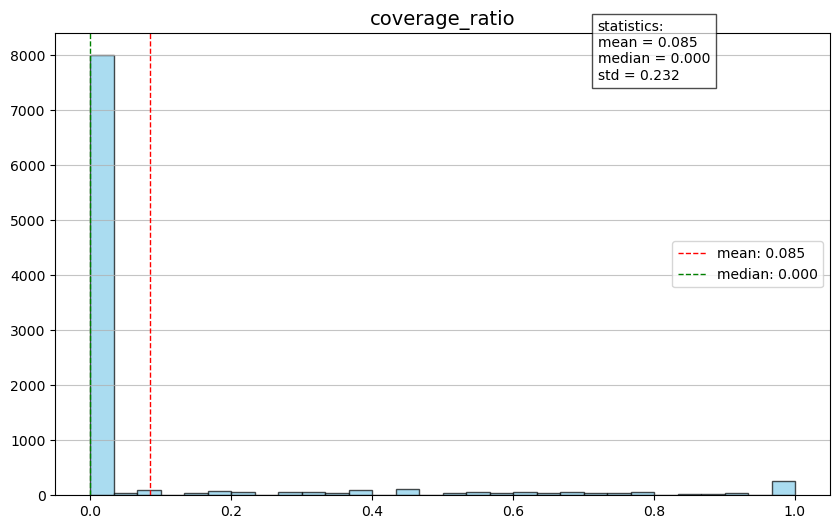

In [10]:
# Create a histogram.
plt.figure(figsize=(10, 6))
plt.hist(coverage_df['coverage_ratio'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')

# Add a title and axis labels.
plt.title('coverage_ratio', fontsize=14)
# plt.xlabel('c', fontsize=12)
# plt.ylabel('Frequency', fontsize=12)

# Add grid lines.
plt.grid(axis='y', alpha=0.75)

# Compute and display statistics.
mean_ratio = coverage_df['coverage_ratio'].mean()
median_ratio = coverage_df['coverage_ratio'].median()
std_ratio = coverage_df['coverage_ratio'].std()

# Add statistical annotations to the plot.
stats_text = f'statistics:\nmean = {mean_ratio:.3f}\nmedian = {median_ratio:.3f}\nstd = {std_ratio:.3f}'
plt.text(0.7, 0.9, stats_text, transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.7), fontsize=10)

# Add a vertical reference line for the mean.
plt.axvline(mean_ratio, color='red', linestyle='dashed', linewidth=1, label=f'mean: {mean_ratio:.3f}')
plt.axvline(median_ratio, color='green', linestyle='dashed', linewidth=1, label=f'median: {median_ratio:.3f}')

# Add a legend.
plt.legend()

# Adjust the layout.
# plt.tight_layout()
plt.savefig(path_save + r'\coverage_ratio.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\coverage_ratio.png', format='png', dpi=300, bbox_inches='tight')

# Display the plot.
plt.show()

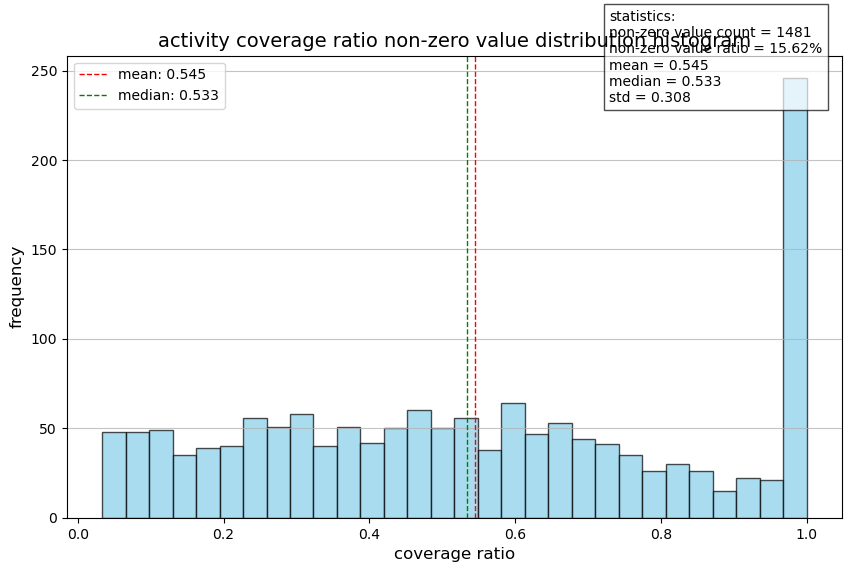

Detailed statistics for nonzero coverage ratios:
- Minimum: 0.033333
- 10th percentile: 0.133
- 50th percentile: 0.533
- 75th percentile: 0.800
- 80th percentile: 0.900
- Maximum: 1.000


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# # Configure a Chinese font to display Chinese characters correctly.
# plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
# plt.rcParams['axes.unicode_minus'] = False  # Fix minus-sign rendering.

# Select nonzero values.
non_zero_coverage = coverage_df[coverage_df['coverage_ratio'] > 0]['coverage_ratio']

# Compute statistics for nonzero values.
non_zero_count = len(non_zero_coverage)
non_zero_percentage = (non_zero_count / len(coverage_df)) * 100
mean_non_zero = non_zero_coverage.mean()
median_non_zero = non_zero_coverage.median()
std_non_zero = non_zero_coverage.std()

# Create a histogram.
plt.figure(figsize=(10, 6))
plt.hist(non_zero_coverage, bins=30, alpha=0.7, color='skyblue', edgecolor='black')

# Add a title and axis labels.
plt.title('activity coverage ratio non-zero value distribution histogram', fontsize=14)
plt.xlabel('coverage ratio', fontsize=12)
plt.ylabel('frequency', fontsize=12)

# Add grid lines.
plt.grid(axis='y', alpha=0.75)

# Add statistical annotations to the plot.
stats_text = f'statistics:\nnon-zero value count = {non_zero_count}\nnon-zero value ratio = {non_zero_percentage:.2f}%\nmean = {mean_non_zero:.3f}\nmedian = {median_non_zero:.3f}\nstd = {std_non_zero:.3f}'
plt.text(0.7, 0.9, stats_text, transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.7), fontsize=10)

# Add vertical reference lines for the mean and median.
plt.axvline(mean_non_zero, color='red', linestyle='dashed', linewidth=1, label=f'mean: {mean_non_zero:.3f}')
plt.axvline(median_non_zero, color='green', linestyle='dashed', linewidth=1, label=f'median: {median_non_zero:.3f}')

# Add a legend.
plt.legend()

# Adjust the layout.
# plt.tight_layout()
plt.savefig(path_save + r'\coverage_ratio non_zero value.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\coverage_ratio non_zero value.png', format='png', dpi=300, bbox_inches='tight')

# Display the plot.
plt.show()

# Optionally display more detailed statistics.
print(f"Detailed statistics for nonzero coverage ratios:")
print(f"- Minimum: {non_zero_coverage.min():.6f}")
print(f"- 10th percentile: {non_zero_coverage.quantile(0.1):.3f}")
print(f"- 50th percentile: {non_zero_coverage.quantile(0.5):.3f}")
print(f"- 75th percentile: {non_zero_coverage.quantile(0.75):.3f}")
print(f"- 80th percentile: {non_zero_coverage.quantile(0.8):.3f}")
print(f"- Maximum: {non_zero_coverage.max():.3f}")

In [12]:
non_zero_coverage_list = list(coverage_df[coverage_df['coverage_ratio'] > 0].index)
coverage_df_ = coverage_df.copy()

# Get all indices.
all_indices = coverage_df_.index.tolist()
# Find indices to set to 'None', namely those absent from non_zero_coverage_list.
indices_to_set_none = [idx for idx in all_indices if idx not in non_zero_coverage_list]
# Set coverage_type to 'None' for rows at these indices.
coverage_df_.loc[indices_to_set_none, 'coverage_type'] = 'None'
coverage_df_ = coverage_df_.reset_index()

C:\Users\Admin\AppData\Local\Temp\ipykernel_38456\1429510379.py:75: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.savefig(path_save + r'\single neuron coverage.pdf', format='pdf', dpi=300, bbox_inches='tight')
C:\Users\Admin\AppData\Local\Temp\ipykernel_38456\1429510379.py:75: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.savefig(path_save + r'\single neuron coverage.pdf', format='pdf', dpi=300, bbox_inches='tight')
C:\Users\Admin\AppData\Local\Temp\ipykernel_38456\1429510379.py:75: UserWarning: Glyph 35206 (\N{CJK UNIFIED IDEOGRAPH-8986}) missing from font(s) DejaVu Sans.
  plt.savefig(path_save + r'\single neuron coverage.pdf', format='pdf', dpi=300, bbox_inches='tight')
C:\Users\Admin\AppData\Local\Temp\ipykernel_38456\1429510379.py:75: UserWarning: Glyph 30422 (\N{CJK UNIFIED IDEOGRAPH-76D6}) missing from font(s) DejaVu Sans.
  plt.savefig(path_save + r'\single neuron coverage.pd

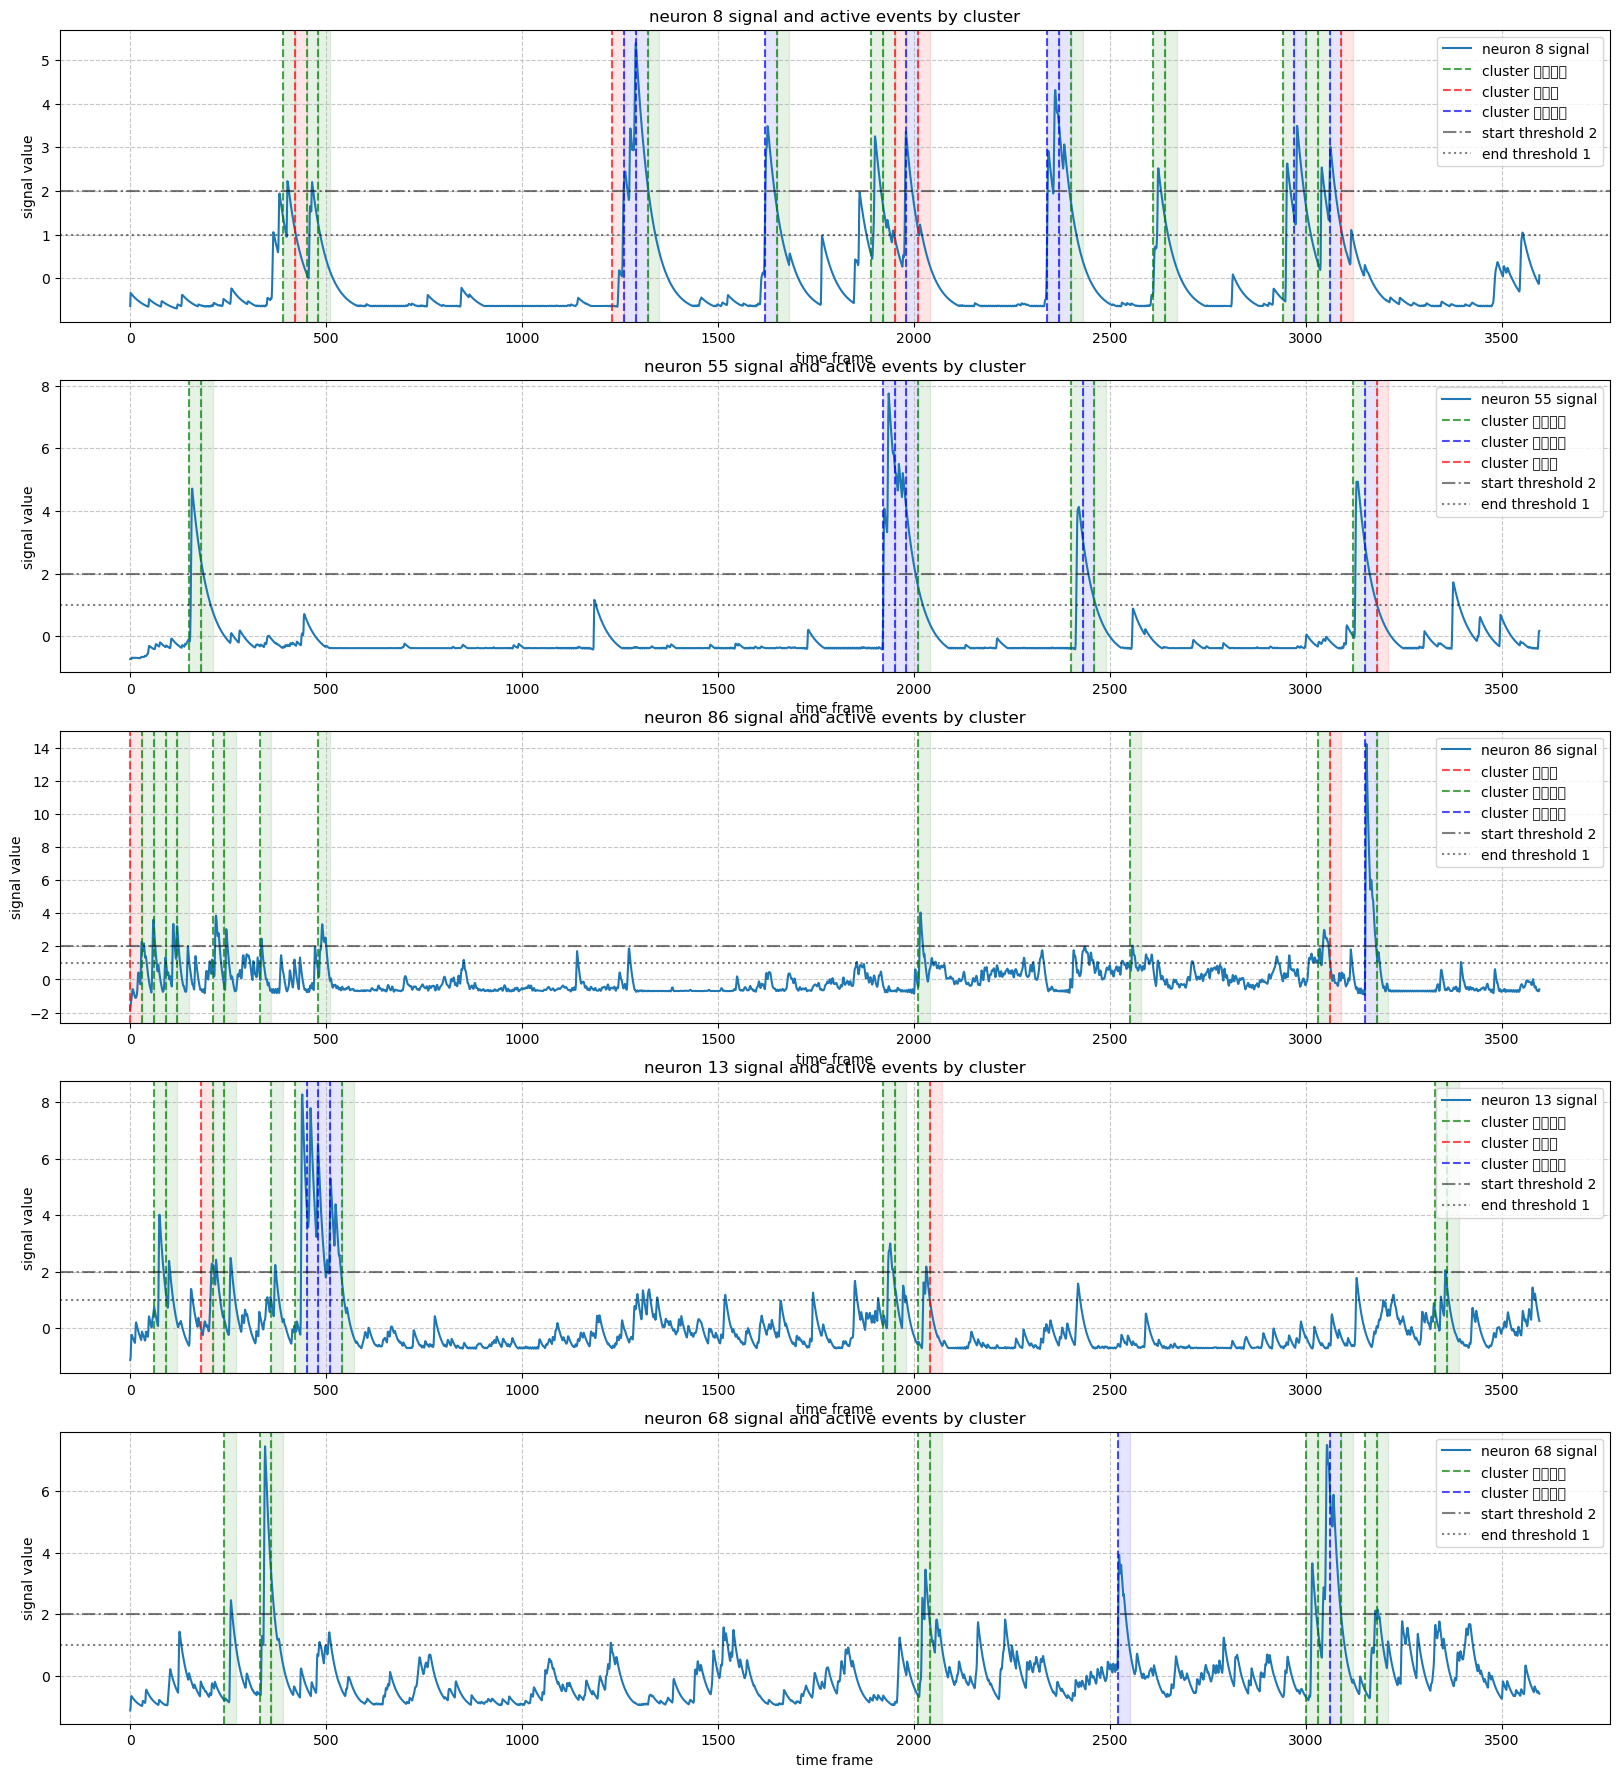

In [13]:
# Randomly select five neurons and plot their signals and event onsets.
# Ensure that the columns of resized_df_signal_neuron_raw match neuron_id in events_df.
valid_neuron_ids = list(set(coverage_df_['neuron_id'].unique())) 

# Randomly select 5 neuron IDs.
if len(valid_neuron_ids) >= 5:
    selected_neuron_ids = random.sample(valid_neuron_ids, 5)
else:
    selected_neuron_ids = valid_neuron_ids   # Use all available neurons if fewer than 5 are available.

# Create a color mapping dictionary for different cluster_label values.
# Adjust the color list or add more colors as needed.
cluster_colors = {
    'No coverage': 'r',  # Use red for class 0.
    'Partial coverage': 'g',  # Use green for class 1.
    'Full coverage': 'b',  # Use blue for class 2.
    'None': 'k'
}

# Create a mapping from event IDs to cluster_label.
cluster_map = dict(zip(coverage_df_['index'], coverage_df_['coverage_type']))

# Plot the selected neurons' signals and event onsets.
plt.figure(figsize=(20, 22)) 

for i, neuron_id in enumerate(selected_neuron_ids, 1):
    # Get this neuron's signal data.
    neuron_signal = resized_df_signal_neuron[neuron_id].values
    # Get all events for this neuron.
    neuron_events = coverage_df_[coverage_df_['neuron_id'] == neuron_id].copy()
    
    # Add cluster_label to each event.
    neuron_events['coverage_type'] = neuron_events['index'].map(cluster_map)
    
    # Create a subplot.
    plt.subplot(len(selected_neuron_ids), 1, i)
    # Plot the signal trace.
    plt.plot(neuron_signal, label=f'neuron {neuron_id} signal')
    
    # Track legend labels already added to avoid duplicates.
    added_labels = set()
    
    # Mark event onsets and intervals using colors determined by cluster_label.
    for _, event in neuron_events.iterrows():
        cluster_label = event['coverage_type']

        # Skip cluster_label values of none without adding color markers.
        if cluster_label == 'None':
            continue

        # Get the color for this cluster label.
        color = cluster_colors.get(cluster_label, 'k')  # Default to black.
        
        # Draw vertical lines at event onsets.
        label = f'cluster {cluster_label}' if f'cluster {cluster_label}' not in added_labels else ""
        plt.axvline(x=event['window_start_frame'], color=color, linestyle='--', alpha=0.7, label=label)
        if label:
            added_labels.add(label)
        
        # Mark the event duration intervals.
        plt.axvspan(event['window_start_frame'], event['window_end_frame'], color=color, alpha=0.1)
    
    # Add threshold lines.
    plt.axhline(y=2, color='k', linestyle='-.', alpha=0.5, label='start threshold 2')
    plt.axhline(y=1, color='k', linestyle=':', alpha=0.5, label='end threshold 1')
    
    # Set plot properties.
    plt.title(f'neuron {neuron_id} signal and active events by cluster')
    plt.xlabel('time frame')
    plt.ylabel('signal value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
plt.savefig(path_save + r'\single neuron coverage.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\single neuron coverage.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

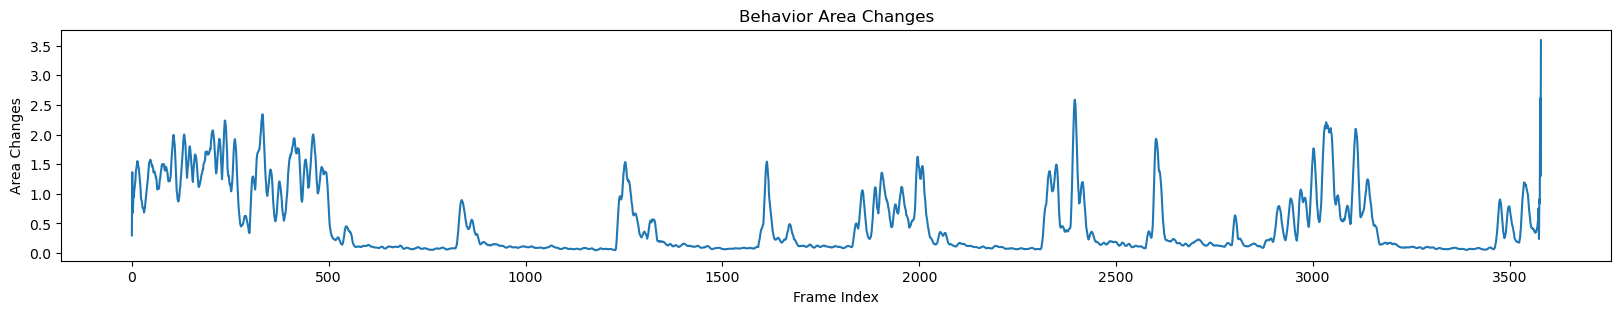

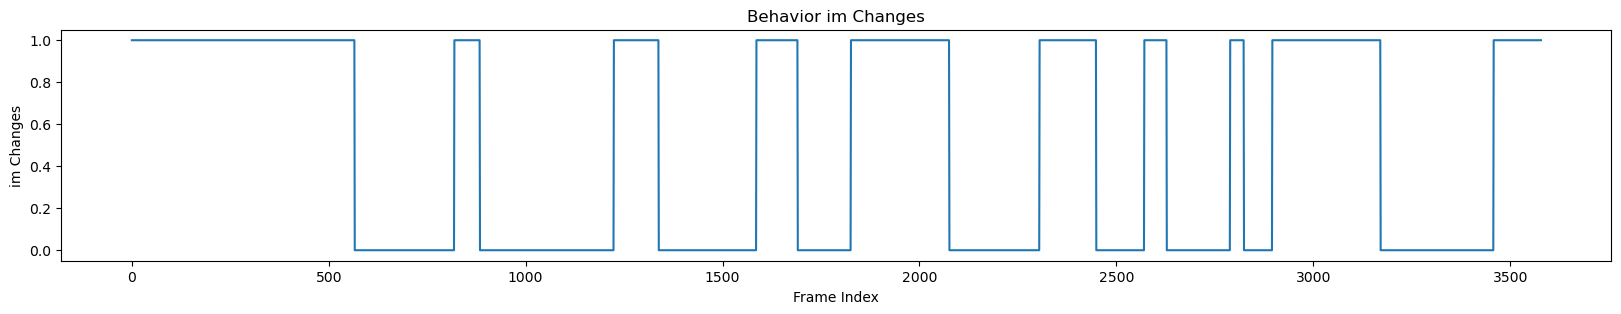

In [14]:
df_behavior = pd.read_csv(path_behavior+'\Area_Change.csv')
df_im = pd.read_csv(path_behavior+'\im.csv')
df_behavior = df_behavior.T.reset_index(drop=True)
df_im = df_im.T.reset_index(drop=True)

S_to_I = []
for i in range(len(df_im)-1):
    if (df_im[0][i+1]-df_im[0][i]) == 1:
        S_to_I.append(i)
    else:
        continue

S_to_I_update = []
df_im_update_temp = df_im.copy()

for i in S_to_I:
    if i < 20 or i > (len(df_im_update_temp)-20):
        continue
    else:
        temp_backward =  df_im_update_temp[(i-20):i]  
        temp_b_values = temp_backward.sum().values

        temp_forward =  df_im_update_temp[i:i+20]   
        temp_f_values = temp_forward.sum().values

        if temp_b_values[0]==0:
            if temp_f_values[0]==19:
                S_to_I_update.append(i)
            else:
                for num in range(i+1,i+20):
                    if df_im_update_temp.loc[num,0]==1:
                        df_im_update_temp.loc[num,0]=0
                    else:
                        break      
        else:
            continue

I_to_S = []
for i in range(len(df_im)-1):
    if (df_im[0][i+1]-df_im[0][i]) == -1:
        I_to_S.append(i)
    else:
        continue

I_to_S_update = []
df_im_update_temp = df_im.copy()

for i in I_to_S:
    if i < 20 or i > (len(df_im_update_temp)-20):
        continue
    else:
        temp_backward =  df_im_update_temp[(i-20):i]  
        temp_b_values = temp_backward.sum().values

        temp_forward =  df_im_update_temp[i:i+20]   
        temp_f_values = temp_forward.sum().values

        if temp_b_values[0]==20: 
            if temp_f_values[0]==1:
                I_to_S_update.append(i)
            else:
                for num in range(i+1,i+20):           
                    if df_im_update_temp.loc[num,0]==0:
                        df_im_update_temp.loc[num,0]=1
                    else:
                        break
        else:
            continue

# Combine the S to I and I to S transition times in chronological order.
temp_im_update = {}
temp_state = []
temp_position = []
pointer_S = 0
pointer_I = 0
for i in range(len(S_to_I_update)+len(I_to_S_update)):
    if S_to_I_update[pointer_S] < I_to_S_update[pointer_I]:
        temp_state.append('S')
        temp_position.append(S_to_I_update[pointer_S])
        pointer_S = pointer_S + 1
        if pointer_S >= len(S_to_I_update):
            for j in range(pointer_I,len(I_to_S_update)):
                temp_state.append('I')
                temp_position.append(I_to_S_update[j])
            break

    elif S_to_I_update[pointer_S] > I_to_S_update[pointer_I]:
        temp_state.append('I')
        temp_position.append(I_to_S_update[pointer_I])
        pointer_I = pointer_I + 1
        if pointer_I >= len(I_to_S_update):
            for j in range(pointer_S,len(S_to_I_update)):
                temp_state.append('S')
                temp_position.append(S_to_I_update[j])
            break
    else:
        print("S and I states error")
        break

temp_im_update['state'] = temp_state
temp_im_update['position'] = temp_position
behaviour_im_update = pd.DataFrame(temp_im_update)

# Merge repeated behavioral states; consecutive identical states indicate a failed transition, so retain only the last transition.
behaviour_im_update_with_head = {}
behaviour_im_update_with_head=behaviour_im_update.copy()

for i in range(len(behaviour_im_update_with_head)-1):
    if behaviour_im_update_with_head.loc[i,'state']==behaviour_im_update_with_head.loc[i+1,'state']:
        behaviour_im_update_with_head.loc[i,'position']=0
for i in range(len(behaviour_im_update_with_head)):
    if behaviour_im_update_with_head.loc[i,'position']==0:
        behaviour_im_update_with_head=behaviour_im_update_with_head.drop(i)
behaviour_im_update_with_head = behaviour_im_update_with_head.reset_index(drop=True)

# Generate an updated behavioral state sequence from the revised transition times.
behaviour_im_with_head = np.zeros((len(df_im),1))
behaviour_im_with_head = pd.DataFrame(behaviour_im_with_head)
before_tag = 0
for i in range(len(behaviour_im_update_with_head)):
    state_tag = behaviour_im_update_with_head['state'][i]
    position_tag = behaviour_im_update_with_head['position'][i]

    if state_tag == 'S':
        behaviour_im_with_head.loc[before_tag:position_tag,0] = 1
    else:
        behaviour_im_with_head.loc[before_tag:position_tag,0] = 0

    before_tag = position_tag

    if i == len(behaviour_im_update_with_head)-1:
        if state_tag == 'S':
            behaviour_im_with_head.loc[before_tag:,0] = 0
        else:
            behaviour_im_with_head.loc[before_tag:,0] = 1

plt.figure(figsize=(20, 3))
plt.plot(np.arange(len(df_behavior)), df_behavior)
plt.title('Behavior Area Changes')
plt.xlabel('Frame Index')
plt.ylabel('Area Changes')
plt.savefig(path_save + r'\Behavior Area Changes.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\Behavior Area Changes.png', format='png', dpi=300, bbox_inches='tight')

plt.figure(figsize=(20, 3))
plt.plot(behaviour_im_with_head)
plt.title('Behavior im Changes')
plt.xlabel('Frame Index')
plt.ylabel('im Changes')
plt.savefig(path_save + r'\Behavior im Changes.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\Behavior im Changes.png', format='png', dpi=300, bbox_inches='tight')

In [15]:
# Compute statistics for each event (mean, maximum, and minimum).
def calculate_event_statistics(events_df, resized_df_signal_neuron):
    """
    Compute neuronal signal statistics for each valid event.
    
    Parameters:
    events_df: DataFrame of valid activity events.
    resized_df_signal_neuron: neuronal signal data.
    
    Returns:
    DataFrame containing event statistics.
    """
    # Create a list to store results.
    event_stats = []
    
    # Iterate over events.
    for idx, event in events_df.iterrows():
        neuron_id = event['neuron_id']
        start_frame = event['start_frame']
        end_frame = event['end_frame']
        
        # Get the neuronal signal data for this event.
        # Assume that neuron_id is a column in resized_df_signal_neuron.
        event_signal = resized_df_signal_neuron.loc[start_frame:end_frame-1, neuron_id]
        
        # Compute statistics.
        event_mean = event_signal.mean()
        event_max = event_signal.max()
        event_min = event_signal.min()
        event_std = event_signal.std()
        event_duration = end_frame - start_frame
        
        # Store results.
        event_stats.append({
            'event_id': idx,
            'neuron_id': neuron_id,
            'start_frame': start_frame,
            'end_frame': end_frame,
            'duration_frames': event_duration,
            'mean_value': event_mean,
            'max_value': event_max,
            'min_value': event_min,
            'std_value': event_std
        })
    
    # Convert to a DataFrame.
    stats_df = pd.DataFrame(event_stats)
    return stats_df

# Compute summary statistics of event metrics for each neuron.

def calculate_neuron_summary_statistics(event_stats_df):
    """
    Compute summary statistics across all events within each neuron.
    
    Parameters:
    event_stats_df: DataFrame containing statistics for each event.
    
    Returns:
    DataFrame containing summary statistics for each neuron.
    """
    # Group by neuron and compute summary statistics.
    neuron_summary = event_stats_df.groupby('neuron_id').agg({
        'mean_value': ['mean', 'std', 'count'],  # Mean and standard deviation of event means, and event count, for each neuron.
        'max_value': ['mean', 'std'],            # Mean and standard deviation of event maxima for each neuron.
        'min_value': ['mean', 'std'],            # Mean and standard deviation of event minima for each neuron.
        'duration_frames': ['mean', 'std']       # Mean and standard deviation of event durations for each neuron.
    }).round(4)
    
    # Rename columns for clarity.
    neuron_summary.columns = ['events_mean_avg', 'events_mean_std', 'events_count', 
                             'events_max_avg', 'events_max_std', 
                             'events_min_avg', 'events_min_std',
                             'events_duration_avg', 'events_duration_std']
    
    # Reset the index so neuron_id becomes a column.
    neuron_summary = neuron_summary.reset_index()
    
    return neuron_summary

# Run the calculation.
# 1. Compute statistics for each event.
event_stats_df = calculate_event_statistics(events_df, resized_df_signal_neuron)

# 2. Compute summary statistics for each neuron.
neuron_summary_df = calculate_neuron_summary_statistics(event_stats_df)

# Display statistics for the first few events.
print("Example event statistics:")
print(event_stats_df.head())

# Display summary statistics for the first few neurons.
print("\nExample neuronal summary statistics:")
print(neuron_summary_df.head())

# Display overall statistics.
print("\nOverall neuronal activity event statistics:")
print(f"Total valid activity events: {len(events_df)}")
print(f"Neurons involved: {len(neuron_summary_df)}")
print(f"Mean events per neuron: {event_stats_df['neuron_id'].value_counts().mean():.2f} ± {event_stats_df['neuron_id'].value_counts().std():.2f}")
print(f"Mean event duration in frames: {event_stats_df['duration_frames'].mean():.2f} ± {event_stats_df['duration_frames'].std():.2f}")
print(f"Mean event signal value: {event_stats_df['mean_value'].mean():.4f} ± {event_stats_df['mean_value'].std():.4f}")


Example event statistics:
   event_id  neuron_id  start_frame  end_frame  duration_frames  mean_value  \
0         0        5.0         18.0       75.0             57.0    3.490005   
1         1        5.0         85.0      142.0             57.0    3.208243   
2         2        5.0        210.0      243.0             33.0    2.337420   
3         3        5.0        270.0      298.0             28.0    1.955709   
4         4        5.0        448.0      486.0             38.0    2.493450   

   max_value  min_value  std_value  
0   6.631582   1.003294   1.665236  
1   6.887606   1.009993   1.738922  
2   3.980602   1.053131   0.888057  
3   3.022816   1.020659   0.616911  
4   4.408134   1.031699   0.997378  

Example neuronal summary statistics:
   neuron_id  events_mean_avg  events_mean_std  events_count  events_max_avg  \
0        5.0           2.5923           0.6393             8          4.7321   
1        7.0           2.2016           0.7068            15          3.4675   

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

Calculation complete: statistics for 753 events.
Normalization complete: 753 normalized events.
k=2: silhouette score=0.6402, within-cluster sum of squares=42.1242
k=3: silhouette score=0.5905, within-cluster sum of squares=19.0275
k=4: silhouette score=0.5449, within-cluster sum of squares=12.4723
k=5: silhouette score=0.5327, within-cluster sum of squares=8.7734
k=6: silhouette score=0.5225, within-cluster sum of squares=7.3264


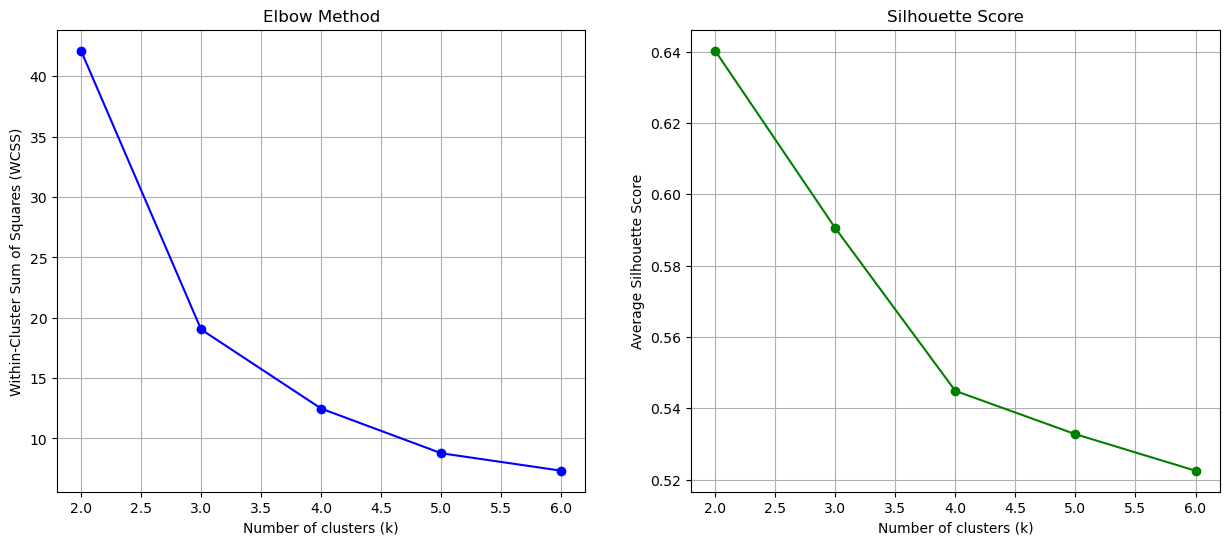

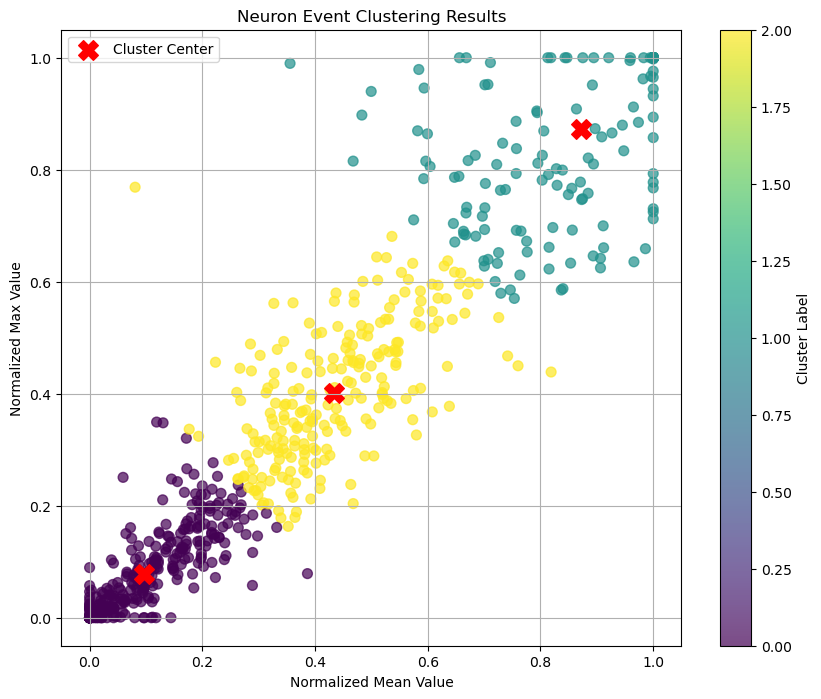

Event counts by cluster:
  Cluster 0: 334 events (44.36%)
  Cluster 1: 188 events (24.97%)
  Cluster 2: 231 events (30.68%)


In [ ]:
# Step 1: Compute the mean and maximum for each neuronal event.

def calculate_event_statistics(events_df, resized_df_signal_neuron):
    """
    Compute the mean and maximum neuronal signal value for each valid event.
    """
    event_stats = []
    
    # Iterate over events.
    for idx, event in events_df.iterrows():
        neuron_id = event['neuron_id']
        start_frame = event['start_frame']
        end_frame = event['end_frame']
        
        # Get the neuronal signal data for this event.
        event_signal = resized_df_signal_neuron.loc[start_frame:end_frame-1, neuron_id]
        
        # Compute statistics.
        event_mean = event_signal.mean()
        event_max = event_signal.max()
        
        # Store results.
        event_stats.append({
            'event_id': idx,
            'neuron_id': neuron_id,
            'start_frame': start_frame,
            'end_frame': end_frame,
            'mean_value': event_mean,
            'max_value': event_max
        })
    
    return pd.DataFrame(event_stats)

# Step 2: Apply Min-Max normalization to event statistics within each neuron.

def normalize_neuron_statistics(event_stats_df):
    """
    Apply Min-Max normalization to event statistics within each neuron.
    """
    # Create the results DataFrame.
    normalized_results = []
    
    # Process data grouped by neuron.
    for neuron_id, group in event_stats_df.groupby('neuron_id'):
        # Extract means and maxima.
        means = group['mean_value'].values
        maxs = group['max_value'].values
        
        # Compute the minimum and maximum within each neuron for normalization.
        # Handle potential division by zero.
        mean_min, mean_max = means.min(), means.max()
        max_min, max_max = maxs.min(), maxs.max()
        
        mean_range = mean_max - mean_min if mean_max != mean_min else 1e-10
        max_range = max_max - max_min if max_max != max_min else 1e-10
        
        # Apply Min-Max normalization.
        normalized_means = (means - mean_min) / mean_range
        normalized_maxs = (maxs - max_min) / max_range
        
        # Store normalized results.
        for i, row in enumerate(group.itertuples()):
            normalized_results.append({
                'event_id': row.event_id,
                'neuron_id': neuron_id,
                'mean_value': row.mean_value,
                'max_value': row.max_value,
                'normalized_mean': normalized_means[i],
                'normalized_max': normalized_maxs[i]
            })
    
    return pd.DataFrame(normalized_results)

# Step 3: Perform K-means clustering and determine the k.

def perform_kmeans_clustering(normalized_df, k_range=range(2, 7)):
    """
    Perform K-means clustering with manually selected k=3, which better matches the expected clustering results in practice.
    """
    # Prepare feature data.
    features = normalized_df[['normalized_mean', 'normalized_max']].values
    
    # Compute within-cluster sums of squares and silhouette scores for different k values.
    wcss = []  # Within-cluster sum of squares
    silhouette_scores = []  # Silhouette score
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        cluster_labels = kmeans.fit_predict(features)
        
        # Compute the within-cluster sum of squares.
        wcss.append(kmeans.inertia_)
        
        # Compute the silhouette score.
        silhouette_avg = silhouette_score(features, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        
        print(f'k={k}: silhouette score={silhouette_avg:.4f}, within-cluster sum of squares={kmeans.inertia_:.4f}')
    
    # Plot elbow and silhouette-score curves.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Elbow curve.
    ax1.plot(k_range, wcss, 'o-', color='blue')
    ax1.set_title('Elbow Method')
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
    ax1.grid(True)
    
    # Silhouette-score curve.
    ax2.plot(k_range, silhouette_scores, 'o-', color='green')
    ax2.set_title('Silhouette Score')
    ax2.set_xlabel('Number of clusters (k)')
    ax2.set_ylabel('Average Silhouette Score')
    ax2.grid(True)
    
    # plt.tight_layout()
    plt.savefig(path_save + r'\intensity Elbow Method.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(path_save + r'\intensity Elbow Method.png', format='png', dpi=300, bbox_inches='tight')

    plt.show()
    
    # In practice, k=3 better matches the expected clustering results and is selected manually.
    # best_k = k_range[np.argmax(silhouette_scores)]
    # print(f'Optimal k based on the silhouette score: {best_k}')
    best_k = 3
    
    # Perform final clustering with the manually selected k=3.
    best_kmeans = KMeans(n_clusters=best_k, random_state=42)
    final_labels = best_kmeans.fit_predict(features)
    
    # Add clustering results to the original data.
    result_df = normalized_df.copy()
    result_df['cluster_label'] = final_labels
    
    return result_df, best_kmeans, wcss, silhouette_scores

# Visualize clustering results.

def visualize_clustering_results(result_df, kmeans_model):
    """
    Visualize clustering results.
    """
    # Get cluster centers.
    centroids = kmeans_model.cluster_centers_
    
    # Create a scatter plot of the clusters.
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        result_df['normalized_mean'], 
        result_df['normalized_max'], 
        c=result_df['cluster_label'], 
        cmap='viridis', 
        s=50, 
        alpha=0.7
    )
    
    # Plot cluster centers.
    plt.scatter(
        centroids[:, 0], 
        centroids[:, 1], 
        # centroids[:, 2],
        c='red', 
        marker='X', 
        s=200, 
        label='Cluster Center'
    )
    
    plt.title('Neuron Event Clustering Results')
    plt.xlabel('Normalized Mean Value')
    plt.ylabel('Normalized Max Value')
    plt.colorbar(scatter, label='Cluster Label')
    plt.legend()
    plt.grid(True)
    # plt.tight_layout()
    plt.savefig(path_save + r'\intensity Clustering Results.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(path_save + r'\intensity Clustering Results.png', format='png', dpi=300, bbox_inches='tight')

    plt.show()
    
    # Count events in each cluster.
    cluster_counts = result_df['cluster_label'].value_counts().sort_index()
    print('Event counts by cluster:')
    for cluster, count in cluster_counts.items():
        print(f'  Cluster {cluster}: {count} events ({count/len(result_df)*100:.2f}%)')

# Run the full workflow.
# 1. Compute event statistics.
event_stats_df = calculate_event_statistics(events_df, resized_df_signal_neuron)
print(f"Calculation complete: statistics for {len(event_stats_df)} events.")

# 2. Normalize statistics within each neuron.
normalized_df = normalize_neuron_statistics(event_stats_df)
print(f"Normalization complete: {len(normalized_df)} normalized events.")

# 3. Perform K-means clustering with the manually selected k=3.
result_df, best_kmeans, wcss, silhouette_scores = perform_kmeans_clustering(normalized_df)

# 4. Visualize clustering results.
visualize_clustering_results(result_df, best_kmeans)

# Optionally save the results to a CSV file.
# result_df.to_csv('neuron_event_clustering_results.csv', index=False)

In [18]:
result_df

,event_id,neuron_id,mean_value,max_value,normalized_mean,normalized_max,cluster_label
0,0,5.0,3.490005,6.631582,1.000000,0.944191,1
1,1,5.0,3.208243,6.887606,0.846925,1.000000,1
2,2,5.0,2.337420,3.980602,0.373828,0.366322,2
3,3,5.0,1.955709,3.022816,0.166454,0.157541,0
4,4,5.0,2.493450,4.408134,0.458595,0.459517,2
...,...,...,...,...,...,...,...
748,748,93.0,1.597742,2.213921,0.162326,0.122597,0
749,749,93.0,1.518802,2.078668,0.026161,0.014750,0
750,750,93.0,1.629659,2.347930,0.217381,0.229451,0
751,751,93.0,1.556561,2.095895,0.091293,0.028487,0


In [19]:
# Reassign cluster_label so the cluster with the largest normalized_max is labeled 2.
# Inspect basic dataset information.
print(f"Original dataset shape: {result_df.shape}")
print(f"Unique cluster_label values: {result_df['cluster_label'].unique()}")

# Step 1: Compute the mean normalized_max for each class.
cluster_means = result_df.groupby('cluster_label')['normalized_max'].mean().reset_index()
cluster_means.columns = ['original_label', 'mean_normalized_max']

print("\nMean normalized_max by class:")
print(cluster_means)

# Step 2: Sort the means and determine the new labels.
# Sort by mean_normalized_max in ascending order.
sorted_clusters = cluster_means.sort_values('mean_normalized_max')

# Map original labels to new labels: smallest mean to 0, middle mean to 1, and largest mean to 2.
label_mapping = {}
for new_label, row in enumerate(sorted_clusters.itertuples()):
    label_mapping[row.original_label] = new_label

print("\nLabel mapping:")
for original, new in label_mapping.items():
    print(f"Original label {original} → new label {new}")

# Step 3: Apply the new labels.
result_df['cluster_label'] = result_df['cluster_label'].map(label_mapping)

# Verify the results.
new_cluster_means = result_df.groupby('cluster_label')['normalized_max'].mean().reset_index()
new_cluster_means.columns = ['new_label', 'mean_normalized_max']

print("\nMean normalized_max by class after relabeling:")
print(new_cluster_means.sort_values('new_label'))

print("\nDone! cluster_label has been reassigned by mean normalized_max.")
print("New cluster_label distribution:")
print(result_df['cluster_label'].value_counts().sort_index())

Original dataset shape: (753, 7)
Unique cluster_label values: [1 2 0]

Mean normalized_max by class:
   original_label  mean_normalized_max
0               0             0.077704
1               1             0.872436
2               2             0.402130

Label mapping:
Original label 0 → new label 0
Original label 2 → new label 1
Original label 1 → new label 2

Mean normalized_max by class after relabeling:
   new_label  mean_normalized_max
0          0             0.077704
1          1             0.402130
2          2             0.872436

Done! cluster_label has been reassigned by mean normalized_max.
New cluster_label distribution:
cluster_label
0    334
1    231
2    188
Name: count, dtype: int64


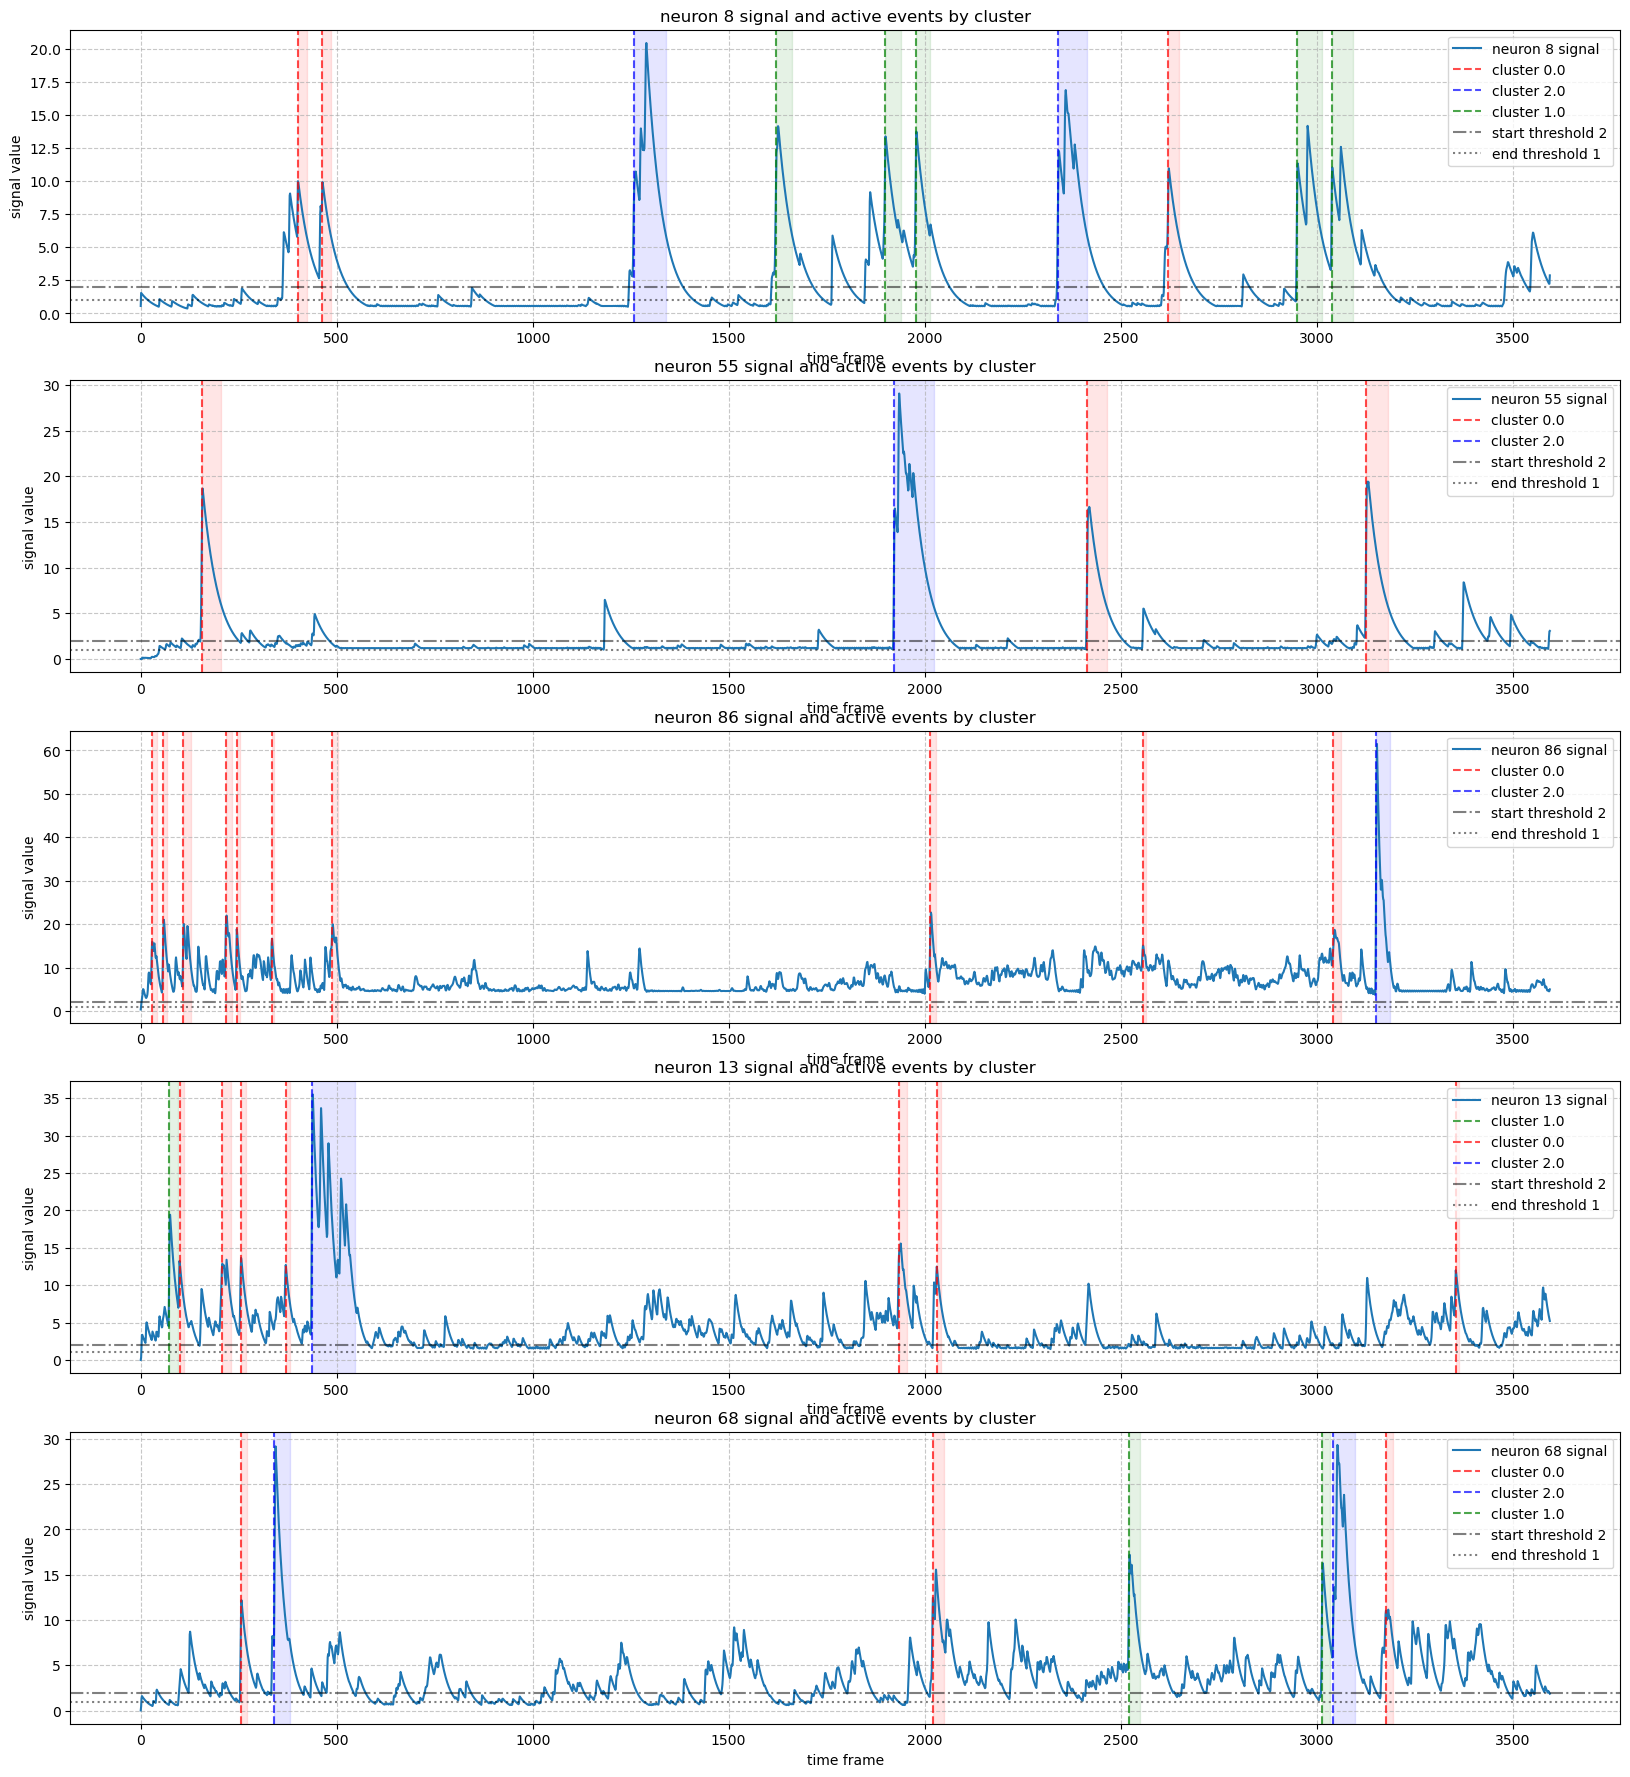

In [20]:
# Create a color mapping dictionary for different cluster_label values.
# Adjust the color list or add more colors as needed.
cluster_colors = {
    0: 'r',  # Use red for class 0.
    1: 'g',  # Use green for class 1.
    2: 'b',  # Use blue for class 2.
    3: 'm',  # Use magenta for class 3.
    4: 'c',  # Use cyan for class 4.
    5: 'y'   # Use yellow for class 5.
}

# Ensure that result_df and events_df are correctly linked.
# Create a mapping based on their shared event order.
# Ensure that events_df has an event_id column.
if 'event_id' not in events_df.columns:
    # Add event_id to events_df, assuming the same order as result_df.
    events_df = events_df.copy()
    events_df['event_id'] = result_df['event_id']

# Create a mapping from event IDs to cluster_label.
cluster_map = dict(zip(result_df['event_id'], result_df['cluster_label']))

# Plot the selected neurons' signals and event onsets.
plt.figure(figsize=(20, 22)) 

for i, neuron_id in enumerate(selected_neuron_ids, 1):
    # Get this neuron's signal data.
    neuron_signal = resized_df_signal_neuron_raw[neuron_id].values
    # Get all events for this neuron.
    neuron_events = events_df[events_df['neuron_id'] == neuron_id].copy()
    
    # Add cluster_label to each event.
    neuron_events['cluster_label'] = neuron_events['event_id'].map(cluster_map)
    
    # Create a subplot.
    plt.subplot(len(selected_neuron_ids), 1, i)
    # Plot the signal trace.
    plt.plot(neuron_signal, label=f'neuron {neuron_id} signal')
    
    # Track legend labels already added to avoid duplicates.
    added_labels = set()
    
    # Mark event onsets and intervals using colors determined by cluster_label.
    for _, event in neuron_events.iterrows():
        cluster_label = event['cluster_label']
        # Get the color for this cluster label.
        color = cluster_colors.get(cluster_label, 'k')  # Default to black.
        
        # Draw vertical lines at event onsets.
        label = f'cluster {cluster_label}' if f'cluster {cluster_label}' not in added_labels else ""
        plt.axvline(x=event['start_frame'], color=color, linestyle='--', alpha=0.7, label=label)
        if label:
            added_labels.add(label)
        
        # Mark the event duration intervals.
        plt.axvspan(event['start_frame'], event['end_frame'], color=color, alpha=0.1)
    
    # Add threshold lines.
    plt.axhline(y=2, color='k', linestyle='-.', alpha=0.5, label='start threshold 2')
    plt.axhline(y=1, color='k', linestyle=':', alpha=0.5, label='end threshold 1')
    
    # Set plot properties.
    plt.title(f'neuron {neuron_id} signal and active events by cluster')
    plt.xlabel('time frame')
    plt.ylabel('signal value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
plt.savefig(path_save + r'\intensity single and active events by cluster.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\intensity single and active events by cluster.png', format='png', dpi=300, bbox_inches='tight')

plt.show()

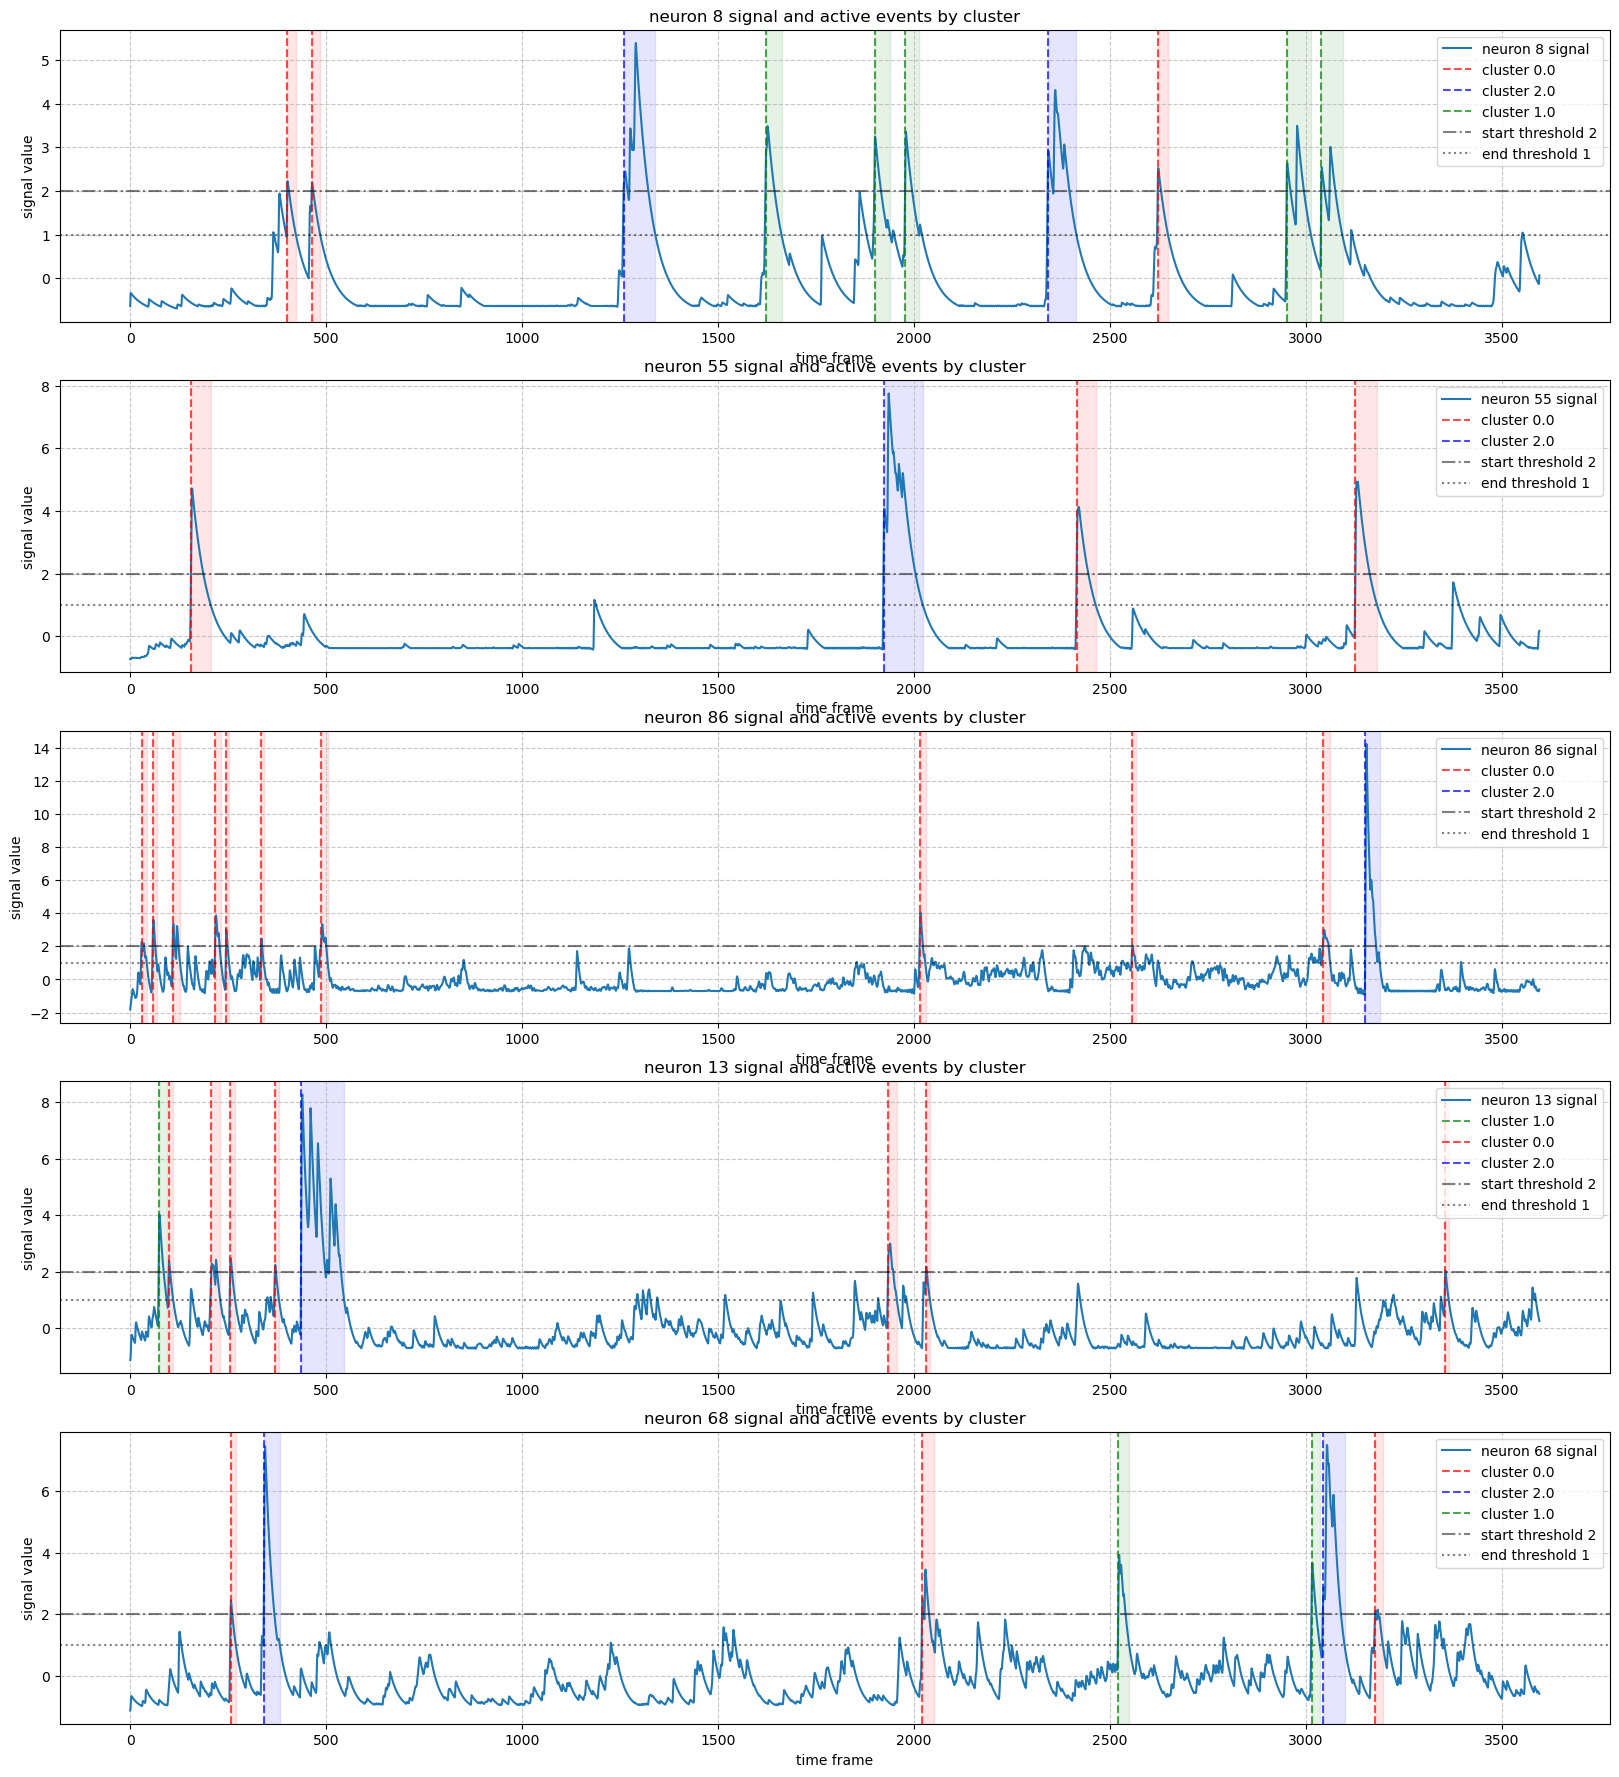

In [21]:
# Plot the selected neurons' signals and event onsets.
plt.figure(figsize=(20, 22)) 

for i, neuron_id in enumerate(selected_neuron_ids, 1):
    # Get this neuron's signal data.
    neuron_signal = resized_df_signal_neuron[neuron_id].values
    # Get all events for this neuron.
    neuron_events = events_df[events_df['neuron_id'] == neuron_id].copy()
    
    # Add cluster_label to each event.
    neuron_events['cluster_label'] = neuron_events['event_id'].map(cluster_map)
    
    # Create a subplot.
    plt.subplot(len(selected_neuron_ids), 1, i)
    # Plot the signal trace.
    plt.plot(neuron_signal, label=f'neuron {neuron_id} signal')
    
    # Track legend labels already added to avoid duplicates.
    added_labels = set()
    
    # Mark event onsets and intervals using colors determined by cluster_label.
    for _, event in neuron_events.iterrows():
        cluster_label = event['cluster_label']
        # Get the color for this cluster label.
        color = cluster_colors.get(cluster_label, 'k')  # Default to black.
        
        # Draw vertical lines at event onsets.
        label = f'cluster {cluster_label}' if f'cluster {cluster_label}' not in added_labels else ""
        plt.axvline(x=event['start_frame'], color=color, linestyle='--', alpha=0.7, label=label)
        if label:
            added_labels.add(label)
        
        # Mark the event duration intervals.
        plt.axvspan(event['start_frame'], event['end_frame'], color=color, alpha=0.1)
    
    # Add threshold lines.
    plt.axhline(y=2, color='k', linestyle='-.', alpha=0.5, label='start threshold 2')
    plt.axhline(y=1, color='k', linestyle=':', alpha=0.5, label='end threshold 1')
    
    # Set plot properties.
    plt.title(f'neuron {neuron_id} signal and active events by cluster')
    plt.xlabel('time frame')
    plt.ylabel('signal value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
plt.savefig(path_save + r'\normed intensity single and active events by cluster.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\normed intensity single and active events by cluster.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

Created 9480 neuronal signal segments.
Linked cluster information for 753 events.

Cluster-label proportions:
  Unlabeled (empty): 91.37%
  Label 0: 2.08%
  Label 1: 2.81%
  Label 2: 3.74%


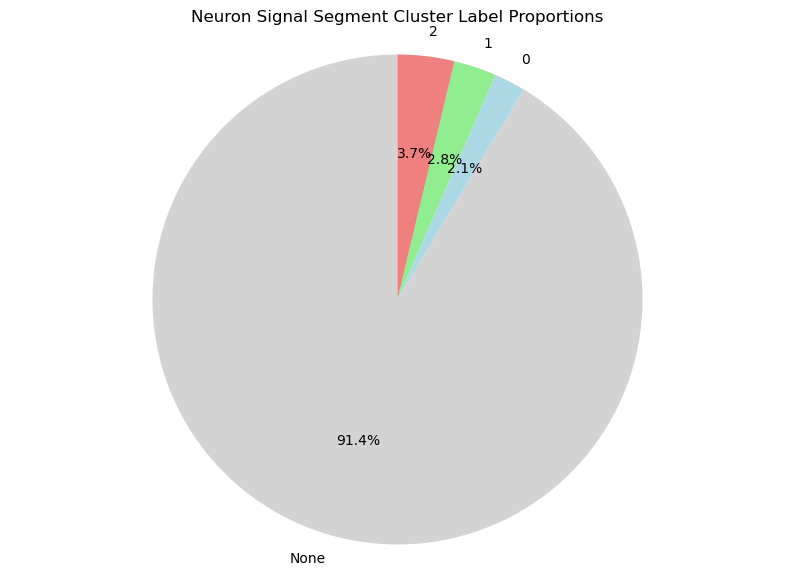

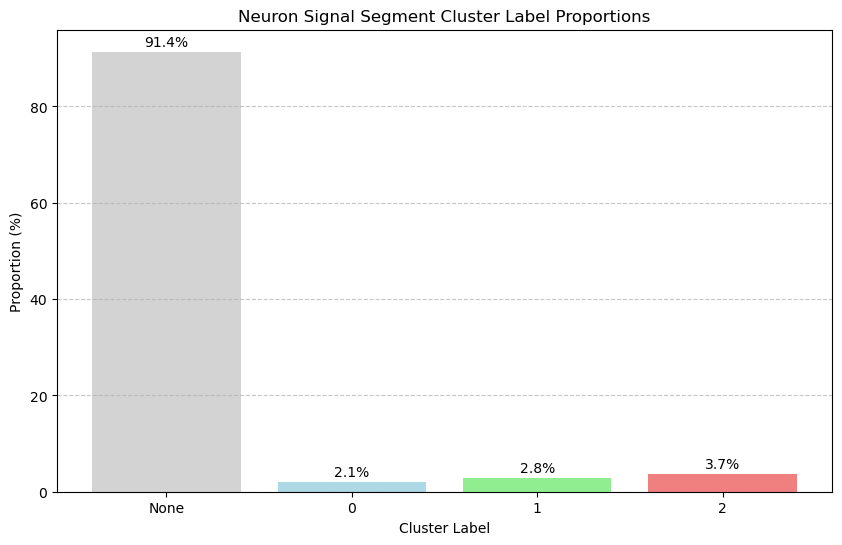

In [22]:
# 1. Divide resized_df_signal_neuron into 3-second (30-frame) segments.

def segment_neuron_signals(resized_df_signal_neuron, segment_duration_frames=30):
    """
    Divide neuronal signals into segments of the specified frame count.
    """
    total_frames = len(resized_df_signal_neuron)
    # Compute the segment count, counting the final incomplete segment as a full 30-frame segment.
    num_segments = (total_frames + segment_duration_frames - 1) // segment_duration_frames
    
    segments = []
    neuron_ids = resized_df_signal_neuron.columns.tolist()
    
    # Create segment information for each neuron.
    for neuron_id in neuron_ids:
        for seg_idx in range(num_segments):
            seg_start = seg_idx * segment_duration_frames
            seg_end = seg_start + segment_duration_frames - 1
            # Ensure that the last segment's end frame does not exceed the total frame count.
            seg_end = min(seg_end, total_frames - 1)
            
            segments.append({
                'neuron_id': neuron_id,
                'segment_idx': seg_idx,
                'seg_start_frame': seg_start,
                'seg_end_frame': seg_end,
                'seg_mid_frame': (seg_start + seg_end) // 2,
                'cluster_label': None  # Initialize to None to indicate no assignment.
            })
    
    return pd.DataFrame(segments)

# 2. Link event information and clustering results.

def merge_event_cluster_info(events_df, result_df):
    """
    Merge event information and clustering results.
    """
    # Ensure that event_id links the two DataFrames correctly.
    # First select the required columns from events_df.
    events_subset = events_df[['neuron_id', 'start_frame', 'end_frame']].copy()
    events_subset['event_id'] = events_subset.index  # Use the index as event_id.
    
    # Select cluster labels from result_df.
    result_subset = result_df[['event_id', 'cluster_label']].copy()
    
    # Merge the two DataFrames.
    merged_events = pd.merge(events_subset, result_subset, on='event_id', how='left')
    
    # Compute the duration of each event in frames.
    merged_events['duration_frames'] = merged_events['end_frame'] - merged_events['start_frame']
    
    return merged_events

# 3. Assign events to segments.

def assign_events_to_segments(segments_df, merged_events_df, segment_duration_frames=30, threshold_ratio=0.5):
    """
    Assign an event to a segment if it covers more than the threshold fraction of the segment.
    """
    # Copy the original segment data to avoid modifying the source.
    assigned_segments = segments_df.copy()
    threshold_frames = segment_duration_frames * threshold_ratio
    
    # Create a dictionary for quick lookup of each neuron's segments.
    neuron_segments = {}
    for _, seg in assigned_segments.iterrows():
        neuron_id = seg['neuron_id']
        if neuron_id not in neuron_segments:
            neuron_segments[neuron_id] = []
        neuron_segments[neuron_id].append(seg)
    
    # Iterate over events and check whether each should be assigned to a segment.
    for _, event in merged_events_df.iterrows():
        neuron_id = event['neuron_id']
        event_start = event['start_frame']
        event_end = event['end_frame']
        cluster_label = event['cluster_label']
        
        # Skip events without cluster labels.
        if pd.isna(cluster_label):
            continue
        
        # Check whether this neuron has segments.
        if neuron_id not in neuron_segments:
            continue
        
        # Check the overlap between this event and each segment.
        for seg in neuron_segments[neuron_id]:
            seg_start = seg['seg_start_frame']
            seg_end = seg['seg_end_frame']
            
            # Compute the overlap interval.
            overlap_start = max(event_start, seg_start)
            overlap_end = min(event_end, seg_end)
            
            # If they overlap, compute the number of overlapping frames.
            if overlap_start < overlap_end:
                overlap_frames = overlap_end - overlap_start + 1
                
                # Assign the cluster label if the overlap exceeds the threshold.
                if overlap_frames >= threshold_frames:
                    # Update values in the original DataFrame.
                    mask = ((assigned_segments['neuron_id'] == neuron_id) & 
                            (assigned_segments['segment_idx'] == seg['segment_idx']))
                    assigned_segments.loc[mask, 'cluster_label'] = cluster_label
    
    return assigned_segments

# 4. Compute proportions of the different cluster labels.

def calculate_cluster_proportions(assigned_segments_df):
    """
    Compute proportions of the different cluster labels.
    """
    # Ensure that cluster_label is a string for counting.
    assigned_segments_df['cluster_label_str'] = assigned_segments_df['cluster_label'].apply(
        lambda x: 'None' if pd.isna(x) else str(int(x))
    )
    
    # Count each label.
    label_counts = assigned_segments_df['cluster_label_str'].value_counts()
    total_segments = len(assigned_segments_df)
    
    # Compute proportions.
    proportions = {}  
    for label, count in label_counts.items():
        proportions[label] = count / total_segments * 100
    
    # Include all possible labels, including those absent from the data.
    possible_labels = ['None', '0', '1', '2']
    for label in possible_labels:
        if label not in proportions:
            proportions[label] = 0
    
    # Sort by label.
    sorted_proportions = {k: proportions[k] for k in possible_labels}
    
    return sorted_proportions

# 5. Visualize summary statistics.

def visualize_cluster_proportions(proportions):
    """
    Visualize proportions of the different cluster labels.
    """
    labels = list(proportions.keys())
    values = list(proportions.values())
    
    # Create a pie chart.
    plt.figure(figsize=(10, 7))
    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, 
            colors=['lightgray', 'lightblue', 'lightgreen', 'lightcoral'])
    plt.title('Neuron Signal Segment Cluster Label Proportions')
    plt.axis('equal')  # Keep the pie chart circular.
    plt.show()
    
    # Create a bar chart.
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, values, color=['lightgray', 'lightblue', 'lightgreen', 'lightcoral'])
    plt.title('Neuron Signal Segment Cluster Label Proportions')
    plt.xlabel('Cluster Label')
    plt.ylabel('Proportion (%)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels to the bars.
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # plt.tight_layout()
    plt.show()

# Run the full workflow.
# 1. Create segments.
segments_df = segment_neuron_signals(resized_df_signal_neuron, segment_duration_frames=30)
print(f"Created {len(segments_df)} neuronal signal segments.")

# 2. Link event and cluster information.
merged_events_df = merge_event_cluster_info(events_df, result_df)
print(f"Linked cluster information for {len(merged_events_df)} events.")

# 3. Assign events to segments.
assigned_segments_df = assign_events_to_segments(
    segments_df, 
    merged_events_df, 
    segment_duration_frames=30, 
    threshold_ratio=0.5
)

# 4. Compute cluster-label proportions.
cluster_proportions = calculate_cluster_proportions(assigned_segments_df)

# 5. Print summary statistics.
print("\nCluster-label proportions:")
for label, proportion in cluster_proportions.items():
    if label == 'None':
        print(f"  Unlabeled (empty): {proportion:.2f}%")
    else:
        print(f"  Label {label}: {proportion:.2f}%")

# 6. Visualize the results.
visualize_cluster_proportions(cluster_proportions)

assigned_segments_df_events2 = assigned_segments_df.copy()

# Optionally save the results to a CSV file.
# assigned_segments_df_events2.to_csv('neuron_segments_with_cluster_labels.csv', index=False)

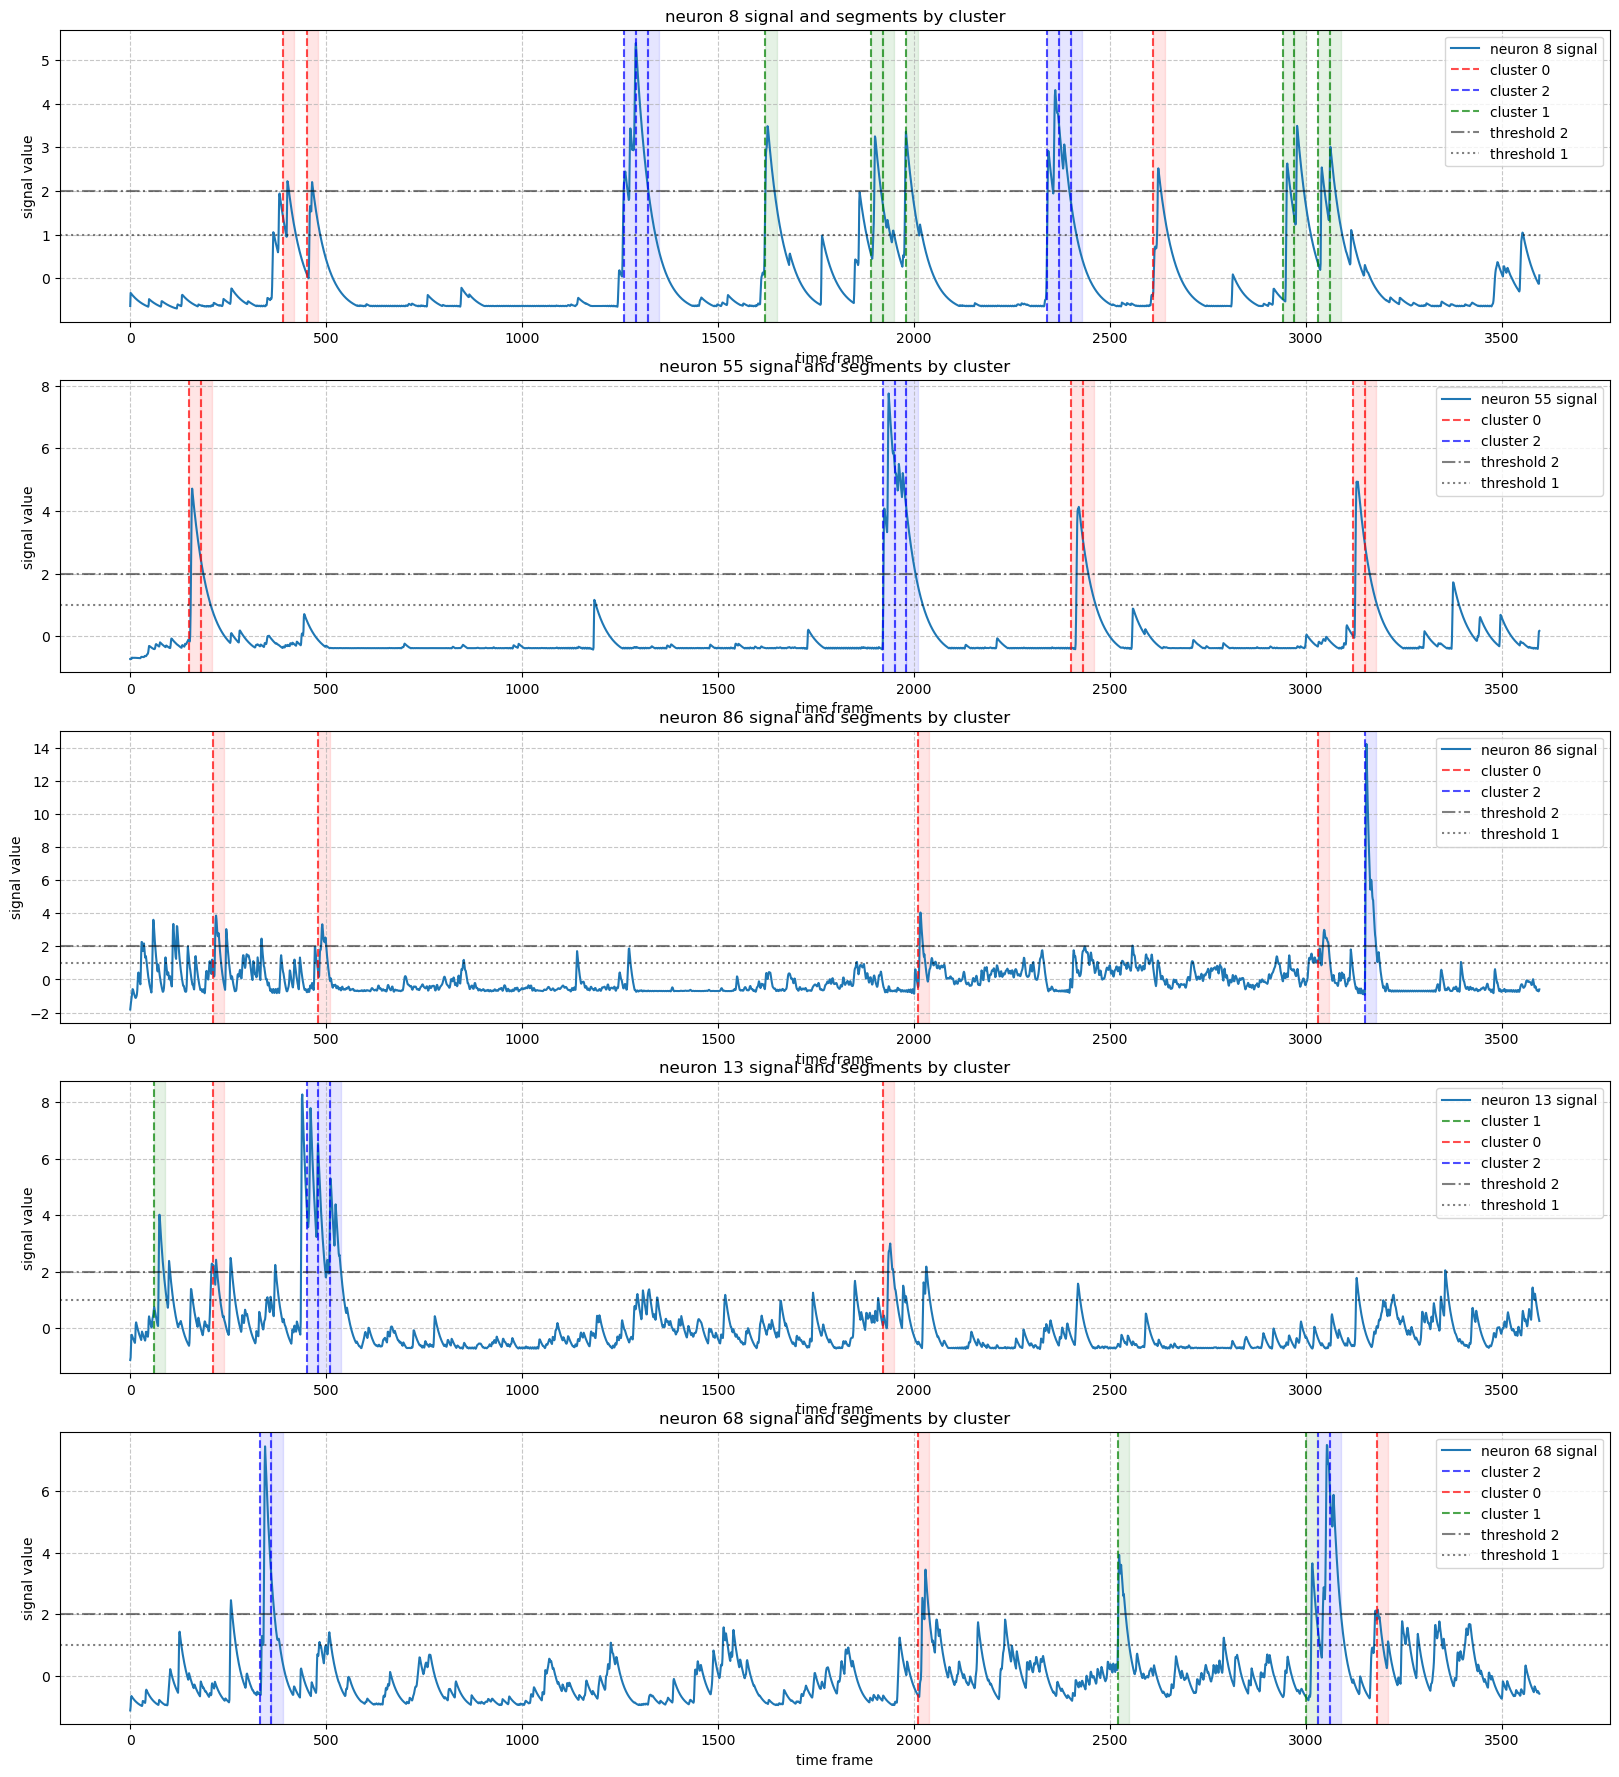

In [23]:
# Create a color mapping dictionary for different cluster_label values.
# Include only valid classes 0, 1, and 2; do not color none values.
cluster_colors = {
    0: 'r',   # Use red for class 0.
    1: 'g',   # Use green for class 1.
    2: 'b'    # Use blue for class 2.
}

# Plot the selected neurons' signals and event onsets.
plt.figure(figsize=(20, 22))

for i, neuron_id in enumerate(selected_neuron_ids, 1):
    # Get this neuron's signal data.
    neuron_signal = resized_df_signal_neuron[neuron_id].values
    # Get all frame segments for this neuron.
    neuron_segments = assigned_segments_df_events2[assigned_segments_df_events2['neuron_id'] == neuron_id].copy()
    
    # Create a subplot.
    plt.subplot(len(selected_neuron_ids), 1, i)
    # Plot the signal trace.
    plt.plot(neuron_signal, label=f'neuron {neuron_id} signal')
    
    # Track legend labels already added to avoid duplicates.
    added_labels = set()
    
    # Mark segment onsets and intervals using colors determined by cluster_label.
    for _, segment in neuron_segments.iterrows():
        cluster_label = segment['cluster_label']
        
        # Skip cluster_label values of none without adding color markers.
        if cluster_label is None or cluster_label == 'none':
            continue
        
        # Get the color for this cluster label.
        color = cluster_colors.get(cluster_label, 'k')  # Default to black.
        
        # Draw vertical lines at event onsets.
        label = f'cluster {cluster_label}' if f'cluster {cluster_label}' not in added_labels else ""
        plt.axvline(x=segment['seg_start_frame'], color=color, linestyle='--', alpha=0.7, label=label)
        if label:
            added_labels.add(label)
        
        # Mark segment duration intervals.
        plt.axvspan(segment['seg_start_frame'], segment['seg_end_frame'], color=color, alpha=0.1)
    
    # Add threshold lines if needed.
    plt.axhline(y=2, color='k', linestyle='-.', alpha=0.5, label='threshold 2')
    plt.axhline(y=1, color='k', linestyle=':', alpha=0.5, label='threshold 1')
    
    # Set plot properties.
    plt.title(f'neuron {neuron_id} signal and segments by cluster')
    plt.xlabel('time frame')
    plt.ylabel('signal value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)


# Adjust the layout and display the plot.
# plt.tight_layout()
plt.savefig(path_save + r'\normed intensity single and active events by cluster in single window.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\normed intensity single and active events by cluster in single window.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from scipy.integrate import simpson
from scipy.cluster.hierarchy import dendrogram, linkage

In [25]:
def calculate_standardized_area(events_df, resized_df_signal_neuron):
    """
    Compute the standardized area for each valid neuronal event (standardized area = area within the event / event duration).
    
    Parameters:
    events_df: neuronal events DataFrame requiring neuron_id, start_frame, end_frame, and duration_seconds columns.
    resized_df_signal_neuron: neuronal activity DataFrame indexed by frame, with neuron_id values as columns.
    
    Returns:
    events_with_area: DataFrame with added area and standardized_area columns.
    """
    # Ensure that events_df contains the required columns.
    required_columns = ['neuron_id', 'start_frame', 'end_frame', 'duration_seconds']
    for col in required_columns:
        if col not in events_df.columns:
            raise ValueError(f"events_df is missing a required column: {col}")
    
    # Create the results DataFrame.
    events_with_area = events_df.copy()
    events_with_area['area'] = 0.0
    events_with_area['standardized_area'] = 0.0
    
    # Iterate over events and compute area and standardized area.
    for idx, event in events_with_area.iterrows():
        neuron_id = event['neuron_id']
        start_frame = int(event['start_frame'])
        end_frame = int(event['end_frame'])
        duration_seconds = event['duration_seconds']
        
        # Ensure that the neuron ID exists in the signal data.
        if neuron_id not in resized_df_signal_neuron.columns:
            continue
        
        # Get the signal data for the event.
        try:
            # Ensure that frame indices are within the valid range.
            if start_frame >= len(resized_df_signal_neuron) or end_frame >= len(resized_df_signal_neuron):
                continue
            
            signal_data = resized_df_signal_neuron.loc[start_frame:end_frame, neuron_id]
            
            # Compute the area using Simpson's rule.
            if len(signal_data) > 1:
                area = simpson(signal_data, dx=1)  # Assume a frame interval of 1.
                events_with_area.at[idx, 'area'] = area
                
                # Compute standardized area (area/duration).
                if duration_seconds > 0:
                    events_with_area.at[idx, 'standardized_area'] = area / duration_seconds
        except Exception as e:
            print(f"Error computing event area for neuron {neuron_id}: {e}")
            continue
    
    return events_with_area


def cluster_neurons_by_hierarchy(resized_df_signal_neuron):
    """
    Apply Ward hierarchical clustering by neuron_id to divide neurons into two clusters.
    Use each neuron's values in resized_df_signal_neuron as clustering features.
    
    Parameters:
    resized_df_signal_neuron: DataFrame containing neuronal activity signals.
    
    Returns:
    neuron_clusters: DataFrame containing neuron IDs and their cluster labels.
    """
    # Get all neuron IDs.
    neuron_ids = resized_df_signal_neuron.columns.tolist()
    
    # Extract each neuron's full time series as its features.
    # Use each neuron's full signal directly as its features.
    # Large datasets may require dimensionality reduction first.
    neuron_features = []
    valid_neuron_ids = []
    
    for neuron_id in neuron_ids:
        try:
            # Get this neuron's full signal.
            neuron_signal = resized_df_signal_neuron[neuron_id].values.reshape(1, -1)
            
            # Check that there are enough data points.
            if len(neuron_signal[0]) > 0:
                neuron_features.append(neuron_signal[0])
                valid_neuron_ids.append(neuron_id)
        except Exception as e:
            print(f"Error processing neuron {neuron_id}: {e}")
            continue
    
    if not valid_neuron_ids:
        raise ValueError("No valid neuronal data found for clustering.")
    
    # Perform hierarchical clustering.
    hierarchical_cluster = AgglomerativeClustering(
        n_clusters=2, 
        metric='euclidean', 
        linkage='ward'
    )
    cluster_labels = hierarchical_cluster.fit_predict(neuron_features)
    
    # Create the neuron clustering results DataFrame.
    neuron_clusters = pd.DataFrame({
        'neuron_id': valid_neuron_ids,
        'cluster_label': cluster_labels
    })
    
    # Visualize the hierarchical clustering results.
    plt.figure(figsize=(10, 6))
    linked = linkage(neuron_features, 'ward')
    dendrogram(linked, 
               orientation='top',
               labels=valid_neuron_ids,
               distance_sort='descending',
               show_leaf_counts=True)
    plt.title('neuron hierarchical clustering')
    plt.xlabel('neuron id')
    plt.ylabel('distance')
    # plt.tight_layout()
    # plt.savefig('neuron_hierarchical_clustering.png')
    plt.savefig(path_save + r'\duration neuron hierarchical clustering.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(path_save + r'\duration neuron hierarchical clustering.png', format='png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return neuron_clusters


def filter_single_event_neurons(events_with_clusters):
    """
    Exclude neurons with only one event.
    
    Parameters:
    events_with_clusters: DataFrame containing neuronal events, standardized areas, and cluster labels.
    
    Returns:
    filtered_events: DataFrame after excluding neurons with only one event.
    multi_event_neurons: list of IDs of neurons with multiple events.
    """
    # Count events per neuron.
    neuron_event_counts = events_with_clusters['neuron_id'].value_counts()
    
    # Select neurons with more than 1 event.
    multi_event_neurons = neuron_event_counts[neuron_event_counts > 1].index.tolist()
    
    # Filter the DataFrame to retain only neurons with multiple events.
    filtered_events = events_with_clusters[events_with_clusters['neuron_id'].isin(multi_event_neurons)]
    
    print(f"Original neuron count: {len(neuron_event_counts)}")
    print(f"Neuron count after excluding single-event neurons: {len(multi_event_neurons)}")
    print(f"Retained event count: {len(filtered_events)}")
    
    return filtered_events, multi_event_neurons


def calculate_cluster_statistics(events_with_clusters):
    """
    Compute the population mean and standard deviation of event durations and standardized areas separately for the two classes.
    
    Parameters:
    events_with_clusters: DataFrame containing neuronal events, standardized areas, and cluster labels.
    
    Returns:
    cluster_stats: dictionary of statistics for each class.
    """
    cluster_stats = {}
    
    # Iterate over cluster labels.
    for cluster_label in events_with_clusters['cluster_label'].unique():
        if pd.isna(cluster_label):
            continue
        
        # Get all events in the current cluster.
        cluster_events = events_with_clusters[events_with_clusters['cluster_label'] == cluster_label]
        
        # Compute statistics.
        duration_mean = cluster_events['duration_seconds'].mean()
        duration_std = cluster_events['duration_seconds'].std()
        std_area_mean = cluster_events['standardized_area'].mean()
        std_area_std = cluster_events['standardized_area'].std()
        
        # Store statistics.
        cluster_stats[int(cluster_label)] = {
            'duration_mean': duration_mean,
            'duration_std': duration_std,
            'std_area_mean': std_area_mean,
            'std_area_std': std_area_std,
            'event_count': len(cluster_events),
            'neuron_count': cluster_events['neuron_id'].nunique()
        }
    
    return cluster_stats


def z_score_normalize_by_cluster(events_with_clusters, cluster_stats):
    """
    Z-score standardize durations and standardized areas using the population mean and standard deviation of their respective classes.
    Standardized value = (original value - class population mean) / class population standard deviation.
    
    Parameters:
    events_with_clusters: DataFrame containing neuronal events, standardized areas, and cluster labels.
    cluster_stats: dictionary of statistics for each class.
    
    Returns:
    events_normalized: DataFrame with added columns for Z-score-standardized durations and standardized areas.
    """
    events_normalized = events_with_clusters.copy()
    events_normalized['duration_zscore'] = np.nan
    events_normalized['std_area_zscore'] = np.nan
    
    # Iterate over events and apply Z-score standardization.
    for idx, event in events_normalized.iterrows():
        cluster_label = event['cluster_label']
        
        if pd.isna(cluster_label):
            continue
        
        cluster_label = int(cluster_label)
        
        if cluster_label not in cluster_stats:
            continue
        
        # Get statistics for the current cluster.
        stats = cluster_stats[cluster_label]
        
        # Apply Z-score standardization to duration.
        if stats['duration_std'] > 0:
            events_normalized.at[idx, 'duration_zscore'] = (
                event['duration_seconds'] - stats['duration_mean']
            ) / stats['duration_std']
        
        # Apply Z-score standardization to standardized area.
        if stats['std_area_std'] > 0:
            events_normalized.at[idx, 'std_area_zscore'] = (
                event['standardized_area'] - stats['std_area_mean']
            ) / stats['std_area_std']
    
    return events_normalized


def perform_kmeans_clustering(events_normalized, k_range=range(2, 7)):
    """
    Perform K-means clustering on standardized features with manually selected k=3, which better matches the expected clustering results in practice.
    
    Parameters:
    events_normalized: DataFrame containing Z-score-standardized duration and standardized-area columns.
    k_range: range of k values, defaulting to 2 through 6.
    
    Returns:
    events_with_kmeans: DataFrame with an added K-means cluster-label column.
    best_k: manually selected as 3 to better match the expected clustering results in practice.
    """
    # Prepare features for clustering.
    features = events_normalized[['duration_zscore', 'std_area_zscore']].dropna()
    
    if len(features) < 2:
        raise ValueError("Insufficient valid data for K-means clustering.")
    
    # Store evaluation metrics for different k values.
    sse = []  # Within-cluster sum of squares
    silhouette_scores = []
    
    # Perform K-means clustering and compute evaluation metrics.
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(features)
        
        # Compute the within-cluster sum of squares.
        sse.append(kmeans.inertia_)
        
        # Compute the silhouette score.
        if k > 1:  # Silhouette scores require at least 2 clusters.
            silhouette_avg = silhouette_score(features, cluster_labels)
            silhouette_scores.append(silhouette_avg)
        else:
            silhouette_scores.append(0)
    
    # Visualize evaluation metrics.
    plt.figure(figsize=(12, 5))
    
    # Plot the within-cluster sum of squares (elbow method).
    plt.subplot(1, 2, 1)
    plt.plot(k_range, sse, 'o-')
    plt.title('K-means clustering WCSS')
    plt.xlabel('k value')
    plt.ylabel('WCSS')
    plt.grid(True)
    
    # Plot silhouette scores.
    plt.subplot(1, 2, 2)
    plt.plot(k_range, silhouette_scores, 'o-')
    plt.title('K-means clustering silhouette score')
    plt.xlabel('k value')
    plt.ylabel('silhouette score')
    plt.grid(True)
    
    # plt.tight_layout()
    # plt.savefig('kmeans_evaluation_metrics.png')
    plt.savefig(path_save + r'\duration WCSS and silhouette score.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(path_save + r'\duration WCSS and silhouette score.png', format='png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # In practice, k=3 better matches the expected clustering results and is selected manually.
    # best_k = k_range[np.argmax(silhouette_scores)]
    best_k = 3
    
    # Perform K-means clustering with the manually selected k=3.
    best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    best_cluster_labels = best_kmeans.fit_predict(features)
    
    # Create the results DataFrame.
    events_with_kmeans = events_normalized.copy()
    
    # Add cluster labels to the results DataFrame.
    temp_df = pd.DataFrame({
        'kmeans_cluster': best_cluster_labels
    }, index=features.index)
    
    events_with_kmeans = pd.merge(
        events_with_kmeans, 
        temp_df[['kmeans_cluster']], 
        left_index=True, 
        right_index=True, 
        how='left'
    )
    
    # Visualize clustering results for the manually selected k=3.
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        features['duration_zscore'], 
        features['std_area_zscore'], 
        c=best_cluster_labels, 
        cmap='viridis',
        s=50,
        alpha=0.7
    )
    plt.scatter(
        best_kmeans.cluster_centers_[:, 0], 
        best_kmeans.cluster_centers_[:, 1], 
        c='red', 
        marker='x', 
        s=200, 
        label='cluster center'
    )
    plt.title(f'K-means clustering result k={best_k}')
    plt.xlabel('standardized duration Z-score')
    plt.ylabel('standardized area Z-score')
    plt.colorbar(scatter, label='cluster label')
    plt.legend()
    plt.grid(True)
    # plt.tight_layout()
    # plt.savefig(f'kmeans_clustering_result_k{best_k}.png')
    plt.savefig(path_save + r'\duration scatter.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(path_save + r'\duration scatter.png', format='png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return events_with_kmeans, best_k


def analyze_neuron_events(events_df, resized_df_signal_neuron):
    """
    Main analysis function integrating the full workflow.
    
    Parameters:
    events_df: DataFrame containing neuronal event information.
    resized_df_signal_neuron: DataFrame containing neuronal activity signals.
    
    Returns:
    Dictionary containing all analysis results.
    """
    print("Starting the neuronal event analysis workflow...")
    
    # Step 1: Compute standardized area.
    print("Step 1: Computing standardized areas for neuronal events...")
    events_with_area = calculate_standardized_area(events_df, resized_df_signal_neuron)
    
    # Step 2: Perform hierarchical clustering of neurons.
    print("Step 2: Performing hierarchical clustering of neurons...")
    neuron_clusters = cluster_neurons_by_hierarchy(resized_df_signal_neuron)
    
    # # Convert neuron IDs to the same type for merging.
    # events_with_area['neuron_id'] = events_with_area['neuron_id'].astype(str)
    # neuron_clusters['neuron_id'] = neuron_clusters['neuron_id'].astype(str)
    
    # Merge clustering results into the events DataFrame.
    events_with_clusters = pd.merge(
        events_with_area, 
        neuron_clusters, 
        on='neuron_id', 
        how='left'
    )
    
    # Step 3: Exclude neurons with only one event.
    print("Step 3: Excluding neurons with only one event...")
    filtered_events, multi_event_neurons = filter_single_event_neurons(events_with_clusters)
    
    # Step 4: Compute statistics for each class.
    print("Step 4: Computing population means and standard deviations for each class...")
    cluster_stats = calculate_cluster_statistics(filtered_events)
    print("Class statistics:")
    for cluster, stats in cluster_stats.items():
        print(f"Class {cluster}:")
        print(f"  Neuron count: {stats['neuron_count']}")
        print(f"  Event count: {stats['event_count']}")
        print(f"  Mean duration: {stats['duration_mean']:.4f} seconds")
        print(f"  Duration standard deviation: {stats['duration_std']:.4f} seconds")
        print(f"  Mean standardized area: {stats['std_area_mean']:.4f}")
        print(f"  Standardized-area standard deviation: {stats['std_area_std']:.4f}")
    
    # Step 5: Apply Z-score standardization within each class.
    print("Step 5: Applying Z-score standardization within each class...")
    events_normalized = z_score_normalize_by_cluster(events_with_clusters, cluster_stats)

    
    # Step 6: Perform K-means clustering using standardized features.
    print("Step 6: Performing K-means clustering using standardized features...")
    events_with_kmeans, best_k = perform_kmeans_clustering(events_normalized)
    print(f"Optimal k: {best_k}")
    
    # Save results.
    # print("Saving analysis results...")
    # events_with_kmeans.to_csv('neuron_event_analysis_results.csv', index=False)
    # neuron_clusters.to_csv('neuron_hierarchical_clusters.csv', index=False)
    # filtered_events.to_csv('filtered_events.csv', index=False)
    
    # Save class statistics.
    stats_df = pd.DataFrame.from_dict(cluster_stats, orient='index')
    stats_df.index.name = 'cluster_label'
    # stats_df.to_csv('cluster_statistics.csv')
    
    print("Analysis workflow complete!")
    
    return {
        'events_with_kmeans': events_with_kmeans,
        'neuron_clusters': neuron_clusters,
        'filtered_events': filtered_events,
        'cluster_stats': cluster_stats,
        'best_k': best_k
        ,
        'events_normalized': events_normalized
    }


Starting the neuronal event analysis workflow...
Step 1: Computing standardized areas for neuronal events...
Step 2: Performing hierarchical clustering of neurons...


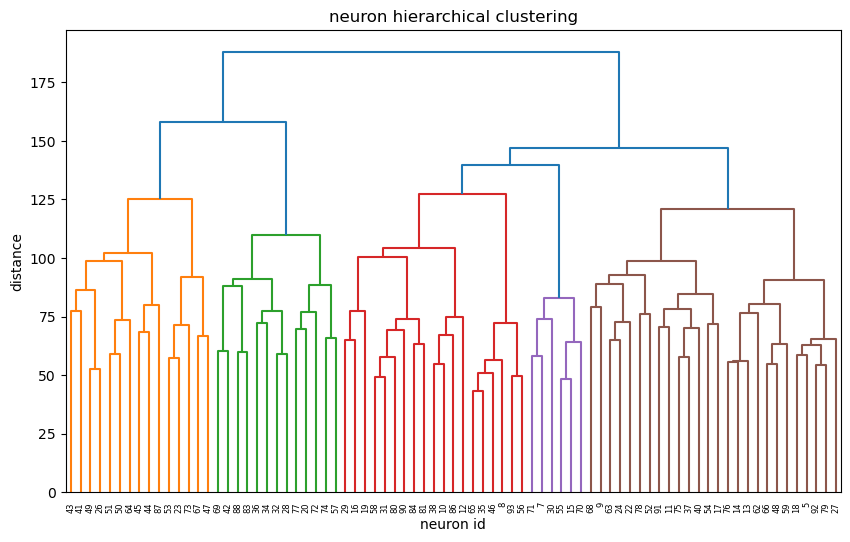

Step 3: Excluding neurons with only one event...
Original neuron count: 79
Neuron count after excluding single-event neurons: 79
Retained event count: 753
Step 4: Computing population means and standard deviations for each class...
Class statistics:
Class 1:
  Neuron count: 51
  Event count: 491
  Mean duration: 3.2998 seconds
  Duration standard deviation: 2.4621 seconds
  Mean standardized area: 21.9494
  Standardized-area standard deviation: 6.9265
Class 0:
  Neuron count: 28
  Event count: 262
  Mean duration: 3.0645 seconds
  Duration standard deviation: 2.3067 seconds
  Mean standardized area: 23.2481
  Standardized-area standard deviation: 8.6906
Step 5: Applying Z-score standardization within each class...
Step 6: Performing K-means clustering using standardized features...


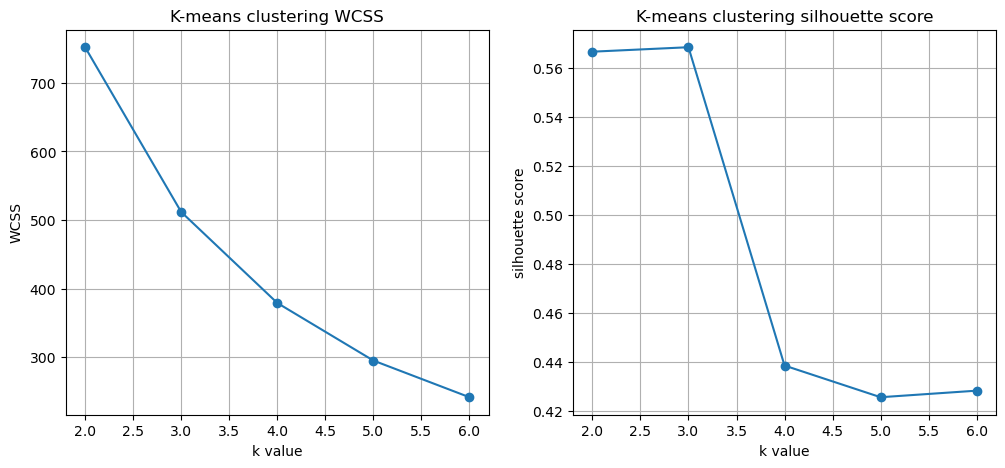

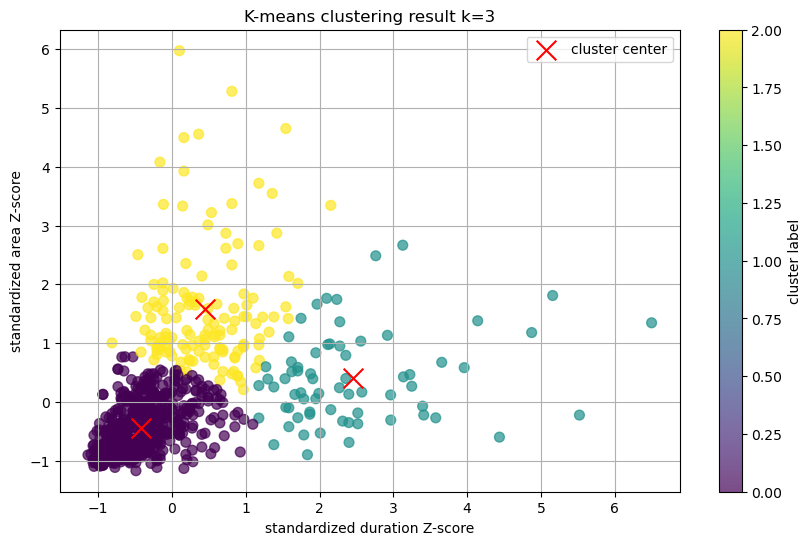

Optimal k: 3
Analysis workflow complete!


In [26]:
result = analyze_neuron_events(events_df, resized_df_signal_neuron)

In [27]:
# Get the dataset.
df = result['events_with_kmeans']

# Inspect basic dataset information.
print(f"Original dataset shape: {df.shape}")
print(f"Unique kmeans_cluster values: {df['kmeans_cluster'].unique()}")

# Step 1: Compute mean std_area_zscore and duration_zscore for each class.
cluster_means = df.groupby('kmeans_cluster').agg({
    'std_area_zscore': 'mean',
    'duration_zscore': 'mean'
}).reset_index()

print("\nMean statistics by class:")
print(cluster_means)

# Step 2: Determine the new labels.
label_mapping = {}

# Sum the two metrics to identify the class with the smallest means for both.
cluster_means['sum_zscores'] = cluster_means['std_area_zscore'] + cluster_means['duration_zscore']

# Find the class with the smallest means for both metrics (minimum sum_zscores).
min_sum_label = cluster_means.loc[cluster_means['sum_zscores'].idxmin(), 'kmeans_cluster']
label_mapping[min_sum_label] = 0

# Find the class with the highest mean duration_zscore, excluding classes already assigned.
remaining_clusters = cluster_means[cluster_means['kmeans_cluster'] != min_sum_label]
max_duration_label = remaining_clusters.loc[remaining_clusters['duration_zscore'].idxmax(), 'kmeans_cluster']
label_mapping[max_duration_label] = 2

# Find the class with the highest mean duration_zscore (the remaining class).
last_cluster = remaining_clusters[remaining_clusters['kmeans_cluster'] != max_duration_label]['kmeans_cluster'].iloc[0]
label_mapping[last_cluster] = 1

print("\nLabel mapping:")
for original, new in label_mapping.items():
    print(f"Original label {original} → new label {new}")

# Step 3: Apply the new labels.
result['events_with_kmeans']['kmeans_cluster'] = result['events_with_kmeans']['kmeans_cluster'].map(label_mapping)

# Verify the results.
new_cluster_means = result['events_with_kmeans'].groupby('kmeans_cluster').agg({
    'std_area_zscore': 'mean',
    'duration_zscore': 'mean'
}).reset_index()

print("\nClass means after relabeling:")
print(new_cluster_means.sort_values('kmeans_cluster'))

print("\nDone! kmeans_cluster has been reassigned as specified.")
print("New kmeans_cluster distribution:")
print(result['events_with_kmeans']['kmeans_cluster'].value_counts().sort_index())

Original dataset shape: (753, 13)
Unique kmeans_cluster values: [2 0 1]

Mean statistics by class:
   kmeans_cluster  std_area_zscore  duration_zscore
0               0        -0.444449        -0.415574
1               1         0.408273         2.452376
2               2         1.575148         0.445056

Label mapping:
Original label 0 → new label 0
Original label 1 → new label 2
Original label 2 → new label 1

Class means after relabeling:
   kmeans_cluster  std_area_zscore  duration_zscore
0               0        -0.444449        -0.415574
1               1         1.575148         0.445056
2               2         0.408273         2.452376

Done! kmeans_cluster has been reassigned as specified.
New kmeans_cluster distribution:
kmeans_cluster
0    548
1    137
2     68
Name: count, dtype: int64


In [28]:
result_events_df = result['events_with_kmeans']


In [29]:
resized_df_signal_neuron

unit_id,5,7,8,9,10,11,12,13,14,15,...,81,83,84,86,87,88,90,91,92,93
0,-0.723100,-1.002202,-0.632711,-1.476836,-1.307050,-0.804238,-0.387874,-1.122631,-0.381215,-1.006963,...,-0.728367,-1.075804,-1.000174,-1.812256,-1.003287,-0.706662,-1.200203,-0.954456,-0.734023,-1.029425
1,-0.457998,-0.963492,-0.334249,-1.459438,-1.307050,-0.804238,0.043052,-1.033183,-0.350680,-1.006963,...,-0.728367,-1.075804,-0.968027,-1.565216,-0.989511,-0.686314,-1.200203,-0.535452,-0.734023,-1.029425
2,-0.301136,-0.926128,-0.345774,-1.435785,-1.307050,-0.804238,0.016123,-0.650130,-0.315675,-1.006963,...,-0.728367,-1.075804,-0.924992,-1.373014,-0.965412,-0.687145,-1.200203,-0.020702,-0.734023,-1.029425
3,-0.268054,-0.917369,-0.357017,-1.437771,-1.307050,-0.804238,-0.009889,-0.240051,-0.311831,-0.962215,...,-0.728367,-1.051796,-0.877448,-1.204919,-0.943678,-0.687951,-1.200203,0.427455,-0.734023,-1.029425
4,-0.274757,-0.922017,-0.367982,-1.439660,-1.307050,-0.784912,-0.035016,-0.232339,-0.313052,-0.687688,...,-0.728367,-1.013914,-0.812544,-1.006238,-0.930201,-0.688734,-1.200203,0.780092,-0.734023,-1.029425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3591,-0.266556,-0.560827,-0.088766,0.283879,0.657696,1.693310,0.277804,0.541237,-0.313719,-0.248110,...,1.534617,-0.244539,-0.594393,-0.636779,-0.637938,-0.460441,0.177294,-0.304684,0.018168,1.664396
3592,-0.283229,-0.583684,-0.106327,0.198727,0.577720,1.624684,0.242885,0.462132,-0.314909,-0.282948,...,1.458333,-0.284573,-0.550264,-0.675501,-0.638453,-0.464928,0.181907,-0.236043,-0.006615,1.603292
3593,-0.299396,-0.605373,-0.123455,0.117692,0.498702,1.557943,0.270689,0.386789,-0.316079,-0.302982,...,1.384620,-0.322678,-0.523026,-0.717700,-0.626747,-0.472222,0.138654,-0.264411,-0.030582,1.543575
3594,-0.315074,-0.625955,-0.124438,0.040577,0.422996,1.493036,0.715488,0.315027,-0.317230,-0.236880,...,1.313392,-0.358949,-0.521644,-0.689701,-0.634498,-0.479302,0.096755,-0.299193,-0.053759,1.485212


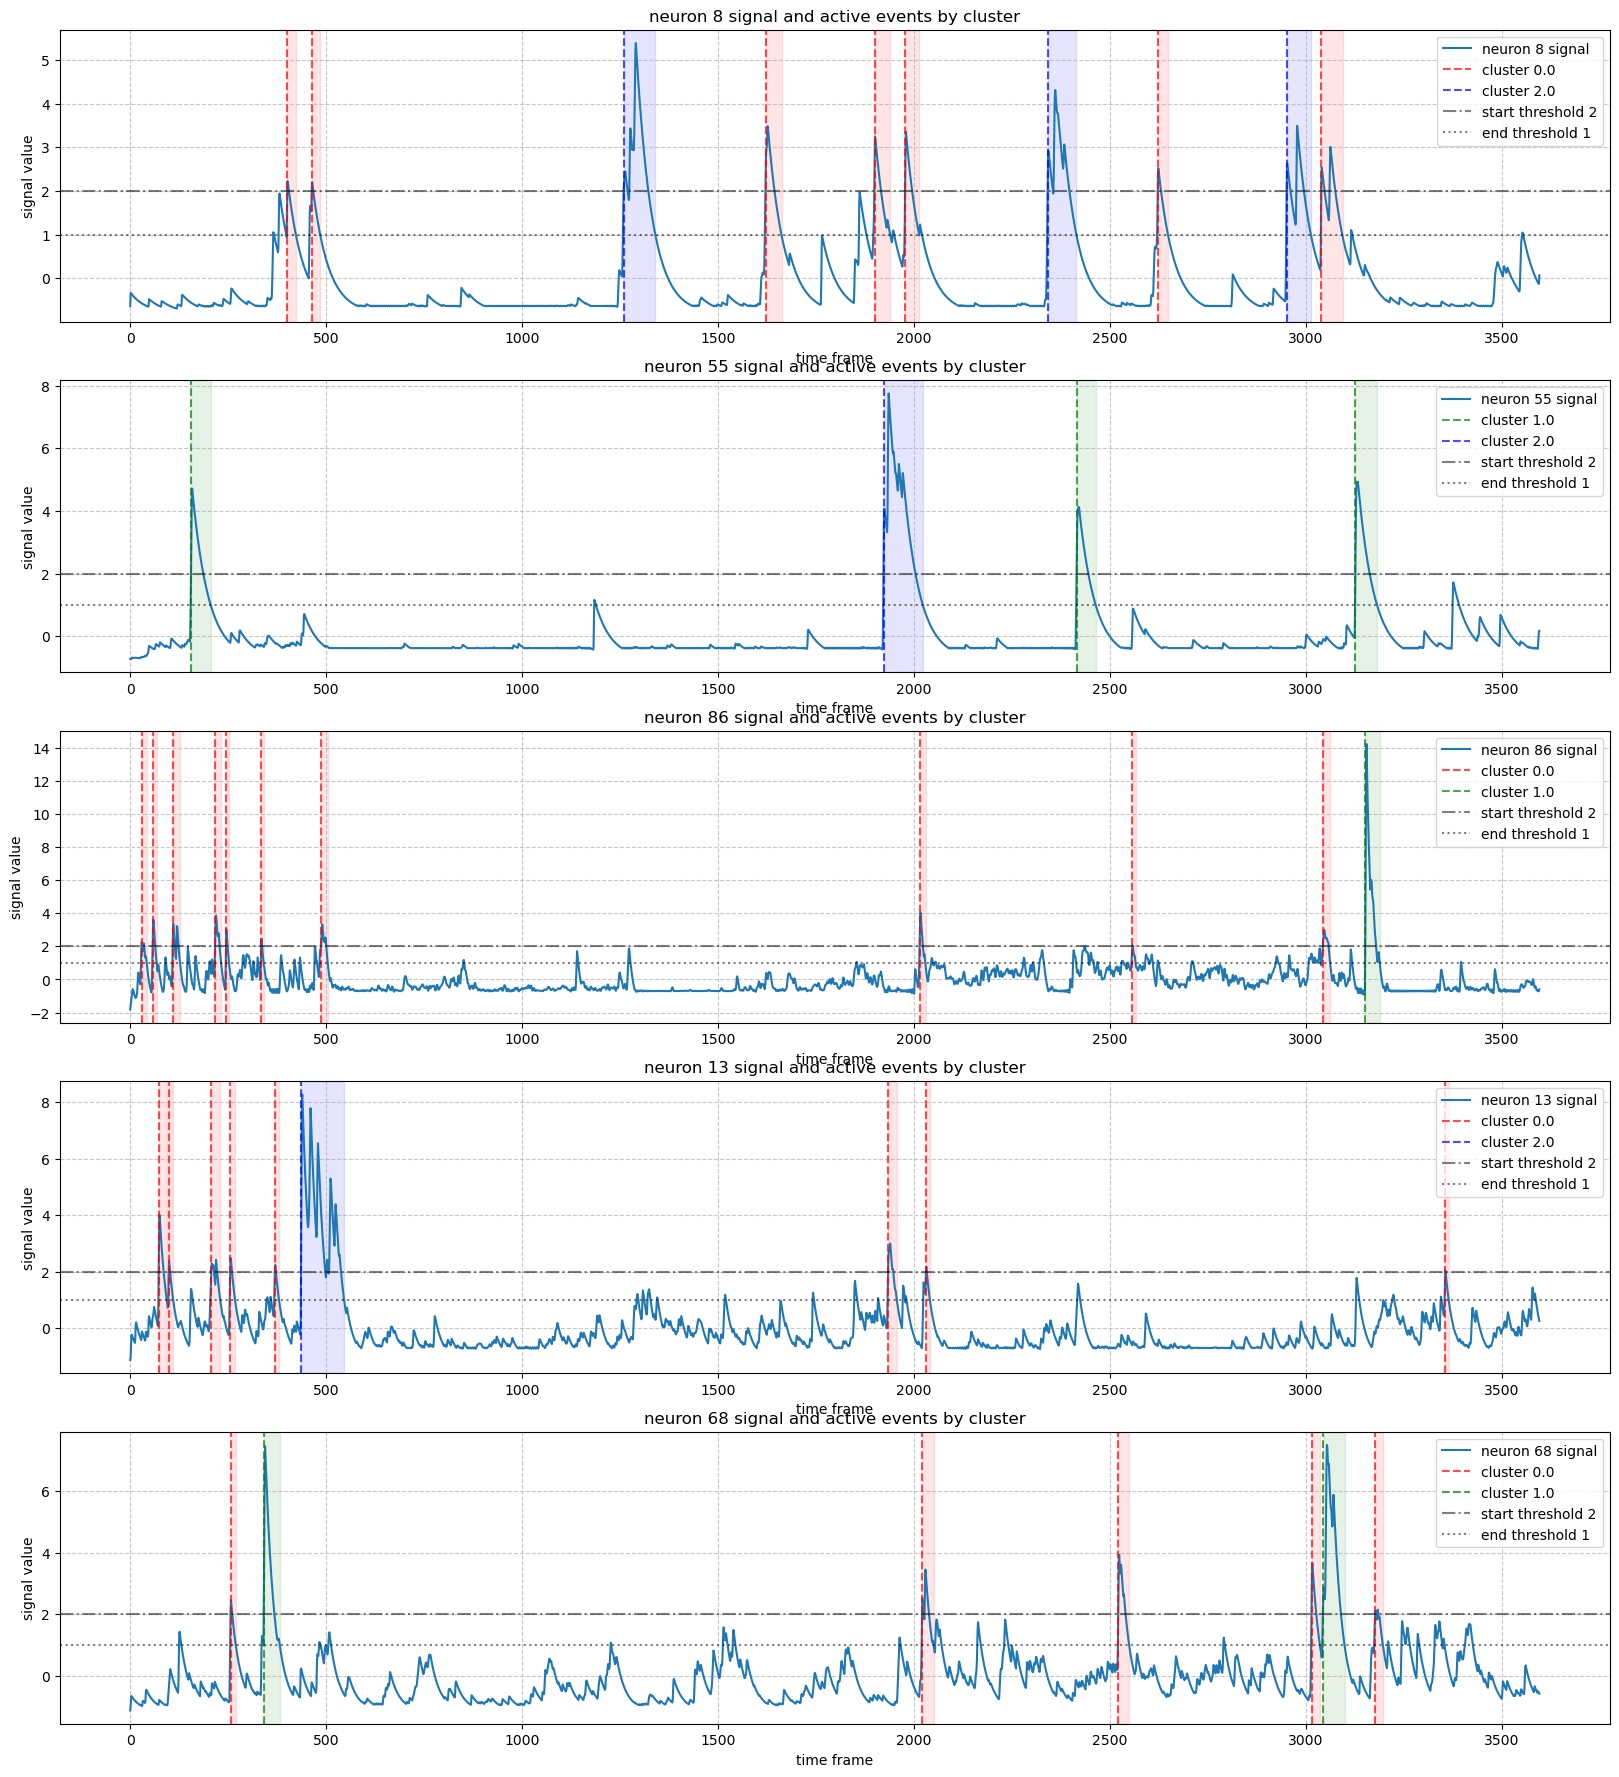

In [30]:
# Create a color mapping dictionary for different cluster_label values.
# Adjust the color list or add more colors as needed.
cluster_colors = {
    0: 'r',  # Use red for class 0.
    1: 'g',  # Use green for class 1.
    2: 'b',  # Use blue for class 2.
    3: 'm',  # Use magenta for class 3.
    4: 'c',  # Use cyan for class 4.
    5: 'y'   # Use yellow for class 5.
}


# Create a mapping from event IDs to cluster_label.
cluster_map = dict(zip(result_events_df['event_id'], result_events_df['kmeans_cluster']))

# Plot the selected neurons' signals and event onsets.
plt.figure(figsize=(20, 22)) 

for i, neuron_id in enumerate(selected_neuron_ids, 1):
    # Get this neuron's signal data.
    neuron_signal = resized_df_signal_neuron[neuron_id].values
    # Get all events for this neuron.
    neuron_events = result_events_df[result_events_df['neuron_id'] == neuron_id].copy()
    
    # # Add cluster_label to each event.
    # neuron_events['kmeans_cluster'] = neuron_events['event_id'].map(cluster_map)
    
    # Create a subplot.
    plt.subplot(len(selected_neuron_ids), 1, i)
    # Plot the signal trace.
    plt.plot(neuron_signal, label=f'neuron {neuron_id} signal')
    
    # Track legend labels already added to avoid duplicates.
    added_labels = set()
    
    # Mark event onsets and intervals using colors determined by cluster_label.
    for _, event in neuron_events.iterrows():
        cluster_label = event['kmeans_cluster']
        # Get the color for this cluster label.
        color = cluster_colors.get(cluster_label, 'k')  # Default to black.
        
        # Draw vertical lines at event onsets.
        label = f'cluster {cluster_label}' if f'cluster {cluster_label}' not in added_labels else ""
        plt.axvline(x=event['start_frame'], color=color, linestyle='--', alpha=0.7, label=label)
        if label:
            added_labels.add(label)
        
        # Mark the event duration intervals.
        plt.axvspan(event['start_frame'], event['end_frame'], color=color, alpha=0.1)
    
    # Add threshold lines.
    plt.axhline(y=2, color='k', linestyle='-.', alpha=0.5, label='start threshold 2')
    plt.axhline(y=1, color='k', linestyle=':', alpha=0.5, label='end threshold 1')
    
    # Set plot properties.
    plt.title(f'neuron {neuron_id} signal and active events by cluster')
    plt.xlabel('time frame')
    plt.ylabel('signal value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
plt.savefig(path_save + r'\duration signal and active events by cluster.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\duration signal and active events by cluster.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

Created 9480 neuronal signal segments.

Cluster-label proportions:
  Unlabeled (empty): 91.37%
  Label 0: 4.21%
  Label 1: 2.20%
  Label 2: 2.22%


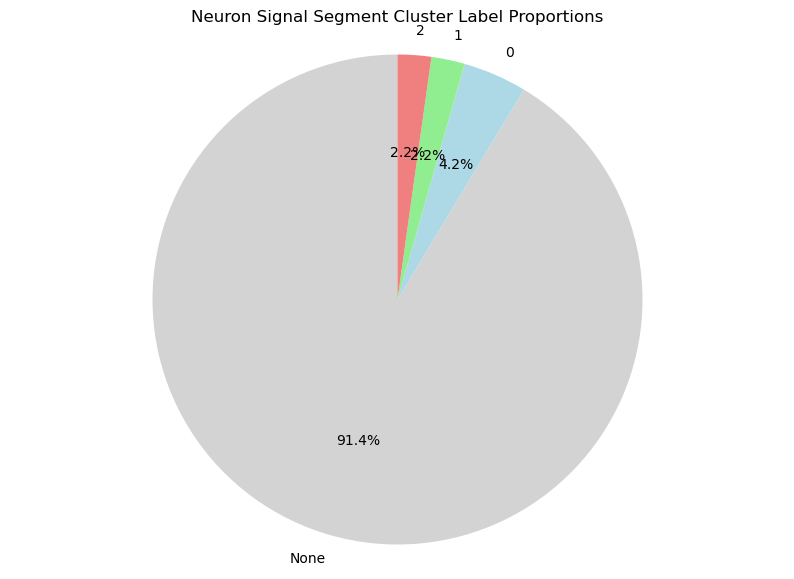

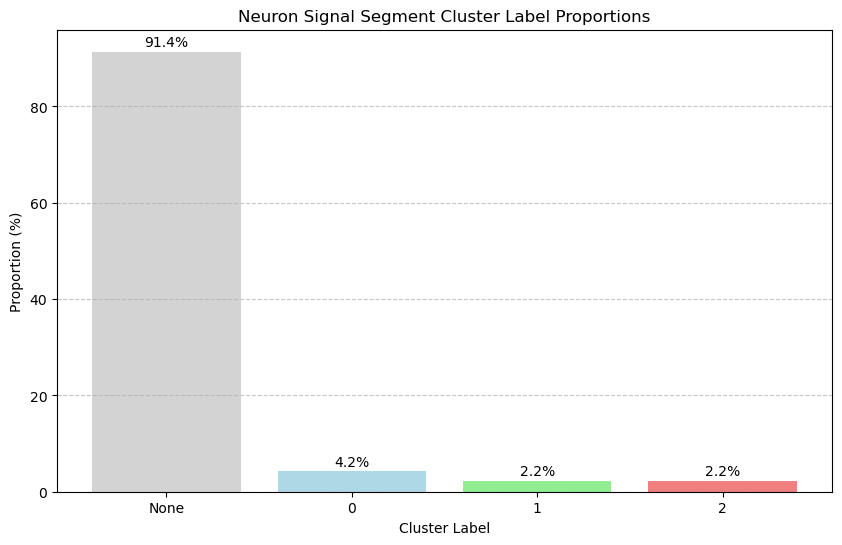

In [31]:
# 1. Divide resized_df_signal_neuron into 3-second (30-frame) segments.

def segment_neuron_signals(resized_df_signal_neuron, segment_duration_frames=30):
    """
    Divide neuronal signals into segments of the specified frame count.
    """
    total_frames = len(resized_df_signal_neuron)
    # Compute the segment count, counting the final incomplete segment as a full 30-frame segment.
    num_segments = (total_frames + segment_duration_frames - 1) // segment_duration_frames
    
    segments = []
    neuron_ids = resized_df_signal_neuron.columns.tolist()
    
    # Create segment information for each neuron.
    for neuron_id in neuron_ids:
        for seg_idx in range(num_segments):
            seg_start = seg_idx * segment_duration_frames
            seg_end = seg_start + segment_duration_frames - 1
            # Ensure that the last segment's end frame does not exceed the total frame count.
            seg_end = min(seg_end, total_frames - 1)
            
            segments.append({
                'neuron_id': neuron_id,
                'segment_idx': seg_idx,
                'seg_start_frame': seg_start,
                'seg_end_frame': seg_end,
                'seg_mid_frame': (seg_start + seg_end) // 2,
                'cluster_label': None  # Initialize to None to indicate no assignment.
            })
    
    return pd.DataFrame(segments)

# 2. Link event information and clustering results.

def merge_event_cluster_info(events_df, result_df):
    """
    Merge event information and clustering results.
    """
    # Ensure that event_id links the two DataFrames correctly.
    # First select the required columns from events_df.
    events_subset = events_df[['neuron_id', 'start_frame', 'end_frame']].copy()
    events_subset['event_id'] = events_subset.index  # Use the index as event_id.
    
    # Select cluster labels from result_df.
    result_subset = result_df[['event_id', 'cluster_label']].copy()
    
    # Merge the two DataFrames.
    merged_events = pd.merge(events_subset, result_subset, on='event_id', how='left')
    
    # Compute the duration of each event in frames.
    merged_events['duration_frames'] = merged_events['end_frame'] - merged_events['start_frame']
    
    return merged_events

# 3. Assign events to segments.

def assign_events_to_segments(segments_df, merged_events_df, segment_duration_frames=30, threshold_ratio=0.5):
    """
    Assign an event to a segment if it covers more than the threshold fraction of the segment.
    """
    # Copy the original segment data to avoid modifying the source.
    assigned_segments = segments_df.copy()
    threshold_frames = segment_duration_frames * threshold_ratio
    
    # Create a dictionary for quick lookup of each neuron's segments.
    neuron_segments = {}
    for _, seg in assigned_segments.iterrows():
        neuron_id = seg['neuron_id']
        if neuron_id not in neuron_segments:
            neuron_segments[neuron_id] = []
        neuron_segments[neuron_id].append(seg)
    
    # Iterate over events and check whether each should be assigned to a segment.
    for _, event in merged_events_df.iterrows():
        neuron_id = event['neuron_id']
        event_start = event['start_frame']
        event_end = event['end_frame']
        cluster_label = event['kmeans_cluster']
        
        # Skip events without cluster labels.
        if pd.isna(cluster_label):
            continue
        
        # Check whether this neuron has segments.
        if neuron_id not in neuron_segments:
            continue
        
        # Check the overlap between this event and each segment.
        for seg in neuron_segments[neuron_id]:
            seg_start = seg['seg_start_frame']
            seg_end = seg['seg_end_frame']
            
            # Compute the overlap interval.
            overlap_start = max(event_start, seg_start)
            overlap_end = min(event_end, seg_end)
            
            # If they overlap, compute the number of overlapping frames.
            if overlap_start < overlap_end:
                overlap_frames = overlap_end - overlap_start + 1
                
                # Assign the cluster label if the overlap exceeds the threshold.
                if overlap_frames >= threshold_frames:
                    # Update values in the original DataFrame.
                    mask = ((assigned_segments['neuron_id'] == neuron_id) & 
                            (assigned_segments['segment_idx'] == seg['segment_idx']))
                    assigned_segments.loc[mask, 'kmeans_cluster'] = cluster_label
    
    return assigned_segments

# 4. Compute proportions of the different cluster labels.

def calculate_cluster_proportions(assigned_segments_df):
    """
    Compute proportions of the different cluster labels.
    """
    # Ensure that cluster_label is a string for counting.
    assigned_segments_df['kmeans_cluster_str'] = assigned_segments_df['kmeans_cluster'].apply(
        lambda x: 'None' if pd.isna(x) else str(int(x))
    )
    
    # Count each label.
    label_counts = assigned_segments_df['kmeans_cluster_str'].value_counts()
    total_segments = len(assigned_segments_df)
    
    # Compute proportions.
    proportions = {}  
    for label, count in label_counts.items():
        proportions[label] = count / total_segments * 100
    
    # Include all possible labels, including those absent from the data.
    possible_labels = ['None', '0', '1', '2']
    for label in possible_labels:
        if label not in proportions:
            proportions[label] = 0
    
    # Sort by label.
    sorted_proportions = {k: proportions[k] for k in possible_labels}
    
    return sorted_proportions

# 5. Visualize summary statistics.

def visualize_cluster_proportions(proportions):
    """
    Visualize proportions of the different cluster labels.
    """
    labels = list(proportions.keys())
    values = list(proportions.values())
    
    # Create a pie chart.
    plt.figure(figsize=(10, 7))
    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, 
            colors=['lightgray', 'lightblue', 'lightgreen', 'lightcoral'])
    plt.title('Neuron Signal Segment Cluster Label Proportions')
    plt.axis('equal')  # Keep the pie chart circular.
    plt.show()
    
    # Create a bar chart.
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, values, color=['lightgray', 'lightblue', 'lightgreen', 'lightcoral'])
    plt.title('Neuron Signal Segment Cluster Label Proportions')
    plt.xlabel('Cluster Label')
    plt.ylabel('Proportion (%)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels to the bars.
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # plt.tight_layout()
    plt.show()

# Run the full workflow.
# 1. Create segments.
segments_df = segment_neuron_signals(resized_df_signal_neuron, segment_duration_frames=30)
print(f"Created {len(segments_df)} neuronal signal segments.")

# # 2. Link event and cluster information.
# merged_events_df = merge_event_cluster_info(events_df, result_df)
# print(f"Linked cluster information for {len(merged_events_df)} events.")

# 3. Assign events to segments.
assigned_segments_df = assign_events_to_segments(
    segments_df, 
    result_events_df, 
    segment_duration_frames=30, 
    threshold_ratio=0.5
)

# 4. Compute cluster-label proportions.
cluster_proportions = calculate_cluster_proportions(assigned_segments_df)

# 5. Print summary statistics.
print("\nCluster-label proportions:")
for label, proportion in cluster_proportions.items():
    if label == 'None':
        print(f"  Unlabeled (empty): {proportion:.2f}%")
    else:
        print(f"  Label {label}: {proportion:.2f}%")

# 6. Visualize the results.
visualize_cluster_proportions(cluster_proportions)

assigned_segments_df_events3 = assigned_segments_df.copy()

# Optionally save the results to a CSV file.
# assigned_segments_df_events3.to_csv('neuron_segments_with_cluster_labels.csv', index=False)

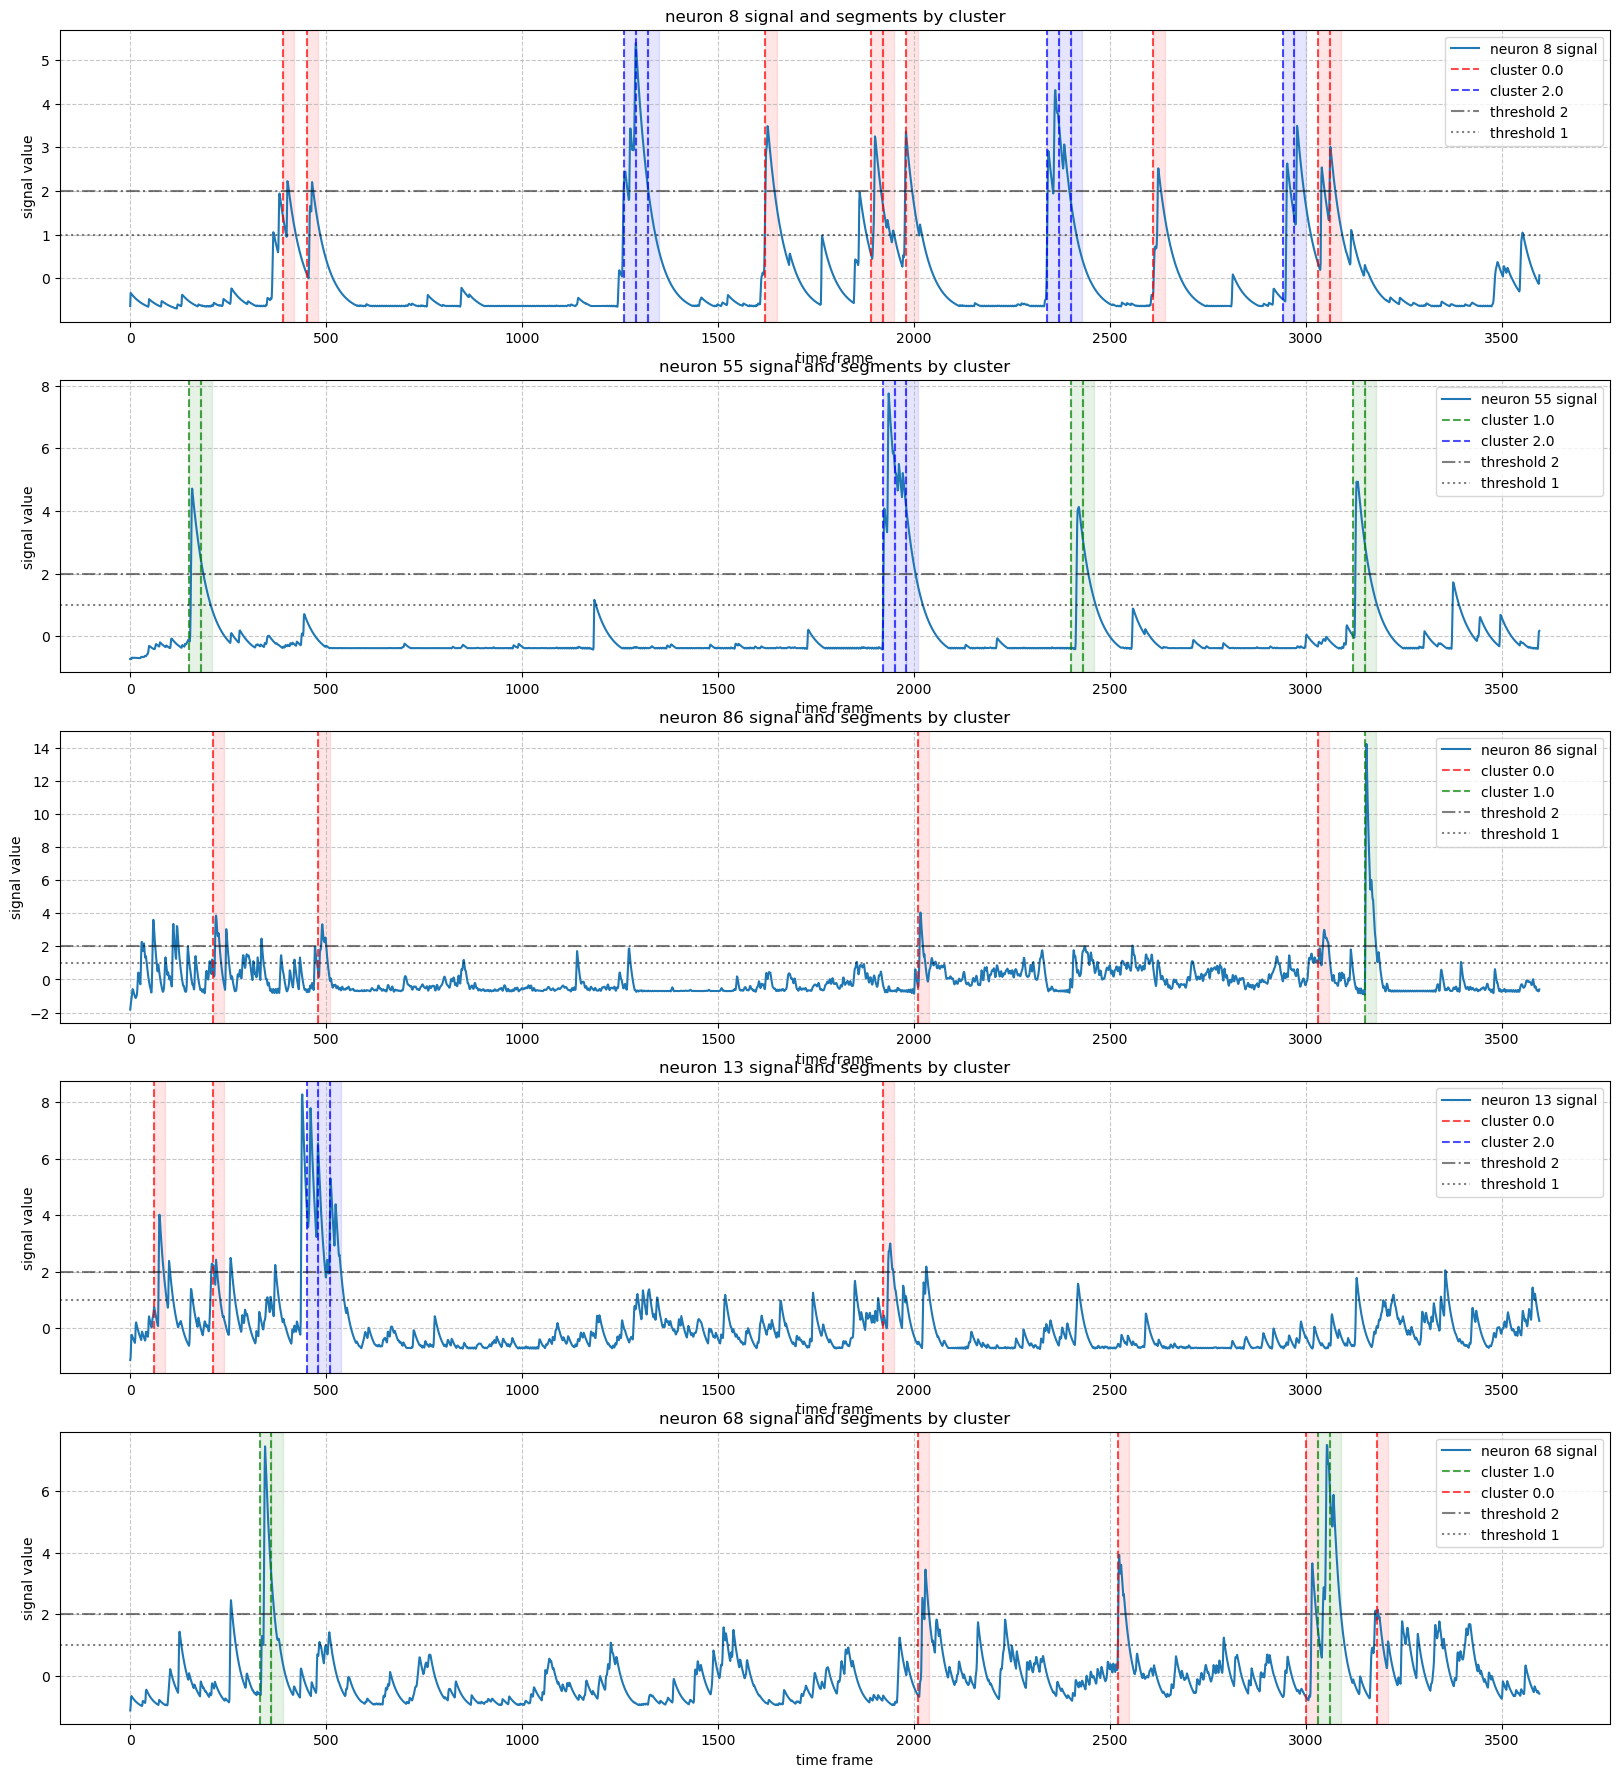

In [32]:
# Create a color mapping dictionary for different cluster_label values.
# Include only valid classes 0, 1, and 2; do not color none values.
cluster_colors = {
    0: 'r',   # Use red for class 0.
    1: 'g',   # Use green for class 1.
    2: 'b'    # Use blue for class 2.
}

# Plot the selected neurons' signals and event onsets.
plt.figure(figsize=(20, 22))

for i, neuron_id in enumerate(selected_neuron_ids, 1):
    # Get this neuron's signal data.
    neuron_signal = resized_df_signal_neuron[neuron_id].values
    # Get all frame segments for this neuron.
    neuron_segments = assigned_segments_df_events3[assigned_segments_df_events3['neuron_id'] == neuron_id].copy()
    
    # Create a subplot.
    plt.subplot(len(selected_neuron_ids), 1, i)
    # Plot the signal trace.
    plt.plot(neuron_signal, label=f'neuron {neuron_id} signal')
    
    # Track legend labels already added to avoid duplicates.
    added_labels = set()
    
    # Mark segment onsets and intervals using colors determined by cluster_label.
    for _, segment in neuron_segments.iterrows():
        cluster_label = segment['kmeans_cluster']
        
        # Skip cluster_label values of none without adding color markers.
        if math.isnan(cluster_label) or cluster_label == 'None':
            continue
        
        # Get the color for this cluster label.
        color = cluster_colors.get(cluster_label, 'k')  # Default to black.
        
        # Draw vertical lines at event onsets.
        label = f'cluster {cluster_label}' if f'cluster {cluster_label}' not in added_labels else ""
        plt.axvline(x=segment['seg_start_frame'], color=color, linestyle='--', alpha=0.7, label=label)
        if label:
            added_labels.add(label)
        
        # Mark segment duration intervals.
        plt.axvspan(segment['seg_start_frame'], segment['seg_end_frame'], color=color, alpha=0.1)
    
    # Add threshold lines if needed.
    plt.axhline(y=2, color='k', linestyle='-.', alpha=0.5, label='threshold 2')
    plt.axhline(y=1, color='k', linestyle=':', alpha=0.5, label='threshold 1')
    
    # Set plot properties.
    plt.title(f'neuron {neuron_id} signal and segments by cluster')
    plt.xlabel('time frame')
    plt.ylabel('signal value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)


# Adjust the layout and display the plot.
# plt.tight_layout()
plt.savefig(path_save + r'\duration signal and active events by cluster single window.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\duration signal and active events by cluster single window.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# Function: divide neuronal signals into 3-second (30-frame) segments.
def segment_neuron_data_by_3s(df_neuron, frame_rate=10):
    """
    Divide neuronal signal data into 3-second (30-frame) time segments.
    
    Parameters:
    df_neuron: neuronal signal DataFrame; rows are frames and columns are neuron IDs.
    frame_rate: frame rate, defaulting to 10 frames/second.
    
    Returns:
    List of time intervals and the total number of segments.
    """
    total_frames = len(df_neuron)
    segment_duration_frames = 3 * frame_rate  # 3 seconds = 30 frames.
    
    # Create segment intervals.
    segments = []
    for i in range(0, total_frames, segment_duration_frames):
        segment_start = i
        segment_end = min(i + segment_duration_frames - 1, total_frames - 1)
        segments.append((segment_start, segment_end))
    
    return segments

# Function: map events to 3-second segments and determine validity.
def map_events_to_segments(segments, events_df, total_neurons):
    """
    Map events to 3-second segments and determine the validity of each neuron's activity within each segment.
    
    Parameters:
    segments: list of time-segment intervals.
    events_df: event DataFrame containing neuron_id, start_time, and end_time.
    total_neurons: total number of neurons.
    
    Returns:
    Validity matrix (segments x neurons) and array of valid-activity proportions.
    """
    # Initialize the validity matrix: False for invalid and True for valid.
    validity_matrix = np.zeros((len(segments), total_neurons), dtype=bool)
    
    # Process each time segment.
    for seg_idx, (seg_start, seg_end) in enumerate(segments):
        seg_duration = seg_end - seg_start + 1
        min_valid_frames = seg_duration // 2  # 50% of the time-segment length.
        
        # Check each neuron for sufficiently long event coverage.
        for neuron_idx in range(total_neurons):
            # Select all events for this neuron in the current time segment.
            neuron_events = events_df[events_df['neuron_id'] == neuron_idx].copy()
            overlapping_events = neuron_events[
                (neuron_events['start_frame'] <= seg_end) & 
                (neuron_events['end_frame'] >= seg_start)
            ]
            
            # Compute the total number of overlapping frames.
            total_overlap = 0
            for _, event in overlapping_events.iterrows():
                overlap_start = max(seg_start, event['start_frame'])
                overlap_end = min(seg_end, event['end_frame'])
                total_overlap += (overlap_end - overlap_start + 1)
            
            # Check whether the validity threshold is reached.
            if total_overlap >= min_valid_frames:
                validity_matrix[seg_idx, neuron_idx] = True
    
    # Compute the proportion of neurons with valid activity in each time segment.
    valid_proportions = np.sum(validity_matrix, axis=1) / total_neurons
    
    return validity_matrix, valid_proportions

# Main function: process neuronal signals and event data.
def analyze_neuron_activity_over_time(resized_df_signal_neuron, events_df, frame_rate=10):
    """
    Analyze how neuronal activity changes over time.
    
    Parameters:
    resized_df_signal_neuron: neuronal signal DataFrame.
    events_df: event DataFrame.
    frame_rate: frame rate, defaulting to 10 frames/second.
    
    Returns:
    List of time segments, validity matrix, and array of valid-activity proportions.
    """
    # Get the total number of neurons.
    total_neurons = resized_df_signal_neuron.shape[1]
    
    # Divide into 3-second segments.
    segments = segment_neuron_data_by_3s(resized_df_signal_neuron, frame_rate)
    
    # Map events and compute validity.
    validity_matrix, valid_proportions = map_events_to_segments(
        segments, events_df, total_neurons
    )
    
    return segments, validity_matrix, valid_proportions

# Visualize the proportion of valid activity over time.
def plot_valid_activity_proportions(segments, valid_proportions,threshold=None):
    """
    Plot the proportion of validly active neurons over time.
    """
    import matplotlib.pyplot as plt
    
    # Use the midpoint of each time segment as its x coordinate.
    segment_mid_times = [(start + end) / 2 for start, end in segments]
    
    plt.figure(figsize=(20, 3))
    plt.plot(segment_mid_times, valid_proportions, marker='o', linestyle='-', color='b')
    plt.title('real-time valid activity proportion')
    plt.xlabel('time frame')
    plt.ylabel('valid activity proportion')
    plt.grid(True, linestyle='--', alpha=0.7)
    # Add threshold lines if needed.
    if threshold is not None:
        plt.axhline(y=threshold, color='r', linestyle='--', alpha=0.5, label=f'threshold {threshold}')

    # plt.tight_layout()
    plt.savefig(path_save + r'\valid activity proportion.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(path_save + r'\valid activity proportion.png', format='png', dpi=300, bbox_inches='tight')
    plt.show()

Total time segments: 120
Mean proportion of validly active neurons: 0.0753
Maximum proportion of validly active neurons: 0.2405
Minimum proportion of validly active neurons: 0.0000


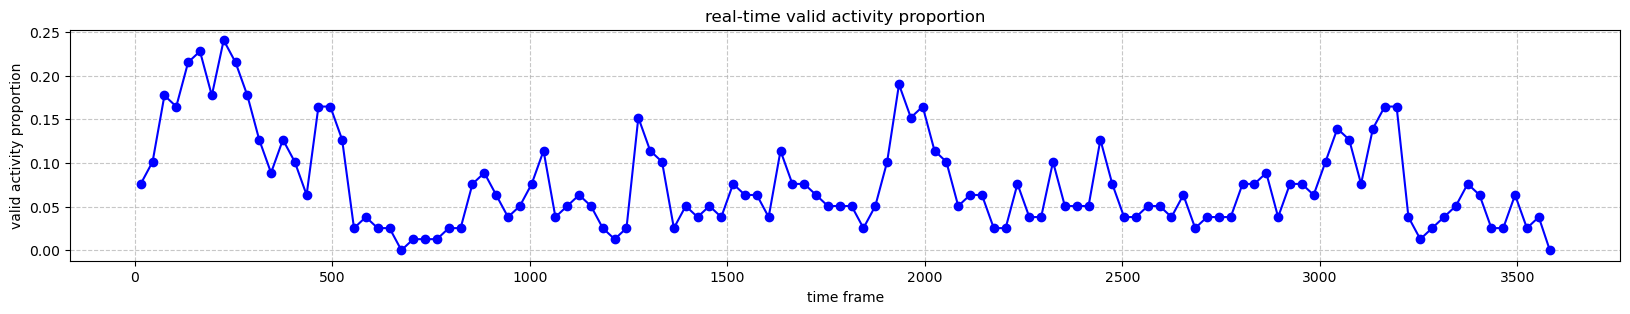


Valid-activity proportions for the first 5 time segments:
   segment_start  segment_end  valid_proportion
0              0           29          0.075949
1             30           59          0.101266
2             60           89          0.177215
3             90          119          0.164557
4            120          149          0.215190


In [34]:
# Analyze neuronal activity.
segments, validity_matrix, valid_proportions = analyze_neuron_activity_over_time(
    resized_df_signal_neuron, events_df
)
# Print a results summary.
print(f"Total time segments: {len(segments)}")
print(f"Mean proportion of validly active neurons: {np.mean(valid_proportions):.4f}")
print(f"Maximum proportion of validly active neurons: {np.max(valid_proportions):.4f}")
print(f"Minimum proportion of validly active neurons: {np.min(valid_proportions):.4f}")

# Visualize the results.
plot_valid_activity_proportions(segments, valid_proportions)

# Create a results DataFrame for further analysis.
result_df = pd.DataFrame({
    'segment_start': [seg[0] for seg in segments],
    'segment_end': [seg[1] for seg in segments],
    'valid_proportion': valid_proportions
})
print("\nValid-activity proportions for the first 5 time segments:")
print(result_df.head())

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, skew, norm
import warnings
warnings.filterwarnings('ignore')

Behavioral data segmented into 120 time segments.
Merged data length: 120 time segments.
Time segments during struggling: 58
Time segments during non-struggling: 62


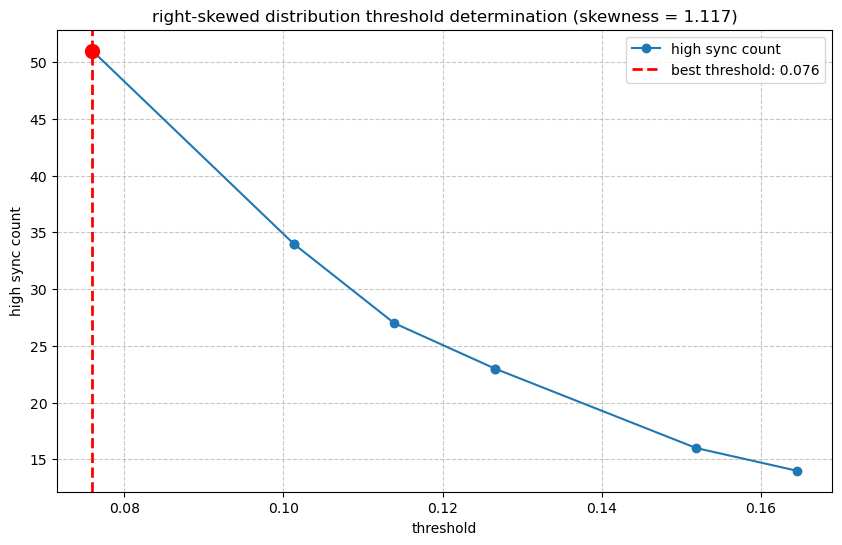


Right-skewed distribution analysis:
- Cumulative probability range: 60% to 90%
- Optimal threshold position: cumulative probability 69.0%
- Optimal threshold: 0.076
- Corresponding high-synchrony time segments: 51


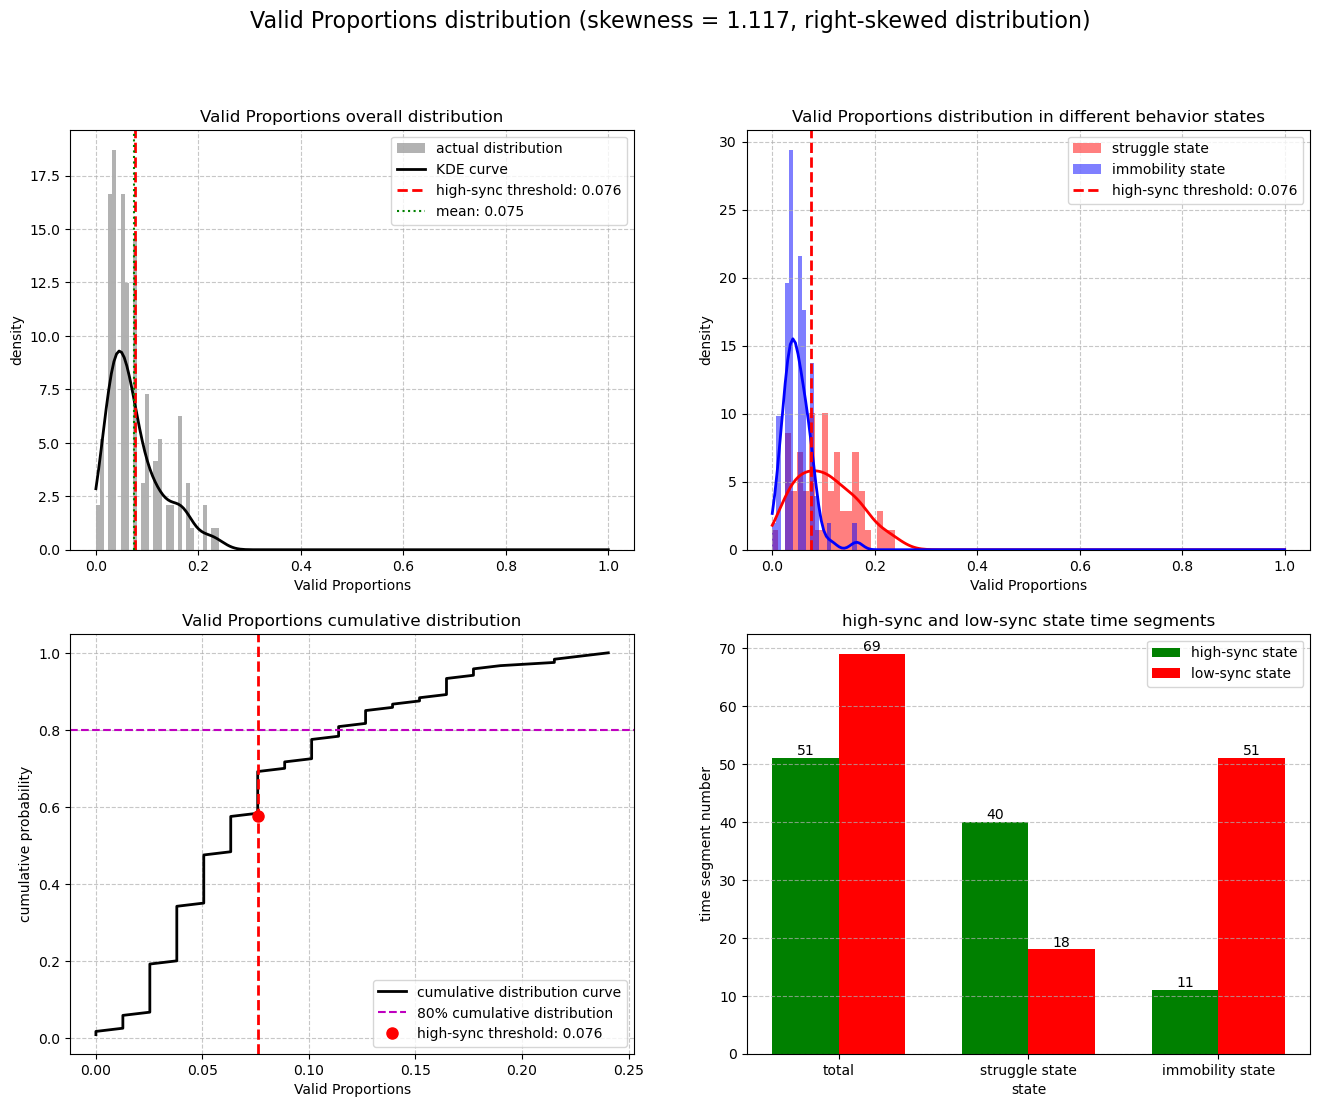


Statistics:
- Skewness: 1.117 (right-skewed distribution)
- High-synchrony threshold: 0.076
- Total time segments: 120
  * High-synchrony time segments: 51 (42.5%)
  * Low-synchrony time segments: 69 (57.5%)
- Time segments during struggling: 58
  * High synchrony: 40 (69.0% if >0)
  * Low synchrony: 18 (31.0% if >0)
- Time segments during non-struggling: 62
  * High synchrony: 11 (17.7% if >0)
  * Low synchrony: 51 (82.3% if >0)

First 5 rows of merged data:
   segment_start  segment_end  segment_duration  avg_value  is_struggle  \
0              0           29                30        1.0            1   
1             30           59                30        1.0            1   
2             60           89                30        1.0            1   
3             90          119                30        1.0            1   
4            120          149                30        1.0            1   

   proportion  sync_status  
0    0.075949            1  
1    0.101266            1

In [36]:
# Function: divide behavioral data into 3-second (30-frame) segments and determine struggling status.
def segment_behaviour_data(behaviour_df, frame_rate=10):
    """
    Divide behavioral data into 3-second (30-frame) segments and determine struggling status for each segment.
    
    Parameters:
    behaviour_df: behavioral DataFrame; rows are frames and columns contain behavioral values (0 or 1).
    frame_rate: frame rate, defaulting to 10 frames/second.
    
    Returns:
    DataFrame containing segment information and struggling status.
    """
    # Ensure that the input is a DataFrame.
    if not isinstance(behaviour_df, pd.DataFrame):
        behaviour_df = pd.DataFrame(behaviour_df, columns=['behaviour'])
    
    total_frames = len(behaviour_df)
    segment_duration_frames = 3 * frame_rate  # 3 seconds = 30 frames.
    
    # Create segments.
    segments = []
    for i in range(0, total_frames, segment_duration_frames):
        segment_start = i
        segment_end = min(i + segment_duration_frames - 1, total_frames - 1)
        
        # Extract data for the current segment.
        segment_data = behaviour_df.iloc[segment_start:segment_end+1].values.flatten()
        
        # Compute the mean and determine struggling status.
        avg_value = np.mean(segment_data)
        is_struggle = 1 if avg_value >= 0.5 else 0
        
        segments.append({
            'segment_start': segment_start,
            'segment_end': segment_end,
            'segment_duration': segment_end - segment_start + 1,
            'avg_value': avg_value,
            'is_struggle': is_struggle
        })
    
    return pd.DataFrame(segments)

# Function: align behavioral states with valid_proportions.
def associate_behaviour_with_proportions(behaviour_segments, valid_proportions_df):
    """
    Align behavioral states with valid_proportions data.
    
    Parameters:
    behaviour_segments: DataFrame of behavioral segments.
    valid_proportions_df: DataFrame of valid_proportions.
    
    Returns:
    Merged DataFrame.
    """
    # Ensure that the two DataFrames have matching lengths.
    min_len = min(len(behaviour_segments), len(valid_proportions_df))
    
    # Truncate the data to matching lengths.
    behaviour_subset = behaviour_segments.iloc[:min_len].copy()
    
    # Ensure that valid_proportions_df is a DataFrame.
    if not isinstance(valid_proportions_df, pd.DataFrame):
        # Handle potentially multidimensional arrays.
        if len(np.shape(valid_proportions_df)) > 1:
            valid_proportions_df = pd.DataFrame(valid_proportions_df.flatten(), columns=['proportion'])
        else:
            valid_proportions_df = pd.DataFrame(valid_proportions_df, columns=['proportion'])
    elif len(valid_proportions_df.columns) > 0 and 'proportion' not in valid_proportions_df.columns:
        # If columns exist but proportion is absent, rename the first column to proportion.
        valid_proportions_df = valid_proportions_df.rename(columns={valid_proportions_df.columns[0]: 'proportion'})
    
    valid_subset = valid_proportions_df.iloc[:min_len].copy()
    
    # Merge data.
    combined_df = pd.concat([behaviour_subset.reset_index(drop=True), 
                             valid_subset.reset_index(drop=True)], axis=1)
    
    return combined_df

# Function: compute skewness and determine the high-synchrony threshold.
def calculate_skewness_and_threshold(valid_proportions):
    """
    Compute the skewness of valid_proportions and use it to determine the high-synchrony threshold.
    
    Parameters:
    valid_proportions: valid_proportions data.
    
    Returns:
    threshold: high-synchrony threshold.
    skew_value: computed skewness.
    distribution_type: description of the distribution type.
    additional_info: dictionary containing additional analysis information.
    """
    # Ensure that the data is a one-dimensional array.
    if isinstance(valid_proportions, pd.DataFrame):
        data = valid_proportions['proportion'].values
    else:
        data = np.array(valid_proportions).flatten()
    
    # Compute skewness.
    skew_value = skew(data)
    additional_info = {}
    
    # Determine the threshold based on skewness.
    if skew_value < -0.5:
        # Left-skewed distribution: most data has high synchrony; use "peak - 0.5 x standard deviation" as the threshold.
        kde = gaussian_kde(data)
        x_range = np.linspace(min(data), max(data), 1000)
        kde_values = kde(x_range)
        peak_index = np.argmax(kde_values)
        peak_value = x_range[peak_index]
        std_value = np.std(data)
        threshold = peak_value - 0.5 * std_value
        distribution_type = "left-skewed distribution"
        additional_info = {
            "peak_value": peak_value,
            "std_value": std_value
        }
    elif skew_value > 0.5:
        # Right-skewed distribution: most data has low synchrony; use an elbow plot to determine the optimal threshold.
        sorted_data = np.sort(data)
        n = len(sorted_data)
        
        # Generate cumulative probabilities from 60% to 90% in 3% increments.
        cum_percentages = np.arange(0.6, 0.91, 0.03)  # 0.6, 0.63, 0.66, ..., 0.9
        thresholds = []
        high_sync_counts = []
        
        for p in cum_percentages:
            # Compute the index for the current cumulative probability.
            index = int(n * p)
            # Ensure that the index is within the valid range.
            index = min(index, n - 1)
            # Get the corresponding threshold.
            current_threshold = sorted_data[index]
            thresholds.append(current_threshold)
            # Count high-synchrony time segments at the current threshold.
            high_sync_count = (data >= current_threshold).sum()
            high_sync_counts.append(high_sync_count)
        
        # Compute successive differences to locate abrupt changes.
        differences = np.diff(high_sync_counts)
        
        # Find the elbow (abrupt change).
        # Method 1: find the position of the largest difference.
        max_diff_idx = np.argmax(np.abs(differences))
        
        # Method 2: find the point of greatest curvature as an alternative.
        # Estimate curvature using second differences.
        if len(differences) >= 2:
            second_diff = np.diff(differences)
            if len(second_diff) > 0:
                max_curvature_idx = np.argmax(np.abs(second_diff))
                # Combine both methods, giving priority to method 1.
                selected_idx = max_diff_idx if max_diff_idx <= len(thresholds) - 1 else max_curvature_idx
            else:
                selected_idx = max_diff_idx
        else:
            selected_idx = max_diff_idx
        
        # Ensure that the selected index is valid.
        selected_idx = min(selected_idx, len(thresholds) - 1)
        
        # Select the final threshold.
        threshold = thresholds[selected_idx]
        distribution_type = "right-skewed distribution"
        
        # Save additional information for visualization.
        additional_info = {
            "cum_percentages": cum_percentages,
            "thresholds": thresholds,
            "high_sync_counts": high_sync_counts,
            "elbow_idx": selected_idx,
            "elbow_threshold": threshold,
            "elbow_percentage": cum_percentages[selected_idx]
        }
        
        # Create an elbow plot.
        plt.figure(figsize=(10, 6))
        plt.plot(thresholds, high_sync_counts, 'o-', label='high sync count')
        plt.axvline(x=threshold, color='r', linestyle='--', linewidth=2, 
                   label=f'best threshold: {threshold:.3f}')
        plt.plot(thresholds[selected_idx], high_sync_counts[selected_idx], 'ro', markersize=10)
        plt.title(f'right-skewed distribution threshold determination (skewness = {skew_value:.3f})')
        plt.xlabel('threshold')
        plt.ylabel('high sync count')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        # plt.tight_layout()
        plt.savefig(path_save + r'\right-skewed distribution threshold determination.pdf', format='pdf', dpi=300, bbox_inches='tight')
        plt.savefig(path_save + r'\right-skewed distribution threshold determination.png', format='png', dpi=300, bbox_inches='tight')

        plt.show()
        
        print(f"\nRight-skewed distribution analysis:")
        print(f"- Cumulative probability range: 60% to 90%")
        print(f"- Optimal threshold position: cumulative probability {cum_percentages[selected_idx]:.1%}")
        print(f"- Optimal threshold: {threshold:.3f}")
        print(f"- Corresponding high-synchrony time segments: {high_sync_counts[selected_idx]}")
    else:
        # Approximately normal distribution: use the mean as the threshold.
        threshold = np.mean(data)
        distribution_type = "most likely normal distribution"
        additional_info = {
            "mean_value": threshold
        }
    
    # Ensure that the threshold is within a reasonable range.
    threshold = max(0, min(1, threshold))
    
    return threshold, skew_value, distribution_type, additional_info


# Add a synchrony-status column to combined_df.
def add_sync_status_column(combined_df, threshold):
    """
    Add a column to combined_df assigning 1 to synchrony rates above the threshold and 0 to rates below it.
    
    Parameters:
    combined_df: merged DataFrame.
    threshold: high-synchrony threshold.
    
    Returns:
    DataFrame with an added synchrony-status column.
    """
    # Create the new column 'sync_status'.
    combined_df['sync_status'] = (combined_df['proportion'] >= threshold).astype(int)
    
    # Count high- and low-synchrony observations.
    high_sync_count = combined_df['sync_status'].sum()
    low_sync_count = len(combined_df) - high_sync_count
    
    # print(f"Synchrony-status counts:")
    # print(f"- High-synchrony time segments (sync_status=1): {high_sync_count} ({high_sync_count/len(combined_df)*100:.1f}%)")
    # print(f"- Low-synchrony time segments (sync_status=0): {low_sync_count} ({low_sync_count/len(combined_df)*100:.1f}%)")
    
    return combined_df

# Function: plot valid_proportions distributions overall and during struggling and non-struggling states.
def plot_comprehensive_distributions(combined_df, threshold, skew_value, distribution_type):
    """
    Plot valid_proportions distributions overall and during struggling and non-struggling states,
    and mark the threshold separating high and low synchrony.
    """
    # Extract data.
    all_data = combined_df['proportion'].values
    struggle_data = combined_df[combined_df['is_struggle'] == 1]['proportion'].values
    non_struggle_data = combined_df[combined_df['is_struggle'] == 0]['proportion'].values
    
    # Create a figure.
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Valid Proportions distribution (skewness = {skew_value:.3f}, {distribution_type})', fontsize=16)
    
    # 1. Overall distribution (upper left).
    ax1 = axes[0, 0]
    ax1.hist(all_data, bins=30, alpha=0.6, color='gray', density=True, label='actual distribution')
    
    # Add a KDE curve.
    kde_all = gaussian_kde(all_data)
    x_all = np.linspace(0, 1, 200)
    y_all = kde_all(x_all)
    ax1.plot(x_all, y_all, 'k-', linewidth=2, label='KDE curve')
    
    # Mark the threshold.
    ax1.axvline(x=threshold, color='r', linestyle='--', linewidth=2, 
                label=f'high-sync threshold: {threshold:.3f}')
    
    # Annotate statistics.
    ax1.axvline(x=np.mean(all_data), color='g', linestyle=':', linewidth=1.5, 
                label=f'mean: {np.mean(all_data):.3f}')
    
    ax1.set_title('Valid Proportions overall distribution')
    ax1.set_xlabel('Valid Proportions')
    ax1.set_ylabel('density')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()
    
    # 2. Distributions during struggling and non-struggling states (upper right).
    ax2 = axes[0, 1]
    
    # Plot the distribution during struggling.
    if len(struggle_data) > 0:
        ax2.hist(struggle_data, bins=20, alpha=0.5, color='r', density=True, label='struggle state')
        kde_struggle = gaussian_kde(struggle_data)
        x_struggle = np.linspace(0, 1, 200)
        y_struggle = kde_struggle(x_struggle)
        ax2.plot(x_struggle, y_struggle, 'r-', linewidth=2)
    
    # Plot the distribution during non-struggling.
    if len(non_struggle_data) > 0:
        ax2.hist(non_struggle_data, bins=20, alpha=0.5, color='b', density=True, label='immobility state')
        kde_non_struggle = gaussian_kde(non_struggle_data)
        x_non_struggle = np.linspace(0, 1, 200)
        y_non_struggle = kde_non_struggle(x_non_struggle)
        ax2.plot(x_non_struggle, y_non_struggle, 'b-', linewidth=2)
    
    # Mark the threshold.
    ax2.axvline(x=threshold, color='r', linestyle='--', linewidth=2, 
                label=f'high-sync threshold: {threshold:.3f}')
    
    ax2.set_title('Valid Proportions distribution in different behavior states')
    ax2.set_xlabel('Valid Proportions')
    ax2.set_ylabel('density')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()
    
    # 3. Cumulative distribution curves (lower left).
    ax3 = axes[1, 0]
    
    # Compute the cumulative distribution.
    sorted_data = np.sort(all_data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    
    ax3.plot(sorted_data, cumulative, 'k-', linewidth=2, label='cumulative distribution curve')
    ax3.axhline(y=0.8, color='m', linestyle='--', linewidth=1.5, label=r'80% cumulative distribution')
    
    # Mark the threshold position.
    if len(sorted_data) > 0:
        # Find the cumulative probability at the threshold.
        threshold_index = np.searchsorted(sorted_data, threshold)
        if threshold_index < len(sorted_data):
            cum_prob = threshold_index / len(sorted_data)
            ax3.axvline(x=threshold, color='r', linestyle='--', linewidth=2)
            ax3.plot(threshold, cum_prob, 'ro', markersize=8, 
                     label=f'high-sync threshold: {threshold:.3f}')
    
    ax3.set_title('Valid Proportions cumulative distribution')
    ax3.set_xlabel('Valid Proportions')
    ax3.set_ylabel('cumulative probability')
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend()
    
    # 4. Counts of high- and low-synchrony time segments (lower right).
    ax4 = axes[1, 1]
    
    # Count high- and low-synchrony time segments.
    high_sync_all = (all_data >= threshold).sum()
    low_sync_all = len(all_data) - high_sync_all
    
    # Count high- and low-synchrony segments during struggling.
    if len(struggle_data) > 0:
        high_sync_struggle = (struggle_data >= threshold).sum()
        low_sync_struggle = len(struggle_data) - high_sync_struggle
    else:
        high_sync_struggle = 0
        low_sync_struggle = 0
    
    # Count high- and low-synchrony segments during non-struggling.
    if len(non_struggle_data) > 0:
        high_sync_non_struggle = (non_struggle_data >= threshold).sum()
        low_sync_non_struggle = len(non_struggle_data) - high_sync_non_struggle
    else:
        high_sync_non_struggle = 0
        low_sync_non_struggle = 0
    
    # Create a grouped bar chart.
    categories = ['total', 'struggle state', 'immobility state']
    high_sync_counts = [high_sync_all, high_sync_struggle, high_sync_non_struggle]
    low_sync_counts = [low_sync_all, low_sync_struggle, low_sync_non_struggle]
    
    x = np.arange(len(categories))
    width = 0.35
    
    ax4.bar(x - width/2, high_sync_counts, width, label='high-sync state', color='g')
    ax4.bar(x + width/2, low_sync_counts, width, label='low-sync state', color='r')
    
    # Add value labels.
    for i, (high, low) in enumerate(zip(high_sync_counts, low_sync_counts)):
        ax4.text(i - width/2, high, f'{high}', ha='center', va='bottom')
        ax4.text(i + width/2, low, f'{low}', ha='center', va='bottom')
    
    ax4.set_title('high-sync and low-sync state time segments')
    ax4.set_xlabel('state')
    ax4.set_ylabel('time segment number')
    ax4.set_xticks(x)
    ax4.set_xticklabels(categories)
    ax4.grid(True, linestyle='--', alpha=0.7, axis='y')
    ax4.legend()
    
    # plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the layout to leave room for the suptitle.
    plt.savefig(path_save + r'\valid activity proportion distribution.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(path_save + r'\valid activity proportion distribution.png', format='png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print statistics.
    print(f"\nStatistics:")
    print(f"- Skewness: {skew_value:.3f} ({distribution_type})")
    print(f"- High-synchrony threshold: {threshold:.3f}")
    print(f"- Total time segments: {len(all_data)}")
    print(f"  * High-synchrony time segments: {high_sync_all} ({high_sync_all/len(all_data)*100:.1f}%)")
    print(f"  * Low-synchrony time segments: {low_sync_all} ({low_sync_all/len(all_data)*100:.1f}%)")
    print(f"- Time segments during struggling: {len(struggle_data)}")
    print(f"  * High synchrony: {high_sync_struggle} ({high_sync_struggle/len(struggle_data)*100:.1f}% if >0)")
    print(f"  * Low synchrony: {low_sync_struggle} ({low_sync_struggle/len(struggle_data)*100:.1f}% if >0)")
    print(f"- Time segments during non-struggling: {len(non_struggle_data)}")
    print(f"  * High synchrony: {high_sync_non_struggle} ({high_sync_non_struggle/len(non_struggle_data)*100:.1f}% if >0)")
    print(f"  * Low synchrony: {low_sync_non_struggle} ({low_sync_non_struggle/len(non_struggle_data)*100:.1f}% if >0)")

# Main function: analyze behavioral data and the proportion of validly active neurons.
def analyze_behaviour_and_proportions(behaviour_im_with_head, valid_proportions):
    """
    Analyze the relationship between behavioral data and the proportion of validly active neurons, including skewness, threshold selection, and distribution analysis.
    """
    # Segment the behavioral data.
    behaviour_segments = segment_behaviour_data(behaviour_im_with_head)
    print(f"Behavioral data segmented into {len(behaviour_segments)} time segments.")
    
    # Align behavioral states with the proportion of validly active neurons.
    combined_df = associate_behaviour_with_proportions(behaviour_segments, valid_proportions)
    print(f"Merged data length: {len(combined_df)} time segments.")
    
    # Count struggling and non-struggling states.
    struggle_count = combined_df['is_struggle'].sum()
    non_struggle_count = len(combined_df) - struggle_count
    print(f"Time segments during struggling: {struggle_count}")
    print(f"Time segments during non-struggling: {non_struggle_count}")
    
    # Compute skewness and determine the threshold.
    threshold, skew_value, distribution_type, additional_info = calculate_skewness_and_threshold(combined_df['proportion'])

    # Add a synchrony-status column to combined_df.
    combined_df = add_sync_status_column(combined_df, threshold)
    
    # Plot the combined distributions.
    plot_comprehensive_distributions(combined_df, threshold, skew_value, distribution_type)
    
    return combined_df, threshold, skew_value, distribution_type

# # Usage example.
# if 'behaviour_im_with_head' in locals() and 'valid_proportions' in locals():
# Analyze behavioral data and the proportion of validly active neurons.
combined_df, threshold, skew_value, distribution_type = analyze_behaviour_and_proportions(behaviour_im_with_head, valid_proportions)

# Display a summary of the merged data.
print("\nFirst 5 rows of merged data:")
print(combined_df.head())
    
    # # Save results to a CSV file.
    # combined_df.to_csv('behaviour_proportion_analysis.csv', index=False)
    # print("\nAnalysis results saved to: behaviour_proportion_analysis.csv")
# else:
#     print("Ensure that behaviour_im_with_head and valid_proportions are defined in your environment.")
    
#     # Generate example data for demonstration when real data is unavailable.
#     print("\nGenerating example data for demonstration...")
    
#     # Create example behavioral data (3579 rows of randomly distributed 0s and 1s).
#     np.random.seed(42)  # Set the random seed for reproducibility.
#     behaviour_im_with_head = pd.DataFrame(np.random.randint(0, 2, size=(3579, 1)), columns=['behaviour'])
    
#     # Create example valid_proportions data (120 rows of slightly skewed random values between 0 and 1).
#     # Generate slightly right-skewed data.
#     valid_proportions = np.random.beta(2, 5, size=120)  # Beta distribution; shape parameters affect skewness.
#     valid_proportions = pd.DataFrame(valid_proportions, columns=['proportion'])
    
#     print("Example data generated; starting analysis...")
#     combined_df, threshold, skew_value, distribution_type = analyze_behaviour_and_proportions(behaviour_im_with_head, valid_proportions)
    
#     print("\nAnalysis results for the example data:")
#     print(f"- Skewness: {skew_value:.3f} ({distribution_type})")
#     print(f"- High-synchrony threshold: {threshold:.3f}")

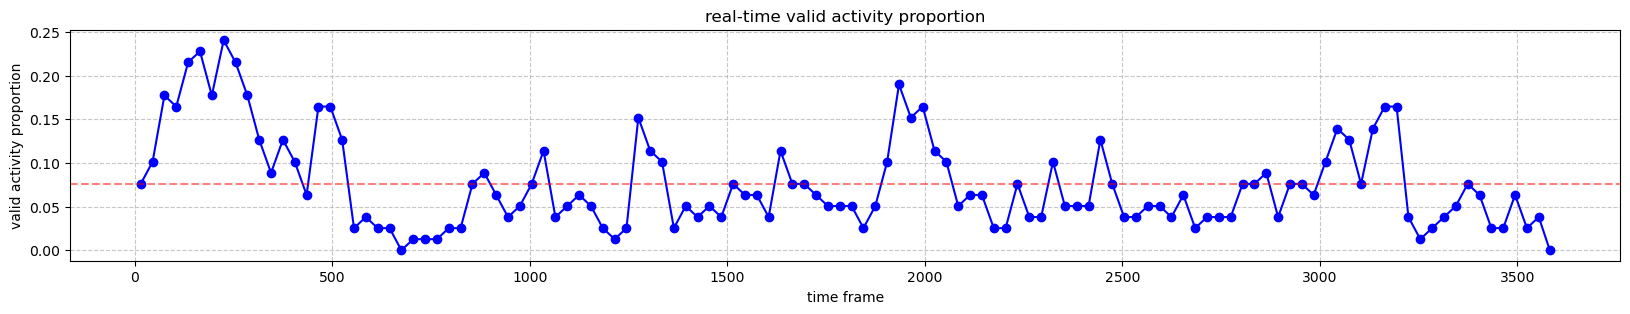

In [37]:
plot_valid_activity_proportions(segments, valid_proportions,threshold=threshold)

In [38]:
def segment_behaviour_data(behaviour_df, frame_rate=10):
    """
    Divide behavioral data into 3-second (30-frame) segments and determine struggling status for each segment.
    
    Parameters:
    behaviour_df: behavioral DataFrame; rows are frames and columns contain behavioral values (0 or 1).
    frame_rate: frame rate, defaulting to 10 frames/second.
    
    Returns:
    DataFrame containing segment information and struggling status.
    """
    total_frames = len(behaviour_df)
    segment_duration_frames = 3 * frame_rate  # 3 seconds = 30 frames.
    
    # Create segments.
    segments = []
    for i in range(0, total_frames, segment_duration_frames):
        segment_start = i
        segment_end = min(i + segment_duration_frames - 1, total_frames - 1)
        
        # Extract data for the current segment.
        segment_data = behaviour_df.iloc[segment_start:segment_end+1].values.flatten()
        
        # Compute the mean and determine struggling status.
        avg_value = np.mean(segment_data)
        is_struggle = 1 if avg_value >= 0.5 else 0
        
        segments.append({
            'segment_start': segment_start,
            'segment_end': segment_end,
            'segment_duration': segment_end - segment_start + 1,
            'avg_value': avg_value,
            'is_struggle': is_struggle
        })
    
    return pd.DataFrame(segments)

In [39]:
# Segment the behavioral data.
behaviour_segments = segment_behaviour_data(behaviour_im_with_head)

In [40]:
df_coverage_updated = coverage_df_.copy()  # Create a copy to avoid modifying the original data.
df_coverage_updated['coverage_type'] = df_coverage_updated['coverage_type'].replace({
    'No coverage': '0',
    'Partial coverage': '1',
    'Full coverage': '2'
})
df_coverage_updated.rename(columns={'window_start_frame': 'seg_start_frame', 'window_end_frame': 'seg_end_frame'}, inplace=True)

In [41]:
behaviour_segments.rename(columns={'segment_start': 'seg_start_frame'}, inplace=True)

# First merge the three DataFrames using their shared keys.
aligned_df = pd.merge(df_coverage_updated, assigned_segments_df_events2, 
                     on=['neuron_id', 'seg_start_frame'], how='inner')
aligned_df = pd.merge(aligned_df, assigned_segments_df_events3, 
                     on=['neuron_id', 'seg_start_frame'], how='inner')
aligned_df = pd.merge(aligned_df, behaviour_segments, 
                     on=['seg_start_frame'], how='inner')

# Define a function to one-hot encode class labels.
def create_one_hot_columns(df, source_col, prefix, categories=['None', '0', '1', '2']):
    """Convert classes in the source column into three one-hot encoded columns."""
    # Initialize the result columns.
    df[f'{prefix}_1'] = 0
    df[f'{prefix}_2'] = 0
    df[f'{prefix}_3'] = 0
    
    # Set the corresponding values based on class.
    if 'None' in categories:
        df.loc[df[source_col] == 'None', [f'{prefix}_1', f'{prefix}_2', f'{prefix}_3']] = 0
    if '0' in categories:
        df.loc[df[source_col] == '0', [f'{prefix}_1', f'{prefix}_2', f'{prefix}_3']] = [1, 0, 0]
    if '1' in categories:
        df.loc[df[source_col] == '1', [f'{prefix}_1', f'{prefix}_2', f'{prefix}_3']] = [0, 1, 0]
    if '2' in categories:
        df.loc[df[source_col] == '2', [f'{prefix}_1', f'{prefix}_2', f'{prefix}_3']] = [0, 0, 1]
    
    return df

# Create the three coverage feature columns.
aligned_df = create_one_hot_columns(aligned_df, 'coverage_type', 'coverage')

# Create the three intensity feature columns.
aligned_df = create_one_hot_columns(aligned_df, 'cluster_label_str', 'intensity')

# Create the three duration feature columns.
aligned_df = create_one_hot_columns(aligned_df, 'kmeans_cluster_str', 'duration')

# Inspect the first few rows and newly created columns.
display(aligned_df[['neuron_id', 'seg_start_frame', 'seg_end_frame', 
                   'coverage_1', 'coverage_2', 'coverage_3',
                   'intensity_1', 'intensity_2', 'intensity_3',
                   'duration_1', 'duration_2', 'duration_3','is_struggle']].head())

# Verify the encoding.
print("\nVerify coverage_type encoding:")
print(aligned_df.groupby('coverage_type')[['coverage_1', 'coverage_2', 'coverage_3']].max())

print("\nVerify cluster_label_str encoding:")
print(aligned_df.groupby('cluster_label_str')[['intensity_1', 'intensity_2', 'intensity_3']].max())

print("\nVerify kmeans_cluster_str encoding:")
print(aligned_df.groupby('kmeans_cluster_str')[['duration_1', 'duration_2', 'duration_3']].max())

# Optionally retain only the new features and key columns.
result_df = aligned_df[['neuron_id', 'seg_start_frame', 'seg_end_frame', 
                       'coverage_1', 'coverage_2', 'coverage_3',
                       'intensity_1', 'intensity_2', 'intensity_3',
                       'duration_1', 'duration_2', 'duration_3','is_struggle']].copy()

# Save results to a CSV file.
# result_df.to_csv('aligned_features_with_one_hot_encoding.csv', index=False)
# print("\nResults saved to 'aligned_features_with_one_hot_encoding.csv'")


single_neuron_features = result_df.copy()

,neuron_id,seg_start_frame,seg_end_frame,coverage_1,coverage_2,coverage_3,intensity_1,intensity_2,intensity_3,duration_1,duration_2,duration_3,is_struggle
0,5,0,29,0,1,0,0,0,0,0,0,0,1
1,5,30,59,0,0,1,0,0,1,0,1,0,1
2,5,60,89,0,1,0,0,0,1,0,1,0,1
3,5,90,119,0,0,1,0,0,1,0,1,0,1
4,5,120,149,0,1,0,0,0,1,0,1,0,1



Verify coverage_type encoding:
               coverage_1  coverage_2  coverage_3
coverage_type                                    
0                       1           0           0
1                       0           1           0
2                       0           0           1
None                    0           0           0

Verify cluster_label_str encoding:
                   intensity_1  intensity_2  intensity_3
cluster_label_str                                       
0                            1            0            0
1                            0            1            0
2                            0            0            1
None                         0            0            0

Verify kmeans_cluster_str encoding:
                    duration_1  duration_2  duration_3
kmeans_cluster_str                                    
0                            1           0           0
1                            0           1           0
2                            0   

In [42]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

ANALYSIS_FPS = 10
WINDOW_SIZE_FRAMES = 30
TRAIN_SECONDS = 120
TOTAL_SECONDS = 360
TRAIN_END_FRAME = ANALYSIS_FPS * TRAIN_SECONDS
TOTAL_END_FRAME = ANALYSIS_FPS * TOTAL_SECONDS

BASE_K = 2
FEATURE_K_CANDIDATES = (3, 4)
FIXED_FEATURE_K = None  # Set to 3 or 4; None selects k by silhouette score.
TIE_TOLERANCE = 1e-12
SAVE_FIGURES = False

FEATURE_COLUMNS = [
    'coverage_1', 'coverage_2', 'coverage_3',
    'intensity_1', 'intensity_2', 'intensity_3',
    'duration_1', 'duration_2', 'duration_3',
]

required_inputs = {'resized_df_signal_neuron_raw', 'single_neuron_features'}
missing_inputs = sorted(name for name in required_inputs if name not in globals())
if missing_inputs:
    raise NameError(f'Run the original notebook through cell 41 first; missing variables: {missing_inputs}')

print('Configuration complete: fit using the first 2 minutes; the final 4 minutes are excluded from neuronal clustering.')

Configuration complete: fit using the first 2 minutes; the final 4 minutes are excluded from neuronal clustering.


In [43]:
# Copy only columns permitted in this workflow; other input columns are not read.
required_feature_columns = {'neuron_id', 'seg_start_frame', *FEATURE_COLUMNS}
missing_columns = sorted(required_feature_columns - set(single_neuron_features.columns))
if missing_columns:
    raise ValueError(f'single_neuron_features is missing columns: {missing_columns}')

feature_rows = single_neuron_features[
    ['neuron_id', 'seg_start_frame', *FEATURE_COLUMNS]
].copy()

if feature_rows.duplicated(['neuron_id', 'seg_start_frame']).any():
    duplicated = feature_rows.loc[
        feature_rows.duplicated(['neuron_id', 'seg_start_frame'], keep=False),
        ['neuron_id', 'seg_start_frame'],
    ].head()
    raise ValueError(f'Duplicate neuron-window records found, for example:\n{duplicated}')

feature_rows['seg_start_frame'] = pd.to_numeric(
    feature_rows['seg_start_frame'], errors='raise'
).astype(int)
feature_rows[FEATURE_COLUMNS] = feature_rows[FEATURE_COLUMNS].apply(
    pd.to_numeric, errors='raise'
)
feature_rows = feature_rows[
    (feature_rows['seg_start_frame'] >= 0)
    & (feature_rows['seg_start_frame'] < TOTAL_END_FRAME)
].copy()
feature_rows['split'] = np.where(
    feature_rows['seg_start_frame'] < TRAIN_END_FRAME, 'train', 'late_phase'
)

window_table = (
    feature_rows[['seg_start_frame', 'split']]
    .drop_duplicates()
    .sort_values('seg_start_frame')
    .reset_index(drop=True)
)
window_table['window_id'] = np.arange(len(window_table))

split_window_counts = window_table['split'].value_counts().reindex(['train', 'late_phase'], fill_value=0)
if split_window_counts['train'] == 0:
    raise ValueError('No usable 3-second windows in the first 2 minutes.')

print('Window counts:', split_window_counts.to_dict())
print('Columns actually read by this workflow:', feature_rows.columns.tolist())

Window counts: {'train': 40, 'late_phase': 80}
Columns actually read by this workflow: ['neuron_id', 'seg_start_frame', 'coverage_1', 'coverage_2', 'coverage_3', 'intensity_1', 'intensity_2', 'intensity_3', 'duration_1', 'duration_2', 'duration_3', 'split']


In [44]:
# First level: use only the first 2 minutes of signal, z-score each neuron, and apply Ward clustering with k=2 to neurons.
signal_df = resized_df_signal_neuron_raw.copy()
if len(signal_df) < TRAIN_END_FRAME:
    raise ValueError(
        f'The original signal has only {len(signal_df)} frames, fewer than the {TRAIN_END_FRAME} required for the first 2 minutes.'
    )

feature_neuron_ids = set(feature_rows['neuron_id'].unique())
eligible_neuron_ids = [col for col in signal_df.columns if col in feature_neuron_ids]
signal_only_ids = [col for col in signal_df.columns if col not in feature_neuron_ids]
feature_only_ids = [nid for nid in feature_neuron_ids if nid not in set(signal_df.columns)]
if signal_only_ids or feature_only_ids:
    warnings.warn(
        f'neuron_id values differ between the two tables; analyze only their intersection.'
        f' signal_only={len(signal_only_ids)}, feature_only={len(feature_only_ids)}'
    )
if len(eligible_neuron_ids) < 4:
    raise ValueError('Fewer than 4 neurons are shared by the input tables; subsequent clustering into 3 or 4 classes is not possible.')

train_signal = signal_df.loc[:, eligible_neuron_ids].iloc[:TRAIN_END_FRAME].apply(
    pd.to_numeric, errors='raise'
).to_numpy(dtype=float)
train_mean = np.nanmean(train_signal, axis=0)
train_std = np.nanstd(train_signal, axis=0, ddof=0)
constant_mask = (~np.isfinite(train_std)) | (train_std == 0)
if constant_mask.any():
    warnings.warn(f'{int(constant_mask.sum())} neurons have zero variance in the training segment; set their z-scores to 0.')
safe_std = train_std.copy()
safe_std[constant_mask] = 1.0
train_z = (train_signal - train_mean) / safe_std
train_z[:, constant_mask] = 0.0
if not np.isfinite(train_z).all():
    raise ValueError('The training signal contains NaN/Inf values that cannot be handled.')

base_Z = linkage(train_z.T, method='ward')
base_labels = fcluster(base_Z, BASE_K, criterion='maxclust').astype(int)
if len(np.unique(base_labels)) != BASE_K:
    raise ValueError('First-level Ward clustering did not produce two nonempty clusters; check the training signals.')

base_cluster_assignments = pd.DataFrame({
    'neuron_id': eligible_neuron_ids,
    'base_cluster': base_labels,
})
base_cluster_sizes = base_cluster_assignments['base_cluster'].value_counts().sort_index()
print('First-level neutral cluster sizes:')
display(base_cluster_sizes.rename('neuron_count').to_frame())

First-level neutral cluster sizes:


,neuron_count
base_cluster,
1,22
2,57


In [45]:
# Use the mean activity of the two base clusters to determine which dominates each 3-second window.
# Each feature family has exactly one active one-hot value when an event is present, so the sum of the nine columns divided by 3 lies between 0 and 1.
feature_rows = feature_rows.merge(
    base_cluster_assignments, on='neuron_id', how='inner', validate='many_to_one'
)
feature_rows['activity_score'] = feature_rows[FEATURE_COLUMNS].sum(axis=1) / 3.0

window_cluster_activity = (
    feature_rows.groupby(['seg_start_frame', 'base_cluster'], as_index=False)['activity_score']
    .mean()
    .pivot(index='seg_start_frame', columns='base_cluster', values='activity_score')
    .reindex(columns=[1, 2], fill_value=0.0)
    .rename(columns={1: 'cluster1_activity', 2: 'cluster2_activity'})
    .reset_index()
)
window_cluster_activity = window_table.merge(
    window_cluster_activity, on='seg_start_frame', how='left', validate='one_to_one'
)
window_cluster_activity[['cluster1_activity', 'cluster2_activity']] = (
    window_cluster_activity[['cluster1_activity', 'cluster2_activity']].fillna(0.0)
)
activity_delta = (
    window_cluster_activity['cluster1_activity']
    - window_cluster_activity['cluster2_activity']
)
window_cluster_activity['dominant_cluster'] = np.select(
    [activity_delta > TIE_TOLERANCE, activity_delta < -TIE_TOLERANCE],
    [1, 2],
    default=0,
).astype(int)
feature_rows = feature_rows.merge(
    window_cluster_activity[['seg_start_frame', 'dominant_cluster']],
    on='seg_start_frame', how='left', validate='many_to_one'
)

dominance_summary = (
    window_cluster_activity.groupby(['split', 'dominant_cluster'])
    .size().rename('window_count').reset_index()
)
print('dominant_cluster=0 indicates equal activity in both base clusters; these windows are excluded from subsequent fitting:')
display(dominance_summary)

dominant_cluster=0 indicates equal activity in both base clusters; these windows are excluded from subsequent fitting:


,split,dominant_cluster,window_count
0,late_phase,0,1
1,late_phase,1,46
2,late_phase,2,33
3,train,1,21
4,train,2,19


In [46]:
# Second-level input: use non-tied windows from the full recording to construct 9 x 2 = 18 features per neuron.
fit_rows = feature_rows[
    feature_rows['dominant_cluster'].isin([1, 2])
].copy()
available_states = set(fit_rows['dominant_cluster'].unique())
if available_states != {1, 2}:
    raise ValueError(
        f'The training segment must contain windows dominated by both cluster 1 and cluster 2; found {sorted(available_states)}'
    )

condition_means = (
    fit_rows.groupby(['neuron_id', 'dominant_cluster'])[FEATURE_COLUMNS]
    .mean()
)
all_fit_ids = base_cluster_assignments['neuron_id'].tolist()
expected_index = pd.MultiIndex.from_product(
    [all_fit_ids, [1, 2]], names=['neuron_id', 'dominant_cluster']
)
condition_means = condition_means.reindex(expected_index)
if condition_means.isna().any().any():
    raise ValueError('At least one neuron lacks feature records for a dominance class; filling these with 0 is not safe.')

rows = []
for neuron_id in all_fit_ids:
    row = {'neuron_id': neuron_id}
    for feature in FEATURE_COLUMNS:
        row[f'{feature}_cluster1'] = float(condition_means.loc[(neuron_id, 1), feature])
        row[f'{feature}_cluster2'] = float(condition_means.loc[(neuron_id, 2), feature])
    rows.append(row)

neuron_features_df = pd.DataFrame(rows).merge(
    base_cluster_assignments, on='neuron_id', how='left', validate='one_to_one'
)
FEATURE_18_COLUMNS = [
    f'{feature}_cluster{cluster_id}'
    for feature in FEATURE_COLUMNS
    for cluster_id in (1, 2)
]
cluster1_columns = [f'{feature}_cluster1' for feature in FEATURE_COLUMNS]
cluster2_columns = [f'{feature}_cluster2' for feature in FEATURE_COLUMNS]
neuron_features_df['cluster1_response'] = neuron_features_df[cluster1_columns].sum(axis=1) / 3.0
neuron_features_df['cluster2_response'] = neuron_features_df[cluster2_columns].sum(axis=1) / 3.0
neuron_features_df['cluster_bias_index'] = (
    neuron_features_df['cluster1_response'] - neuron_features_df['cluster2_response']
)

X = neuron_features_df[FEATURE_18_COLUMNS].to_numpy(dtype=float)
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X)
print(f'18-dimensional features complete: {len(neuron_features_df)} neurons x {len(FEATURE_18_COLUMNS)} dimensions.')
display(neuron_features_df.head())

18-dimensional features complete: 79 neurons x 18 dimensions.


,neuron_id,coverage_1_cluster1,coverage_1_cluster2,coverage_2_cluster1,coverage_2_cluster2,coverage_3_cluster1,coverage_3_cluster2,intensity_1_cluster1,intensity_1_cluster2,intensity_2_cluster1,...,duration_1_cluster1,duration_1_cluster2,duration_2_cluster1,duration_2_cluster2,duration_3_cluster1,duration_3_cluster2,base_cluster,cluster1_response,cluster2_response,cluster_bias_index
0,5,0.029851,0.057692,0.014925,0.096154,0.029851,0.096154,0.000000,0.038462,0.014925,...,0.014925,0.076923,0.029851,0.076923,0.000000,0.000000,2,0.054726,0.185897,-0.131171
1,7,0.029851,0.019231,0.194030,0.115385,0.014925,0.019231,0.044776,0.000000,0.014925,...,0.059701,0.019231,0.014925,0.057692,0.000000,0.000000,1,0.129353,0.102564,0.026789
2,8,0.014925,0.076923,0.059701,0.173077,0.000000,0.153846,0.014925,0.038462,0.000000,...,0.014925,0.153846,0.000000,0.000000,0.014925,0.134615,2,0.044776,0.326923,-0.282147
3,9,0.014925,0.019231,0.029851,0.134615,0.000000,0.019231,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.076923,0.000000,0.000000,2,0.014925,0.108974,-0.094049
4,10,0.000000,0.019231,0.014925,0.192308,0.000000,0.038462,0.014925,0.057692,0.000000,...,0.014925,0.057692,0.000000,0.096154,0.000000,0.000000,2,0.014925,0.185897,-0.170972


In [47]:
# Second level: apply Ward clustering with 3 or 4 clusters to the 18-dimensional response features.
if FIXED_FEATURE_K not in (None, *FEATURE_K_CANDIDATES):
    raise ValueError(f'FIXED_FEATURE_K must be None or one of {FEATURE_K_CANDIDATES}')
if len(neuron_features_df) <= max(FEATURE_K_CANDIDATES):
    raise ValueError('The neuron count must exceed the largest candidate k.')

Z = linkage(X_scaled, method='ward')
cluster_labels_dict = {}
silhouette_rows = []
for k in FEATURE_K_CANDIDATES:
    labels = fcluster(Z, k, criterion='maxclust').astype(int)
    cluster_labels_dict[k] = labels
    actual_k = len(np.unique(labels))
    score = silhouette_score(X_scaled, labels) if actual_k == k else np.nan
    silhouette_rows.append({'k': k, 'actual_k': actual_k, 'silhouette_score': score})

silhouette_df = pd.DataFrame(silhouette_rows)
if FIXED_FEATURE_K is None:
    valid_scores = silhouette_df.dropna(subset=['silhouette_score'])
    if valid_scores.empty:
        raise ValueError('Neither k=3 nor k=4 produced the expected number of nonempty clusters.')
    best_k = int(valid_scores.loc[valid_scores['silhouette_score'].idxmax(), 'k'])
else:
    best_k = int(FIXED_FEATURE_K)
    actual_k = int(silhouette_df.loc[silhouette_df['k'] == best_k, 'actual_k'].iloc[0])
    if actual_k != best_k:
        raise ValueError(f'Requested k={best_k}, but only {actual_k} clusters were produced.')

best_labels = cluster_labels_dict[best_k]
neuron_features_df['feature_cluster'] = best_labels
neuron_features_df['cluster'] = best_labels  # Preserve the column name expected by the original cell 49 and later cells.

# Numeric labels are unordered: the lowest mean indicates cluster2 bias, the highest indicates cluster1 bias, and intermediate clusters are merged as dual; only feature clusters with at least 4 neurons qualify for a bias label.
MIN_BIAS_NEURON_COUNT = 4

feature_cluster_summary = (
    neuron_features_df.groupby('feature_cluster')
    .agg(
        cluster_bias_index_mean=('cluster_bias_index', 'mean'),
        neuron_count=('neuron_id', 'size'),
    )
    .sort_values('cluster_bias_index_mean')
)

feature_cluster_order = feature_cluster_summary.index.tolist()

# feature_cluster_order = (
#     neuron_features_df.groupby('feature_cluster')['cluster_bias_index']
#     .mean().sort_values().index.tolist()
# )
# cluster_mapping = {int(feature_cluster_order[0]): 'bias_cluster2'}
# cluster_mapping[int(feature_cluster_order[-1])] = 'bias_cluster1'
# for numeric_cluster in feature_cluster_order[1:-1]:
#     cluster_mapping[int(numeric_cluster)] = 'dual_response'

# Assign all neurons to dual by default; undersized extreme clusters are not labeled as bias.
cluster_mapping = {
    int(numeric_cluster): 'dual_response'
    for numeric_cluster in feature_cluster_order
}
eligible_bias_clusters = feature_cluster_summary[
    feature_cluster_summary['neuron_count'] >= MIN_BIAS_NEURON_COUNT
]

if len(eligible_bias_clusters) < 2:
    eligible_counts = eligible_bias_clusters['neuron_count'].to_dict()
    all_counts = feature_cluster_summary['neuron_count'].to_dict()
    raise ValueError(
        f'At least 2 feature clusters must each contain > 3 neurons to define '
        f'bias_cluster1 and bias_cluster2 separately. Eligible clusters: {eligible_counts}; '
        f'all cluster sizes: {all_counts}.'
    )
cluster_mapping[int(eligible_bias_clusters.index[0])] = 'bias_cluster2'
cluster_mapping[int(eligible_bias_clusters.index[-1])] = 'bias_cluster1'

neuron_features_df['cluster_name'] = neuron_features_df['feature_cluster'].map(cluster_mapping)

analysis_rows = []
for feature_cluster, group in neuron_features_df.groupby('feature_cluster'):
    for feature in FEATURE_COLUMNS:
        analysis_rows.append({
            'feature_cluster': int(feature_cluster),
            'cluster_name': cluster_mapping[int(feature_cluster)],
            'feature': feature,
            'cluster1_mean': group[f'{feature}_cluster1'].mean(),
            'cluster1_std': group[f'{feature}_cluster1'].std(),
            'cluster2_mean': group[f'{feature}_cluster2'].mean(),
            'cluster2_std': group[f'{feature}_cluster2'].std(),
            'neuron_count': len(group),
        })
analysis_df = pd.DataFrame(analysis_rows)
cluster_analysis = (
    neuron_features_df.groupby(['feature_cluster', 'cluster_name'])
    .agg(
        neuron_count=('neuron_id', 'size'),
        cluster1_response_mean=('cluster1_response', 'mean'),
        cluster2_response_mean=('cluster2_response', 'mean'),
        cluster_bias_index_mean=('cluster_bias_index', 'mean'),
        cluster_bias_index_std=('cluster_bias_index', 'std'),
    )
    .reset_index()
)

print(f'Second-level optimal k={best_k}')
display(silhouette_df)
print('Second-level numeric cluster mapping:', cluster_mapping)
display(cluster_analysis)

cluster_analysis.to_csv(path_save + r'\feature_cluster_analysis.csv', index=False)

Second-level optimal k=3


,k,actual_k,silhouette_score
0,3,3,0.151765
1,4,4,0.147896


Second-level numeric cluster mapping: {3: 'bias_cluster2', 2: 'dual_response', 1: 'bias_cluster1'}


,feature_cluster,cluster_name,neuron_count,cluster1_response_mean,cluster2_response_mean,cluster_bias_index_mean,cluster_bias_index_std
0,1,bias_cluster1,32,0.131530,0.081931,0.049599,0.090351
1,2,dual_response,22,0.017187,0.168706,-0.151520,0.058547
2,3,bias_cluster2,25,0.038209,0.260256,-0.222047,0.070072


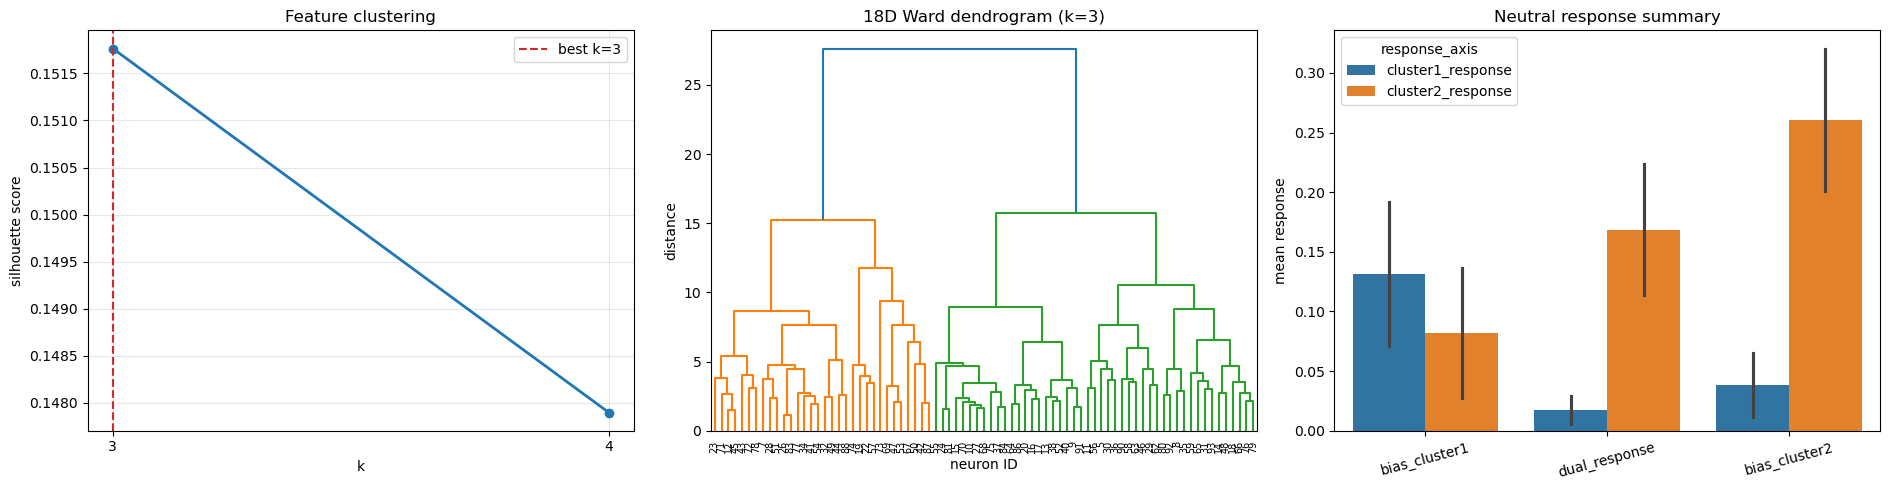

In [48]:
# Diagnostic plots: candidate k values, dendrogram, and cluster1/cluster2 responses of the three neutral functional groups.
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].plot(silhouette_df['k'], silhouette_df['silhouette_score'], 'o-', linewidth=2)
axes[0].axvline(best_k, color='tab:red', linestyle='--', label=f'best k={best_k}')
axes[0].set(xticks=list(FEATURE_K_CANDIDATES), xlabel='k', ylabel='silhouette score', title='Feature clustering')
axes[0].legend()
axes[0].grid(alpha=0.3)

dendrogram(
    Z,
    labels=neuron_features_df['neuron_id'].astype(str).to_numpy(),
    leaf_rotation=90,
    leaf_font_size=7,
    ax=axes[1],
)
axes[1].set(title=f'18D Ward dendrogram (k={best_k})', xlabel='neuron ID', ylabel='distance')

plot_df = neuron_features_df.melt(
    id_vars=['neuron_id', 'cluster_name'],
    value_vars=['cluster1_response', 'cluster2_response'],
    var_name='response_axis', value_name='response',
)
sns.barplot(
    data=plot_df,
    x='cluster_name', y='response', hue='response_axis',
    order=['bias_cluster1', 'dual_response', 'bias_cluster2'],
    errorbar='sd', ax=axes[2],
)
axes[2].set(title='Neutral response summary', xlabel='', ylabel='mean response')
axes[2].tick_params(axis='x', rotation=15)
plt.tight_layout()

if SAVE_FIGURES and 'path_save' in globals():
    output_dir = Path(path_save)
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_dir / 'signal_only_two_stage_clustering.png', dpi=300, bbox_inches='tight')
    fig.savefig(output_dir / 'signal_only_two_stage_clustering.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
# Compute neuronal behavioral bias indices.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
# Define active and inactive features.
active_feature_pairs = {
    'coverage_1': ['coverage_1_cluster2', 'coverage_1_cluster1'],
    'coverage_2': ['coverage_2_cluster2', 'coverage_2_cluster1'],
    'coverage_3': ['coverage_3_cluster2', 'coverage_3_cluster1'],
    'intensity_1': ['intensity_1_cluster2', 'intensity_1_cluster1'],
    'intensity_2': ['intensity_2_cluster2', 'intensity_2_cluster1'],
    'intensity_3': ['intensity_3_cluster2', 'intensity_3_cluster1'],
    'duration_1': ['duration_1_cluster2', 'duration_1_cluster1'],
    'duration_2': ['duration_2_cluster2', 'duration_2_cluster1'],
    'duration_3': ['duration_3_cluster2', 'duration_3_cluster1']
}

# Function to compute base-cluster response bias indices.
def calculate_bias_indices(neuron_features_df):
    """Compute base-cluster response bias indices (C2BI, C1BI, WRI) and their within-cluster standard deviations for each cluster."""
    
    # Get all clusters.
    clusters = sorted(neuron_features_df['cluster'].unique())
    
    # Initialize the results list.
    results = []
    
    # Iterate over clusters.
    for cluster in clusters:
        # Get data for the current cluster.
        cluster_data = neuron_features_df[neuron_features_df['cluster'] == cluster]
        cluster_size = len(cluster_data)
        
        # Initialize the results dictionary for the current cluster.
        cluster_result = {
            'cluster': cluster,
            'neuron_count': cluster_size
        }
        
        # Compute C2BI and C1BI for each active feature pair.
        c2bi_values = []  # Store the overall C2BI value for each neuron.
        c1bi_values = []  # Store the overall C1BI value for each neuron.
        
        for feature_name, (cluster2_col, cluster1_col) in active_feature_pairs.items():
            # Compute C2BI and C1BI for each neuron.
            neuron_c2bi = cluster_data[cluster2_col] - cluster_data[cluster1_col]
            neuron_c1bi = cluster_data[cluster1_col] - cluster_data[cluster2_col]
            
            # Compute cluster-level C2BI and C1BI for this feature.
            cluster_result[f'C2BI_{feature_name}'] = neuron_c2bi.mean()
            cluster_result[f'C1BI_{feature_name}'] = neuron_c1bi.mean()
            
            # Store values used to compute overall C2BI and C1BI.
            c2bi_values.extend(neuron_c2bi)
            c1bi_values.extend(neuron_c1bi)
        
        # Append the current cluster's results to the overall results.
        results.append(cluster_result)
    
    # Convert to a DataFrame.
    result_df = pd.DataFrame(results)
    
    return result_df

# Run the calculation.
# if 'neuron_features_df' in globals() or 'neuron_features_df' in locals():
bias_indices_df = calculate_bias_indices(neuron_features_df)

# Display results.
print("Base-cluster response bias index results:")
display(bias_indices_df)

# # Save results to a CSV file.
# output_file = r'C:\Users\Admin\Desktop\临时图像\cluster_response_bias_indices_detailed.csv'
# bias_indices_df.to_csv(output_file, index=False)
# print(f"\nResults saved to: {output_file}")
    

Base-cluster response bias index results:


,cluster,neuron_count,C2BI_coverage_1,C1BI_coverage_1,C2BI_coverage_2,C1BI_coverage_2,C2BI_coverage_3,C1BI_coverage_3,C2BI_intensity_1,C1BI_intensity_1,C2BI_intensity_2,C1BI_intensity_2,C2BI_intensity_3,C1BI_intensity_3,C2BI_duration_1,C1BI_duration_1,C2BI_duration_2,C1BI_duration_2,C2BI_duration_3,C1BI_duration_3
0,1,32,-0.005166,0.005166,-0.029770,0.029770,-0.018818,0.018818,-0.010898,0.010898,-0.015885,0.015885,-0.020738,0.020738,-0.014585,0.014585,-0.014495,0.014495,-0.018441,0.018441
1,2,22,0.016908,-0.016908,0.157486,-0.157486,0.037496,-0.037496,0.044006,-0.044006,0.022636,-0.022636,0.054692,-0.054692,0.047020,-0.047020,0.066251,-0.066251,0.008063,-0.008063
2,3,25,0.017796,-0.017796,0.153100,-0.153100,0.101975,-0.101975,0.029759,-0.029759,0.071137,-0.071137,0.095741,-0.095741,0.086108,-0.086108,0.018553,-0.018553,0.091975,-0.091975


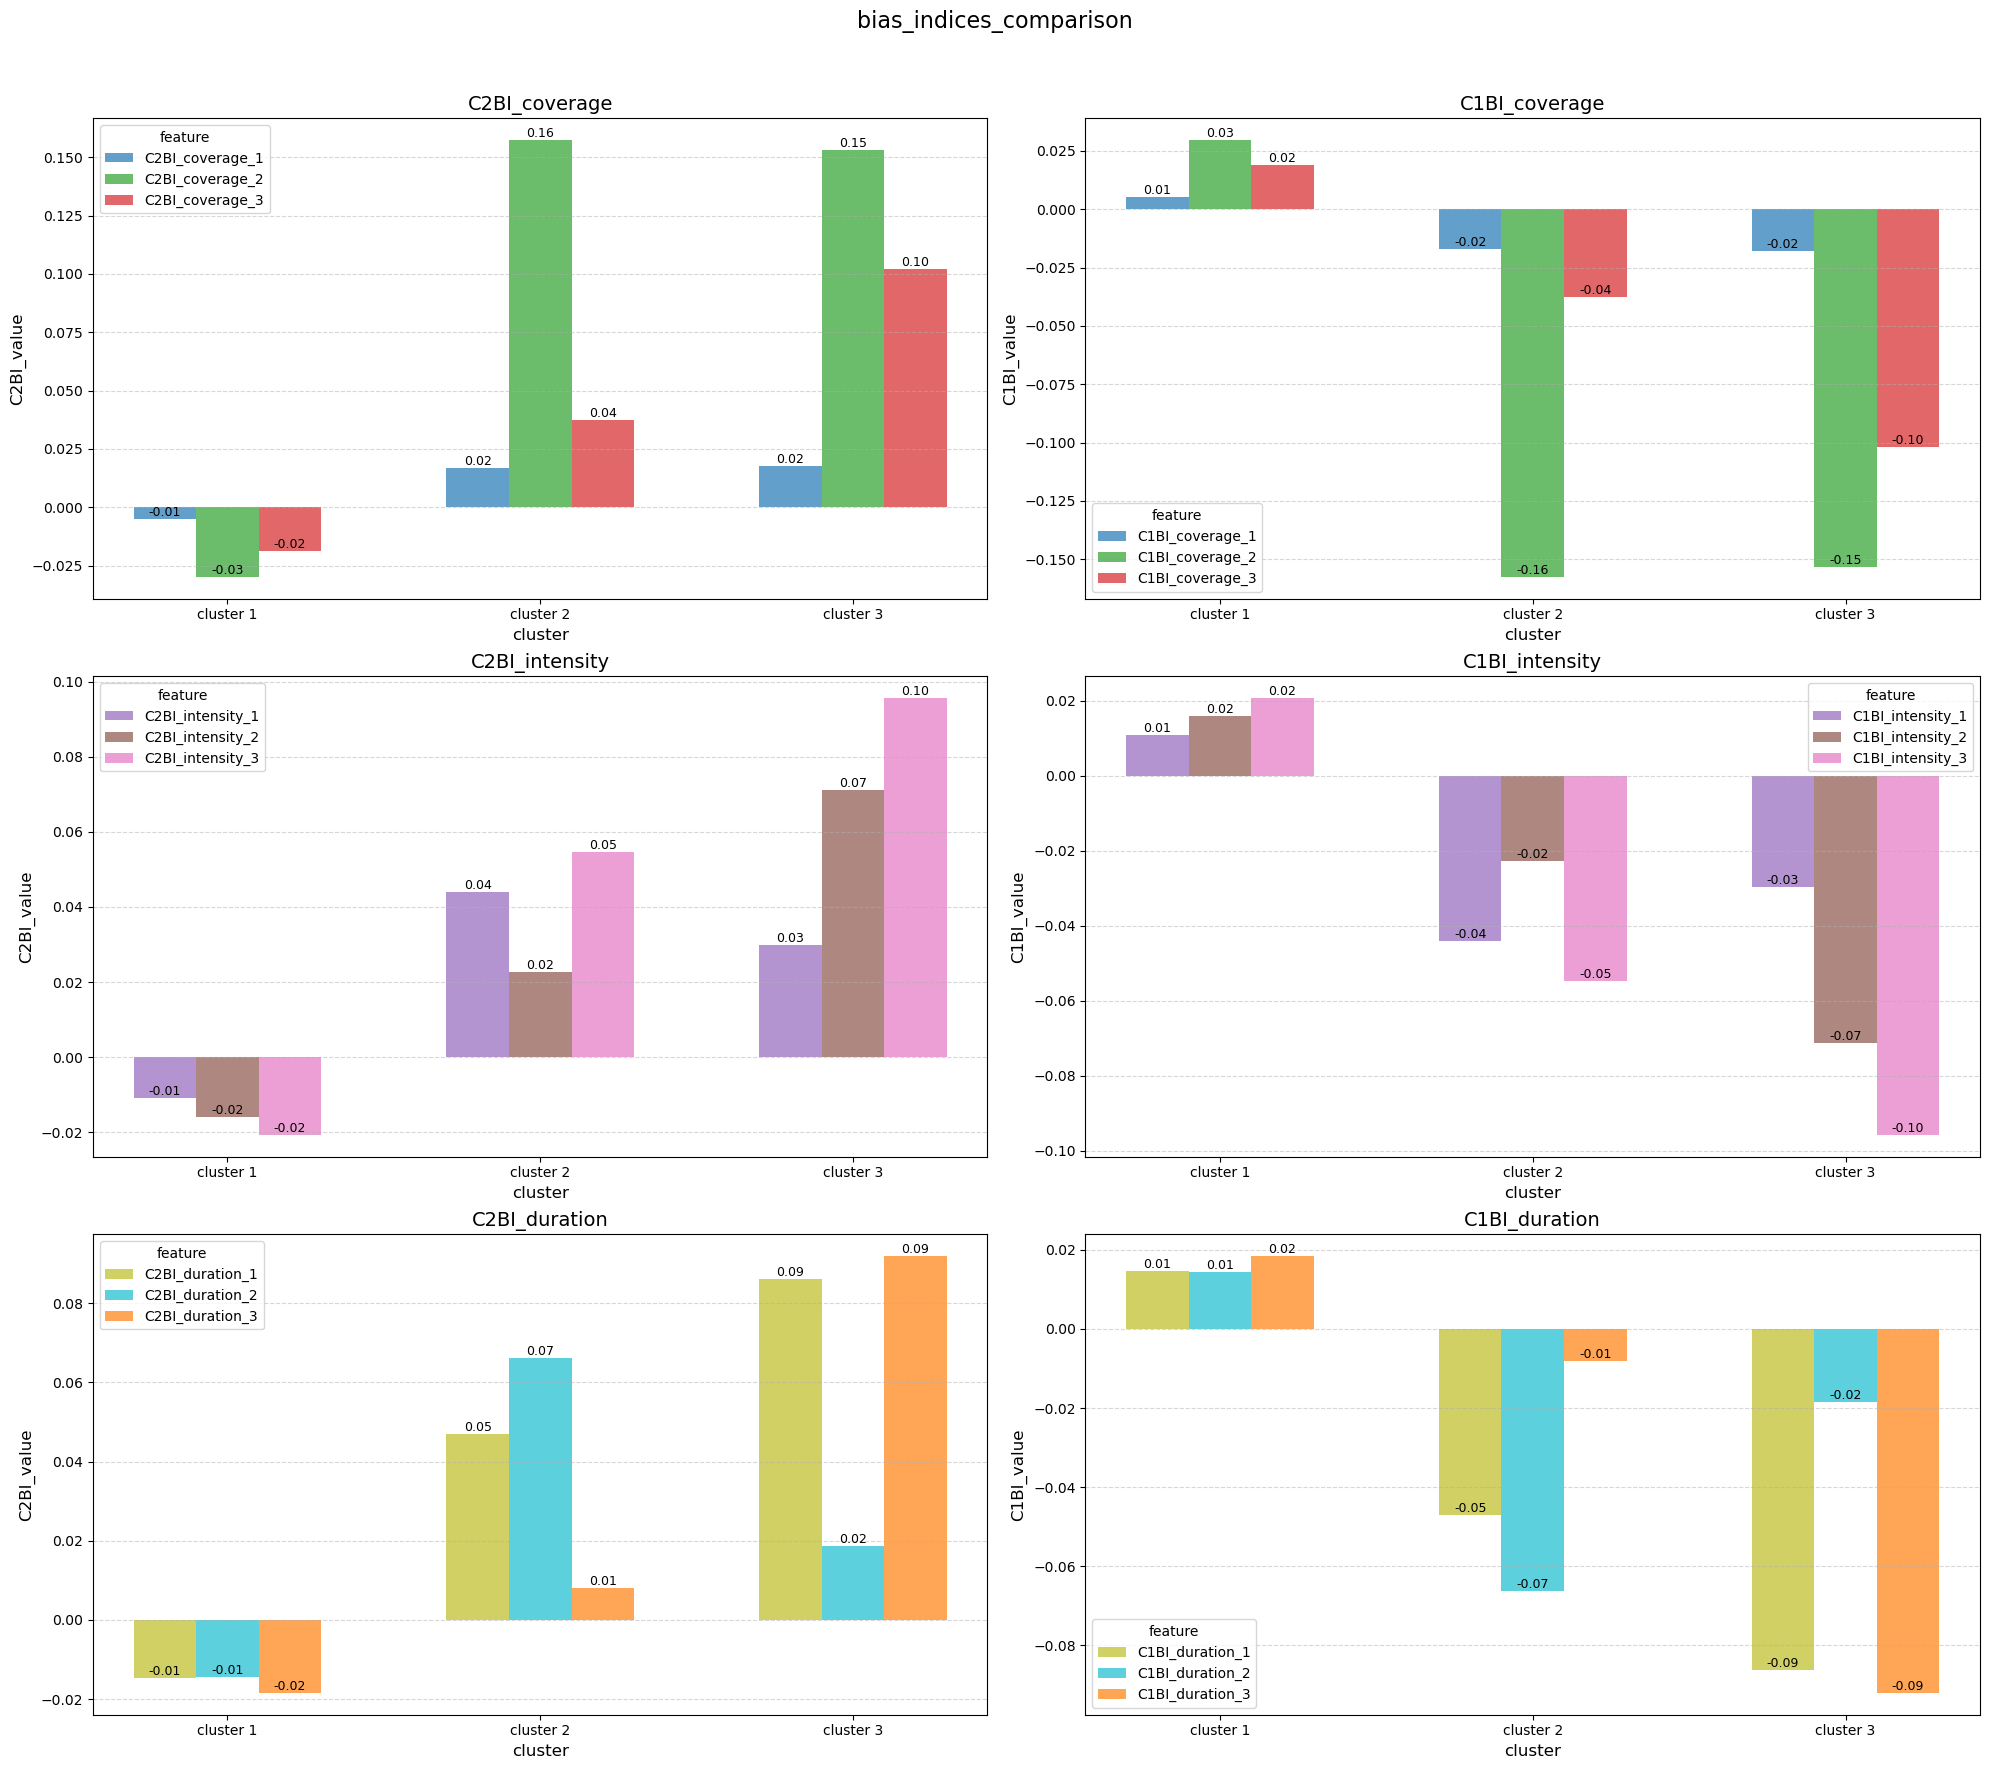

In [51]:
# Define the feature groups to plot.
feature_groups = [
    {
        'title': 'C2BI_coverage',
        'features': ['C2BI_coverage_1', 'C2BI_coverage_2', 'C2BI_coverage_3'],
        'colors': ['#1f77b4', '#2ca02c', '#d62728'],  # Blue, green, red.
        'ylabel': 'C2BI_value'
    },
    {
        'title': 'C1BI_coverage',
        'features': ['C1BI_coverage_1', 'C1BI_coverage_2', 'C1BI_coverage_3'],
        'colors': ['#1f77b4', '#2ca02c', '#d62728'],
        'ylabel': 'C1BI_value'
    },
    {
        'title': 'C2BI_intensity',
        'features': ['C2BI_intensity_1', 'C2BI_intensity_2', 'C2BI_intensity_3'],
        'colors': ['#9467bd', '#8c564b', '#e377c2'],  # Purple, brown, pink.
        'ylabel': 'C2BI_value'
    },
    {
        'title': 'C1BI_intensity',
        'features': ['C1BI_intensity_1', 'C1BI_intensity_2', 'C1BI_intensity_3'],
        'colors': ['#9467bd', '#8c564b', '#e377c2'],
        'ylabel': 'C1BI_value'
    },
    {
        'title': 'C2BI_duration',
        'features': ['C2BI_duration_1', 'C2BI_duration_2', 'C2BI_duration_3'],
        'colors': ['#bcbd22', '#17becf', '#ff7f0e'],  # Yellow-green, cyan, orange.
        'ylabel': 'C2BI_value'
    },
    {
        'title': 'C1BI_duration',
        'features': ['C1BI_duration_1', 'C1BI_duration_2', 'C1BI_duration_3'],
        'colors': ['#bcbd22', '#17becf', '#ff7f0e'],
        'ylabel': 'C1BI_value'
    }
]

# Create a 3-by-3 subplot layout.
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
axes = axes.flatten()  # Flatten the 2D array to 1D for iteration.

# Get all clusters.
clusters = bias_indices_df['cluster'].tolist()
n_clusters = len(clusters)

# Create a bar chart for each feature group.
for i, group in enumerate(feature_groups):
    ax = axes[i]
    
    # Set bar positions.
    bar_width = 0.2  # Bar width.
    x = np.arange(len(clusters))  # Cluster positions.
    
    # Plot bars for each feature.
    for j, feature in enumerate(group['features']):
        # Ensure that the feature exists in the data.
        if feature in bias_indices_df.columns:
            # Compute bar positions.
            bar_positions = x + j * bar_width
            
            # Draw the bars.
            bars = ax.bar(bar_positions, 
                            bias_indices_df[feature].values, 
                            width=bar_width, 
                            label=feature, 
                            color=group['colors'][j],
                            alpha=0.7)
            
            # Add value labels above the bars.
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height, 
                        f'{height:.2f}', 
                        ha='center', va='bottom', fontsize=9)
        else:
            print(f"Warning: feature {feature} is absent from the data.")
    
    # Set plot properties.
    ax.set_title(group['title'], fontsize=14)
    ax.set_xlabel('cluster', fontsize=12)
    ax.set_ylabel(group['ylabel'], fontsize=12)
    ax.set_xticks(x + bar_width)  # Set x-axis tick positions.
    ax.set_xticklabels([f'cluster {c}' for c in clusters])  # Set x-axis tick labels.
    ax.grid(True, linestyle='--', alpha=0.5, axis='y')  # Add grid lines.
    ax.legend(title='feature', loc='best', fontsize=10)

# Hide unused subplots: the 3-by-3 grid has 9 panels, but only 6 are used.
for i in range(len(feature_groups), 6):
    axes[i].axis('off')

# Adjust the layout.
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle('bias_indices_comparison', fontsize=16)
plt.savefig(path_save + r'\bias_indices_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(path_save + r'\bias_indices_comparison.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


In [52]:
# cluster_mapping was generated dynamically in cell 51 from the 18-dimensional feature clusters; behavioral meanings are no longer assigned manually.
expected_cluster_names = {'bias_cluster1', 'bias_cluster2', 'dual_response'}
mapped_cluster_names = set(cluster_mapping.values())
if mapped_cluster_names != expected_cluster_names:
    raise ValueError(
        f'cluster_mapping must contain only {sorted(expected_cluster_names)};'
        f'found {sorted(mapped_cluster_names)}'
    )
print('Reuse the neutral class mapping from cell 51:', cluster_mapping)


Reuse the neutral class mapping from cell 51: {3: 'bias_cluster2', 2: 'dual_response', 1: 'bias_cluster1'}


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

All required data is loaded; starting analysis...

Updated cluster-label distribution:
cluster
bias_cluster1    32
bias_cluster2    25
dual_response    22
Name: count, dtype: int64

Created 120 time segments of 3 seconds each.

Total neurons by class:
cluster
bias_cluster1    32
bias_cluster2    25
dual_response    22
Name: count, dtype: int64


Processing time segments: 100%|██████████| 120/120 [00:00<00:00, 822.76it/s]


Activity-rate calculation complete. Example results:


,segment_id,start_frame,end_frame,total_active_neurons,bias_cluster1_active,bias_cluster1_rate,bias_cluster2_active,bias_cluster2_rate,dual_response_active,dual_response_rate
0,0,0,29,6,1,0.03125,1,0.04,4,0.181818
1,1,30,59,10,0,0.00000,6,0.24,4,0.181818
2,2,60,89,13,0,0.00000,8,0.32,5,0.227273
3,3,90,119,14,2,0.06250,10,0.40,2,0.090909
4,4,120,149,19,1,0.03125,16,0.64,2,0.090909


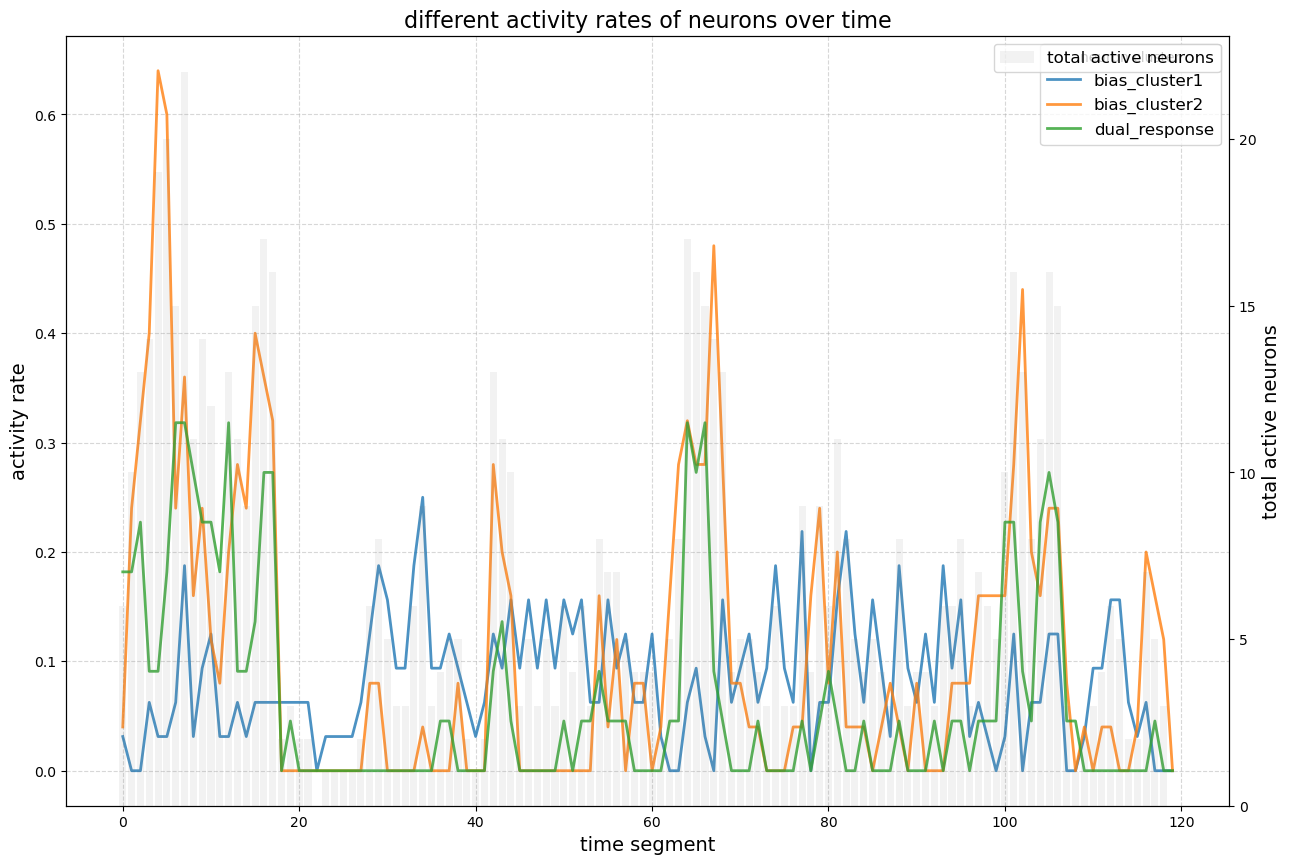


Mean activity rates by class:


,cluster,average_activity_rate
1,bias_cluster2,0.110667
0,bias_cluster1,0.082552
2,dual_response,0.064015


In [54]:
# Analyze neuronal activity within time windows.

print("All required data is loaded; starting analysis...")

# 1. Update the cluster column in neuron_features_df.
def modify_cluster_labels(df, cluster_mapping):
    """Replace numeric labels in the cluster column with text labels."""
    df = df.copy()  # Create a copy to avoid modifying the original data.
    label_mapping = cluster_mapping
    df['cluster'] = df['cluster'].map(label_mapping)
    return df

# Apply the changes.
neuron_features_modified = modify_cluster_labels(neuron_features_df, cluster_mapping)
print("\nUpdated cluster-label distribution:")
print(neuron_features_modified['cluster'].value_counts())

# 2. Divide into 3-second (30-frame) segments.
def create_time_segments(total_frames, segment_size=30):
    """Create time segments."""
    segments = []
    start_frame = 0
    while start_frame < total_frames:
        end_frame = min(start_frame + segment_size - 1, total_frames - 1)
        segments.append((start_frame, end_frame))
        start_frame += segment_size
    return segments

# Get the total frame count and create time segments.
total_frames = resized_df_signal_neuron.shape[0]
time_segments = create_time_segments(total_frames)
print(f"\nCreated {len(time_segments)} time segments of 3 seconds each.")

# 3. Process events and map them to time segments.
def get_active_neurons_in_segment(segment_start, segment_end, events_df, min_active_frames=15):
    """Get neurons active within the specified time segment."""
    # Select events overlapping the current time segment.
    overlapping_events = events_df[
        (events_df['start_frame'] <= segment_end) & 
        (events_df['end_frame'] >= segment_start)
    ].copy()
    
    if overlapping_events.empty:
        return set()
    
    # Compute each event's active frame count within the current time segment.
    overlapping_events['active_in_segment_start'] = overlapping_events['start_frame'].apply(lambda x: max(x, segment_start))
    overlapping_events['active_in_segment_end'] = overlapping_events['end_frame'].apply(lambda x: min(x, segment_end))
    overlapping_events['active_frames_in_segment'] = overlapping_events['active_in_segment_end'] - overlapping_events['active_in_segment_start'] + 1
    
    # Select neurons whose events have at least 15 active frames.
    active_neurons = overlapping_events[
        overlapping_events['active_frames_in_segment'] >= min_active_frames
    ]['neuron_id'].unique()
    
    return set(active_neurons)

# 4. Compute activity rates for each class in each time segment.
def calculate_activity_rates(neuron_features, events_df, time_segments):
    """Compute neuronal activity rates for each class in each time segment."""
    # Get the total number of neurons in each class.
    cluster_counts = neuron_features['cluster'].value_counts()
    print("\nTotal neurons by class:")
    print(cluster_counts)
    
    # Initialize the results list.
    results = []
    
    # Process each time segment.
    for i, (start, end) in enumerate(tqdm(time_segments, desc="Processing time segments")):
        # Get neurons active in the current time segment.
        active_neurons = get_active_neurons_in_segment(start, end, events_df)
        
        # Create a results dictionary for the current time segment.
        segment_result = {
            'segment_id': i,
            'start_frame': start,
            'end_frame': end,
            'total_active_neurons': len(active_neurons)
        }
        
        # Compute the activity rate for each class.
        for cluster in cluster_counts.index:
            # Get all neurons in this class.
            cluster_neurons = set(neuron_features[neuron_features['cluster'] == cluster]['neuron_id'])
            # Count neurons in this class active during the current time segment.
            active_in_cluster = len(cluster_neurons.intersection(active_neurons))
            # Compute the activity rate.
            activity_rate = active_in_cluster / len(cluster_neurons) if len(cluster_neurons) > 0 else 0
            # Save results.
            segment_result[f'{cluster}_active'] = active_in_cluster
            segment_result[f'{cluster}_rate'] = activity_rate
        
        results.append(segment_result)
    
    # Convert to a DataFrame.
    results_df = pd.DataFrame(results)
    return results_df, cluster_counts

# Run the activity-rate calculation.
activity_rates_df, cluster_counts = calculate_activity_rates(neuron_features_modified, events_df, time_segments)

print("\nActivity-rate calculation complete. Example results:")
display(activity_rates_df.head())

# 5. Visualize the results.
def visualize_activity_rates(activity_df, cluster_labels):
    """Visualize activity rates over time for each class."""
    # Create a plot.
    plt.figure(figsize=(15, 10))
    
    # Plot an activity-rate curve for each class.
    for cluster in cluster_labels:
        rate_column = f'{cluster}_rate'
        if rate_column in activity_df.columns:
            plt.plot(activity_df['segment_id'], activity_df[rate_column], 
                        label=cluster, linewidth=2, alpha=0.8)
    
    # Set plot properties.
    plt.title('different activity rates of neurons over time', fontsize=16)
    plt.xlabel('time segment', fontsize=14)
    plt.ylabel('activity rate', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='neuron cluster', fontsize=12)
    
    # Add the total active neuron count per time segment on a secondary y-axis.
    ax2 = plt.gca().twinx()
    ax2.bar(activity_df['segment_id'], activity_df['total_active_neurons'], 
            alpha=0.1, color='gray', label='total active neurons')
    ax2.set_ylabel('total active neurons', fontsize=14)
    ax2.legend(loc='upper right', fontsize=12)
    plt.savefig(path_save + r'\different activity rates of neurons over time.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(path_save + r'\different activity rates of neurons over time.png', format='png', dpi=300, bbox_inches='tight')
    
    plt.show()

# Call the visualization function.
visualize_activity_rates(activity_rates_df, cluster_counts.index)

# 6. Compute and display the mean activity rate for each class.
def calculate_average_activity_rates(activity_df, cluster_labels):
    """Compute the mean activity rate for each class."""
    avg_rates = {}
    
    for cluster in cluster_labels:
        rate_column = f'{cluster}_rate'
        if rate_column in activity_df.columns:
            avg_rates[cluster] = activity_df[rate_column].mean()
    
    # Convert to a DataFrame and sort.
    avg_rates_df = pd.DataFrame(list(avg_rates.items()), columns=['cluster', 'average_activity_rate'])
    avg_rates_df = avg_rates_df.sort_values('average_activity_rate', ascending=False)
    
    return avg_rates_df

# Compute mean activity rates.
avg_activity_rates = calculate_average_activity_rates(activity_rates_df, cluster_counts.index)

print("\nMean activity rates by class:")
display(avg_activity_rates)


In [55]:
# K-means clustering analysis of neuronal activity rates.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


Updated DataFrame columns:
['segment_id', 'start_frame', 'end_frame', 'total_active_neurons', 'bias_cluster1_active', 'bias_cluster1_rate', 'bias_cluster2_active', 'bias_cluster2_rate', 'dual_response_active', 'dual_response_rate']

Newly created columns: []

Clustering data shape: (120, 3)
K=3, silhouette score=0.4246
K=4, silhouette score=0.4297
K=5, silhouette score=0.4155
K=6, silhouette score=0.4059

Best K: 4, corresponding silhouette score: 0.4297

Cluster distribution:
0    60
1    20
2    29
3    11
Name: count, dtype: int64


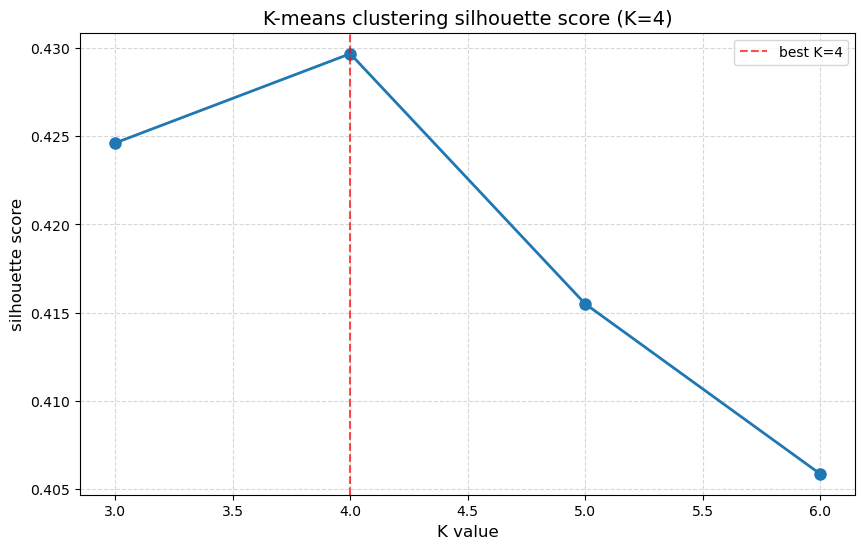

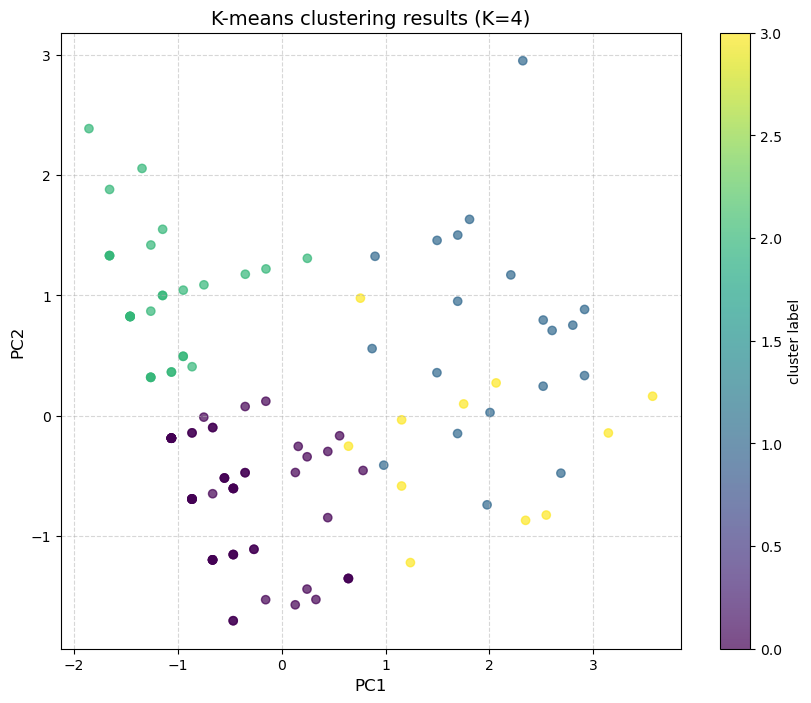

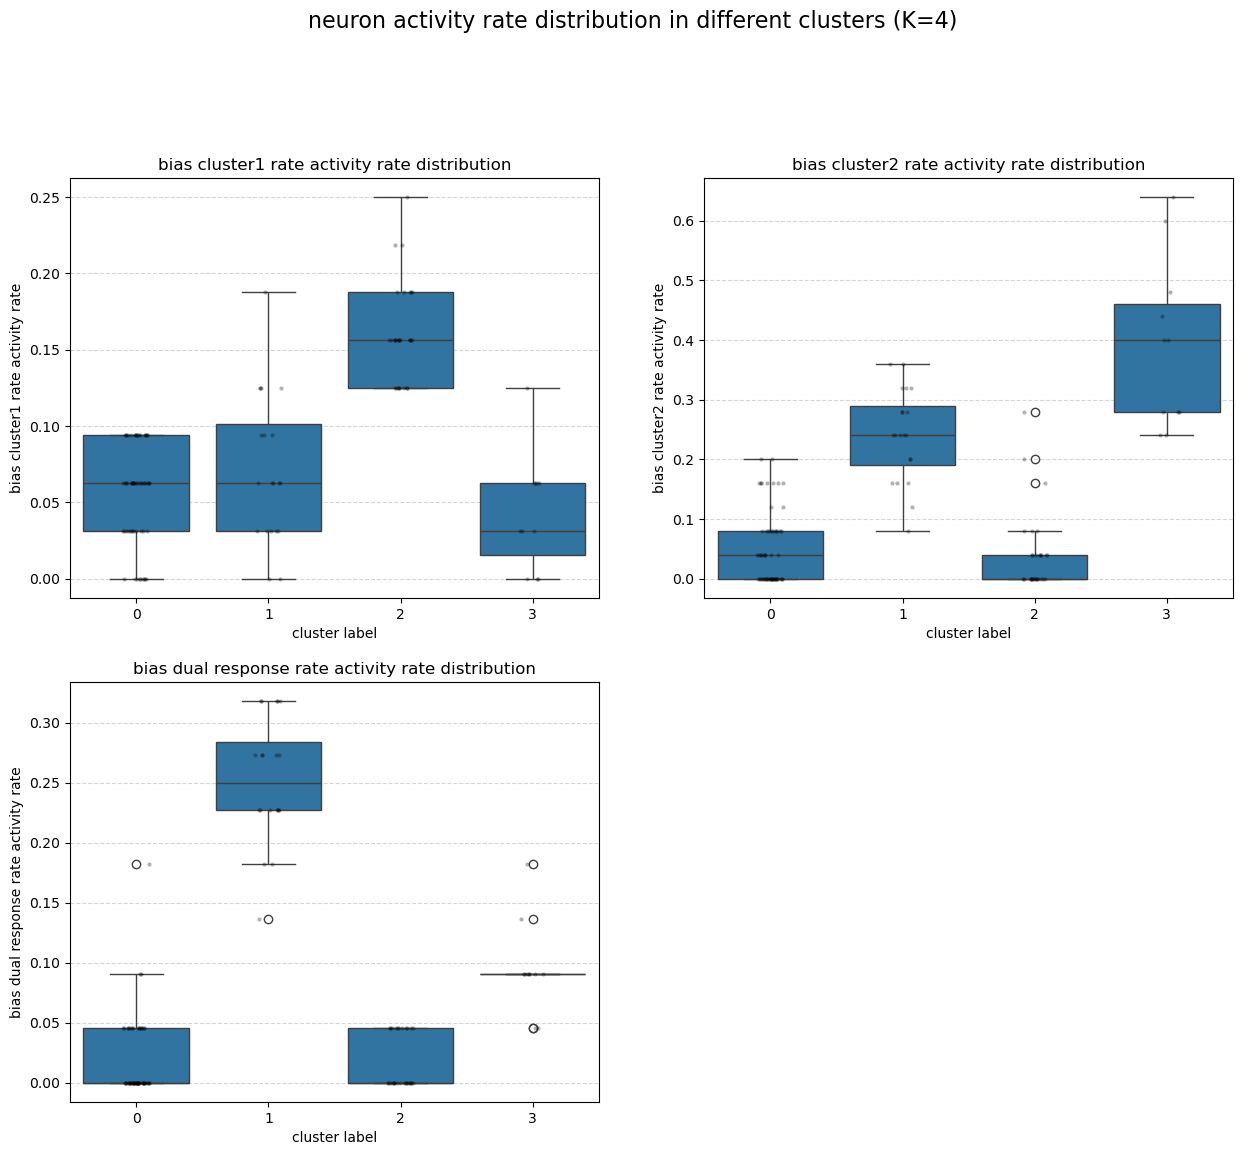


Feature statistics for each cluster:


bias_cluster1_rate         bias_cluster2_rate          \
                      mean     std               mean     std   
cluster                                                         
0                   0.0557  0.0321             0.0500  0.0615   
1                   0.0719  0.0487             0.2400  0.0779   
2                   0.1606  0.0320             0.0414  0.0672   
3                   0.0426  0.0377             0.3891  0.1410   

        dual_response_rate          
                      mean     std  
cluster                             
0                   0.0182  0.0326  
1                   0.2523  0.0521  
2                   0.0172  0.0224  
3                   0.0950  0.0378

In [56]:
def check_and_complete_columns(df):
    """Check for missing columns, add them, and fill them with 0."""
    required_columns = [
        'bias_cluster1_rate',
        'bias_cluster2_rate', 
        'dual_response_rate',
    ]
    
    # Record which columns were newly created.
    newly_created_columns = []
    
    # Check for and add missing columns.
    df_copy = df.copy()
    for col in required_columns:
        if col not in df_copy.columns:
            df_copy[col] = 0
            newly_created_columns.append(col)
            print(f"Warning: column '{col}' was absent; created and filled with 0.")
    
    return df_copy, newly_created_columns

# Apply column checks and additions.
activity_df, new_columns = check_and_complete_columns(activity_rates_df)
print("\nUpdated DataFrame columns:")
print(activity_df.columns.tolist())
print(f"\nNewly created columns: {new_columns}")

# 2. Prepare clustering data and apply weights.
def prepare_clustering_data(df, required_columns, new_columns, weight_factor=0.1):
    """Prepare clustering data and apply weights to newly created columns."""
    # Extract the required columns.
    clustering_data = df[required_columns].values.copy()
    
    # Create a weight array with default weights of 1.
    weights = np.ones(len(required_columns))
    
    # Apply lower weights to newly created columns.
    for i, col in enumerate(required_columns):
        if col in new_columns:
            weights[i] = weight_factor
            print(f"Column '{col}' weight: {weight_factor}")
    
    # Apply weights.
    weighted_data = clustering_data * weights
    
    # Standardize the data.
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(weighted_data)
    
    return scaled_data, weights, scaler

# Define the required columns.
required_columns = [
    'bias_cluster1_rate',
    'bias_cluster2_rate', 
    'dual_response_rate',
]

# Prepare clustering data.
clustering_data, weights, scaler = prepare_clustering_data(
    activity_df, required_columns, new_columns
)

print(f"\nClustering data shape: {clustering_data.shape}")

# 3. Perform K-means clustering and compute silhouette scores.
def perform_kmeans_and_evaluate(data, k_range=(3, 7)):
    """Perform K-means clustering and compute silhouette scores for different K values."""
    silhouette_scores = []
    k_values = list(range(k_range[0], k_range[1]))
    
    # Perform clustering for each K.
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(data)
        
        # Compute the silhouette score.
        score = silhouette_score(data, cluster_labels)
        silhouette_scores.append(score)
        
        print(f"K={k}, silhouette score={score:.4f}")
    
    return k_values, silhouette_scores

# Run the clustering evaluation.
k_values, silhouette_scores = perform_kmeans_and_evaluate(clustering_data)

# 4. Select the best K.
best_k_index = np.argmax(silhouette_scores)
best_k = k_values[best_k_index]
best_score = silhouette_scores[best_k_index]

print(f"\nBest K: {best_k}, corresponding silhouette score: {best_score:.4f}")

# 5. Perform final clustering with the best K.
def perform_final_clustering(data, best_k):
    """Perform final clustering with the best K."""
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(data)
    
    # Get cluster centers.
    cluster_centers = kmeans.cluster_centers_
    
    return cluster_labels, cluster_centers, kmeans

# Run final clustering.
cluster_labels, cluster_centers, kmeans_model = perform_final_clustering(clustering_data, best_k)

# Add clustering results to the original data.
activity_df['cluster'] = cluster_labels

print(f"\nCluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

# 6. Visualize the results.
def visualize_clustering_results(df, cluster_labels, k_values, silhouette_scores, best_k):
    """Visualize clustering results."""
    # 1. Silhouette-score plot.
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, silhouette_scores, 'o-', linewidth=2, markersize=8)
    plt.axvline(x=best_k, color='r', linestyle='--', alpha=0.7, label=f'best K={best_k}')
    plt.title(f'K-means clustering silhouette score (K={best_k})', fontsize=14)
    plt.xlabel('K value', fontsize=12)
    plt.ylabel('silhouette score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    # plt.tight_layout()
    plt.savefig(path_save + r'\total Kmeans clustering silhouette score.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(path_save + r'\total Kmeans clustering silhouette score.png', format='png', dpi=300, bbox_inches='tight')

    plt.show()
    
    # 2. Scatter plot of clustering results using the first two principal components.
    from sklearn.decomposition import PCA
    
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(clustering_data)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
    plt.colorbar(scatter, label='cluster label')
    plt.title(f'K-means clustering results (K={best_k})', fontsize=14)
    plt.xlabel('PC1', fontsize=12)
    plt.ylabel('PC2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    # plt.tight_layout()
    plt.savefig(path_save + r'\total Kmeans clustering results PCA 2 dimension.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(path_save + r'\total Kmeans clustering results PCA 2 dimension.png', format='png', dpi=300, bbox_inches='tight')

    plt.show()
    
    # 3. Box plots of the three features for each class.
    feature_labels = {
        'bias_cluster1_rate': 'bias cluster1 rate',
        'bias_cluster2_rate': 'bias cluster2 rate',
        'dual_response_rate': 'bias dual response rate',
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, (col, label) in enumerate(feature_labels.items()):
        ax = axes[i]
        sns.boxplot(x='cluster', y=col, data=df, ax=ax)
        sns.stripplot(x='cluster', y=col, data=df, size=3, color='black', alpha=0.3, ax=ax)
        ax.set_title(f'{label} activity rate distribution', fontsize=12)
        ax.set_xlabel('cluster label', fontsize=10)
        ax.set_ylabel(f'{label} activity rate', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.5, axis='y')
    
    # plt.tight_layout()
    for unused_ax in axes[len(feature_labels):]:
        unused_ax.axis('off')
    plt.suptitle(f'neuron activity rate distribution in different clusters (K={best_k})', fontsize=16, y=1.02)
    plt.show()

# Call the visualization function.
visualize_clustering_results(activity_df, cluster_labels, k_values, silhouette_scores, best_k)

# 7. Analyze the features of each cluster.
def analyze_cluster_features(df, required_columns):
    """Analyze the features of each cluster."""
    cluster_analysis = df.groupby('cluster')[required_columns].agg(['mean', 'std']).round(4)
    
    print("\nFeature statistics for each cluster:")
    display(cluster_analysis)
    
    return cluster_analysis

# Run the cluster feature analysis.
cluster_analysis = analyze_cluster_features(activity_df, required_columns)


In [57]:
combined_df = combined_df.reset_index().rename(columns={'index': 'segment_id'})
combined_df

,segment_id,segment_start,segment_end,segment_duration,avg_value,is_struggle,proportion,sync_status
0,0,0,29,30,1.000000,1,0.075949,1
1,1,30,59,30,1.000000,1,0.101266,1
2,2,60,89,30,1.000000,1,0.177215,1
3,3,90,119,30,1.000000,1,0.164557,1
4,4,120,149,30,1.000000,1,0.215190,1
...,...,...,...,...,...,...,...,...
115,115,3450,3479,30,0.733333,1,0.025316,0
116,116,3480,3509,30,1.000000,1,0.063291,0
117,117,3510,3539,30,1.000000,1,0.025316,0
118,118,3540,3569,30,1.000000,1,0.037975,0


In [ ]:
# Function: add a segment_id column to single_neuron_features.
def add_segment_id_to_neurons(single_neuron_features):
    """
    Add a segment_id column, assigning consecutive values from 0 to 119 within each neuron.
    
    Parameters:
    single_neuron_features: single-neuron feature DataFrame.
    
    Returns:
    DataFrame with an added segment_id column.
    """
    # Copy the DataFrame to avoid modifying the original data.
    df_copy = single_neuron_features.copy()
    
    # Get and sort all unique neuron IDs.
    unique_neuron_ids = sorted(df_copy['neuron_id'].unique())
    print(f"Found {len(unique_neuron_ids)} unique neuron IDs.")
    
    # # Add the corresponding segment_id for each neuron.
    # segment_ids = []
    
    # for neuron_id in unique_neuron_ids:
    #     # Add 120 time segments (0-119) for each neuron.
    #     segment_ids.extend(range(120))
    
    # # Check that data lengths match.
    # if len(segment_ids) != len(df_copy):
    #     raise ValueError(f"Data length mismatch: expected {len(segment_ids)} rows, got {len(df_copy)} rows.")

    # # Set the segment_id column.
    # df_copy['segment_id'] = segment_ids

    # Assign IDs using actual start frames to support fewer than 120 windows and avoid misalignment from missing windows.
    df_copy['segment_id'] = (df_copy['seg_start_frame'] // (3 * fps)).astype(int)
    
    # Sort by neuron_id and segment_id.
    df_copy = df_copy.sort_values(by=['neuron_id', 'segment_id'])
    
    # Reset the index.
    df_copy = df_copy.reset_index(drop=True)
    
    return df_copy

# Function: combine feature columns.
def merge_feature_column(df, prefix):
    """
    Combine binary values in (xxx_1, xxx_2, xxx_3) into one column.
    
    Parameters:
    df: DataFrame containing data for a single neuron.
    prefix: feature prefix, such as 'coverage', 'intensity', or 'duration'.
    
    Returns:
    Combined column data.
    """
    # Create a results array.
    result = np.zeros(len(df), dtype=int)
    
    # Check each feature column.
    for i in range(1, 4):
        col_name = f"{prefix}_{i}"
        if col_name in df.columns:
            # Find positions where the column equals 1 and set the result to the corresponding index.
            result[df[col_name] == 1] = i
        else:
            print(f"Warning: column {col_name} is absent from the DataFrame.")
    
    return result

# Function: group by neuron and process features.
def process_neuron_features(single_neuron_features_with_segment):
    """
    Group by neuron and process feature columns.
    
    Parameters:
    single_neuron_features_with_segment: single-neuron feature DataFrame with an added segment_id column.
    
    Returns:
    Processed feature dictionary mapping feature names to data.
    """
    # Group by neuron_id.
    grouped = single_neuron_features_with_segment.groupby('neuron_id')
    
    # Create a results dictionary.
    neuron_features_dict = {}
    
    print(f"Starting to process data for {len(grouped)} neurons...")
    
    # Process each neuron.
    for neuron_id, group in grouped:
        # Ensure that each neuron has 120 time segments.
        if len(group) != 120:
            print(f"Warning: neuron ID {neuron_id} has only {len(group)} time segments; expected 120.")
            
        # Sort by segment_id.
        group_sorted = group.sort_values(by='segment_id')
        
        # Combine feature columns.
        coverage_col = merge_feature_column(group_sorted, 'coverage')
        intensity_col = merge_feature_column(group_sorted, 'intensity')
        duration_col = merge_feature_column(group_sorted, 'duration')
        
        # Save to the dictionary.
        neuron_features_dict[f'coverage_{neuron_id}'] = coverage_col
        neuron_features_dict[f'intensity_{neuron_id}'] = intensity_col  
        neuron_features_dict[f'duration_{neuron_id}'] = duration_col  
    
    print(f"Neuronal feature processing complete: generated {len(neuron_features_dict)} feature columns.")
    
    return neuron_features_dict

# Function: integrate all data.
def integrate_all_data(single_neuron_features, activity_df, combined_df):
    """
    Integrate all data into a 120-row table.
    
    Parameters:
    single_neuron_features: single-neuron feature DataFrame.
    activity_df: population activity feature DataFrame.
    combined_df: population synchrony feature DataFrame.
    
    Returns:
    Integrated 120-row DataFrame.
    """
    print("Starting data integration...")
    
    # 1. Add segment_id to the single-neuron data.
    print("Step 1: Add segment_id to the single-neuron data.")
    df_with_segment = add_segment_id_to_neurons(single_neuron_features)
    
    # 2. Process neuronal features.
    print("Step 2: Group by neuron and process feature columns.")
    neuron_features = process_neuron_features(df_with_segment)
    
    # 3. Create the base integrated DataFrame.
    print("Step 3: Create the base integrated DataFrame.")
    # Create a base DataFrame indexed by segment_id.
    final_df = pd.DataFrame(index=range(120))
    final_df['segment_id'] = range(120)
    
    # 4. Add neuronal feature columns.
    print("Step 4: Add neuronal feature columns.")
    for feature_name, feature_data in neuron_features.items():
        if len(feature_data) == 120:
            final_df[feature_name] = feature_data
        else:
            print(f"Warning: {feature_name} has data length {len(feature_data)}; skipping this feature.")
    
    # 5. Merge population features.
    print("Step 5: Merge population features.")
    # Ensure that activity_df and combined_df are sorted by segment_id.
    activity_df_sorted = activity_df.sort_values(by='segment_id')
    combined_df_sorted = combined_df.sort_values(by='segment_id')
    
    # Merge the cluster column.
    if 'cluster' in activity_df_sorted.columns:
        final_df = pd.merge(final_df, activity_df_sorted[['segment_id', 'cluster']], on='segment_id', how='left')
    else:
        print("Warning: cluster column not found in activity_df.")
    
    # Merge the sync_status column.
    if 'sync_status' in combined_df_sorted.columns:
        final_df = pd.merge(final_df, combined_df_sorted[['segment_id', 'sync_status']], on='segment_id', how='left')
    else:
        print("Warning: sync_status column not found in combined_df.")
    
    # Do not merge behavioral columns here; read them only in the post hoc labeling cell after energy valleys have been formed.

    # 6. Handle missing values.
    print("Step 6: Handle missing values.")
    # Fill missing values in numeric columns with 0.
    numeric_cols = final_df.select_dtypes(include=[np.number]).columns
    final_df[numeric_cols] = final_df[numeric_cols].fillna(0)
    
    # 7. Reset the index.
    final_df = final_df.reset_index(drop=True)
    
    print("Data integration complete.")
    return final_df

# Function: inspect data and display results.
def check_and_display_results(single_neuron_features, activity_df, combined_df, final_df):
    """
    Inspect the processed data and display key information.
    """
    print("\n=== Data Processing Results Check ===")
    
    # Inspect single_neuron_features.
    print("\nsingle_neuron_features information:")
    print(f"Shape: {single_neuron_features.shape}")
    print(f"Columns: {single_neuron_features.columns.tolist()}")
    
    # Inspect activity_df.
    print("\nactivity_df information:")
    print(f"Shape: {activity_df.shape}")
    if 'cluster' in activity_df.columns:
        print(f"Unique cluster values: {activity_df['cluster'].unique().tolist()}")
    
    # Inspect combined_df.
    print("\ncombined_df information:")
    print(f"Shape: {combined_df.shape}")
    if 'sync_status' in combined_df.columns:
        print(f"Unique sync_status values: {combined_df['sync_status'].unique().tolist()}")
    # Inspect the final results.
    print("\nFinal integrated results:")
    print(f"Shape: {final_df.shape}")
    print(f"Column count: {len(final_df.columns)}")
    print(f"First 5 columns: {final_df.columns[:5].tolist()}")
    print(f"Last 5 columns: {final_df.columns[-5:].tolist()}")
    
    # Display the first few result rows using only key columns.
    print("\nFirst 5 rows of final results (key columns):")
    key_columns = ['segment_id', 'cluster', 'sync_status']
    key_columns = [col for col in key_columns if col in final_df.columns]
    
    # Check for 120 rows.
    print(f"\nFinal row count: {len(final_df)}")
    if len(final_df) == 120:
        print("✓ Correct row count")
    else:
        print("✗ Incorrect row count; expected 120 rows")
    
    # Check whether segment_id is consecutive.
    segment_ids = final_df['segment_id'].tolist()
    if segment_ids == list(range(120)):
        print("✓ segment_id is consecutive and complete")
    else:
        print("✗ segment_id is incomplete or nonconsecutive")

# Main function: process data and generate results.
def process_and_integrate_data(single_neuron_features, activity_df, combined_df):
    """
    Main function: process data and generate integrated results.
    """
    try:
        # Inspect input data.
        print("Starting data processing...")
        
        # Check for required columns.
        required_columns = {
            'single_neuron_features': ['neuron_id', 'coverage_1', 'coverage_2', 'coverage_3', 
                                      'intensity_1', 'intensity_2', 'intensity_3', 
                                      'duration_1', 'duration_2', 'duration_3'],
            'activity_df': ['segment_id', 'cluster'],
            'combined_df': ['segment_id', 'sync_status']
        }
        
        # Check required columns in each DataFrame.
        for df_name, df in zip(['single_neuron_features', 'activity_df', 'combined_df'], 
                              [single_neuron_features, activity_df, combined_df]):
            missing_cols = [col for col in required_columns[df_name] if col not in df.columns]
            if missing_cols:
                print(f"Warning: {df_name} is missing required columns: {missing_cols}")
        
        # Run data integration.
        final_df = integrate_all_data(single_neuron_features, activity_df, combined_df)
        
        # Check the results.
        check_and_display_results(single_neuron_features, activity_df, combined_df, final_df)
        
        return final_df
        
    except Exception as e:
        print(f"Error processing data: {e}")
        raise


final_df = process_and_integrate_data(single_neuron_features, activity_df, combined_df)

# Display summary statistics for the final results.
print("\n=== Final Results Statistics ===")
print(f"Integrated DataFrame shape: {final_df.shape}")

# Count neuronal feature columns.
coverage_cols_count = len([col for col in final_df.columns if col.startswith('coverage_')])
intensity_cols_count = len([col for col in final_df.columns if col.startswith('intensity_')])
duration_cols_count = len([col for col in final_df.columns if col.startswith('duration_')])

print(f"Number of coverage feature columns: {coverage_cols_count}")
print(f"Number of intensity feature columns: {intensity_cols_count}")
print(f"Number of duration feature columns: {duration_cols_count}")
print(f"Total feature columns: {coverage_cols_count + intensity_cols_count + duration_cols_count}")
    

Starting data processing...
Starting data integration...
Step 1: Add segment_id to the single-neuron data.
Found 79 unique neuron IDs.
Step 2: Group by neuron and process feature columns.
Starting to process data for 79 neurons...
Neuronal feature processing complete: generated 237 feature columns.
Step 3: Create the base integrated DataFrame.
Step 4: Add neuronal feature columns.
Step 5: Merge population features.
Step 6: Handle missing values.
Data integration complete.

=== Data Processing Results Check ===

single_neuron_features information:
Shape: (9480, 13)
Columns: ['neuron_id', 'seg_start_frame', 'seg_end_frame', 'coverage_1', 'coverage_2', 'coverage_3', 'intensity_1', 'intensity_2', 'intensity_3', 'duration_1', 'duration_2', 'duration_3', 'is_struggle']

activity_df information:
Shape: (120, 11)
Unique cluster values: [0, 1, 3, 2]

combined_df information:
Shape: (120, 8)
Unique sync_status values: [1, 0]

Final integrated results:
Shape: (120, 240)
Column count: 240
First 5 

In [59]:
column_mapping = {
    'cluster': 'function_group'
}
final_df = final_df.rename(columns=column_mapping)

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap

In [61]:
neuron_features_df

,neuron_id,coverage_1_cluster1,coverage_1_cluster2,coverage_2_cluster1,coverage_2_cluster2,coverage_3_cluster1,coverage_3_cluster2,intensity_1_cluster1,intensity_1_cluster2,intensity_2_cluster1,...,duration_2_cluster2,duration_3_cluster1,duration_3_cluster2,base_cluster,cluster1_response,cluster2_response,cluster_bias_index,feature_cluster,cluster,cluster_name
0,5,0.029851,0.057692,0.014925,0.096154,0.029851,0.096154,0.000000,0.038462,0.014925,...,0.076923,0.000000,0.000000,2,0.054726,0.185897,-0.131171,3,3,bias_cluster2
1,7,0.029851,0.019231,0.194030,0.115385,0.014925,0.019231,0.044776,0.000000,0.014925,...,0.057692,0.000000,0.000000,1,0.129353,0.102564,0.026789,1,1,bias_cluster1
2,8,0.014925,0.076923,0.059701,0.173077,0.000000,0.153846,0.014925,0.038462,0.000000,...,0.000000,0.014925,0.134615,2,0.044776,0.326923,-0.282147,3,3,bias_cluster2
3,9,0.014925,0.019231,0.029851,0.134615,0.000000,0.019231,0.000000,0.000000,0.000000,...,0.076923,0.000000,0.000000,2,0.014925,0.108974,-0.094049,2,2,dual_response
4,10,0.000000,0.019231,0.014925,0.192308,0.000000,0.038462,0.014925,0.057692,0.000000,...,0.096154,0.000000,0.000000,2,0.014925,0.185897,-0.170972,2,2,dual_response
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,88,0.000000,0.038462,0.089552,0.038462,0.044776,0.057692,0.014925,0.038462,0.029851,...,0.000000,0.029851,0.019231,2,0.114428,0.096154,0.018274,1,1,bias_cluster1
75,90,0.000000,0.019231,0.074627,0.346154,0.000000,0.057692,0.029851,0.000000,0.000000,...,0.000000,0.000000,0.096154,2,0.054726,0.346154,-0.291427,3,3,bias_cluster2
76,91,0.000000,0.038462,0.000000,0.076923,0.000000,0.019231,0.000000,0.000000,0.000000,...,0.057692,0.000000,0.000000,2,0.000000,0.083333,-0.083333,2,2,dual_response
77,92,0.000000,0.038462,0.000000,0.153846,0.000000,0.153846,0.000000,0.038462,0.000000,...,0.057692,0.000000,0.173077,2,0.000000,0.294872,-0.294872,3,3,bias_cluster2


In [62]:
cluster_mapping

{3: 'bias_cluster2', 2: 'dual_response', 1: 'bias_cluster1'}

Input data validation passed; starting analysis...
Starting neuronal activity analysis and energy-field calculation...
Processing neuronal feature data...
{3: 'bias_cluster2', 2: 'dual_response', 1: 'bias_cluster1'}
Processed cluster distribution:
cluster
bias_cluster1    32
bias_cluster2    25
dual_response    22
Name: count, dtype: int64
Generating segments of 30 frames (3 seconds)...
Generated 120 time windows.
Identifying validly active neurons in each time window...
Subdividing dual-responsive neurons using Z-scores...
Dual-responsive neuron subdivision complete; delta_f mean: -0.0558, standard deviation: 0.1362
Subgroup distribution: dual_mixed       11
dual_cluster2     8
dual_cluster1     3
Name: count, dtype: int64
Computing activity rates and normalized effective activation counts for each class across time windows...
Computing baseline activation levels and normalized effective activation counts for each class...
Computing weight parameters...
Computed w_dual_cluster1: 0.188

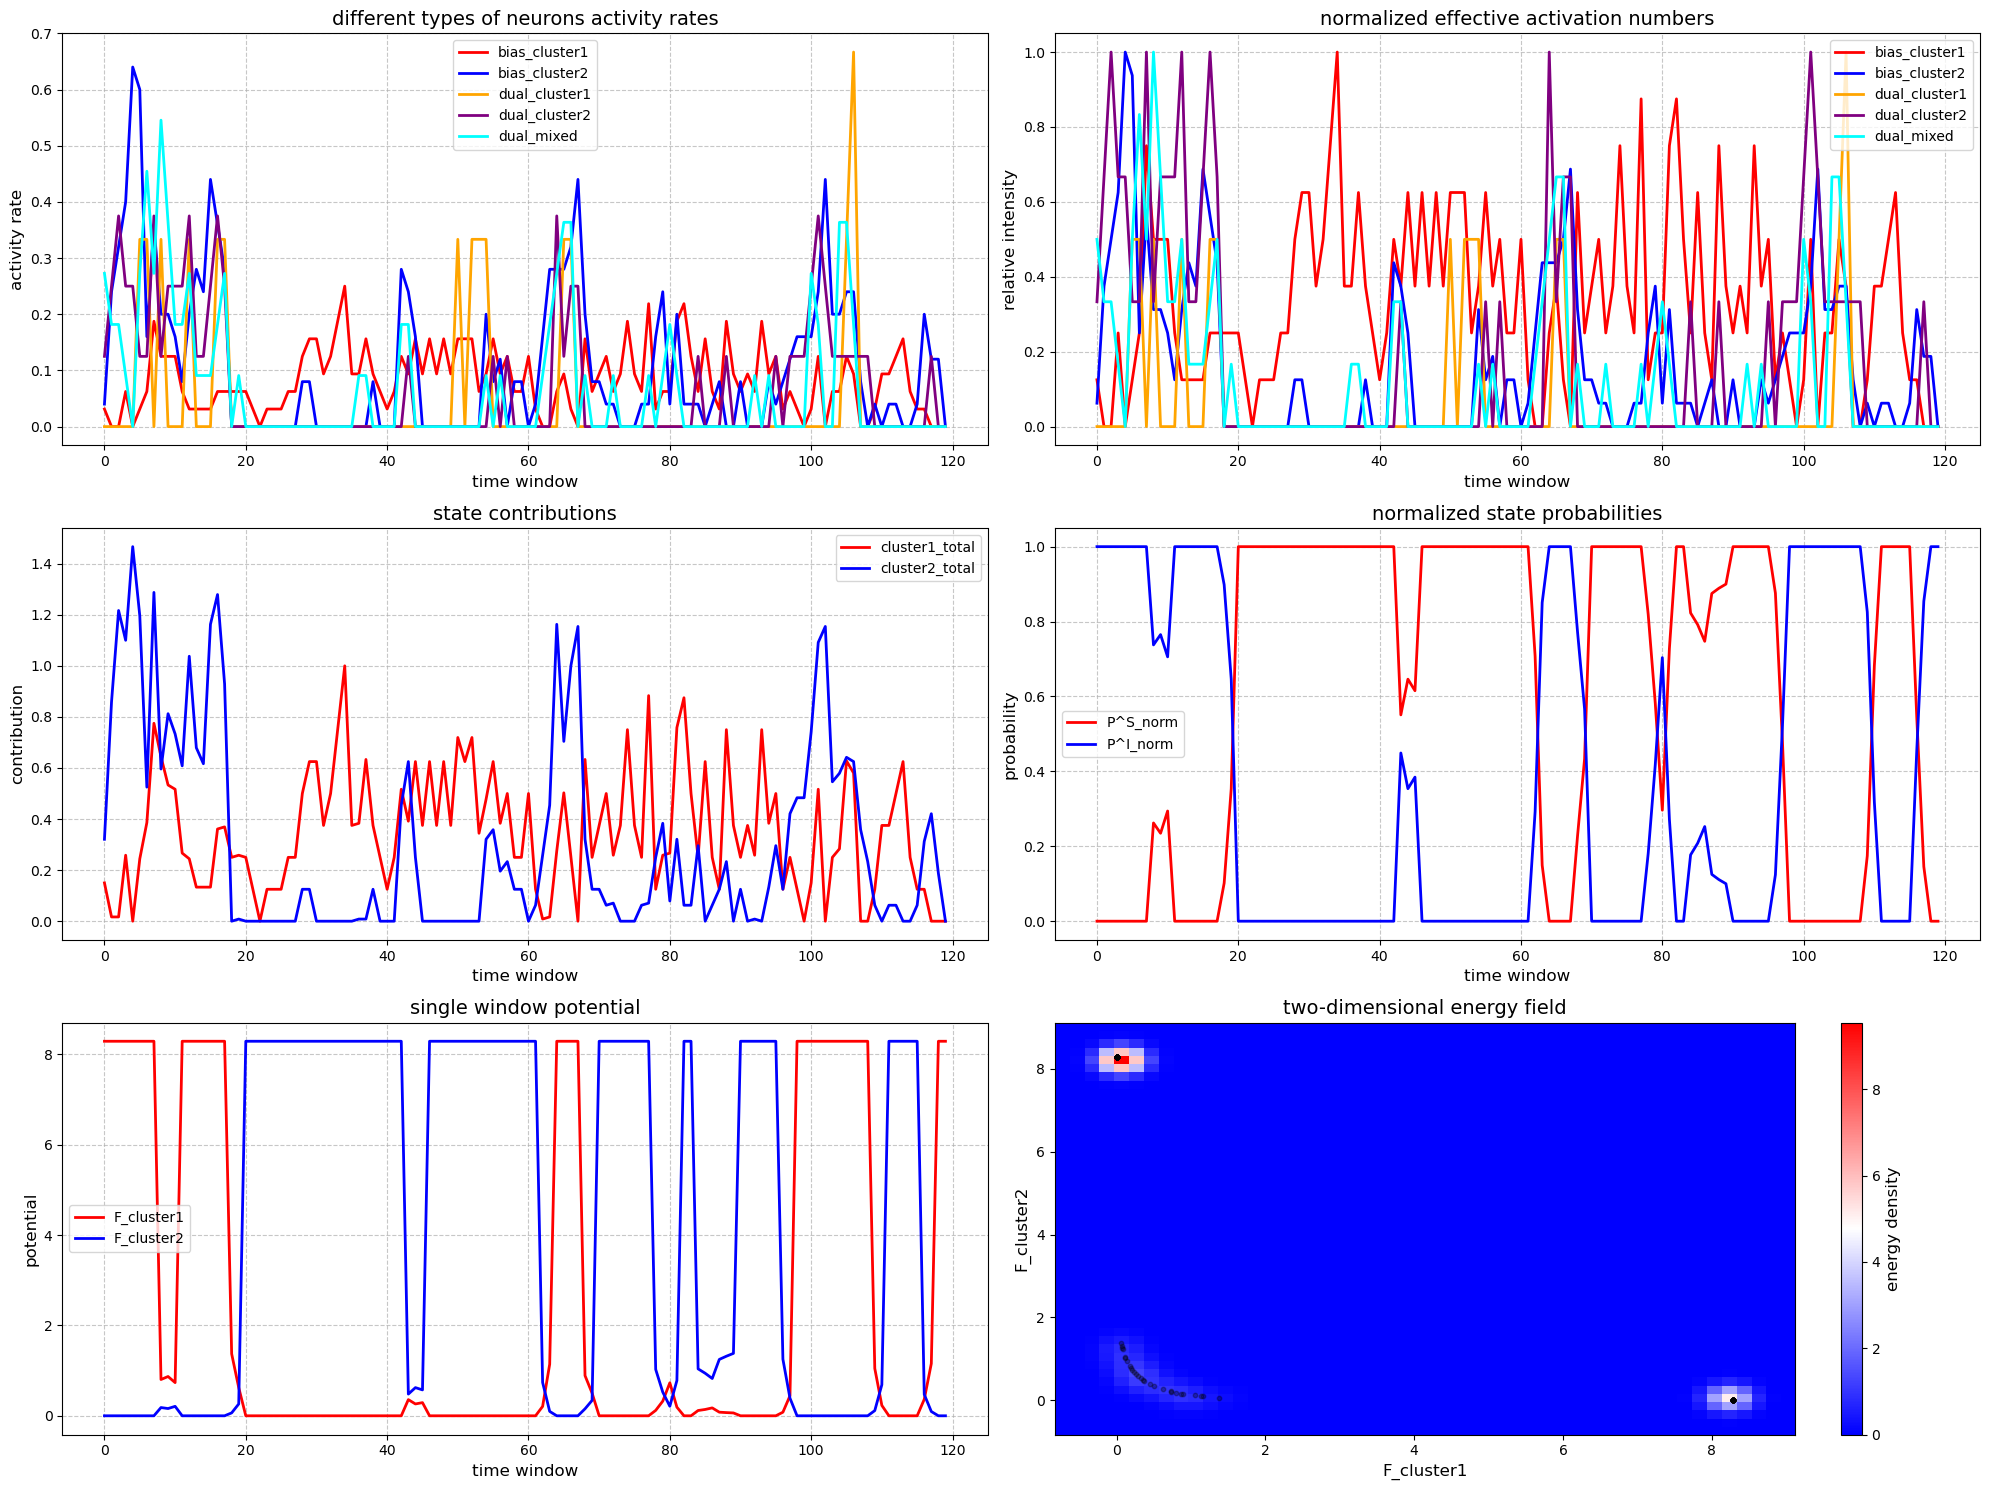

In [ ]:
# Main function: run the full neuronal activity analysis and energy-field calculation.
def analyze_neuron_activity_energy(
    neuron_features_df, 
    events_df, 
    resized_df_signal_neuron_raw, 
    window_size_frames=30,  # Number of frames in 3 seconds.
    activation_threshold_frames=15,  # Number of frames covering 50% of the window duration.
    cluster_mapping=cluster_mapping
):
    """
    Run the full neuronal activity analysis and energy-field calculation, including:
    1. Data preprocessing and time segmentation.
    2. Identification of validly active neurons.
    3. Subdivision of dual-responsive neurons using Z-scores.
    4. Calculation of normalized effective activation counts.
    5. Determination of weight parameters.
    6. State contribution analysis.
    7. Calculation of stable-state probabilities in sliding windows.
    8. Generation of potential energy and energy fields.
    
    Parameters:
    neuron_features_df: neuronal feature DataFrame containing cluster information.
    events_df: neuronal events DataFrame.
    resized_df_signal_neuron_raw: raw neuronal signal DataFrame.
    window_size_frames: time-window size in frames.
    activation_threshold_frames: activation threshold in frames.
    
    Returns:
    analysis_results: dictionary containing all analysis results.
    """
    print("Starting neuronal activity analysis and energy-field calculation...")
    
    # 1. Process the cluster column in neuron_features_df.
    print("Processing neuronal feature data...")
    neuron_features_processed = neuron_features_df.copy()
    
    # Replace cluster values with the corresponding class names.
    cluster_mapping = cluster_mapping
    print(cluster_mapping)
    neuron_features_processed['cluster'] = neuron_features_processed['cluster'].replace(cluster_mapping)
    
    # Verify that the replacement succeeded.
    print(f"Processed cluster distribution:\n{neuron_features_processed['cluster'].value_counts()}")
    
    # 2. Generate time-window segments.
    print(f"Generating segments of {window_size_frames} frames (3 seconds)...")
    total_frames = len(resized_df_signal_neuron_raw)
    num_windows = (total_frames + window_size_frames - 1) // window_size_frames  # Round up.
    
    # Create a dictionary of window information.
    windows_info = []
    for i in range(num_windows):
        start_frame = i * window_size_frames
        end_frame = min((i + 1) * window_size_frames, total_frames)  # The last window may contain fewer than 30 frames.
        windows_info.append({
            'window_id': i,
            'start_frame': start_frame,
            'end_frame': end_frame,
            'duration_frames': end_frame - start_frame
        })
    
    windows_df = pd.DataFrame(windows_info)
    print(f"Generated {len(windows_df)} time windows.")
    
    # 3. Identify neurons with valid activity in each window.
    print("Identifying validly active neurons in each time window...")
    # Create a mapping from neuron IDs to window activation states.
    neuron_window_activation = {}
    all_neuron_ids = neuron_features_processed['neuron_id'].unique()
    
    for neuron_id in all_neuron_ids:
        # Get all events for the current neuron.
        neuron_events = events_df[events_df['neuron_id'] == neuron_id].copy()
        
        # Initialize this neuron's activation state to 0 in all windows.
        activation_status = [0] * len(windows_df)
        
        # Check each window for valid activity.
        for win_idx, window in windows_df.iterrows():
            # Check whether events in this window meet the total-duration threshold.
            window_events = neuron_events[
                (neuron_events['start_frame'] < window['end_frame']) &
                (neuron_events['end_frame'] > window['start_frame'])
            ]
            
            # Compute the duration of each event within the current window.
            total_active_frames = 0
            for _, event in window_events.iterrows():
                # Compute the overlap between the event and window.
                overlap_start = max(event['start_frame'], window['start_frame'])
                overlap_end = min(event['end_frame'], window['end_frame'])
                overlap_duration = overlap_end - overlap_start
                total_active_frames += overlap_duration
            
            # Mark as active if the total active frame count reaches the threshold.
            if total_active_frames >= activation_threshold_frames:
                activation_status[win_idx] = 1
        
        neuron_window_activation[neuron_id] = activation_status
    
    # Create the window-by-neuron activation matrix.
    activation_matrix = pd.DataFrame(neuron_window_activation, index=windows_df['window_id'])
    
    # 4. Subdivide dual-responsive neurons using a Z-score method.
    print("Subdividing dual-responsive neurons using Z-scores...")
    # Define neuron ID sets for each class.
    bias_cluster1_neurons = set(neuron_features_processed[
        neuron_features_processed['cluster'] == 'bias_cluster1'
    ]['neuron_id'])
    
    bias_cluster2_neurons = set(neuron_features_processed[
        neuron_features_processed['cluster'] == 'bias_cluster2'
    ]['neuron_id'])
    
    dual_response_neurons = set(neuron_features_processed[
        neuron_features_processed['cluster'] == 'dual_response'
    ]['neuron_id'])
    
    # Determine whether each class is active in each window (at least one active neuron).
    window_class_activation = {}
    for win_idx in range(len(windows_df)):
        # Check whether the bias_cluster1 group is active in the current window.
        cluster1_activated = any(activation_matrix.iloc[win_idx][neuron_id] 
                                for neuron_id in bias_cluster1_neurons if neuron_id in activation_matrix.columns)
        
        # Check whether the bias_cluster2 group is active in the current window.
        cluster2_activated = any(activation_matrix.iloc[win_idx][neuron_id] 
                                  for neuron_id in bias_cluster2_neurons if neuron_id in activation_matrix.columns)
        
        window_class_activation[win_idx] = {
            'cluster1_activated': cluster1_activated,
            'cluster2_activated': cluster2_activated
        }
    
    # Compute coactivation frequencies for dual-responsive neurons and assign subgroups.
    dual_subgroups = {}
    delta_f_list = []
    
    for neuron_id in dual_response_neurons:
        # Get the windows in which this neuron is active.
        neuron_activations = np.array(neuron_window_activation[neuron_id])
        total_active_windows = np.sum(neuron_activations)
        
        if total_active_windows == 0:
            # A neuron that is never active cannot be assigned to a subgroup.
            dual_subgroups[neuron_id] = 'unknown'
            continue
        
        # Compute coactivation frequency with the bias_cluster1 group.
        cluster1_co_activation_windows = 0
        cluster2_co_activation_windows = 0
        
        for win_idx in range(len(windows_df)):
            if neuron_activations[win_idx] == 1:
                # When this neuron is active, check coactivation with each class.
                if window_class_activation[win_idx]['cluster1_activated']:
                    cluster1_co_activation_windows += 1
                if window_class_activation[win_idx]['cluster2_activated']:
                    cluster2_co_activation_windows += 1
        
        # Compute coactivation frequencies.
        f_cluster1 = cluster1_co_activation_windows / total_active_windows if total_active_windows > 0 else 0
        f_cluster2 = cluster2_co_activation_windows / total_active_windows if total_active_windows > 0 else 0
        
        # Compute the difference in coactivation frequencies.
        delta_f = f_cluster1 - f_cluster2
        delta_f_list.append(delta_f)
        
        # Store temporarily; compute thresholds jointly later.
        dual_subgroups[neuron_id] = {'f_cluster1': f_cluster1, 'f_cluster2': f_cluster2, 'delta_f': delta_f}
    
    # Compute the overall mean and standard deviation to determine thresholds.
    if len(delta_f_list) > 0:
        # Compute the mean and standard deviation of delta_f.
        mu_delta_f = np.mean(delta_f_list)
        sigma_delta_f = np.std(delta_f_list)
        
        # Assign subgroups using Z-score thresholds.
        for neuron_id, metrics in dual_subgroups.items():
            if isinstance(metrics, dict):  # Skip neurons that are never active.
                delta_f = metrics['delta_f']
                # Compute the standardized difference score.
                Z_i = (delta_f - mu_delta_f) / sigma_delta_f if sigma_delta_f > 0 else 0
                
                if Z_i > 0.5:
                    dual_subgroups[neuron_id] = 'dual_cluster1'  # cluster1-biased subgroup.
                elif Z_i < -0.5:
                    dual_subgroups[neuron_id] = 'dual_cluster2'  # cluster2-biased subgroup.
                else:
                    dual_subgroups[neuron_id] = 'dual_mixed'  # Mixed-response subgroup.
        
        print(f"Dual-responsive neuron subdivision complete; delta_f mean: {mu_delta_f:.4f}, standard deviation: {sigma_delta_f:.4f}")
        print(f"Subgroup distribution: {pd.Series(list(dual_subgroups.values())).value_counts()}")
    
    # Add subgroup information to the neuronal features DataFrame.
    neuron_features_processed['dual_subgroup'] = neuron_features_processed['neuron_id'].map(
        lambda x: dual_subgroups.get(x, None)
    )
    
    # 5. Compute activity rates and normalized effective activation counts for each class and time window.
    print("Computing activity rates and normalized effective activation counts for each class across time windows...")
    # Define all classes to analyze.
    categories = ['bias_cluster1', 'bias_cluster2', 'dual_cluster1', 'dual_cluster2', 'dual_mixed']
    category_names = {
        'bias_cluster1': 'c1',
        'bias_cluster2': 'c2',
        'dual_cluster1': 'dual_cluster1',
        'dual_cluster2': 'dual_cluster2',
        'dual_mixed': 'dual_mixed'
    }
    
    # Initialize dictionaries for activity rates and normalized effective activation counts.
    category_activation_rates = {}
    category_activation_numbers = {}
    category_populations = {}
    
    # Collect neuron counts for each class.
    for category in categories:
        if category in ['dual_cluster1', 'dual_cluster2', 'dual_mixed']:
            # For dual-responsive subgroups.
            category_neurons = set(neuron_features_processed[
                neuron_features_processed['dual_subgroup'] == category
            ]['neuron_id'])
        else:
            # For main classes.
            category_neurons = set(neuron_features_processed[
                neuron_features_processed['cluster'] == category
            ]['neuron_id'])
        
        category_populations[category] = len(category_neurons)
    
    # Compute activity rates and actual effective activation counts for each class.
    for category in categories:
        # Get all neuron IDs for this class.
        if category in ['dual_cluster1', 'dual_cluster2', 'dual_mixed']:
            # For dual-responsive subgroups.
            category_neurons = set(neuron_features_processed[
                neuron_features_processed['dual_subgroup'] == category
            ]['neuron_id'])
        else:
            # For main classes.
            category_neurons = set(neuron_features_processed[
                neuron_features_processed['cluster'] == category
            ]['neuron_id'])
        
        # Skip empty classes.
        if not category_neurons:
            continue
        
        # Compute this class's activity rate and effective activation count in each window.
        activation_rates = []
        activation_numbers = []
        category_size = len(category_neurons)
        
        for win_idx in range(len(windows_df)):
            # Count neurons active in this window.
            active_count = 0
            for neuron_id in category_neurons:
                if neuron_id in activation_matrix.columns and activation_matrix.iloc[win_idx][neuron_id] == 1:
                    active_count += 1
            
            # Compute the activity rate.
            activation_rate = active_count / category_size if category_size > 0 else 0
            activation_rates.append(activation_rate)
            activation_numbers.append(active_count)
        
        category_activation_rates[category] = activation_rates
        category_activation_numbers[category] = activation_numbers
    
    # Create DataFrames for activity rates and effective activation counts.
    activation_rates_df = pd.DataFrame(category_activation_rates, index=windows_df['window_id'])
    activation_numbers_df = pd.DataFrame(category_activation_numbers, index=windows_df['window_id'])
    
    # 6. Compute baseline activation levels and normalized effective activation counts for each class.
    print("Computing baseline activation levels and normalized effective activation counts for each class...")
    # Compute the maximum activation proportion for each class (saturation level).
    max_activation_proportions = {}
    for category in activation_rates_df.columns:
        if category in category_populations and category_populations[category] > 0:
            max_activation_proportions[category] = activation_rates_df[category].max()
    
    # Compute the baseline effective count.
    baseline_effective_numbers = {}
    for category in activation_rates_df.columns:
        if category in category_populations and category_populations[category] > 0:
            baseline_effective_numbers[category] = category_populations[category] * max_activation_proportions[category]
    
    # Compute normalized effective activation counts (relative intensity).
    normalized_effective_numbers = {}
    for category in activation_rates_df.columns:
        if category in baseline_effective_numbers and baseline_effective_numbers[category] > 0:
            # Normalize effective activation counts as activity rate divided by maximum activity rate.
            normalized_values = activation_rates_df[category] / max_activation_proportions[category]
            # Ensure that values lie between 0 and 1.
            normalized_values = np.clip(normalized_values, 0, 1)
            normalized_effective_numbers[category] = normalized_values
        else:
            normalized_effective_numbers[category] = np.zeros(len(activation_rates_df))
    
    # Create a DataFrame of normalized effective activation counts.
    normalized_effective_df = pd.DataFrame(normalized_effective_numbers, index=windows_df['window_id'])
    
    # 7. Compute weight parameters.
    print("Computing weight parameters...")
    # Initialize the weight dictionary.
    # weights = {'dual_mixed': 0.05}  # Fix the dm weight at 0.05.
    weights = {'dual_mixed': 0}  # Fix the dm weight at 0.05.
    weight_lower, weight_upper = globals().get('_batch_weight_bounds', (0.1, 0.7))
    # weights = {'dual_mixed': 1e-9}  # Fix the dm weight at 1e-9.
    
    # Compute w_dual_cluster1, the weight for the cluster1-biased subgroup.
    if 'c1' in category_names.values() and 'dual_cluster1' in category_names.values():
        cluster1_category = [k for k, v in category_names.items() if v == 'c1'][0]
        dcluster1_category = [k for k, v in category_names.items() if v == 'dual_cluster1'][0]
        
        if cluster1_category in activation_rates_df.columns and dcluster1_category in activation_rates_df.columns:
            # Find windows in which the s group is active.
            s_activated_windows = activation_rates_df[cluster1_category] > 0
            
            if s_activated_windows.sum() > 0:
                # Compute the mean normalized effective count of the ds subgroup only in windows where the s group is active.
                avg_ndual_cluster1_cluster1 = normalized_effective_df.loc[s_activated_windows, dcluster1_category].mean()
                # Compute the mean normalized effective count of the s group in the same windows.
                avg_ncluster1_cluster1 = normalized_effective_df.loc[s_activated_windows, cluster1_category].mean()
                
                # Avoid division by zero.
                if avg_ncluster1_cluster1 > 0:
                    w_dual_cluster1 = avg_ndual_cluster1_cluster1 / avg_ncluster1_cluster1
                    # Apply biological constraints.
                    w_dual_cluster1 = min(w_dual_cluster1, weight_upper)  # Apply the upper bound for this run.
                    w_dual_cluster1 = max(w_dual_cluster1, weight_lower)  # Apply the lower bound for this run.
                    weights['dual_cluster1'] = w_dual_cluster1
                    print(f"Computed w_dual_cluster1: {w_dual_cluster1:.4f}")
    
    # Compute w_dual_cluster2, the weight for the cluster2-biased subgroup.
    if 'c2' in category_names.values() and 'dual_cluster2' in category_names.values():
        cluster2_category = [k for k, v in category_names.items() if v == 'c2'][0]
        di_category = [k for k, v in category_names.items() if v == 'dual_cluster2'][0]
        
        if cluster2_category in activation_rates_df.columns and di_category in activation_rates_df.columns:
            # Find windows in which the im group is active.
            im_activated_windows = activation_rates_df[cluster2_category] > 0
            
            if im_activated_windows.sum() > 0:
                # Compute the mean normalized effective count of the di subgroup only in windows where the im group is active.
                avg_ndual_cluster2_cluster2 = normalized_effective_df.loc[im_activated_windows, di_category].mean()
                # Compute the mean normalized effective count of the im group in the same windows.
                avg_ncluster2_cluster2 = normalized_effective_df.loc[im_activated_windows, cluster2_category].mean()
                
                # Avoid division by zero.
                if avg_ncluster2_cluster2 > 0:
                    w_dual_cluster2 = avg_ndual_cluster2_cluster2 / avg_ncluster2_cluster2
                    # Apply biological constraints.
                    w_dual_cluster2 = min(w_dual_cluster2, weight_upper)  # Apply the upper bound for this run.
                    w_dual_cluster2 = max(w_dual_cluster2, weight_lower)  # Apply the lower bound for this run.
                    weights['dual_cluster2'] = w_dual_cluster2
                    print(f"Computed w_dual_cluster2: {w_dual_cluster2:.4f}")
    
    # 8. Compute state contributions.
    print("Computing state contributions...")
    # Ensure that all required classes exist.
    required_categories_cluster1 = ['bias_cluster1', 'dual_cluster1', 'dual_mixed']
    required_categories_cluster2 = ['bias_cluster2', 'dual_cluster2', 'dual_mixed']
    
    # Check that normalized_effective_df contains all required classes.
    has_all_cluster1_categories = all(cat in normalized_effective_df.columns for cat in required_categories_cluster1)
    has_all_cluster2_categories = all(cat in normalized_effective_df.columns for cat in required_categories_cluster2)
    has_all_weights = all(weight in weights for weight in ['dual_cluster1', 'dual_mixed', 'dual_cluster2'])
    
    # Initialize state contribution arrays.
    cluster1_total = np.zeros(len(windows_df))
    cluster2_total = np.zeros(len(windows_df))
    
    if has_all_cluster1_categories and has_all_cluster2_categories and has_all_weights:
        # Compute cluster1_total and cluster2_total.
        cluster1_total = (normalized_effective_df['bias_cluster1'] + 
                  weights['dual_cluster1'] * normalized_effective_df['dual_cluster1'] + 
                  weights['dual_mixed'] * normalized_effective_df['dual_mixed']).values
        
        cluster2_total = (normalized_effective_df['bias_cluster2'] + 
                  weights['dual_cluster2'] * normalized_effective_df['dual_cluster2'] + 
                  weights['dual_mixed'] * normalized_effective_df['dual_mixed']).values
    else:
        # Handle missing classes.
        # Compute contributions for classes that are present.
        if 'bias_cluster1' in normalized_effective_df.columns:
            cluster1_total += normalized_effective_df['bias_cluster1'].values
        if 'dual_cluster1' in normalized_effective_df.columns and 'dual_cluster1' in weights:
            cluster1_total += weights['dual_cluster1'] * normalized_effective_df['dual_cluster1'].values
        if 'dual_mixed' in normalized_effective_df.columns and 'dual_mixed' in weights:
            cluster1_total += weights['dual_mixed'] * normalized_effective_df['dual_mixed'].values
        
        if 'bias_cluster2' in normalized_effective_df.columns:
            cluster2_total += normalized_effective_df['bias_cluster2'].values
        if 'dual_cluster2' in normalized_effective_df.columns and 'dual_cluster2' in weights:
            cluster2_total += weights['dual_cluster2'] * normalized_effective_df['dual_cluster2'].values
        if 'dual_mixed' in normalized_effective_df.columns and 'dual_mixed' in weights:
            cluster2_total += weights['dual_mixed'] * normalized_effective_df['dual_mixed'].values
        
        print("Warning: some classes or weights are missing; state contributions may be inaccurate.")
    
    # 9. Classify states.
    print("Classifying states...")
    # Initialize the state indicator array.
    state_indicator = np.zeros(len(windows_df), dtype=int)
    
    # Label the state as 1 (cluster1) when cluster1_total exceeds cluster2_total; otherwise use 0 (cluster2).
    state_indicator[cluster1_total > cluster2_total] = 1
    
    # 10. Compute stable-state probabilities in sliding windows.
    print("Computing stable-state probabilities in sliding windows...")
    window_size = 3  # Moving average over 3 windows.
    epsilon = 1e-6  # Avoid a zero denominator.
    
    # Initialize probability arrays.
    P_cluster1 = np.zeros(len(windows_df))
    P_cluster2 = np.zeros(len(windows_df))
    P_cluster1_norm = np.zeros(len(windows_df))
    P_cluster2_norm = np.zeros(len(windows_df))
    
    # Compute stable-state probabilities in sliding windows.
    for t in range(len(windows_df)):
        # Determine the sliding-window bounds.
        start_idx = max(0, t - window_size + 1)
        end_idx = t + 1  # Exclude end_idx.
        
        # Get data within the sliding window.
        window_cluster1_total = cluster1_total[start_idx:end_idx]
        window_cluster2_total = cluster2_total[start_idx:end_idx]
        window_state_indicator = state_indicator[start_idx:end_idx]
        
        # Compute the probability of the cluster1 state.
        P_cluster1[t] = np.mean(window_cluster1_total * window_state_indicator) if len(window_cluster1_total) > 0 else 0
        # P_cluster1[t] = np.mean(window_cluster1_total) if len(window_cluster1_total) > 0 else 0
        
        # Compute the probability of the cluster2 state.
        P_cluster2[t] = np.mean(window_cluster2_total * (1 - window_state_indicator)) if len(window_cluster2_total) > 0 else 0
        # P_cluster2[t] = np.mean(window_cluster2_total) if len(window_cluster2_total) > 0 else 0
        
        # Normalize probabilities so that P_cluster1_norm + P_cluster2_norm = 1.
        total_prob = P_cluster1[t] + P_cluster2[t] + epsilon
        P_cluster1_norm[t] = P_cluster1[t] / total_prob
        P_cluster2_norm[t] = P_cluster2[t] / total_prob
    
    
    # This intermediate parameter has no practical effect: subsequent calculations (see cell 64) use P_cluster1_norm and P_cluster2_norm; F_cluster1 and F_cluster2 computed using beta are not used for statistics or analysis.
    beta = 0.6  
    
    # Compute the potential energy of a single window.
    F_cluster1 = -beta * np.log(P_cluster1_norm + epsilon)
    F_cluster2 = -beta * np.log(P_cluster2_norm + epsilon)
    
    # 12. Generate a two-dimensional energy field.
    print("Generating the two-dimensional energy field...")
    # Generate the energy field using kernel density estimation.
    # Prepare data.
    energy_data = np.column_stack((F_cluster1, F_cluster2))
    
    # Create a two-dimensional histogram as a simple alternative to kernel density estimation.
    x_min, x_max = min(F_cluster1), max(F_cluster1)
    y_min, y_max = min(F_cluster2), max(F_cluster2)
    
    # Expand the range to avoid boundary effects.
    x_range = x_max - x_min
    y_range = y_max - y_min
    x_min -= 0.1 * x_range
    x_max += 0.1 * x_range
    y_min -= 0.1 * y_range
    y_max += 0.1 * y_range
    
    # Create a grid.
    grid_size = 50
    x = np.linspace(x_min, x_max, grid_size)
    y = np.linspace(y_min, y_max, grid_size)
    X, Y = np.meshgrid(x, y)
    
    # Compute the kernel density estimate.
    try:
        # Use Gaussian filtering as a simplified kernel density estimate.
        # First compute the histogram.
        hist, xedges, yedges = np.histogram2d(F_cluster1, F_cluster2, bins=grid_size, range=[[x_min, x_max], [y_min, y_max]])
        
        # Smooth the histogram with a Gaussian filter.
        sigma = 1.0  # Smoothing parameter.
        density = gaussian_filter(hist.T, sigma=sigma)
        
        # Invert the y-axis to match image coordinates.
        density = density[::-1, :]
    except Exception as e:
        print(f"Kernel density estimation failed; using a default density field: {e}")
        # Create a default density field.
        density = np.zeros((grid_size, grid_size))
    
    # 13. Visualize the main results.
    print("Generating visualizations...")
    # Create a large figure with multiple subplots.
    fig = plt.figure(figsize=(20, 15))
    
    # Subplot 1: activity-rate curves for each class.
    ax1 = plt.subplot(321)
    colors = {
        'bias_cluster1': 'red',
        'bias_cluster2': 'blue',
        'dual_cluster1': 'orange',
        'dual_cluster2': 'purple',
        'dual_mixed': 'cyan'
    }
    
    for category in activation_rates_df.columns:
        if category in colors:
            ax1.plot(activation_rates_df.index, activation_rates_df[category], 
                    label=category, color=colors[category], linewidth=2)
        else:
            ax1.plot(activation_rates_df.index, activation_rates_df[category], label=category, linewidth=2)
    
    ax1.set_title('different types of neurons activity rates', fontsize=14)
    ax1.set_xlabel('time window', fontsize=12)
    ax1.set_ylabel('activity rate', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(fontsize=10)
    
    # Subplot 2: normalized effective activation counts.
    ax2 = plt.subplot(322)
    for category in normalized_effective_df.columns:
        if category in colors:
            ax2.plot(normalized_effective_df.index, normalized_effective_df[category], 
                    label=category, color=colors[category], linewidth=2)
        else:
            ax2.plot(normalized_effective_df.index, normalized_effective_df[category], label=category, linewidth=2)
    
    ax2.set_title('normalized effective activation numbers', fontsize=14)
    ax2.set_xlabel('time window', fontsize=12)
    ax2.set_ylabel('relative intensity', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(fontsize=10)
    
    # Subplot 3: state contributions and state indicators.
    ax3 = plt.subplot(323)
    ax3.plot(range(len(windows_df)), cluster1_total, 'r-', label='cluster1_total', linewidth=2)
    ax3.plot(range(len(windows_df)), cluster2_total, 'b-', label='cluster2_total', linewidth=2)
    ax3.set_title('state contributions', fontsize=14)
    ax3.set_xlabel('time window', fontsize=12)
    ax3.set_ylabel('contribution', fontsize=12)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(fontsize=10)
    
    # Subplot 4: normalized state probabilities.
    ax4 = plt.subplot(324)
    ax4.plot(range(len(windows_df)), P_cluster1_norm, 'r-', label='P^S_norm', linewidth=2)
    ax4.plot(range(len(windows_df)), P_cluster2_norm, 'b-', label='P^I_norm', linewidth=2)
    ax4.set_title('normalized state probabilities', fontsize=14)
    ax4.set_xlabel('time window', fontsize=12)
    ax4.set_ylabel('probability', fontsize=12)
    ax4.grid(True, linestyle='--', alpha=0.7)
    ax4.legend(fontsize=10)
    
    # Subplot 5: potential energy.
    ax5 = plt.subplot(325)
    ax5.plot(range(len(windows_df)), F_cluster1, 'r-', label='F_cluster1', linewidth=2)
    ax5.plot(range(len(windows_df)), F_cluster2, 'b-', label='F_cluster2', linewidth=2)
    ax5.set_title('single window potential', fontsize=14)
    ax5.set_xlabel('time window', fontsize=12)
    ax5.set_ylabel('potential', fontsize=12)
    ax5.grid(True, linestyle='--', alpha=0.7)
    ax5.legend(fontsize=10)
    
    # Subplot 6: two-dimensional energy field.
    ax6 = plt.subplot(326)
    # Create a custom colormap from blue to red for low to high energy.
    colors = [(0, 0, 1), (1, 1, 1), (1, 0, 0)]  # Blue -> white -> red.
    cmap = LinearSegmentedColormap.from_list('energy_cmap', colors, N=256)
    
    # Plot the energy field.
    im = ax6.imshow(density, extent=[x_min, x_max, y_min, y_max], cmap=cmap, aspect='auto')
    
    # Plot the original data points.
    ax6.scatter(F_cluster1, F_cluster2, c='k', s=10, alpha=0.3)
    
    ax6.set_title('two-dimensional energy field', fontsize=14)
    ax6.set_xlabel('F_cluster1', fontsize=12)
    ax6.set_ylabel('F_cluster2', fontsize=12)
    
    # Add a colorbar.
    cbar = fig.colorbar(im, ax=ax6)
    cbar.set_label('energy density', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(path_save + r'\neuron activity energy analysis.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(path_save + r'\neuron activity energy analysis.png', format='png', dpi=300, bbox_inches='tight')
    
    # 14. Package the results.
    analysis_results = {
        'neuron_features_processed': neuron_features_processed,
        'windows_df': windows_df,
        'activation_matrix': activation_matrix,
        'dual_subgroups': dual_subgroups,
        'activation_rates_df': activation_rates_df,
        'activation_numbers_df': activation_numbers_df,
        'normalized_effective_df': normalized_effective_df,
        'weights': weights,
        'cluster1_total': cluster1_total,
        'cluster2_total': cluster2_total,
        'state_indicator': state_indicator,
        'P_cluster1': P_cluster1,
        'P_cluster2': P_cluster2,
        'P_cluster1_norm': P_cluster1_norm,
        'P_cluster2_norm': P_cluster2_norm,
        'F_cluster1': F_cluster1,
        'F_cluster2': F_cluster2,
        'energy_field': density,
        'energy_grid': {'x': x, 'y': y},
        'figure': fig
    }
    
    print("Neuronal activity analysis and energy-field calculation complete!")
    return analysis_results

# Usage example.
if __name__ == "__main__":

    print("Input data validation passed; starting analysis...")
    # Run the analysis.
    results = analyze_neuron_activity_energy(
        neuron_features_df, events_df, resized_df_signal_neuron_raw
    )
    
    # Display a results summary.
    print("\nAnalysis summary:")
    print(f"1. Processed neuronal features: {results['neuron_features_processed'].shape}")
    print(f"2. Generated time windows: {len(results['windows_df'])}")
    print(f"3. Activation matrix: {results['activation_matrix'].shape}")
    print(f"4. Dual-responsive subgroup weights: {results['weights']}")
    print(f"5. State indicator array shape: {results['state_indicator'].shape}")
    print(f"6. Normalized state probability array shape: {results['P_cluster1_norm'].shape}")
    print(f"7. Potential energy array shape: {results['F_cluster1'].shape}")
    print(f"8. Energy-field shape: {results['energy_field'].shape}")
        

In [64]:
results_probility = results.copy()
results_F_cluster1 = results_probility['P_cluster1_norm']
results_F_cluster2 = results_probility['P_cluster2_norm']

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.interpolate import griddata

Distance between the two energy valleys: 1.59
First peak F_cluster1: 1.06, F_cluster2: -0.06
Second peak F_cluster1: -0.06, F_cluster2: 1.06
F_cluster1 threshold: 0.46, F_cluster2 threshold: 0.46
Energy at the first valley: -0.3870
Energy at the second valley: 0.2309
Energy-barrier height: 1.6229


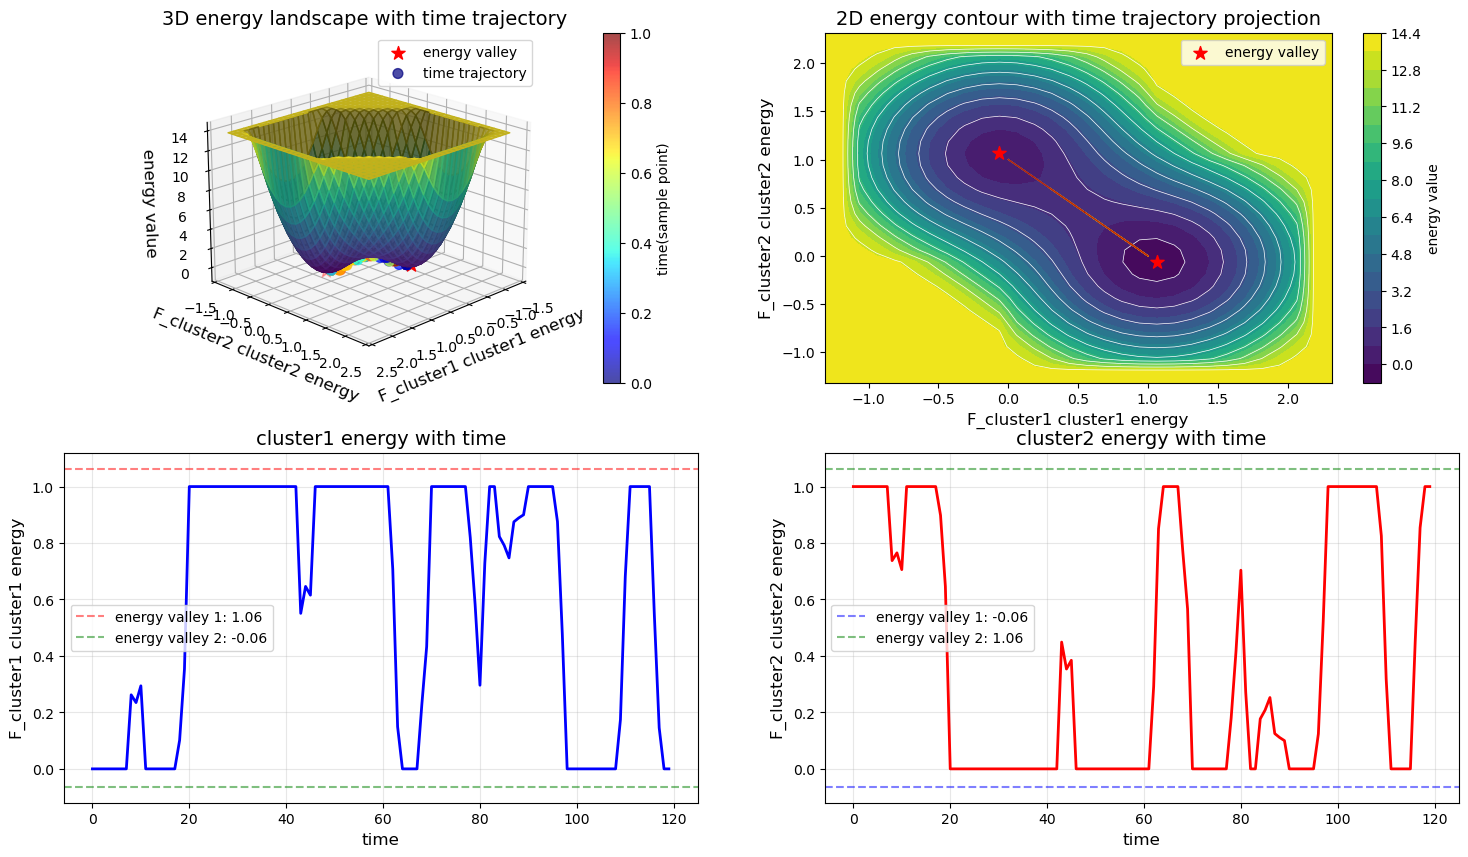

Energy valley 1 (F_cluster1, F_cluster2): (1.06, -0.06)
Energy valley 2 (F_cluster1, F_cluster2): (-0.06, 1.06)
Energy-barrier height: 1.6229
Percentage of time the mouse spends near energy valley 1: 63.3%
Percentage of time the mouse spends near energy valley 2: 36.7%
Transitions between the two energy valleys: 8


In [66]:
# ---------------------- 1. Data preparation ----------------------
# Assume that results_F_cluster1 and results_F_cluster2 are arrays of 120 time points.
n_samples = len(results_F_cluster1)  # Expected to be 120.
X = np.arange(n_samples)      # Time axis: 0-119.
Y = results_F_cluster1               # Energy of the cluster1 state.
Z = results_F_cluster2               # Energy of the cluster2 state.
Y_std = np.std(Y)*3
Z_std = np.std(Z)*3

# ---------------------- 2. Data analysis ----------------------
# Compute the probability density distribution.
# Define grid bounds dynamically from the data.
y_min, y_max = np.min(Y)-Y_std, np.max(Y)+Y_std
z_min, z_max = np.min(Z)-Z_std, np.max(Z)+Z_std
n_bins = 30  # Grid resolution.

y_grid = np.linspace(y_min, y_max, n_bins)
z_grid = np.linspace(z_min, z_max, n_bins)
Y_grid, Z_grid = np.meshgrid(y_grid, z_grid)

# Compute the probability density at each grid point.
# Method: estimate the sample distribution with a 2D histogram.
heatmap, xedges, yedges = np.histogram2d(Y, Z, bins=[n_bins, n_bins], 
                                         range=[[y_min, y_max], [z_min, z_max]],
                                         density=True)  # Normalize to a probability density.

# Apply Gaussian smoothing to obtain a smoother energy landscape.
sigma = 2  # Smoothing coefficient.
smooth_heatmap = gaussian_filter(heatmap.T, sigma=sigma)

# Find energy valleys, where probability-density peaks correspond to energy minima.
# Assume that high-probability-density regions correspond to low-energy states.
# Find the two main energy valleys (cluster1 and cluster2 states).
from scipy.signal import find_peaks

# Flatten and sort to find the two main peaks.
flat_density = smooth_heatmap.flatten()
sorted_indices = np.argsort(flat_density)[::-1]  # Sort in descending order.

# Find the two peak positions corresponding to the two energy valleys.
# Ensure that the distance between the peaks exceeds 5.
# At each peak, require at least one energy component to be at least half its maximum.
min_distance = 1  # Minimum distance threshold.
peak_indices = []
peak_coords = []

# Compute the maxima of F_cluster1 and F_cluster2 for energy-threshold checks.
y_max_value = np.max(y_grid)
z_max_value = np.max(z_grid)
energy_threshold_ratio = 0.2  # Threshold ratio.
y_threshold = y_max_value * energy_threshold_ratio
z_threshold = z_max_value * energy_threshold_ratio

# Iterate over sorted indices to find two peaks satisfying the criteria.
for i in range(len(sorted_indices)):
    if len(peak_indices) == 0:
        # Check the energy threshold for the first peak.
        current_idx = sorted_indices[i]
        current_coord = np.unravel_index(current_idx, smooth_heatmap.shape)
        current_z, current_y = current_coord
        current_F_cluster1 = y_grid[current_y]
        current_F_cluster2 = z_grid[current_z]
        
        # Check whether at least one energy component reaches the threshold.
        if current_F_cluster1 >= y_threshold or current_F_cluster2 >= z_threshold:
            peak_indices.append(current_idx)
            peak_coords = np.unravel_index(peak_indices, smooth_heatmap.shape)
    else:
        # Check the distance and energy threshold for the second peak.
        current_idx = sorted_indices[i]
        current_coord = np.unravel_index(current_idx, smooth_heatmap.shape)
        current_z, current_y = current_coord
        current_F_cluster1 = y_grid[current_y]
        current_F_cluster2 = z_grid[current_z]
        
        # Check whether at least one energy component reaches the threshold.
        if current_F_cluster1 >= y_threshold or current_F_cluster2 >= z_threshold:
            # Compute the distance from the first peak.
            valley1_z, valley1_y = peak_coords[0][0], peak_coords[1][0]
            valley1_F_cluster1 = y_grid[valley1_y]
            valley1_F_cluster2 = z_grid[valley1_z]
            
            distance = np.sqrt((current_F_cluster1 - valley1_F_cluster1)**2 + (current_F_cluster2 - valley1_F_cluster2)**2)
            
            if distance >= min_distance:
                # Find a second peak satisfying all requirements.
                peak_indices.append(current_idx)
                peak_coords = np.unravel_index(peak_indices, smooth_heatmap.shape)
                break

# If no peaks satisfy both distance and energy requirements, use the first two peaks meeting the energy threshold.
if len(peak_indices) < 2:
    print(f"Warning: no two peaks satisfy all criteria; using the first two peaks meeting the energy threshold.")
    # Search again for the first two peaks meeting the energy threshold.
    peak_indices = []
    for i in range(len(sorted_indices)):
        current_idx = sorted_indices[i]
        current_coord = np.unravel_index(current_idx, smooth_heatmap.shape)
        current_z, current_y = current_coord
        current_F_cluster1 = y_grid[current_y]
        current_F_cluster2 = z_grid[current_z]
        
        if current_F_cluster1 >= y_threshold or current_F_cluster2 >= z_threshold:
            peak_indices.append(current_idx)
            if len(peak_indices) == 2:
                break
    
    if len(peak_indices) >= 2:
        peak_coords = np.unravel_index(peak_indices, smooth_heatmap.shape)
    else:
        # If none are found, use the default first two peaks.
        print("Warning: no peaks meet the energy threshold; using the two highest-density points.")
        peak_indices = sorted_indices[:2]
        peak_coords = np.unravel_index(peak_indices, smooth_heatmap.shape)

# Energy-valley coordinates for the cluster1 and cluster2 states.
valley1_z, valley1_y = peak_coords[0][0], peak_coords[1][0]
valley2_z, valley2_y = peak_coords[0][1], peak_coords[1][1]

valley1_F_cluster1 = y_grid[valley1_y]
valley1_F_cluster2 = z_grid[valley1_z]
valley2_F_cluster1 = y_grid[valley2_y]
valley2_F_cluster2 = z_grid[valley2_z]

# Compute the actual distance between the peaks.
peak_distance = np.sqrt((valley2_F_cluster1 - valley1_F_cluster1)**2 + (valley2_F_cluster2 - valley1_F_cluster2)**2)
print(f"Distance between the two energy valleys: {peak_distance:.2f}")
print(f"First peak F_cluster1: {valley1_F_cluster1:.2f}, F_cluster2: {valley1_F_cluster2:.2f}")
print(f"Second peak F_cluster1: {valley2_F_cluster1:.2f}, F_cluster2: {valley2_F_cluster2:.2f}")
print(f"F_cluster1 threshold: {y_threshold:.2f}, F_cluster2 threshold: {z_threshold:.2f}")

# Compute the energy-barrier height between the two energy valleys.
def get_energy_value(y, z, y_grid, z_grid, smooth_heatmap):
    # Find the nearest grid point.
    y_idx = np.argmin(np.abs(y_grid - y))
    z_idx = np.argmin(np.abs(z_grid - z))
    # Return the energy at this position, converting higher density to lower energy.
    return -np.log(smooth_heatmap[z_idx, y_idx] + 1e-6)

energy_valley1 = get_energy_value(valley1_F_cluster1, valley1_F_cluster2, y_grid, z_grid, smooth_heatmap)
energy_valley2 = get_energy_value(valley2_F_cluster1, valley2_F_cluster2, y_grid, z_grid, smooth_heatmap)

# Compute the barrier height between the two energy valleys.
num_points = 100  # Number of sample points.
y_line = np.linspace(valley1_F_cluster1, valley2_F_cluster1, num_points)
z_line = np.linspace(valley1_F_cluster2, valley2_F_cluster2, num_points)
energy_line = [get_energy_value(y, z, y_grid, z_grid, smooth_heatmap) for y, z in zip(y_line, z_line)]

# Barrier height is the maximum energy along the connecting line minus the lower of the two valley energies.
energy_barrier = np.max(energy_line) - min(energy_valley1, energy_valley2)
print(f"Energy at the first valley: {energy_valley1:.4f}")
print(f"Energy at the second valley: {energy_valley2:.4f}")
print(f"Energy-barrier height: {energy_barrier:.4f}")

# ---------------------- 3. Three-dimensional visualization ----------------------
fig = plt.figure(figsize=(18, 10))

# 3D energy-landscape plot.
av1 = fig.add_subplot(221, projection='3d', elev=20, azim=45)

# Plot the probability-density surface.
# Convert probability density to energy: higher density means lower energy.
energy_surface = -np.log(smooth_heatmap + 1e-6)  # Add a small value to avoid log(0).

# Normalize the energy surface for coloring.
norm = Normalize(vmin=energy_surface.min(), vmax=energy_surface.max())
colors = cm.viridis(norm(energy_surface))

# Plot the 3D surface.
surf = av1.plot_surface(Y_grid, Z_grid, energy_surface, facecolors=colors, 
                        rstride=1, cstride=1, alpha=0.8, shade=True)

# Label energy valleys.
av1.scatter([valley1_F_cluster1, valley2_F_cluster1], [valley1_F_cluster2, valley2_F_cluster2], 
            [-np.log(flat_density[peak_indices[0]] + 1e-6), 
             -np.log(flat_density[peak_indices[1]] + 1e-6)], 
            color='red', s=100, marker='*', label='energy valley')

# Plot the temporal trajectory.
# Compute the energy at each point.
point_energies = []
for y, z in zip(Y, Z):
    # Find the nearest grid point.
    y_idx = np.argmin(np.abs(y_grid - y))
    z_idx = np.argmin(np.abs(z_grid - z))
    point_energies.append(-np.log(smooth_heatmap[z_idx, y_idx] + 1e-6))

# Plot the trajectory with a time-based color gradient.
colors_time = np.linspace(0, 1, n_samples)
traj = av1.scatter(Y, Z, point_energies, c=colors_time, cmap='jet', 
                   s=50, alpha=0.7, marker='o', label='time trajectory')

# Add lines connecting the temporal trajectory.
av1.plot(Y, Z, point_energies, color='gray', alpha=0.3, linewidth=1)

# Add labels and a title.
av1.set_xlabel('F_cluster1 cluster1 energy', fontsize=12)
av1.set_ylabel('F_cluster2 cluster2 energy', fontsize=12)
av1.set_zlabel('energy value', fontsize=12)
av1.set_title('3D energy landscape with time trajectory', fontsize=14)
av1.legend()

# Add a time colorbar.
cbar = plt.colorbar(traj, ax=av1, pad=0.1)
cbar.set_label('time(sample point)', fontsize=10)

# 2D energy-contour plot.
av2 = fig.add_subplot(222)
contour = av2.contourf(Y_grid, Z_grid, energy_surface, 20, cmap='viridis')
av2.contour(Y_grid, Z_grid, energy_surface, 10, colors='white', linewidths=0.5)
av2.scatter([valley1_F_cluster1, valley2_F_cluster1], [valley1_F_cluster2, valley2_F_cluster2], 
            color='red', s=100, marker='*', label='energy valley')
# Plot the temporal trajectory as a 2D projection.
for i in range(n_samples - 1):
    av2.plot([Y[i], Y[i+1]], [Z[i], Z[i+1]], color=cm.jet(colors_time[i]), 
             alpha=0.5, linewidth=1)
av2.set_xlabel('F_cluster1 cluster1 energy', fontsize=12)
av2.set_ylabel('F_cluster2 cluster2 energy', fontsize=12)
av2.set_title('2D energy contour with time trajectory projection', fontsize=14)
av2.legend()
plt.colorbar(contour, ax=av2, label='energy value')

# Plot F_cluster1 energy over time.
av3 = fig.add_subplot(223)
av3.plot(X, Y, 'b-', linewidth=2)
av3.axhline(y=valley1_F_cluster1, color='r', linestyle='--', alpha=0.5, label=f'energy valley 1: {valley1_F_cluster1:.2f}')
av3.axhline(y=valley2_F_cluster1, color='g', linestyle='--', alpha=0.5, label=f'energy valley 2: {valley2_F_cluster1:.2f}')
av3.set_xlabel('time', fontsize=12)
av3.set_ylabel('F_cluster1 cluster1 energy', fontsize=12)
av3.set_title('cluster1 energy with time', fontsize=14)
av3.legend()
av3.grid(True, alpha=0.3)

# Plot F_cluster2 energy over time.
av4 = fig.add_subplot(224)
av4.plot(X, Z, 'r-', linewidth=2)
av4.axhline(y=valley1_F_cluster2, color='b', linestyle='--', alpha=0.5, label=f'energy valley 1: {valley1_F_cluster2:.2f}')
av4.axhline(y=valley2_F_cluster2, color='g', linestyle='--', alpha=0.5, label=f'energy valley 2: {valley2_F_cluster2:.2f}')
av4.set_xlabel('time', fontsize=12)
av4.set_ylabel('F_cluster2 cluster2 energy', fontsize=12)
av4.set_title('cluster2 energy with time', fontsize=14)
av4.legend()
av4.grid(True, alpha=0.3)

# plt.tight_layout()
plt.savefig(path_save+'\energy_landscape.png', dpi=300, format='png', bbox_inches='tight')
plt.savefig(path_save+'\energy_landscape.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.show()

# ---------------------- 4. Results analysis ----------------------
print(f"Energy valley 1 (F_cluster1, F_cluster2): ({valley1_F_cluster1:.2f}, {valley1_F_cluster2:.2f})")
print(f"Energy valley 2 (F_cluster1, F_cluster2): ({valley2_F_cluster1:.2f}, {valley2_F_cluster2:.2f})")
print(f"Energy-barrier height: {energy_barrier:.4f}")

# Analyze trajectory stability.
# Determine which energy valley is closer at each time point.
dist_to_valley1 = np.sqrt((Y - valley1_F_cluster1)**2 + (Z - valley1_F_cluster2)** 2)
dist_to_valley2 = np.sqrt((Y - valley2_F_cluster1)**2 + (Z - valley2_F_cluster2)** 2)

# Compute the fraction of time spent near each energy valley.
percent_in_valley1 = np.mean(dist_to_valley1 < dist_to_valley2) * 100
percent_in_valley2 = 100 - percent_in_valley1

print(f"Percentage of time the mouse spends near energy valley 1: {percent_in_valley1:.1f}%")
print(f"Percentage of time the mouse spends near energy valley 2: {percent_in_valley2:.1f}%")

# Count state transitions.
transitions = np.diff(dist_to_valley1 < dist_to_valley2)
num_transitions = np.sum(np.abs(transitions))
print(f"Transitions between the two energy valleys: {num_transitions}")

# Save results.
results = {
    'valley1_F_cluster1': valley1_F_cluster1,
    'valley1_F_cluster2': valley1_F_cluster2,
    'valley2_F_cluster1': valley2_F_cluster1,
    'valley2_F_cluster2': valley2_F_cluster2,
    'energy_valley1':energy_valley1,
    'energy_valley2':energy_valley2,
    'energy_barrier': energy_barrier,
    'percent_in_valley1': percent_in_valley1,
    'percent_in_valley2': percent_in_valley2,
    'num_transitions': num_transitions
}

results = pd.DataFrame(results, index=[0])
results.to_csv(path_save+'\energy_landscape_results.csv')
# # Optionally save the results to a file.
# import json
# with open(path_save+'\energy_landscape_results.json', 'w') as f:
#     json.dump(results, f, indent=4)

In [67]:
result_total = results.copy()
Final_valley1_F_cluster1 = result_total['valley1_F_cluster1'][0]
Final_valley1_F_cluster2 = result_total['valley1_F_cluster2'][0]
Final_valley2_F_cluster1 = result_total['valley2_F_cluster1'][0]
Final_valley2_F_cluster2 = result_total['valley2_F_cluster2'][0]
energy_valleys = {
    'valley1_F_cluster1': [],
    'valley1_F_cluster2': [],
    'valley2_F_cluster1': [],
    'valley2_F_cluster2': [],
    'energy_valley1': [],
    'energy_valley2': [],
    'energy_barrier': [],
    'Final_valley1_F_cluster1': [],
    'Final_valley1_F_cluster2': [],
    'Final_valley2_F_cluster1': [],
    'Final_valley2_F_cluster2': [],
    'Final_energy_valley1': [],
    'Final_energy_valley2': [],
}
for nn_num in range(1,7):
    num_section = nn_num * 20
    # if nn_num == 1:
    num = num_section-20
    # for num in range(num_section-20,num_section):
    # ---------------------- 1. Data preparation ----------------------
    # Assume that results_F_cluster1 and results_F_cluster2 are arrays of 120 time points.
    n_samples = num_section  # Expected to be 120.
    X = np.arange(num_section)      # Time axis: 0-119.
    Y = results_F_cluster1[:num_section]               # Energy of the cluster1 state.
    Z = results_F_cluster2[:num_section]               # Energy of the cluster2 state.
    Y_std = np.std(results_F_cluster1)*3
    Z_std = np.std(results_F_cluster2)*3

    # ---------------------- 2. Data analysis ----------------------
    # Compute the probability density distribution.
    # Define grid bounds dynamically from the data.
    # y_min, y_max = np.min(Y) - Y_std, np.max(Y) + Y_std
    # z_min, z_max = np.min(Z) - Z_std, np.max(Z) + Z_std
    y_min, y_max = np.min(results_F_cluster1) - Y_std, np.max(results_F_cluster1) + Y_std
    z_min, z_max = np.min(results_F_cluster2) - Z_std, np.max(results_F_cluster2) + Z_std
    n_bins = 30  # Grid resolution.

    y_grid = np.linspace(y_min, y_max, n_bins)
    z_grid = np.linspace(z_min, z_max, n_bins)
    Y_grid, Z_grid = np.meshgrid(y_grid, z_grid)

    # Compute the probability density at each grid point.
    # Method: estimate the sample distribution with a 2D histogram.
    heatmap, xedges, yedges = np.histogram2d(Y, Z, bins=[n_bins, n_bins], 
                                            range=[[y_min, y_max], [z_min, z_max]],
                                            density=True)  # Normalize to a probability density.

    # Apply Gaussian smoothing to obtain a smoother energy landscape.
    sigma = 2  # Smoothing coefficient.
    smooth_heatmap = gaussian_filter(heatmap.T, sigma=sigma)

    # Find energy valleys, where probability-density peaks correspond to energy minima.
    # Assume that high-probability-density regions correspond to low-energy states.
    # Find the two main energy valleys (cluster1 and cluster2 states).
    from scipy.signal import find_peaks

    # # Flatten and sort to find the two main peaks.
    # flat_density = smooth_heatmap.flatten()
    # sorted_indices = np.argsort(flat_density)[::-1]  # Sort in descending order.

    # # Find the two peak positions corresponding to the two energy valleys.
    # peak_indices = sorted_indices[:2]  # Select the two highest-density points.
    # peak_coords = np.unravel_index(peak_indices, smooth_heatmap.shape)

    # # Energy-valley coordinates for the cluster1 and cluster2 states.
    # # Determine which valley represents cluster1 or cluster2 from the actual data.
    # # Assume that the valley with lower F_cluster1 energy is energy valley 1.
    # valley1_z, valley1_y = peak_coords[0][0], peak_coords[1][0]
    # valley2_z, valley2_y = peak_coords[0][1], peak_coords[1][1]

    # valley1_F_cluster1 = y_grid[valley1_y]
    # valley1_F_cluster2 = z_grid[valley1_z]
    # valley2_F_cluster1 = y_grid[valley2_y]
    # valley2_F_cluster2 = z_grid[valley2_z]

    # # Compute the energy-barrier height (difference between the two energy valleys).
    # energy_barrier = np.abs(smooth_heatmap.max() - np.min(smooth_heatmap))

    # Flatten and sort to find the two main peaks.
    flat_density = smooth_heatmap.flatten()
    sorted_indices = np.argsort(flat_density)[::-1]  # Sort in descending order.

    # Find the two peak positions corresponding to the two energy valleys.
    # Ensure that the distance between the peaks exceeds 5.
    # At each peak, require at least one energy component to be at least half its maximum.
    min_distance = 0.5  # Minimum distance threshold.
    peak_indices = []
    peak_coords = []

    # Compute the maxima of F_cluster1 and F_cluster2 for energy-threshold checks.
    y_max_value = np.max(y_grid)
    z_max_value = np.max(z_grid)
    energy_threshold_ratio = 0.1  # Threshold ratio.
    y_threshold = y_max_value * energy_threshold_ratio
    z_threshold = z_max_value * energy_threshold_ratio

    # Iterate over sorted indices to find two peaks satisfying the criteria.
    for i in range(len(sorted_indices)):
        if len(peak_indices) == 0:
            # Check the energy threshold for the first peak.
            current_idx = sorted_indices[i]
            current_coord = np.unravel_index(current_idx, smooth_heatmap.shape)
            current_z, current_y = current_coord
            current_F_cluster1 = y_grid[current_y]
            current_F_cluster2 = z_grid[current_z]
            
            # Check whether at least one energy component reaches the threshold.
            if current_F_cluster1 >= y_threshold or current_F_cluster2 >= z_threshold:
                peak_indices.append(current_idx)
                peak_coords = np.unravel_index(peak_indices, smooth_heatmap.shape)
        else:
            # Check the distance and energy threshold for the second peak.
            current_idx = sorted_indices[i]
            current_coord = np.unravel_index(current_idx, smooth_heatmap.shape)
            current_z, current_y = current_coord
            current_F_cluster1 = y_grid[current_y]
            current_F_cluster2 = z_grid[current_z]
            
            # Check whether at least one energy component reaches the threshold.
            if current_F_cluster1 >= y_threshold or current_F_cluster2 >= z_threshold:
                # Compute the distance from the first peak.
                valley1_z, valley1_y = peak_coords[0][0], peak_coords[1][0]
                valley1_F_cluster1 = y_grid[valley1_y]
                valley1_F_cluster2 = z_grid[valley1_z]
                
                distance = np.sqrt((current_F_cluster1 - valley1_F_cluster1)**2 + (current_F_cluster2 - valley1_F_cluster2)**2)
                
                if distance >= min_distance:
                    # Find a second peak satisfying all requirements.
                    peak_indices.append(current_idx)
                    peak_coords = np.unravel_index(peak_indices, smooth_heatmap.shape)
                    break

    # If no peaks satisfy both distance and energy requirements, use the first two peaks meeting the energy threshold.
    if len(peak_indices) < 2:
        print(f"Warning: no two peaks satisfy all criteria; using the first two peaks meeting the energy threshold.")
        # Search again for the first two peaks meeting the energy threshold.
        peak_indices = []
        for i in range(len(sorted_indices)):
            current_idx = sorted_indices[i]
            current_coord = np.unravel_index(current_idx, smooth_heatmap.shape)
            current_z, current_y = current_coord
            current_F_cluster1 = y_grid[current_y]
            current_F_cluster2 = z_grid[current_z]
            
            if current_F_cluster1 >= y_threshold or current_F_cluster2 >= z_threshold:
                peak_indices.append(current_idx)
                if len(peak_indices) == 2:
                    break
        
        if len(peak_indices) >= 2:
            peak_coords = np.unravel_index(peak_indices, smooth_heatmap.shape)
        else:
            # If none are found, use the default first two peaks.
            print("Warning: no peaks meet the energy threshold; using the two highest-density points.")
            peak_indices = sorted_indices[:2]
            peak_coords = np.unravel_index(peak_indices, smooth_heatmap.shape)

    # Energy-valley coordinates for the cluster1 and cluster2 states.
    valley1_z, valley1_y = peak_coords[0][0], peak_coords[1][0]
    valley2_z, valley2_y = peak_coords[0][1], peak_coords[1][1]

    valley1_F_cluster1 = y_grid[valley1_y]
    valley1_F_cluster2 = z_grid[valley1_z]
    valley2_F_cluster1 = y_grid[valley2_y]
    valley2_F_cluster2 = z_grid[valley2_z]

    # Compute the actual distance between the peaks.
    peak_distance = np.sqrt((valley2_F_cluster1 - valley1_F_cluster1)**2 + (valley2_F_cluster2 - valley1_F_cluster2)**2)
    print(f"Distance between the two energy valleys: {peak_distance:.2f}")
    print(f"First peak F_cluster1: {valley1_F_cluster1:.2f}, F_cluster2: {valley1_F_cluster2:.2f}")
    print(f"Second peak F_cluster1: {valley2_F_cluster1:.2f}, F_cluster2: {valley2_F_cluster2:.2f}")
    print(f"F_cluster1 threshold: {y_threshold:.2f}, F_cluster2 threshold: {z_threshold:.2f}")

    # Compute the energy-barrier height between the two energy valleys.
    def get_energy_value(y, z, y_grid, z_grid, smooth_heatmap):
        # Find the nearest grid point.
        y_idx = np.argmin(np.abs(y_grid - y))
        z_idx = np.argmin(np.abs(z_grid - z))
        # Return the energy at this position, converting higher density to lower energy.
        return -np.log(smooth_heatmap[z_idx, y_idx] + 1e-6)

    energy_valley1 = get_energy_value(valley1_F_cluster1, valley1_F_cluster2, y_grid, z_grid, smooth_heatmap)
    energy_valley2 = get_energy_value(valley2_F_cluster1, valley2_F_cluster2, y_grid, z_grid, smooth_heatmap)
    Final_energy_valley1 = get_energy_value(Final_valley1_F_cluster1, Final_valley1_F_cluster2, y_grid, z_grid, smooth_heatmap)
    Final_energy_valley2 = get_energy_value(Final_valley2_F_cluster1, Final_valley2_F_cluster2, y_grid, z_grid, smooth_heatmap)

    # Compute the barrier height between the two energy valleys.
    num_points = 100  # Number of sample points.
    y_line = np.linspace(valley1_F_cluster1, valley2_F_cluster1, num_points)
    z_line = np.linspace(valley1_F_cluster2, valley2_F_cluster2, num_points)
    energy_line = [get_energy_value(y, z, y_grid, z_grid, smooth_heatmap) for y, z in zip(y_line, z_line)]

    # Barrier height is the maximum energy along the connecting line minus the lower of the two valley energies.
    energy_barrier = np.max(energy_line) - min(energy_valley1, energy_valley2)
    print(f"Energy at the first valley: {energy_valley1:.4f}")
    print(f"Energy at the second valley: {energy_valley2:.4f}")
    print(f"Energy-barrier height: {energy_barrier:.4f}")
    print(f"Final-state first peak F_cluster1: {Final_valley1_F_cluster1:.2f}, F_cluster2: {Final_valley1_F_cluster2:.2f}")
    print(f"Final-state second peak F_cluster1: {Final_valley2_F_cluster1:.2f}, F_cluster2: {Final_valley2_F_cluster2:.2f}")
    print(f"Final-state energy at the first valley: {Final_energy_valley1:.4f}")
    print(f"Final-state energy at the second valley: {Final_energy_valley2:.4f}")

    # ---------------------- 3. Three-dimensional visualization ----------------------
    # fig = plt.figure(figsize=(18, 10))
    # Set vmin=-1 and vmax=3 directly instead of computing bounds from the data.
    fixed_norm = Normalize(vmin=-1, vmax=3)

    # # 3D energy-landscape plot.
    # av1 = fig.add_subplot(221, projection='3d')
    # av1.view_init(elev=0, azim=45)

    # Plot the probability-density surface.
    # Convert probability density to energy: higher density means lower energy.
    energy_surface = -np.log(smooth_heatmap + 1e-6)  # Add a small value to avoid log(0).

    # Create a denser grid.
    n_points_dense = 200
    Y_dense, Z_dense = np.meshgrid(
        np.linspace(y_min, y_max, n_points_dense),
        np.linspace(z_min, z_max, n_points_dense)
    )

    points = np.column_stack([Y_grid.ravel(), Z_grid.ravel()])
    values = energy_surface.ravel()
    energy_dense = griddata(points, values, (Y_dense, Z_dense), method='cubic')

    mask = energy_dense > 3

    # 2. Set energy values to np.nan where the mask is True.
    energy_dense_masked = energy_dense.copy()
    energy_dense_masked[mask] = np.nan

    # # 2. Compute new normalization bounds from the masked data.
    # #    Use np.nanmin and np.nanmax to ignore NaN values automatically.
    # masked_vmin = np.nanmin(energy_dense_masked)
    # masked_vmax = np.nanmax(energy_dense_masked)
    # norm_masked = Normalize(vmin=masked_vmin, vmax=masked_vmax)


####Plotting code commented out in lines 247-367.
    # # 3. Compute colors from the masked energy data.
    # # norm = Normalize(vmin=energy_surface.min(), vmax=energy_surface.max())
    # # colors_masked = cm.rainbow(norm(energy_dense_masked))

    # # colors_masked = cm.rainbow(norm_masked(energy_dense_masked))
    # colors_masked = cm.rainbow(fixed_norm(energy_dense_masked))

    # # Plot the 3D surface using masked data and colors.
    # surf = av1.plot_surface(Y_dense, Z_dense, energy_dense_masked, facecolors=colors_masked,
    #                 rstride=1, cstride=1, alpha=0.8, shade=True, edgecolor='none')

    # # # Label energy valleys.
    # # av1.scatter([valley1_F_cluster1, valley2_F_cluster1], [valley1_F_cluster2, valley2_F_cluster2], 
    # #             [-np.log(flat_density[peak_indices[0]] + 1e-6), 
    # #             -np.log(flat_density[peak_indices[1]] + 1e-6)], 
    # #             color='red', s=100, marker='*', label='energy valley')

    # # Plot the temporal trajectory.
    # # Compute the energy at each point.
    # point_energies = []
    # for y, z in zip(Y, Z):
    #     # Find the nearest grid point.
    #     y_idx = np.argmin(np.abs(y_grid - y))
    #     z_idx = np.argmin(np.abs(z_grid - z))
    #     point_energies.append(-np.log(smooth_heatmap[z_idx, y_idx] + 1e-6))

    # # # Plot the trajectory with a time-based color gradient.
    # # colors_time = np.linspace(0, 1, n_samples)
    # # traj = av1.scatter(Y, Z, point_energies, c=colors_time, cmap='jet', 
    # #                    s=50, alpha=0.7, marker='o', label='time trajectory')

    # # Add lines connecting the temporal trajectory.
    # # av1.plot(Y, Z, point_energies, color='gray', alpha=0.3, linewidth=1)

    # # Add labels and a title.
    # av1.set_xlabel('F_cluster1 cluster1 energy', fontsize=12)
    # av1.set_ylabel('F_cluster2 cluster2 energy', fontsize=12)
    # av1.set_zlabel('energy value', fontsize=12)
    # av1.set_title('3D energy landscape with time trajectory', fontsize=14)
    # av1.legend()
    # # Optionally set axis limits for a clearer view.
    # av1.set_xlim([-1.5, 2.5])
    # av1.set_ylim([-1.5, 2.5])
    # av1.set_zlim([-1.5, 3.0])

    # # # Add a colorbar to the 3D plot.
    # # # sm = cm.ScalarMappable(cmap=cm.rainbow, norm=norm_masked)
    # # sm = cm.ScalarMappable(cmap=cm.rainbow, norm=fixed_norm)
    # # sm.set_array([])
    # # cbar1 = fig.colorbar(sm, ax=av1, pad=0.1)
    # # cbar1.set_label('Energy', fontsize=12)
    # # cbar1.set_ticks([-1, 0, 1, 2, 3])

    # # # Add a time colorbar.
    # # cbar = plt.colorbar(traj, ax=av1, pad=0.1)
    # # cbar.set_label('time(sample point)', fontsize=10)

    # # 2D energy-contour plot.
    # av2 = fig.add_subplot(222)

    # # Manually clip energy values to [-1, 3] before drawing the contour plot.
    # # np.clip sets values below -1 to -1 and values above 3 to 3.
    # energy_dense_clamped = np.clip(energy_dense_masked, -1.0, 3.0)

    # # contour = av2.contourf(Y_dense, Z_dense, energy_dense_masked, 60, cmap='rainbow', norm=norm_masked)
    # # contour = av2.contourf(Y_dense, Z_dense, energy_dense_masked, 60, cmap='rainbow', norm=fixed_norm)
    # contour = av2.contourf(Y_dense, Z_dense, energy_dense_clamped, 60, cmap='rainbow', norm=fixed_norm)
    # # av2.contour(Y_dense, Z_dense, energy_dense_masked, 20, colors='white', linewidths=0.5)
    # av2.contour(Y_dense, Z_dense, energy_dense_clamped, 20, colors='white', linewidths=0.5)
    # # av2.scatter([valley1_F_cluster1, valley2_F_cluster1], [valley1_F_cluster2, valley2_F_cluster2], 
    # #             color='red', s=100, marker='*', label='energy valley')

    # # num = 76
    # # av2.scatter(Y[0:30] , Z[0:30], color=cm.jet(np.linspace(0, 1, 30)), s=20, marker='o', label='selected points')
    # av2.scatter(Y[num] , Z[num], color='white', s=20, marker='o', label='selected points')
    # # # Plot the temporal trajectory as a 2D projection.
    # # for i in range(n_samples - 1):
    # #     av2.plot([Y[i], Y[i+1]], [Z[i], Z[i+1]], color=cm.jet(colors_time[i]), 
    # #              alpha=0.5, linewidth=1)
    # av2.set_xlim([-1, 2])
    # av2.set_ylim([-1, 2])
    # av2.set_xlabel('F_cluster1 cluster1 energy', fontsize=12)
    # av2.set_ylabel('F_cluster2 cluster2 energy', fontsize=12)
    # av2.set_title('2D energy contour with time trajectory projection', fontsize=14)
    # av2.legend()
    # # plt.colorbar(contour, ax=av2, label='energy value')
    # # Create a colorbar from the 2D contour and use ax=[av1, av2] to share it between both plots.
    # sm = cm.ScalarMappable(cmap=cm.rainbow, norm=fixed_norm)
    # sm.set_array([])
    # cbar = fig.colorbar(sm, ax=[av1, av2], pad=0.1, shrink=0.8)  # Adjust shrink to fit the colorbar to both plots.
    # cbar.set_label('Energy', fontsize=12)
    # cbar.set_ticks([-1, 0, 1, 2, 3])  # Evenly spaced ticks.

    # # Plot F_cluster1 energy over time.
    # av3 = fig.add_subplot(223)
    # av3.plot(X, Y, 'b-', linewidth=2)
    # av3.axhline(y=valley1_F_cluster1, color='r', linestyle='--', alpha=0.5, label=f'energy valley 1: {valley1_F_cluster1:.2f}')
    # av3.axhline(y=valley2_F_cluster1, color='g', linestyle='--', alpha=0.5, label=f'energy valley 2: {valley2_F_cluster1:.2f}')
    # av3.set_xlabel('time', fontsize=12)
    # av3.set_ylabel('F_cluster1 cluster1 energy', fontsize=12)
    # av3.set_title('cluster1 energy with time', fontsize=14)
    # av3.legend()
    # av3.grid(True, alpha=0.3)

    # # Plot F_cluster2 energy over time.
    # av4 = fig.add_subplot(224)
    # av4.plot(X, Z, 'r-', linewidth=2)
    # av4.axhline(y=valley1_F_cluster2, color='b', linestyle='--', alpha=0.5, label=f'energy valley 1: {valley1_F_cluster2:.2f}')
    # av4.axhline(y=valley2_F_cluster2, color='g', linestyle='--', alpha=0.5, label=f'energy valley 2: {valley2_F_cluster2:.2f}')
    # av4.set_xlabel('time', fontsize=12)
    # av4.set_ylabel('F_cluster2 cluster2 energy', fontsize=12)
    # av4.set_title('cluster2 energy with time', fontsize=14)
    # av4.legend()
    # av4.grid(True, alpha=0.3)

    # # plt.tight_layout()
    # plt.savefig(path_save+f'\energy_landscape_{nn_num}_{num}.png', dpi=300, format='png', bbox_inches='tight')
    # plt.savefig(path_save+f'\energy_landscape_{nn_num}_{num}.pdf', dpi=300, format='pdf', bbox_inches='tight')
    # plt.show()
    # plt.close()

    # ---------------------- 4. Results analysis ----------------------
    print(f"Energy valley 1 (F_cluster1, F_cluster2): ({valley1_F_cluster1:.2f}, {valley1_F_cluster2:.2f})")
    print(f"Energy valley 2 (F_cluster1, F_cluster2): ({valley2_F_cluster1:.2f}, {valley2_F_cluster2:.2f})")
    print(f"Energy-barrier height: {energy_barrier:.4f}")

    # Analyze trajectory stability.
    # Determine which energy valley is closer at each time point.
    dist_to_valley1 = np.sqrt((Y - valley1_F_cluster1)**2 + (Z - valley1_F_cluster2)** 2)
    dist_to_valley2 = np.sqrt((Y - valley2_F_cluster1)**2 + (Z - valley2_F_cluster2)** 2)

    # Compute the fraction of time spent near each energy valley.
    percent_in_valley1 = np.mean(dist_to_valley1 < dist_to_valley2) * 100
    percent_in_valley2 = 100 - percent_in_valley1

    print(f"Percentage of time the mouse spends near energy valley 1: {percent_in_valley1:.1f}%")
    print(f"Percentage of time the mouse spends near energy valley 2: {percent_in_valley2:.1f}%")

    # Count state transitions.
    transitions = np.diff(dist_to_valley1 < dist_to_valley2)
    num_transitions = np.sum(np.abs(transitions))
    print(f"Transitions between the two energy valleys: {num_transitions}")

    # Save results.
    results = {
        'valley1_F_cluster1': valley1_F_cluster1,
        'valley1_F_cluster2': valley1_F_cluster2,
        'valley2_F_cluster1': valley2_F_cluster1,
        'valley2_F_cluster2': valley2_F_cluster2,
        'energy_valley1':energy_valley1,
        'energy_valley2':energy_valley2,
        'energy_barrier': energy_barrier,
        'percent_in_valley1': percent_in_valley1,
        'percent_in_valley2': percent_in_valley2,
        'num_transitions': num_transitions,
        'Final_valley1_F_cluster1': Final_valley1_F_cluster1,
        'Final_valley1_F_cluster2': Final_valley1_F_cluster2,
        'Final_valley2_F_cluster1': Final_valley2_F_cluster1,
        'Final_valley2_F_cluster2': Final_valley2_F_cluster2,
        'Final_energy_valley1': Final_energy_valley1,
        'Final_energy_valley2': Final_energy_valley2,
    }

    # results = pd.DataFrame(results, index=[0])
    # results.to_csv(path_save+'\energy_landscape_results.csv')

    # # Optionally save the results to a file.
    # import json
    # with open(path_save+'\energy_landscape_results.json', 'w') as f:
    #     json.dump(results, f, indent=4)

    energy_valleys['valley1_F_cluster1'].append(valley1_F_cluster1)
    energy_valleys['valley1_F_cluster2'].append(valley1_F_cluster2)
    energy_valleys['valley2_F_cluster1'].append(valley2_F_cluster1)
    energy_valleys['valley2_F_cluster2'].append(valley2_F_cluster2)
    energy_valleys['energy_valley1'].append(energy_valley1)
    energy_valleys['energy_valley2'].append(energy_valley2)
    energy_valleys['energy_barrier'].append(energy_barrier)
    energy_valleys['Final_valley1_F_cluster1'].append(Final_valley1_F_cluster1)
    energy_valleys['Final_valley1_F_cluster2'].append(Final_valley1_F_cluster2)
    energy_valleys['Final_valley2_F_cluster1'].append(Final_valley2_F_cluster1)
    energy_valleys['Final_valley2_F_cluster2'].append(Final_valley2_F_cluster2)
    energy_valleys['Final_energy_valley1'].append(Final_energy_valley1)
    energy_valleys['Final_energy_valley2'].append(Final_energy_valley2)

energy_valleys = pd.DataFrame(energy_valleys)
energy_valleys.to_csv(path_save+'\energy_landscape_results_m.csv')


Distance between the two energy valleys: 0.53
First peak F_cluster1: -0.06, F_cluster2: 1.06
Second peak F_cluster1: 0.31, F_cluster2: 0.69
F_cluster1 threshold: 0.23, F_cluster2 threshold: 0.23
Energy at the first valley: -0.8042
Energy at the second valley: 0.2516
Energy-barrier height: 1.0558
Final-state first peak F_cluster1: 1.06, F_cluster2: -0.06
Final-state second peak F_cluster1: -0.06, F_cluster2: 1.06
Final-state energy at the first valley: 9.8657
Final-state energy at the second valley: -0.8042
Energy valley 1 (F_cluster1, F_cluster2): (-0.06, 1.06)
Energy valley 2 (F_cluster1, F_cluster2): (0.31, 0.69)
Energy-barrier height: 1.0558
Percentage of time the mouse spends near energy valley 1: 80.0%
Percentage of time the mouse spends near energy valley 2: 20.0%
Transitions between the two energy valleys: 3
Distance between the two energy valleys: 1.59
First peak F_cluster1: 1.06, F_cluster2: -0.06
Second peak F_cluster1: -0.06, F_cluster2: 1.06
F_cluster1 threshold: 0.23, F_cl

In [68]:
results_P_cluster1 = results_probility['P_cluster1_norm']
results_P_cluster2 = results_probility['P_cluster2_norm']

In [69]:
# Read the true behavioral data and assign post hoc valley labels only after the two energy valleys are formed.
def generate_neutral_state_from_probability(results_P_cluster1, results_P_cluster2):
    """Assign 1 when cluster1 probability is higher and 0 when cluster2 probability is higher; retain the previous window's state for ties."""
    states = np.zeros_like(results_P_cluster1, dtype=int)
    if len(states) == 0:
        return states
    states[0] = int(results_P_cluster1[0] > results_P_cluster2[0])
    for i in range(1, len(states)):
        if results_P_cluster1[i] > results_P_cluster2[i]:
            states[i] = 1
        elif results_P_cluster1[i] < results_P_cluster2[i]:
            states[i] = 0
        else:
            states[i] = states[i - 1]
    return states


def segment_actual_behavior(behaviour_data, segment_length=30):
    """For final post hoc labeling only: convert frame-level 0/1 behavior into window states."""
    if isinstance(behaviour_data, (pd.DataFrame, pd.Series)):
        values = behaviour_data.to_numpy().reshape(-1)
    else:
        values = np.asarray(behaviour_data).reshape(-1)
    return np.asarray([
        int(np.nanmean(values[start:start + segment_length]) >= 0.5)
        for start in range(0, len(values), segment_length)
    ])


def label_valleys_from_actual_behavior(
    results_P_cluster1,
    results_P_cluster2,
    valley_coordinates,
    behaviour_data,
    segment_length=30,
):
    """Assign time windows to the nearest valley, then label both valleys post hoc using their observed behavioral proportions."""
    coordinates = np.column_stack((results_P_cluster1, results_P_cluster2)).astype(float)
    valleys = np.asarray(valley_coordinates, dtype=float)
    if valleys.shape != (2, 2):
        raise ValueError('valley_coordinates must have shape=(2, 2).')
    behavior_states = segment_actual_behavior(behaviour_data, segment_length)
    n = min(len(coordinates), len(behavior_states))
    if n == 0:
        raise ValueError('The probability trajectory or behavioral sequence is empty.')

    coordinates = coordinates[:n]
    behavior_states = behavior_states[:n]
    distances = np.linalg.norm(coordinates[:, None, :] - valleys[None, :, :], axis=2)
    valley_id = distances.argmin(axis=1)
    comparison = pd.DataFrame({
        'window_id': np.arange(n),
        'valley_id': valley_id,
        'actual_behavior': behavior_states,
    })
    valley_stats = (
        comparison.groupby('valley_id')
        .agg(
            window_count=('window_id', 'size'),
            struggle_ratio=('actual_behavior', 'mean'),
        )
        .reindex([0, 1])
    )
    if valley_stats['window_count'].isna().any():
        raise ValueError('At least one valley has no assigned time windows, so post hoc labeling is not possible.')

    ratios = valley_stats['struggle_ratio'].to_numpy(dtype=float)
    if np.isclose(ratios[0], ratios[1]):
        valley_mapping = {0: 'ambiguous', 1: 'ambiguous'}
    elif ratios[0] > ratios[1]:
        valley_mapping = {0: 'struggle', 1: 'immobility'}
    else:
        valley_mapping = {0: 'immobility', 1: 'struggle'}

    comparison['posthoc_behavior_label'] = comparison['valley_id'].map(valley_mapping)
    valley_stats['posthoc_behavior_label'] = pd.Series(valley_mapping)
    posthoc_binary = comparison['posthoc_behavior_label'].map(
        {'struggle': 1, 'immobility': 0}
    )
    valid = posthoc_binary.notna()
    comparison['predicted_behavior'] = posthoc_binary.astype('Int64')
    comparison['is_correct'] = pd.Series(pd.NA, index=comparison.index, dtype='boolean')
    comparison.loc[valid, 'is_correct'] = (
        posthoc_binary.loc[valid].astype(int).to_numpy()
        == comparison.loc[valid, 'actual_behavior'].to_numpy(dtype=int)
    )

    # Fix struggle=1 as the positive class and immobility=0 as the negative class.
    y_true = comparison.loc[valid, 'actual_behavior'].to_numpy(dtype=int)
    y_pred = posthoc_binary.loc[valid].to_numpy(dtype=int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    valid_n = int(len(y_true))

    def safe_divide(numerator, denominator):
        return float(numerator / denominator) if denominator else np.nan

    accuracy = safe_divide(tp + tn, valid_n)
    precision = safe_divide(tp, tp + fp)
    sensitivity = safe_divide(tp, tp + fn)
    specificity = safe_divide(tn, tn + fp)
    negative_predictive_value = safe_divide(tn, tn + fn)
    f1_score = safe_divide(2 * tp, 2 * tp + fp + fn)
    balanced_accuracy = (
        float((sensitivity + specificity) / 2)
        if np.isfinite(sensitivity) and np.isfinite(specificity)
        else np.nan
    )

    actual_positive = tp + fn
    actual_negative = tn + fp
    predicted_positive = tp + fp
    predicted_negative = tn + fn
    expected_agreement = (
        safe_divide(
            actual_positive * predicted_positive + actual_negative * predicted_negative,
            valid_n ** 2,
        )
        if valid_n else np.nan
    )
    cohen_kappa = (
        float((accuracy - expected_agreement) / (1 - expected_agreement))
        if np.isfinite(accuracy)
        and np.isfinite(expected_agreement)
        and not np.isclose(expected_agreement, 1.0)
        else np.nan
    )

    confusion_metrics = {
        'valid_window_count': valid_n,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'accuracy': accuracy,
        'precision': precision,
        'recall_sensitivity': sensitivity,
        'specificity': specificity,
        'negative_predictive_value': negative_predictive_value,
        'f1_score': f1_score,
        'balanced_accuracy': balanced_accuracy,
        'cohen_kappa': cohen_kappa,
    }
    return comparison, valley_stats.reset_index(), valley_mapping, confusion_metrics


neutral_probability_states = generate_neutral_state_from_probability(
    results_P_cluster1, results_P_cluster2
)
valley_coordinates = np.array([
    [
        float(result_total['valley1_F_cluster1'].iloc[0]),
        float(result_total['valley1_F_cluster2'].iloc[0]),
    ],
    [
        float(result_total['valley2_F_cluster1'].iloc[0]),
        float(result_total['valley2_F_cluster2'].iloc[0]),
    ],
])
posthoc_assignment_df, valley_behavior_stats, valley_behavior_mapping, posthoc_confusion_metrics = (
    label_valleys_from_actual_behavior(
        results_P_cluster1,
        results_P_cluster2,
        valley_coordinates,
        behaviour_im_with_head,
        segment_length=30,
    )
)
print('Post hoc behavioral labels for energy valleys:', valley_behavior_mapping)
display(valley_behavior_stats)
posthoc_accuracy = posthoc_confusion_metrics['accuracy']
print(f'Agreement between post hoc valley labels and window-level behavior: {posthoc_accuracy:.4f}')
print(
    'TP={TP}, TN={TN}, FP={FP}, FN={FN}'.format(
        **posthoc_confusion_metrics
    )
)
display(pd.Series(posthoc_confusion_metrics, name='value').to_frame())

result_p = pd.DataFrame([{
    'valley0_label': valley_behavior_mapping[0],
    'valley1_label': valley_behavior_mapping[1],
    **posthoc_confusion_metrics,
}])
confusion_matrix_df = pd.DataFrame(
    [
        [posthoc_confusion_metrics['TN'], posthoc_confusion_metrics['FP']],
        [posthoc_confusion_metrics['FN'], posthoc_confusion_metrics['TP']],
    ],
    index=['actual_immobility_0', 'actual_struggle_1'],
    columns=['predicted_immobility_0', 'predicted_struggle_1'],
)
display(confusion_matrix_df)
result_p.to_csv(
    path_save + r'\posthoc_valley_behavior_mapping.csv',
    index=False,
    encoding='utf-8-sig',
)
confusion_matrix_df.to_csv(
    path_save + r'\posthoc_valley_confusion_matrix.csv',
    encoding='utf-8-sig',
)
posthoc_assignment_df.to_csv(
    path_save + r'\posthoc_valley_window_comparison.csv',
    index=False,
    encoding='utf-8-sig',
)


Post hoc behavioral labels for energy valleys: {0: 'immobility', 1: 'struggle'}


,valley_id,window_count,struggle_ratio,posthoc_behavior_label
0,0,76,0.263158,immobility
1,1,44,0.863636,struggle


Agreement between post hoc valley labels and window-level behavior: 0.7833
TP=38, TN=56, FP=6, FN=20


,value
valid_window_count,120.000000
TP,38.000000
TN,56.000000
FP,6.000000
FN,20.000000
accuracy,0.783333
precision,0.863636
recall_sensitivity,0.655172
specificity,0.903226
negative_predictive_value,0.736842


,predicted_immobility_0,predicted_struggle_1
actual_immobility_0,56,6
actual_struggle_1,20,38


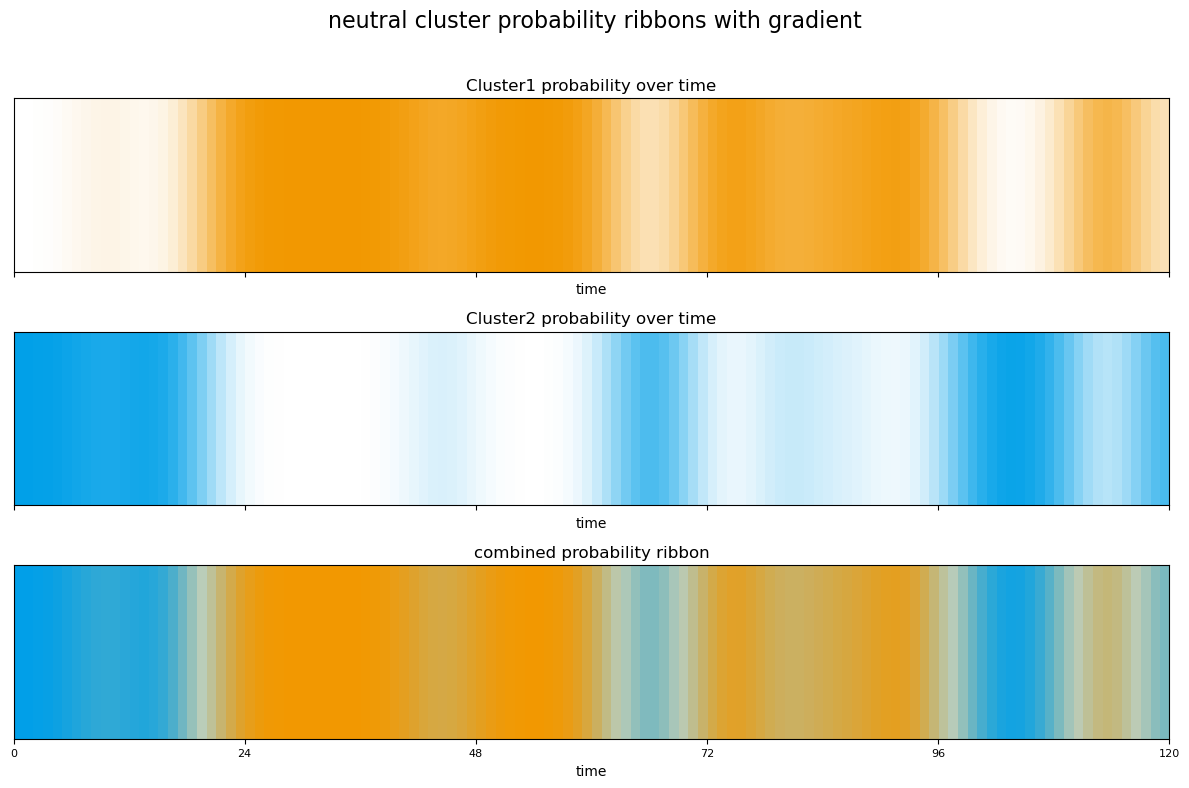

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter1d

# Function: create a 2D visualization array with one column per time point and probability encoded by color and opacity.
# Add a smooth gradient effect.

def create_color_array_with_gradient(prob_array, color, height=20, gradient_sigma=1.0):
    """
    Create a two-dimensional visualization array with one column per time point and a smooth gradient effect.
    prob_array: probability array.
    color: base color as an (r, g, b) tuple.
    height: color-band height in pixels.
    gradient_sigma: Gaussian smoothing sigma controlling the gradient.
    """
    # Smooth the probability array using a Gaussian filter.
    smoothed_probs = gaussian_filter1d(prob_array, sigma=gradient_sigma)
    
    # Create an array of shape (height, len(prob_array)).
    color_data = np.zeros((height, len(prob_array), 4))  # RGBA
    
    # Set colors.
    for i in range(3):  # RGB channels.
        color_data[:, :, i] = color[i]
    
    # Set opacity to the smoothed probability values.
    for j in range(len(smoothed_probs)):
        color_data[:, j, 3] = smoothed_probs[j]
    
    return color_data

# Function: plot a single color band with a gradient.

def plot_single_color_ribbon(prob_array, color, title, ax, time_labels=None, gradient_sigma=1.0):
    """
    Plot a single probability band with a gradient.
    prob_array: probability array.
    color: base color as an (r, g, b) tuple.
    title: plot title.
    ax: matplotlib axes object.
    time_labels: optional array of time labels.
    gradient_sigma: Gaussian smoothing sigma controlling the gradient.
    """
    color_data = create_color_array_with_gradient(prob_array, color, gradient_sigma=gradient_sigma)
    ax.imshow(color_data, aspect='auto', extent=[0, len(prob_array), 0, 1])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('time', fontsize=10)
    ax.set_yticks([])  # Hide y-axis ticks.
    
    # Set x-axis ticks.
    if time_labels is None:
        # Show time points by default.
        time_points = np.linspace(0, len(prob_array), 6, dtype=int)
        ax.set_xticks(time_points)
        ax.set_xticklabels(time_points, fontsize=8)
    else:
        ax.set_xticks(np.arange(len(time_labels)))
        ax.set_xticklabels(time_labels, fontsize=8, rotation=45, ha='right')

# Update function parameters.
def plot_merged_color_ribbon(
    prob_S, prob_I, color_S, color_I, ax,
    time_labels=None, gradient_sigma=1.0
):
    """
    Plot combined bands by blending the cluster1 and cluster2 colors according to their probabilities.
    """
    height = 20
    merged_data = np.zeros((height, len(prob_S), 4))

    smoothed_probs_S = gaussian_filter1d(prob_S, sigma=gradient_sigma)
    smoothed_probs_I = gaussian_filter1d(prob_I, sigma=gradient_sigma)

    for j in range(len(smoothed_probs_S)):
        sum_prob = smoothed_probs_S[j] + smoothed_probs_I[j]

        if sum_prob > 1:
            s_prob = smoothed_probs_S[j] / sum_prob
            i_prob = smoothed_probs_I[j] / sum_prob
        else:
            s_prob = smoothed_probs_S[j]
            i_prob = smoothed_probs_I[j]

        # Blend using the color parameters of bands 1 and 2.
        merged_data[:, j, :3] = (
            s_prob * np.asarray(color_S)
            + i_prob * np.asarray(color_I)
        )

        merged_data[:, j, 3] = max(s_prob, i_prob)

    ax.imshow(merged_data, aspect='auto',
              extent=[0, len(prob_S), 0, 1])
    ax.set_title('combined probability ribbon', fontsize=12)
    ax.set_xlabel('time', fontsize=10)
    ax.set_yticks([])

    if time_labels is None:
        time_points = np.linspace(0, len(prob_S), 6, dtype=int)
        ax.set_xticks(time_points)
        ax.set_xticklabels(time_points, fontsize=8)
    else:
        ax.set_xticks(np.arange(len(time_labels)))
        ax.set_xticklabels(
            time_labels, fontsize=8, rotation=45, ha='right'
        )

# Function: plot combined color bands with a gradient.

# def plot_merged_color_ribbon(prob_S, prob_I, ax, time_labels=None, gradient_sigma=1.0):
#     """
#     Plot combined bands: blue represents cluster2, red represents cluster1, and blended colors represent both.
#     Add a smooth gradient effect.
#     prob_S: array of cluster1 probabilities.
#     prob_I: array of cluster2 probabilities.
#     ax: matplotlib axes object.
#     time_labels: optional array of time labels.
#     gradient_sigma: Gaussian smoothing sigma controlling the gradient.
#     """
#     height = 20
#     # Create an array of shape (height, len(prob_S)).
#     merged_data = np.zeros((height, len(prob_S), 4))  # RGBA
    
#     # Smooth the probability arrays using a Gaussian filter.
#     smoothed_probs_S = gaussian_filter1d(prob_S, sigma=gradient_sigma)
#     smoothed_probs_I = gaussian_filter1d(prob_I, sigma=gradient_sigma)
    
#     # Set colors and opacity.
#     for j in range(len(smoothed_probs_S)):
#         # Normalize probabilities to sum to 1 when their sum exceeds 1.
#         sum_prob = smoothed_probs_S[j] + smoothed_probs_I[j]
#         if sum_prob > 1:
#             s_prob = smoothed_probs_S[j] / sum_prob
#             i_prob = smoothed_probs_I[j] / sum_prob
#         else:
#             s_prob = smoothed_probs_S[j]
#             i_prob = smoothed_probs_I[j]
            
#         # Use red for cluster1 and blue for cluster2.
#         merged_data[:, j, 0] = s_prob  # R channel.
#         merged_data[:, j, 2] = i_prob  # B channel.
#         merged_data[:, j, 3] = max(s_prob, i_prob)  # Use the maximum probability as opacity.
    
#     ax.imshow(merged_data, aspect='auto', extent=[0, len(prob_S), 0, 1])
#     ax.set_title('combined probability ribbon', fontsize=12)
#     ax.set_xlabel('time', fontsize=10)
#     ax.set_yticks([])  # Hide y-axis ticks.
    
#     # Set x-axis ticks.
#     if time_labels is None:
#         # Show time points by default.
#         time_points = np.linspace(0, len(prob_S), 6, dtype=int)
#         ax.set_xticks(time_points)
#         ax.set_xticklabels(time_points, fontsize=8)
#     else:
#         ax.set_xticks(np.arange(len(time_labels)))
#         ax.set_xticklabels(time_labels, fontsize=8, rotation=45, ha='right')

# Main program.
if __name__ == "__main__":
    # Create a sufficiently large figure.
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    
    # Set colors: red for cluster1 and blue for cluster2.
    # cluster1_color = (1, 0, 0)  # Red.
    cluster1_color = (0.9529, 0.5961, 0.0)  # 
    # cluster2_color = (0, 0, 1)  # Blue.
    cluster2_color = (0.0, 0.6275, 0.9137)  # 
    
    # Set the gradient parameter; adjust it to control smoothing.
    gradient_strength = 3  # Increase this value for a smoother gradient.
    
    # Plot the cluster1 probability band.
    plot_single_color_ribbon(
        results_P_cluster1, 
        cluster1_color, 
        'Cluster1 probability over time', 
        ax1,
        gradient_sigma=gradient_strength
    )
    
    # Plot the cluster2 probability band.
    plot_single_color_ribbon(
        results_P_cluster2, 
        cluster2_color, 
        'Cluster2 probability over time', 
        ax2,
        gradient_sigma=gradient_strength
    )
    
    # Plot the combined probability band.
    plot_merged_color_ribbon(
        results_P_cluster1,
        results_P_cluster2,
        cluster1_color,
        cluster2_color,
        ax3,
        gradient_sigma=gradient_strength
    )
    # plot_merged_color_ribbon(
    #     results_P_cluster1, 
    #     results_P_cluster2, 
    #     ax3,
    #     gradient_sigma=gradient_strength
    # )
    
    # Add an overall title.
    fig.suptitle('neutral cluster probability ribbons with gradient', fontsize=16, y=0.98)
    
    # Adjust the layout.
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave room for the suptitle.
    
    # Optionally save the figure.
    # plt.savefig('neutral_cluster_probability_ribbons_with_gradient.png', dpi=300, bbox_inches='tight')
    plt.savefig(path_save+r'\neutral_cluster_probability_ribbons_with_gradient.png', dpi=300, format='png', bbox_inches='tight')
    plt.savefig(path_save+r'\neutral_cluster_probability_ribbons_with_gradient.pdf', dpi=300, format='pdf', bbox_inches='tight')
    
    # Display the image.
    plt.show()

## Batch runs over lower and upper weight bounds for pre/post.
Save the notebook first, then **run only the batch cell below**; the preceding single-animal analysis does not need to be run first.
The outer loop traverses 24 pairs of L=[0,0.1,0.2,0.3] and U=[0.5,0.6,0.7,0.8,0.9,1.0], processing pre and post for all mice before changing parameters.
Output: `F:\M2\临时图像5 敏感性分析\weights_L0.0_U0.5\小鼠编号\pre` or `post` (the combination folder name varies with the bounds).
Each combination separately saves run logs, execution summaries, and `accuracy汇总/posthoc_accuracy_summary.csv`; missing required files or analysis errors are recorded, and processing continues.


In [ ]:
# Batch entry point: run all pre and post records for each bound pair before moving to the next, for 24 pairs in total.
import json
import traceback
from pathlib import Path
from contextlib import redirect_stdout, redirect_stderr
import pandas as pd
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import display
from IPython.core.inputtransformer2 import TransformerManager
from IPython.utils.capture import capture_output

batch_notebook_path = Path(r'D:\RQ\M2 Project\m2_v46_disconnectivity_graph 20 mod version 14 auto batch.ipynb')
batch_signal_root = Path(r'F:\M2\信号数据\敏感性分析汇总')
batch_behavior_root = Path(r'F:\M2\有设备小鼠 行为数据\spare\敏感性分析汇总')
batch_output_parent = Path(r'F:\M2\临时图像6 敏感性分析 batch')

# Reuse the original analysis cells and exclude this batch entry point to avoid recursive execution.
batch_notebook = json.loads(batch_notebook_path.read_text(encoding='utf-8'))
batch_transformer = TransformerManager()
batch_cells = [
    (index, compile(batch_transformer.transform_cell(''.join(cell['source'])),
                    f'{batch_notebook_path.name}:cell_{index}', 'exec'))
    for index, cell in enumerate(batch_notebook['cells'])
    if cell['cell_type'] == 'code' and cell.get('id') != 'batch-pre-post-runner'
]

# Iterate over bound pairs in the outermost loop and save each combination separately, retaining the existing single-combination batch logic.
for batch_lower in (0.1,):
    for batch_upper in (0.7,):
        batch_output_root = batch_output_parent / f'weights_L{batch_lower:.1f}_U{batch_upper:.1f}'
        print(f'\n[Parameter combination] L={batch_lower:.1f}, U={batch_upper:.1f} -> {batch_output_root}')
        batch_records = []
        weight_window_tables = []  # Window-level weights for all IDs and pre/post phases in this run.
        batch_output_root.mkdir(parents=True, exist_ok=True)
        for batch_phase in ('pre', 'post'):
            batch_phase_dir = batch_signal_root / batch_phase
            if not batch_phase_dir.is_dir():
                raise FileNotFoundError(f'Signal directory does not exist: {batch_phase_dir}')
            for batch_mouse_dir in sorted(batch_phase_dir.iterdir(), key=lambda folder: folder.name):
                if not batch_mouse_dir.is_dir():
                    continue
                batch_signal_dir = batch_mouse_dir / 'TST'
                batch_behavior_dir = batch_behavior_root / batch_phase / batch_mouse_dir.name
                batch_save_dir = batch_output_root / batch_mouse_dir.name / batch_phase
                batch_record = dict(mouse=batch_mouse_dir.name, phase=batch_phase, L=batch_lower, U=batch_upper,
                                    status='', output_dir=str(batch_save_dir), error='')
                batch_required = [batch_signal_dir / 'C.csv', batch_signal_dir / 'YrA.csv',
                                  batch_behavior_dir / 'Area_Change.csv', batch_behavior_dir / 'im.csv']
                batch_missing = [str(file) for file in batch_required if not file.is_file()]
                if batch_missing:
                    batch_record.update(status='skipped', error='Missing files: ' + '; '.join(batch_missing))
                    print(f'[Skipped] {batch_mouse_dir.name} {batch_phase}: {batch_record["error"]}')
                else:
                    batch_save_dir.mkdir(parents=True, exist_ok=True)
                    # Use an independent namespace for each animal while preserving the original __main__ entry point and display.
                    batch_namespace = {'__name__': '__main__', 'get_ipython': get_ipython,
                                       'display': display,
                                       '_batch_weight_bounds': (batch_lower, batch_upper),
                                       '_batch_paths': (str(batch_signal_dir), str(batch_behavior_dir), str(batch_save_dir))}
                    print(f'[Started] {batch_mouse_dir.name} {batch_phase} -> {batch_save_dir}')
                    try:
                        with (batch_save_dir / 'batch_run.log').open('w', encoding='utf-8') as batch_log:
                            with redirect_stdout(batch_log), redirect_stderr(batch_log):
                                for batch_cell_index, batch_code in batch_cells:
                                    print(f'\n--- cell {batch_cell_index} ---', flush=True)
                                    # Continue saving figures to files as in the original code, avoiding image accumulation in the notebook during batch runs.
                                    with capture_output(stdout=False, stderr=False):
                                        exec(batch_code, batch_namespace)
                        batch_record['status'] = 'completed'
                        print(f'[Completed] {batch_mouse_dir.name} {batch_phase}')
                    except Exception as batch_error:
                        batch_record.update(status='failed', error=f'cell {batch_cell_index}: {batch_error}')
                        with (batch_save_dir / 'batch_run.log').open('a', encoding='utf-8') as batch_log:
                            traceback.print_exc(file=batch_log)
                        print(f'[Failed] {batch_mouse_dir.name} {batch_phase}: {batch_record["error"]}')
                    finally:
                        plt.close('all')
                        # Estimate weights once from the full recording and use the same values in all windows, preserving the original calculation.
                        batch_weight_results = batch_namespace.get('results_probility', batch_namespace.get('results'))
                        if isinstance(batch_weight_results, dict) and {'windows_df', 'weights'} <= batch_weight_results.keys():
                            weight_windows = batch_weight_results['windows_df'].copy()
                            weight_windows['id'] = batch_mouse_dir.name
                            weight_windows['phase'] = batch_phase
                            weight_windows['L'] = batch_lower
                            weight_windows['U'] = batch_upper
                            weight_windows['run_status'] = batch_record['status']
                            weight_windows['output_dir'] = str(batch_save_dir)
                            for weight_group in ('dual_cluster1', 'dual_cluster2'):
                                weight_value = batch_weight_results['weights'].get(weight_group, float('nan'))
                                weight_windows[f'w_{weight_group}'] = weight_value
                                weight_windows[f'w_{weight_group}_bound'] = (
                                    'not_estimated' if pd.isna(weight_value) else
                                    'lower' if weight_value == batch_lower else
                                    'upper' if weight_value == batch_upper else 'interior'
                                )
                            weight_windows.to_csv(batch_save_dir / 'dual_cluster_weights_by_window.csv',
                                                  index=False, encoding='utf-8-sig')
                            weight_window_tables.append(weight_windows)
                        batch_namespace.clear()
                batch_records.append(batch_record)
                # Update the summary after each animal so later failures do not affect completed results.
                pd.DataFrame(batch_records).to_csv(batch_output_root / 'batch_run_summary.csv',
                                                  index=False, encoding='utf-8-sig')

        batch_summary = pd.DataFrame(batch_records)
        display(batch_summary)
        print('Batch execution complete; summary file:', batch_output_root / 'batch_run_summary.csv')

        # After batch execution, summarize existing results and automatically skip folders without CSV files.
        accuracy_records = []
        for accuracy_phase in ('pre', 'post'):
            for accuracy_file in sorted(batch_output_root.glob(f'*/{accuracy_phase}/posthoc_valley_behavior_mapping.csv')):
                try:
                    accuracy_data = pd.read_csv(accuracy_file, encoding='utf-8-sig')
                    if 'accuracy' not in accuracy_data.columns:
                        print(f'[Summary skipped] Missing accuracy column: {accuracy_file}')
                        continue
                    for accuracy_value in accuracy_data['accuracy']:
                        accuracy_records.append({
                            'id': accuracy_file.parent.parent.name,
                            'phase': accuracy_phase,
                            'L': batch_lower,
                            'U': batch_upper,
                            'accuracy': accuracy_value,
                            'source_file': str(accuracy_file),
                        })
                except (OSError, UnicodeError, pd.errors.ParserError, pd.errors.EmptyDataError) as accuracy_error:
                    print(f'[Summary skipped] {accuracy_file}: {accuracy_error}')

        accuracy_summary_dir = batch_output_root / 'accuracy汇总'
        accuracy_summary_dir.mkdir(parents=True, exist_ok=True)
        accuracy_summary = pd.DataFrame(accuracy_records, columns=['id', 'phase', 'L', 'U', 'accuracy', 'source_file'])
        accuracy_summary_file = accuracy_summary_dir / 'posthoc_accuracy_summary.csv'
        accuracy_summary.to_csv(accuracy_summary_file, index=False, encoding='utf-8-sig')
        display(accuracy_summary)
        print(f'Accuracy summary complete, {len(accuracy_summary)} records: {accuracy_summary_file}')


        # Summarize and plot each parameter group separately; the y-axis counts windows, so weights repeat within each ID/phase.
        weight_summary_dir = batch_output_root / 'weight汇总'
        weight_summary_dir.mkdir(parents=True, exist_ok=True)
        weight_summary = (pd.concat(weight_window_tables, ignore_index=True) if weight_window_tables else
                          pd.DataFrame(columns=['window_id', 'start_frame', 'end_frame', 'duration_frames',
                                                'id', 'phase', 'L', 'U', 'run_status', 'output_dir',
                                                'w_dual_cluster1', 'w_dual_cluster1_bound',
                                                'w_dual_cluster2', 'w_dual_cluster2_bound']))
        weight_summary.to_csv(weight_summary_dir / 'dual_cluster_weights_by_window_all.csv',
                              index=False, encoding='utf-8-sig')
        if not weight_summary.empty:
            # Also save one row per ID/phase to inspect the weight distribution without counting windows repeatedly.
            weight_summary.drop_duplicates(['id', 'phase']).drop(
                columns=['window_id', 'start_frame', 'end_frame', 'duration_frames'], errors='ignore'
            ).to_csv(weight_summary_dir / 'dual_cluster_weights_by_id.csv', index=False, encoding='utf-8-sig')
            weight_fig, weight_axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
            for weight_row, weight_phase in enumerate(('pre', 'post')):
                for weight_col, weight_group in enumerate(('dual_cluster1', 'dual_cluster2')):
                    weight_ax = weight_axes[weight_row, weight_col]
                    weight_values = weight_summary.loc[weight_summary['phase'] == weight_phase, f'w_{weight_group}']
                    weight_ax.hist(weight_values.dropna(), bins=[k / 20 for k in range(21)],
                                   color='steelblue' if weight_phase == 'pre' else 'indianred', edgecolor='white')
                    weight_ax.axvline(batch_lower, color='black', linestyle='--', label=f'L={batch_lower:.1f}')
                    weight_ax.axvline(batch_upper, color='darkorange', linestyle='--', label=f'U={batch_upper:.1f}')
                    weight_ax.set(title=f'{weight_phase} | w_{weight_group}', xlabel='Weight',
                                  ylabel='Window count', xlim=(-0.025, 1.025))
                    weight_ax.text(0.97, 0.96,
                                   f'n={weight_values.notna().sum()}, missing={weight_values.isna().sum()}',
                                   transform=weight_ax.transAxes, ha='right', va='top')
                    weight_ax.legend(loc='upper left')
            weight_fig.suptitle(f'L={batch_lower:.1f}, U={batch_upper:.1f} | Constant weight within each ID/session')
            weight_fig.tight_layout()
            weight_fig.savefig(weight_summary_dir / 'dual_cluster_weight_distributions.png', dpi=300, bbox_inches='tight')
            weight_fig.savefig(weight_summary_dir / 'dual_cluster_weight_distributions.pdf', bbox_inches='tight')
            plt.close(weight_fig)
        print(f'Window-level weight summary complete, {len(weight_summary)} records: {weight_summary_dir}')

print('All 24 lower/upper-bound batch combinations are complete; output parent directory:', batch_output_parent)



[Parameter combination] L=0.1, U=0.7 -> F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7
[Started] 5804 pre -> F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\5804\pre
[Completed] 5804 pre
[Started] 5806 pre -> F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\5806\pre
[Completed] 5806 pre
[Started] 5830 pre -> F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\5830\pre
[Completed] 5830 pre
[Started] 5831 pre -> F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\5831\pre
[Completed] 5831 pre
[Started] CSDS0087 pre -> F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS0087\pre
[Completed] CSDS0087 pre
[Skipped] CSDS0103 pre: Missing files: F:\M2\有设备小鼠 行为数据\spare\敏感性分析汇总\pre\CSDS0103\Area_Change.csv; F:\M2\有设备小鼠 行为数据\spare\敏感性分析汇总\pre\CSDS0103\im.csv
[Started] CSDS0126 pre -> F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS0126\pre
[Completed] CSDS0126 pre
[Started] CSDS0179 pre -> F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS0179\pre
[Failed] CSDS0179 pre: cell 47: At least 2 feature clusters must each contain > 3 neurons to defi

,mouse,phase,L,U,status,output_dir,error
0,5804,pre,0.1,0.7,completed,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\5804...,
1,5806,pre,0.1,0.7,completed,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\5806...,
2,5830,pre,0.1,0.7,completed,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\5830...,
3,5831,pre,0.1,0.7,completed,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\5831...,
4,CSDS0087,pre,0.1,0.7,completed,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS...,
5,CSDS0103,pre,0.1,0.7,skipped,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS...,Missing files: F:\M2\有设备小鼠 行为数据\spare\敏感性分析汇总\pre\CSDS01...
6,CSDS0126,pre,0.1,0.7,completed,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS...,
7,CSDS0179,pre,0.1,0.7,failed,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS...,cell 47: At least 2 feature clusters must each contain > 3 neurons to define bias_clu...
8,CSDS0370,pre,0.1,0.7,skipped,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS...,Missing files: F:\M2\有设备小鼠 行为数据\spare\敏感性分析汇总\pre\CSDS03...
9,CSDS5776,pre,0.1,0.7,completed,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS...,


Batch execution complete; summary file: F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\batch_run_summary.csv


,id,phase,L,U,accuracy,source_file
0,5804,pre,0.1,0.7,0.700000,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\5804...
1,5806,pre,0.1,0.7,0.583333,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\5806...
2,5830,pre,0.1,0.7,0.725000,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\5830...
3,5831,pre,0.1,0.7,0.596639,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\5831...
4,CSDS0087,pre,0.1,0.7,0.800000,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS...
5,CSDS0126,pre,0.1,0.7,0.716667,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS...
6,CSDS5776,pre,0.1,0.7,0.608333,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS...
7,CSDS5797,pre,0.1,0.7,0.741667,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS...
8,CSDSQ26,pre,0.1,0.7,0.816667,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS...
9,CSDSQ27,pre,0.1,0.7,0.666667,F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\CSDS...


Accuracy summary complete, 36 records: F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\accuracy汇总\posthoc_accuracy_summary.csv
Window-level weight summary complete, 4319 records: F:\M2\临时图像6 敏感性分析 batch\weights_L0.1_U0.7\weight汇总
All 24 lower/upper-bound batch combinations are complete; output parent directory: F:\M2\临时图像6 敏感性分析 batch


: 